# DeFi Game Product Analytics

## 0) Project Context and Analytics Goals

**Game:** Strategy simulator where players build planets, develop resources, and earn tokens for progress. PvP is limited to economic interaction via the market (bull/bear market behavior), with no direct combat., игроки строят планеты, развивают ресурсы, получают токены за фрагменты прогресса. PvP ограничено экономическим взаимодействием через рынок (быки/медведи как поведение на бирже), без прямых боёв.

**Main Analytics Goal:** To make the economy sustainable and attractive:
- **Retention** via endgame/metagame mechanics;
- **Growth** via virality and social mechanics;
- **Conversion** into trading, staking, and economic participation;
- **Optimization** of taxes, fees, and emission to balance 'revenue ↔ liquidity ↔ retention'.

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

## 1) Data Preparation and QA

- Checking types, missing values, duplicates, and value ranges
- Converting time to `datetime`, building `day/week/month` periods
- Validating keys and join-keys (user_id, planet_id, resource_key, alliance_id)
- Sanity checks of aggregates (volumes, emission/sinks, user/session counts)

Loaded tables: alliance_membership, alliances, contracts, economic_events, experiment_assignments, experiments, governance_proposals, governance_votes, market_orders, market_trades, marketing_costs, planets, price_oracle_daily, resource_daily, sessions, token_ledger, users
{'alliance_membership': (8390, 5), 'alliances': (120, 5), 'contracts': (4500, 10), 'economic_events': (12, 8), 'experiment_assignments': (9098, 4), 'experiments': (2, 6), 'governance_proposals': (180, 9), 'governance_votes': (58765, 7), 'market_orders': (59766, 13), 'market_trades': (59766, 15), 'marketing_costs': (450, 7), 'planets': (32338, 7), 'price_oracle_daily': (450, 4), 'resource_daily': (5931830, 10), 'sessions': (286279, 8), 'token_ledger': (738345, 9), 'users': (20000, 18)}

Datetime conversion report:
- alliance_membership: converted=['join_ts'], failed=[]
- alliances: converted=['created_ts'], failed=[]
- contracts: converted=['end_day', 'start_day'], failed=[]
- economic_events: converted=['end_ts', 'st

,dtype,n_missing,missing_%,n_unique
leave_ts,object,6848,81.62,1542
user_id,int64,0,0.00,8390
join_ts,datetime64[ns],0,0.00,8383
alliance_id,int64,0,0.00,120
role,object,0,0.00,3



=== alliances === shape=(120, 5)


,dtype,n_missing,missing_%,n_unique
alliance_id,int64,0,0.0,120
created_ts,datetime64[ns],0,0.0,120
name,object,0,0.0,120
tax_rebate_pct,float64,0,0.0,102
policy_type,object,0,0.0,3



=== contracts === shape=(4500, 10)


...


=== token_ledger === shape=(738345, 9)


,dtype,n_missing,missing_%,n_unique
ledger_id,int64,0,0.0,738345
tx_hash,object,0,0.0,738345
amount,float64,0,0.0,715230
ts,datetime64[ns],0,0.0,639977
user_id,int64,0,0.0,18769
gas_fee_token,float64,0,0.0,14160
chain,object,0,0.0,6
tx_type,object,0,0.0,5
token_symbol,object,0,0.0,1



=== users === shape=(20000, 18)


,dtype,n_missing,missing_%,n_unique
referrer_user_id,float64,17596,87.98,2257
ad_group,object,13075,65.38,119
user_id,int64,0,0.00,20000
created_at,datetime64[ns],0,0.00,19972
initial_deposit_usd,float64,0,0.00,12724
campaign_id,object,0,0.00,170
country,object,0,0.00,10
timezone,object,0,0.00,6
chain_pref,object,0,0.00,6
acq_channel,object,0,0.00,5



=== PK duplicates check ===
- users: PK=['user_id'] duplicates=0
- planets: PK=['planet_id'] duplicates=0
- sessions: PK=['session_id'] duplicates=0
- market_orders: PK=['order_id'] duplicates=0
- market_trades: PK=['trade_id'] duplicates=0
- token_ledger: PK=['ledger_id'] duplicates=0
- alliances: PK=['alliance_id'] duplicates=0
- contracts: PK=['contract_id'] duplicates=0
- governance_proposals: PK=['proposal_id'] duplicates=0
- governance_votes: PK=['vote_id'] duplicates=0
- experiments: PK=['experiment_id'] duplicates=0

=== FK orphan check ===
- planets.user_id -> users.user_id: orphans=0/32,338 (0.000%)
- sessions.user_id -> users.user_id: orphans=0/286,279 (0.000%)
- resource_daily.user_id -> users.user_id: orphans=0/5,931,830 (0.000%)
- resource_daily.planet_id -> planets.planet_id: orphans=0/5,931,830 (0.000%)
- market_orders.user_id -> users.user_id: orphans=0/59,766 (0.000%)
- market_trades.order_id -> market_orders.order_id: orphans=0/59,766 (0.000%)
- market_trades.maker_

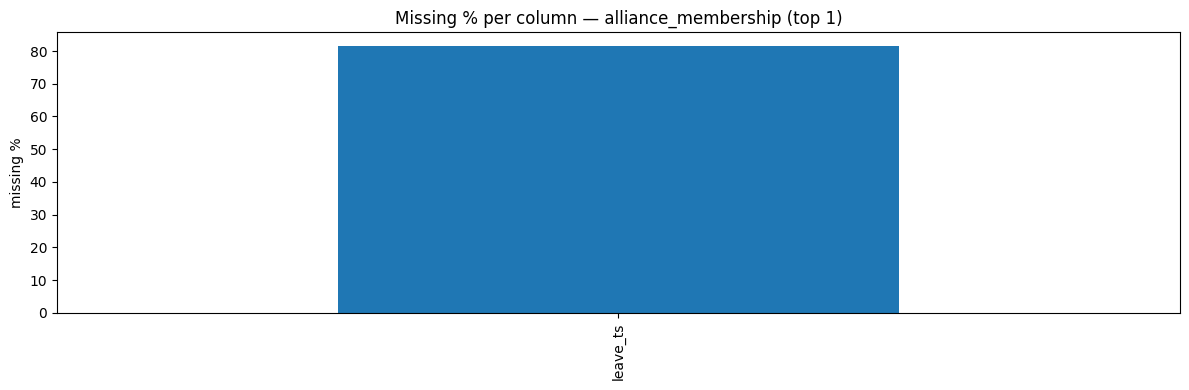

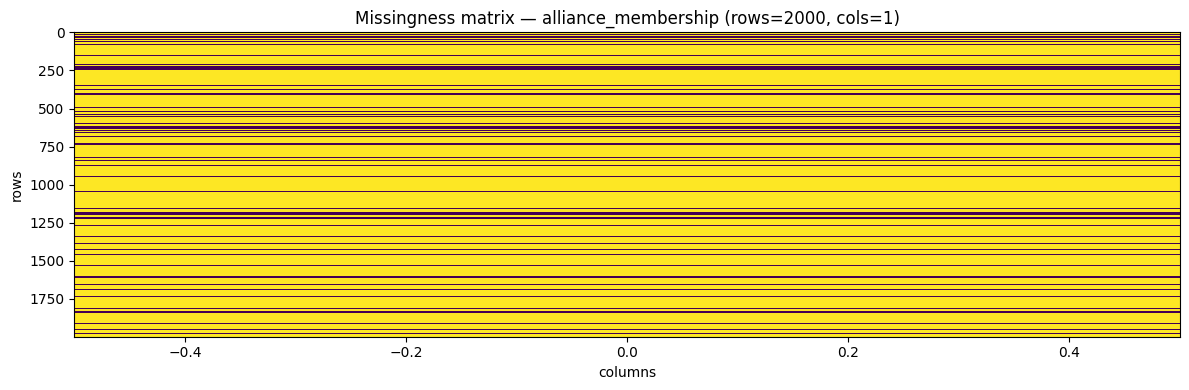

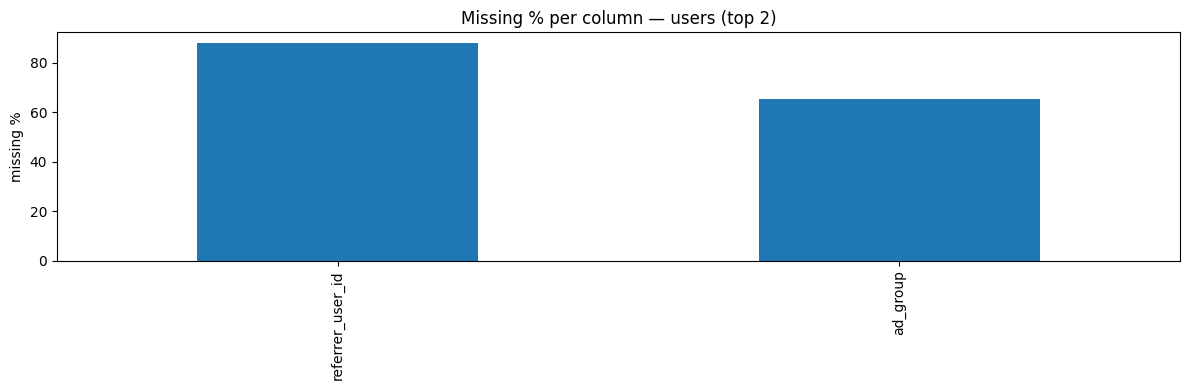

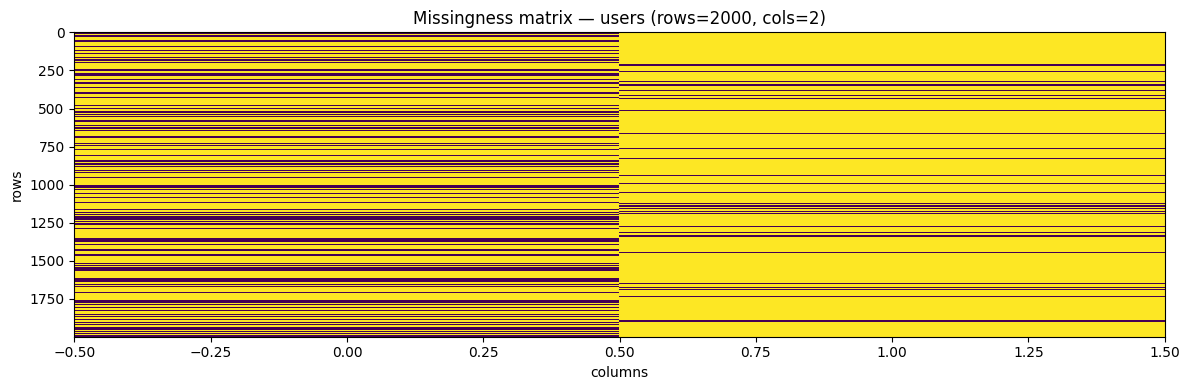


Step 0 done


In [1]:
import os, re, json, math, time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import time
from sklearn.model_selection import train_test_split


#  0) PATH 
DATA_DIR = "synthetic_defi_game_data"  

# === helpers ===
def list_csv_files(data_dir: str) -> list[str]:
    files = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
    return sorted(files)

def read_all_csv(data_dir: str) -> dict[str, pd.DataFrame]:
    dfs = {}
    for f in list_csv_files(data_dir):
        name = os.path.splitext(f)[0]
        path = os.path.join(data_dir, f)
        dfs[name] = pd.read_csv(path, low_memory=False)
    return dfs

def infer_datetime_cols(df: pd.DataFrame) -> list[str]:
    name_pat = re.compile(r"(ts|_ts|_at|date|day|start|end)", re.IGNORECASE)
    candidates = [c for c in df.columns if name_pat.search(c)]
    good = []
    for c in candidates:
        if df[c].dtype == "O" or "date" in c.lower() or "ts" in c.lower() or c.lower().endswith("_day") or c.lower() == "day":
            parsed = pd.to_datetime(df[c], errors="coerce", utc=False)
            # если хотя бы 80% распарсилось — считаем датой
            if parsed.notna().mean() >= 0.80:
                good.append(c)
    return sorted(set(good))

def coerce_datetimes_inplace(dfs: dict[str, pd.DataFrame]) -> dict[str, dict]:
    report = {}
    for name, df in dfs.items():
        cols = infer_datetime_cols(df)
        rep = {"converted": [], "failed": []}
        for c in cols:
            before_na = df[c].isna().mean()
            parsed = pd.to_datetime(df[c], errors="coerce", utc=False)
            after_na = parsed.isna().mean()
            # если не стало хуже драматически — принимаем
            if after_na <= max(before_na + 0.05, 0.20):
                df[c] = parsed
                rep["converted"].append(c)
            else:
                rep["failed"].append(c)
        report[name] = rep
    return report

def table_overview(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True)
    })
    return out.sort_values(["missing_%", "n_unique"], ascending=[False, False])

def plot_missing_bar(df: pd.DataFrame, title: str, topn: int = 40):
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print(f"[{title}] пропусков нет")
        return
    miss = miss.head(topn)
    plt.figure(figsize=(12, 4))
    miss.plot(kind="bar")
    plt.title(f"Missing % per column — {title} (top {len(miss)})")
    plt.ylabel("missing %")
    plt.tight_layout()
    plt.show()

def plot_missing_matrix(df: pd.DataFrame, title: str, max_rows: int = 2000, max_cols: int = 80):
    miss_cols = [c for c in df.columns if df[c].isna().any()]
    cols = miss_cols[:max_cols] if miss_cols else list(df.columns)[:max_cols]
    sample = df[cols].head(max_rows)
    mat = sample.isna().to_numpy()
    if mat.size == 0:
        print(f"[{title}] нечего рисовать")
        return
    plt.figure(figsize=(12, 4))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.title(f"Missingness matrix — {title} (rows={len(sample)}, cols={len(cols)})")
    plt.xlabel("columns")
    plt.ylabel("rows")
    plt.tight_layout()
    plt.show()

# 1) LOAD 
dfs = read_all_csv(DATA_DIR)
print("Loaded tables:", ", ".join(dfs.keys()))
print({k: v.shape for k, v in dfs.items()})

# 2) COERCE DATETIME TYPES 
dt_report = coerce_datetimes_inplace(dfs)
print("\nDatetime conversion report:")
for t, rep in dt_report.items():
    if rep["converted"] or rep["failed"]:
        print(f"- {t}: converted={rep['converted']}, failed={rep['failed']}")

#3) BASIC HEALTH CHECKS (schema, missing, duplicates, key integrity) 

# Primary key expectations 
PK = {
    "users": ["user_id"],
    "planets": ["planet_id"],
    "sessions": ["session_id"],
    "market_orders": ["order_id"],
    "market_trades": ["trade_id"],
    "token_ledger": ["ledger_id"],
    "alliances": ["alliance_id"],
    "contracts": ["contract_id"],
    "governance_proposals": ["proposal_id"],
    "governance_votes": ["vote_id"],
    "experiments": ["experiment_id"],
}

# Foreign-key like checks (orphan rows)
FK_CHECKS = [
    ("planets", "user_id", "users", "user_id"),
    ("sessions", "user_id", "users", "user_id"),
    ("resource_daily", "user_id", "users", "user_id"),
    ("resource_daily", "planet_id", "planets", "planet_id"),
    ("market_orders", "user_id", "users", "user_id"),
    ("market_trades", "order_id", "market_orders", "order_id"),
    ("market_trades", "maker_user_id", "users", "user_id"),
    ("market_trades", "taker_user_id", "users", "user_id"),
    ("token_ledger", "user_id", "users", "user_id"),
    ("alliance_membership", "user_id", "users", "user_id"),
    ("alliance_membership", "alliance_id", "alliances", "alliance_id"),
    ("contracts", "supplier_user_id", "users", "user_id"),
    ("contracts", "buyer_user_id", "users", "user_id"),
    ("governance_votes", "proposal_id", "governance_proposals", "proposal_id"),
    ("governance_votes", "user_id", "users", "user_id"),
    ("experiment_assignments", "experiment_id", "experiments", "experiment_id"),
    ("experiment_assignments", "user_id", "users", "user_id"),
]

#3.1) Summary per table: dtypes + missingness
summaries = {}
for name, df in dfs.items():
    summaries[name] = table_overview(df)
    print(f"\n=== {name} === shape={df.shape}")
    display(summaries[name].head(15))  # если ты в Jupyter

# 3.2) Duplicates in PK 
print("\n=== PK duplicates check ===")
for t, pk_cols in PK.items():
    if t not in dfs:
        continue
    df = dfs[t]
    missing_cols = [c for c in pk_cols if c not in df.columns]
    if missing_cols:
        print(f"- {t}: skip (no cols {missing_cols})")
        continue
    dup_cnt = df.duplicated(subset=pk_cols).sum()
    print(f"- {t}: PK={pk_cols} duplicates={dup_cnt:,}")

# 3.3) Orphans (FK-like) 
print("\n=== FK orphan check ===")
for child, child_col, parent, parent_col in FK_CHECKS:
    if child not in dfs or parent not in dfs:
        continue
    cdf = dfs[child]
    pdf = dfs[parent]
    if child_col not in cdf.columns or parent_col not in pdf.columns:
        continue

    child_vals = cdf[child_col].dropna()
    parent_set = set(pdf[parent_col].dropna().unique())

    orphan_mask = ~child_vals.isin(parent_set)
    orphan_cnt = int(orphan_mask.sum())
    total = len(child_vals)
    rate = (orphan_cnt / total * 100) if total else 0.0
    print(f"- {child}.{child_col} -> {parent}.{parent_col}: orphans={orphan_cnt:,}/{total:,} ({rate:.3f}%)")

# 4) MISSING VISUALS
for name, df in dfs.items():
    miss_cols = df.columns[df.isna().any()].tolist()
    if not miss_cols:
        continue
    plot_missing_bar(df, name, topn=40)
    plot_missing_matrix(df, name, max_rows=2000, max_cols=80)

print("\nStep 0 done")


In [2]:
import os, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display  # удобно в Jupyter

# === CONFIG ===
DATA_DIR = "synthetic_defi_game_data"   # поменяй, если папка другая
FIGSIZE = (12, 4)
MAX_CATS_SHOW = 15
RANDOM_SEED = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

def list_csv_files(data_dir: str) -> list[str]:
    return sorted([f for f in os.listdir(data_dir) if f.lower().endswith(".csv")])

def read_all_csv(data_dir: str) -> dict[str, pd.DataFrame]:
    dfs = {}
    for f in list_csv_files(data_dir):
        name = os.path.splitext(f)[0]
        dfs[name] = pd.read_csv(os.path.join(data_dir, f), low_memory=False)
    return dfs

dfs = read_all_csv(DATA_DIR)
print("Loaded tables:", ", ".join(dfs.keys()))
print({k: v.shape for k, v in dfs.items()})


Loaded tables: alliance_membership, alliances, contracts, economic_events, experiment_assignments, experiments, governance_proposals, governance_votes, market_orders, market_trades, marketing_costs, planets, price_oracle_daily, resource_daily, sessions, token_ledger, users
{'alliance_membership': (8390, 5), 'alliances': (120, 5), 'contracts': (4500, 10), 'economic_events': (12, 8), 'experiment_assignments': (9098, 4), 'experiments': (2, 6), 'governance_proposals': (180, 9), 'governance_votes': (58765, 7), 'market_orders': (59766, 13), 'market_trades': (59766, 15), 'marketing_costs': (450, 7), 'planets': (32338, 7), 'price_oracle_daily': (450, 4), 'resource_daily': (5931830, 10), 'sessions': (286279, 8), 'token_ledger': (738345, 9), 'users': (20000, 18)}


In [3]:
name_pat = re.compile(r"(ts|_ts|_at|date|day|start|end)", re.IGNORECASE)

def infer_datetime_cols(df: pd.DataFrame) -> list[str]:
    candidates = [c for c in df.columns if name_pat.search(c)]
    good = []
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors="coerce", utc=False)
        if parsed.notna().mean() >= 0.80:
            good.append(c)
    return sorted(set(good))

def coerce_datetimes(dfs: dict[str, pd.DataFrame]) -> dict:
    report = {}
    for name, df in dfs.items():
        cols = infer_datetime_cols(df)
        for c in cols:
            df[c] = pd.to_datetime(df[c], errors="coerce", utc=False)
        report[name] = cols
    return report

dt_report = coerce_datetimes(dfs)
print("Datetime converted:")
for t, cols in dt_report.items():
    if cols:
        print(f"- {t}: {cols}")

# handy refs
users = dfs.get("users")
planets = dfs.get("planets")
sessions = dfs.get("sessions")
resource_daily = dfs.get("resource_daily")
price_oracle = dfs.get("price_oracle_daily")
market_orders = dfs.get("market_orders")
market_trades = dfs.get("market_trades")
token_ledger = dfs.get("token_ledger")
alliances = dfs.get("alliances")
membership = dfs.get("alliance_membership")
contracts = dfs.get("contracts")
gov_props = dfs.get("governance_proposals")
gov_votes = dfs.get("governance_votes")
experiments = dfs.get("experiments")
exp_assign = dfs.get("experiment_assignments")
marketing = dfs.get("marketing_costs")
econ_events = dfs.get("economic_events")


Datetime converted:
- alliance_membership: ['join_ts']
- alliances: ['created_ts']
- contracts: ['end_day', 'start_day']
- economic_events: ['end_ts', 'start_ts']
- experiment_assignments: ['assigned_ts']
- experiments: ['end_ts', 'start_ts']
- governance_proposals: ['created_ts', 'vote_end', 'vote_start']
- governance_votes: ['ts']
- market_orders: ['ts_closed', 'ts_created']
- market_trades: ['ts']
- marketing_costs: ['day', 'spend_usd']
- planets: ['created_at']
- price_oracle_daily: ['day']
- resource_daily: ['day', 'stored_end']
- sessions: ['end_ts', 'start_ts']
- token_ledger: ['ts']
- users: ['created_at']


## 2) Step 1 — EDA

- General table statistics (size, distributions, tails)
- Correlations and dependencies:
  - engagement ↔ trading ↔ taxes/fees ↔ volatility
  - segments (whales/non-whales), channels, risk_profile
- Breakdowns by resources/chains/bull-bear modes
- Basic visualizations of activity and economy

In [4]:
def overview_table(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_%": (df.isna().mean()*100).round(2),
        "n_unique": df.nunique(dropna=True),
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
    }).sort_values(["missing_%","n_unique"], ascending=[False, False])

for name, df in dfs.items():
    print(f"\n--- {name} shape={df.shape} ---")
    display(overview_table(df).head(15))



--- alliance_membership shape=(8390, 5) ---


,dtype,missing_%,n_unique,example
leave_ts,object,81.62,1542,2025-05-27 01:03:15
user_id,int64,0.00,8390,2
join_ts,datetime64[ns],0.00,8383,2025-03-27 17:17:50
alliance_id,int64,0.00,120,104
role,object,0.00,3,member



--- alliances shape=(120, 5) ---


,dtype,missing_%,n_unique,example
alliance_id,int64,0.0,120,1
created_ts,datetime64[ns],0.0,120,2025-03-07 00:24:09
name,object,0.0,120,Alliance_001
tax_rebate_pct,float64,0.0,102,0.0313
policy_type,object,0.0,3,balanced



--- contracts shape=(4500, 10) ---


...

,dtype,missing_%,n_unique,example
session_id,int64,0.0,286279,1
start_ts,datetime64[ns],0.0,280701,2025-01-09 15:43:01
end_ts,datetime64[ns],0.0,280671,2025-01-09 15:50:19
user_id,int64,0.0,19827,1
session_len_sec,int64,0.0,6377,438
net_latency_ms,int64,0.0,345,196
entry_point,object,0.0,4,deeplink
crash_flag,int64,0.0,2,0



--- token_ledger shape=(738345, 9) ---


,dtype,missing_%,n_unique,example
ledger_id,int64,0.0,738345,1
tx_hash,object,0.0,738345,0x863b454d62e9737dbee708f0eed48f579a12c692419c...
amount,float64,0.0,715230,3.021475
ts,datetime64[ns],0.0,639977,2025-01-01 02:07:29
user_id,int64,0.0,18769,846
gas_fee_token,float64,0.0,14160,0.003009
chain,object,0.0,6,ETH
tx_type,object,0.0,5,reward
token_symbol,object,0.0,1,TOKEN



--- users shape=(20000, 18) ---


,dtype,missing_%,n_unique,example
referrer_user_id,float64,87.98,2257,12879.0
ad_group,object,65.38,119,adg_27
user_id,int64,0.00,20000,1
created_at,datetime64[ns],0.00,19972,2025-01-09 00:49:11
initial_deposit_usd,float64,0.00,12724,34.64
campaign_id,object,0.00,170,cmp_organic_5
country,object,0.00,10,BR
timezone,object,0.00,6,UTC-5
chain_pref,object,0.00,6,OP
acq_channel,object,0.00,5,organic


> **Analytical Comment (EDA):**
Initial distribution analysis reveals 'heavy tails' in trading volumes and activity. Special attention should be paid to users in the top deciles (whales), as they generate the bulk of liquidity. Missing value checks confirm data quality for further econometric modeling.

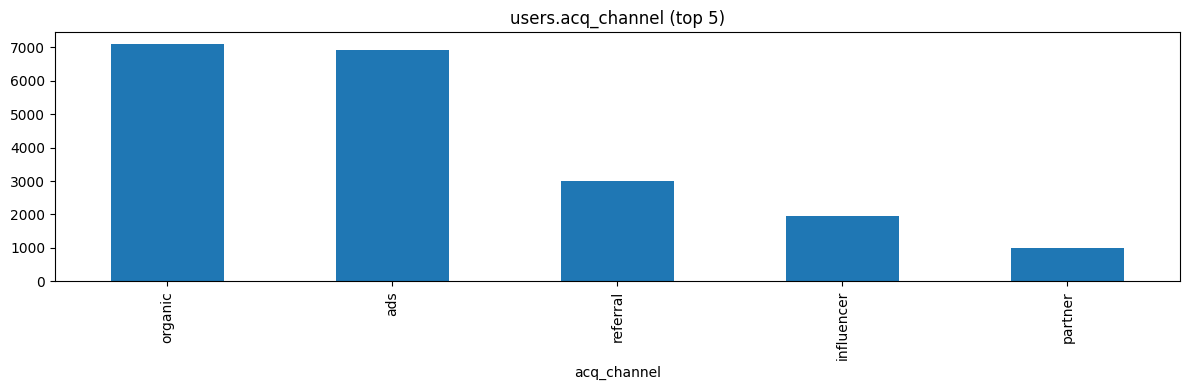

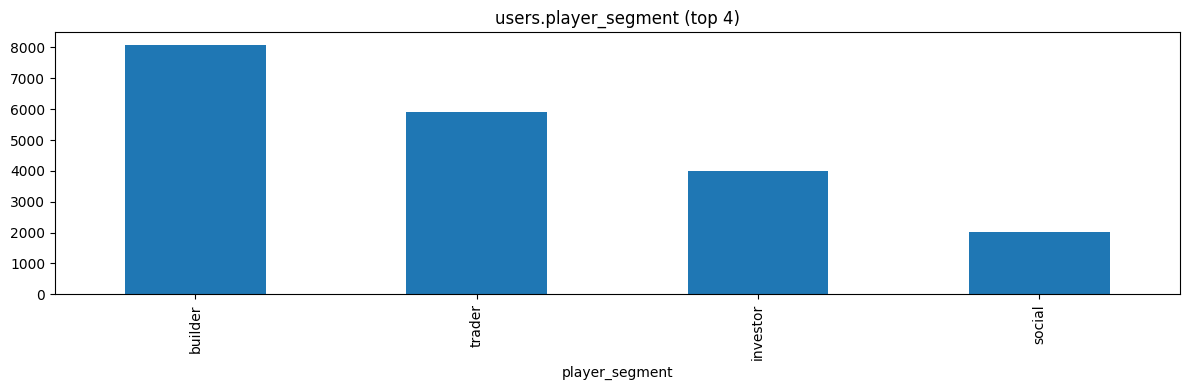

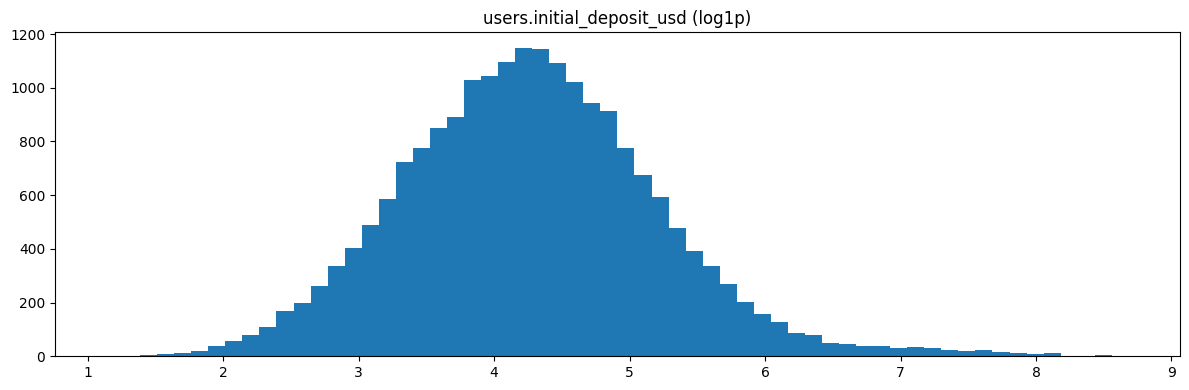

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\1238741061.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vc = s.astype("object").fillna("NA").value_counts().head(topn)


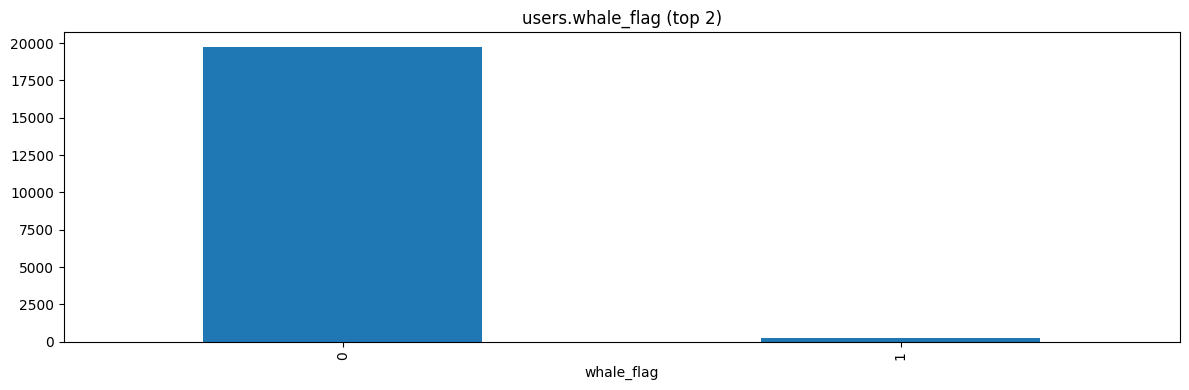

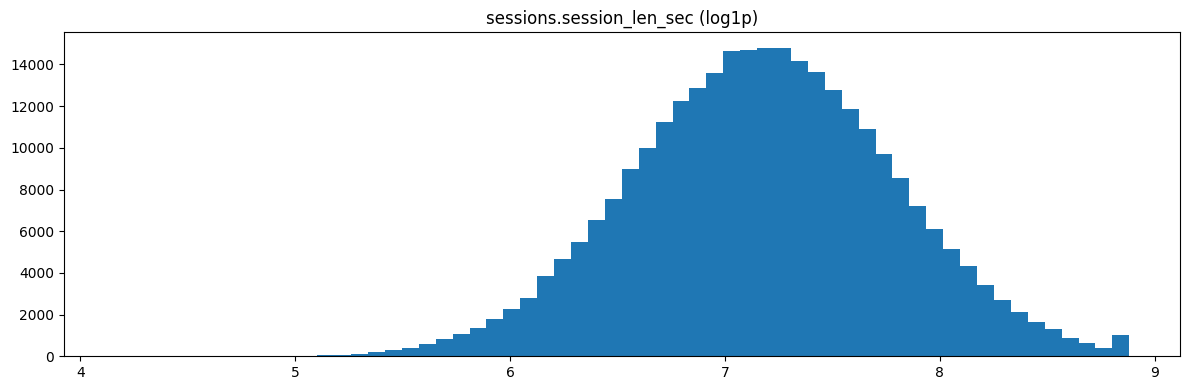

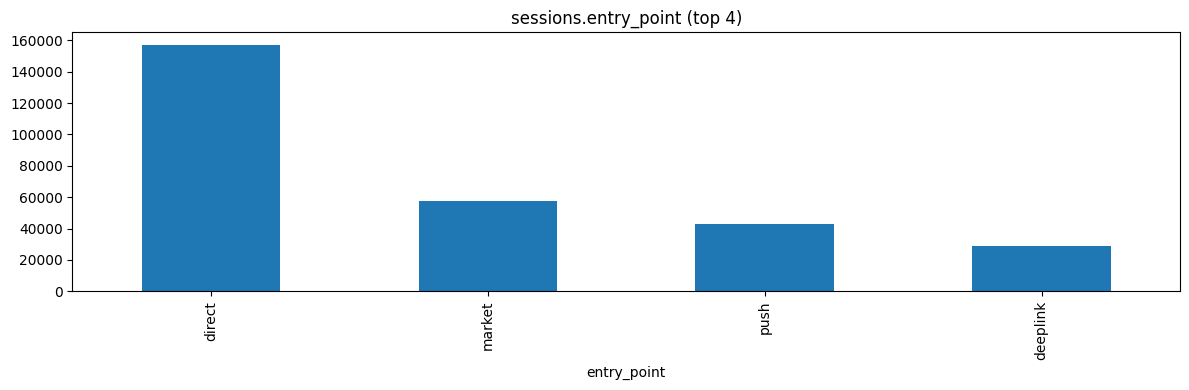

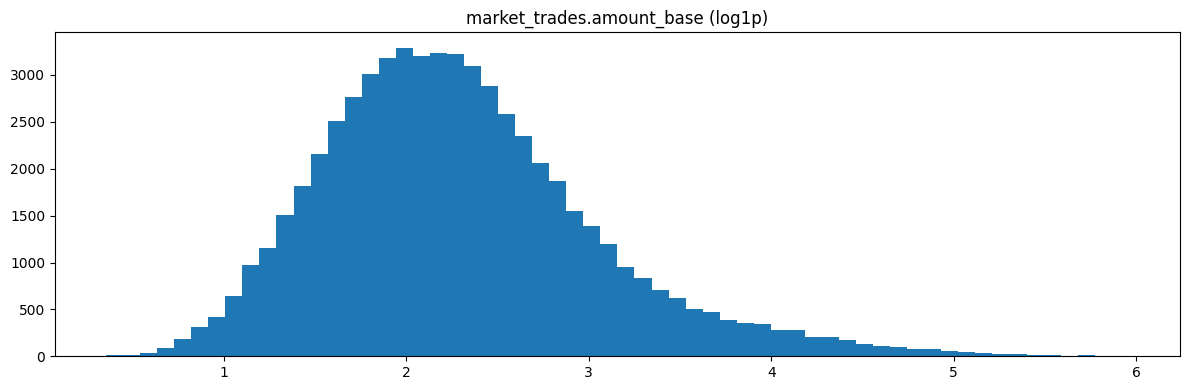

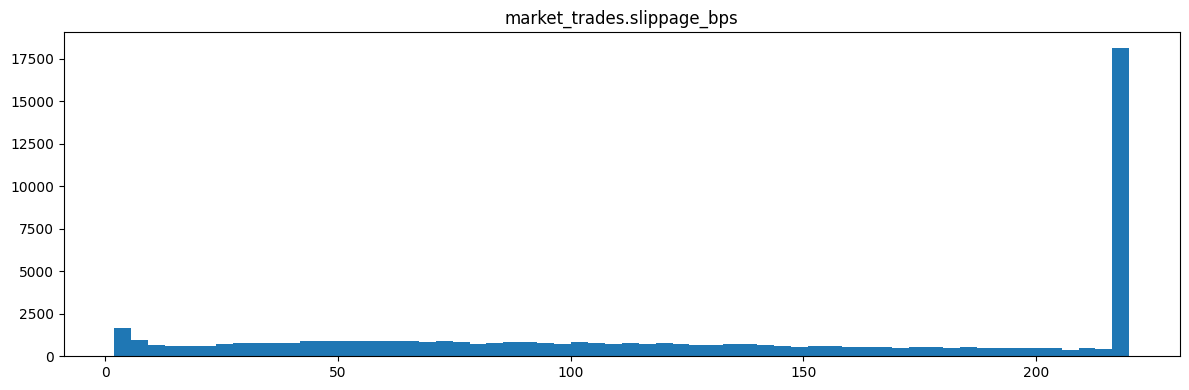

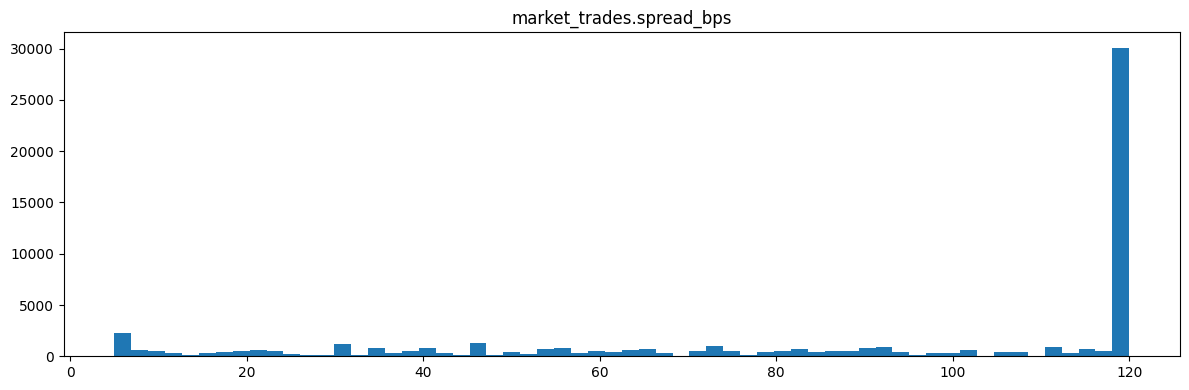

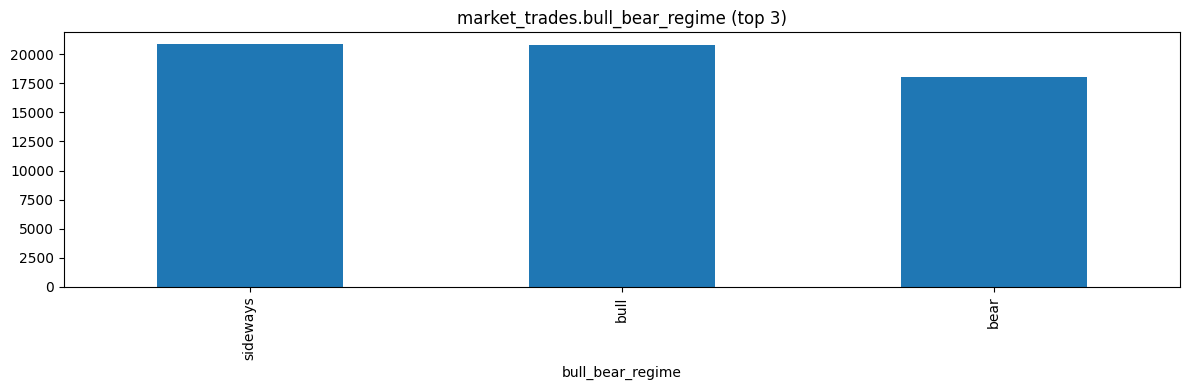

In [5]:
def plot_hist(s: pd.Series, title: str, bins: int = 60, log: bool = False):
    s = s.dropna()
    if s.empty:
        print(title, "- empty")
        return
    plt.figure(figsize=FIGSIZE)
    vals = np.log1p(s) if log else s
    plt.hist(vals, bins=bins)
    plt.title(title + (" (log1p)" if log else ""))
    plt.tight_layout()
    plt.show()

def plot_bar_counts(s: pd.Series, title: str, topn: int = MAX_CATS_SHOW):
    vc = s.astype("object").fillna("NA").value_counts().head(topn)
    plt.figure(figsize=FIGSIZE)
    vc.plot(kind="bar")
    plt.title(title + f" (top {len(vc)})")
    plt.tight_layout()
    plt.show()

# USERS
if users is not None:
    plot_bar_counts(users["acq_channel"], "users.acq_channel")
    plot_bar_counts(users["player_segment"], "users.player_segment")
    plot_hist(users["initial_deposit_usd"], "users.initial_deposit_usd", log=True)
    plot_bar_counts(users["whale_flag"], "users.whale_flag")

# SESSIONS
if sessions is not None:
    plot_hist(sessions["session_len_sec"], "sessions.session_len_sec", log=True)
    plot_bar_counts(sessions["entry_point"], "sessions.entry_point")

# MARKET
if market_trades is not None:
    plot_hist(market_trades["amount_base"], "market_trades.amount_base", log=True)
    plot_hist(market_trades["slippage_bps"], "market_trades.slippage_bps")
    plot_hist(market_trades["spread_bps"], "market_trades.spread_bps")
    plot_bar_counts(market_trades["bull_bear_regime"], "market_trades.bull_bear_regime")


> **Analytical Comment (EDA):**
Initial distribution analysis reveals 'heavy tails' in trading volumes and activity. Special attention should be paid to users in the top deciles (whales), as they generate the bulk of liquidity. Missing value checks confirm data quality for further econometric modeling.

## 3) Standard Product Metrics Block

- DAU / WAU / MAU
- Retention D1/D7/D30/D90 (cohort-based)
- Churn proxy (via inactivity window)
- Conversion (signup → first_session within N days)
- Session count / session length (daily)
- Funnel (from `funnel_events` or proxy)
- ARPU / ARPPU (via protocol revenue proxy from tax/fee)
- LTV per user (token revenue proxy)
- CAC (from `marketing_spend` + new users by channel)

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

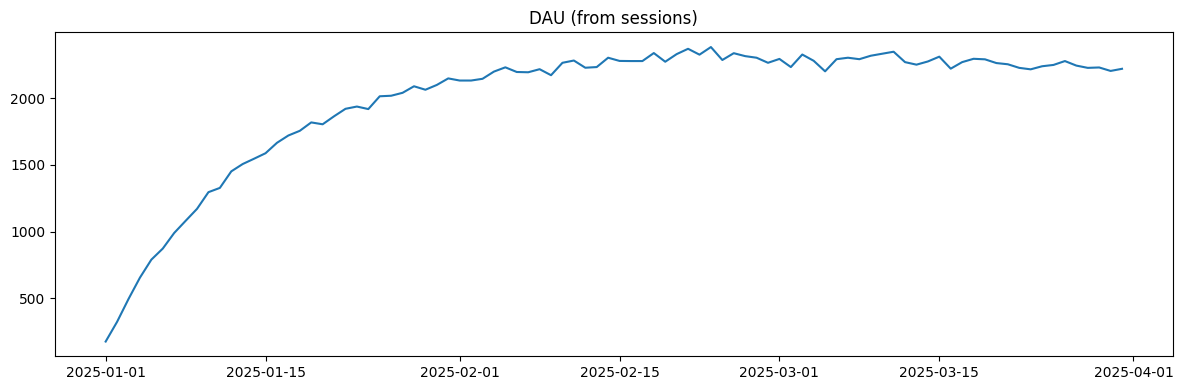

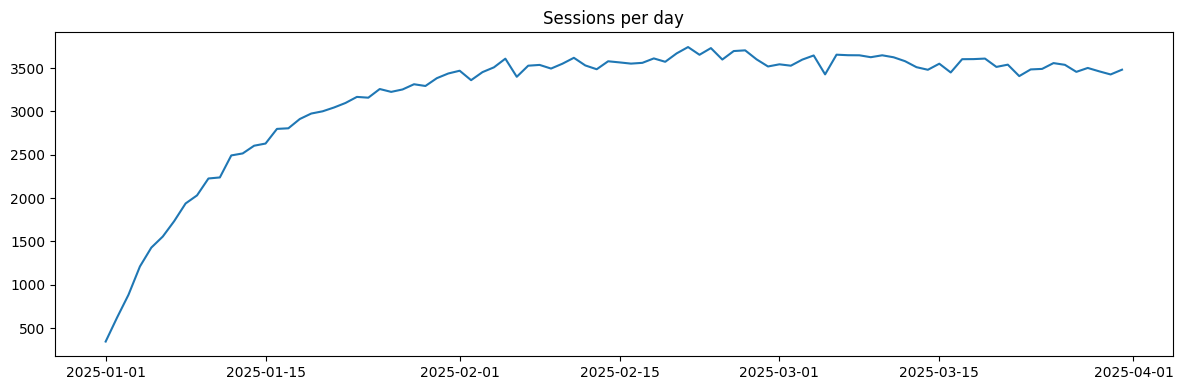

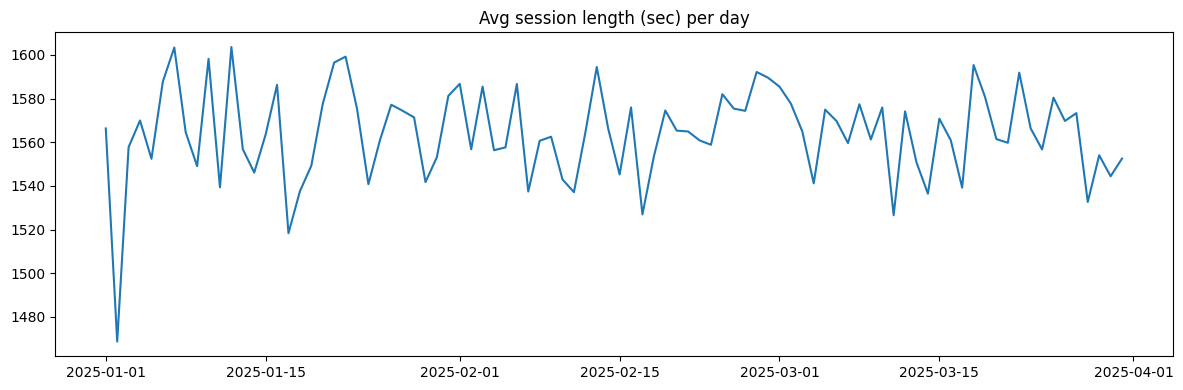

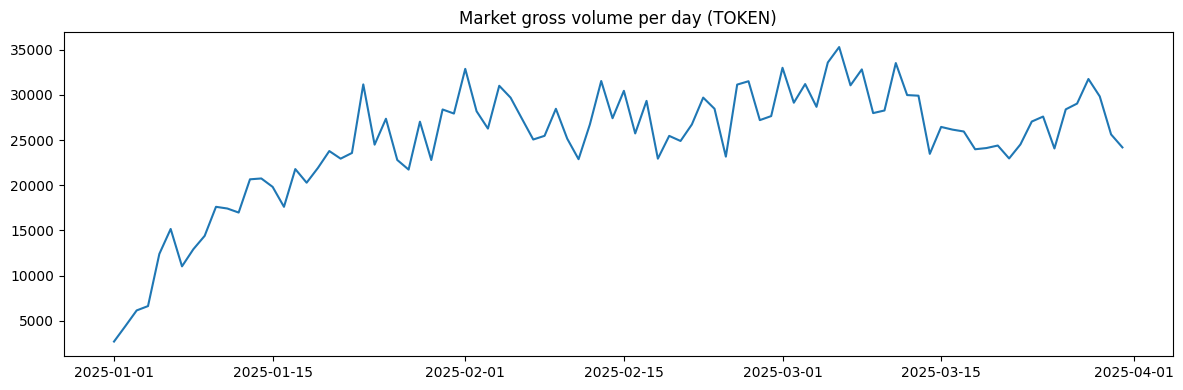

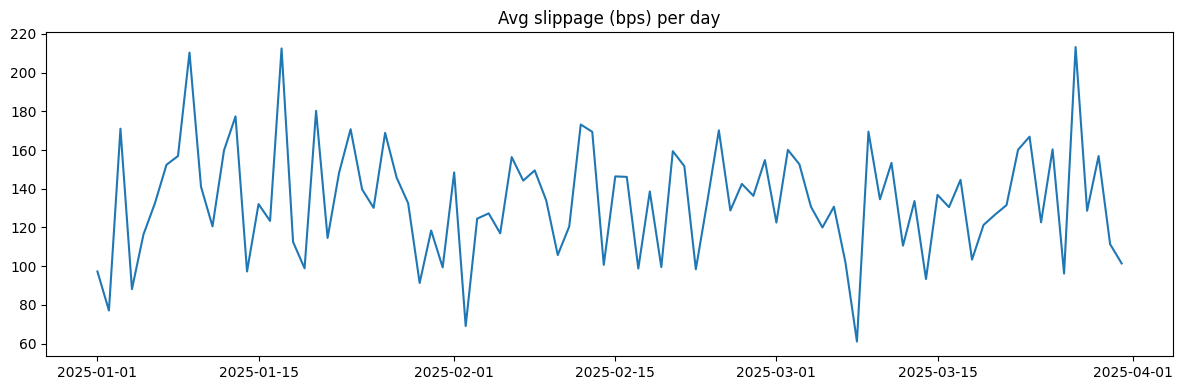

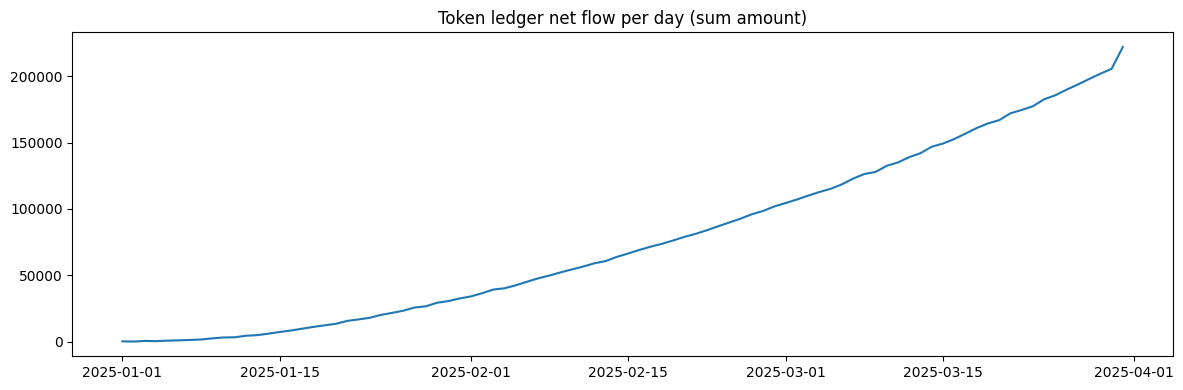

In [6]:
def add_day_col(df: pd.DataFrame, ts_col: str, out_col="day"):
    df[out_col] = pd.to_datetime(df[ts_col], errors="coerce").dt.floor("D")
    return df

# DAU + sessions/day
if sessions is not None:
    s = sessions.copy()
    s = add_day_col(s, "start_ts", "day")

    dau = s.groupby("day")["user_id"].nunique().rename("DAU").reset_index()
    plt.figure(figsize=FIGSIZE)
    plt.plot(dau["day"], dau["DAU"])
    plt.title("DAU (from sessions)")
    plt.tight_layout(); plt.show()

    sday = s.groupby("day").agg(
        sessions=("session_id","count"),
        avg_session_len=("session_len_sec","mean")
    ).reset_index()

    plt.figure(figsize=FIGSIZE)
    plt.plot(sday["day"], sday["sessions"])
    plt.title("Sessions per day")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=FIGSIZE)
    plt.plot(sday["day"], sday["avg_session_len"])
    plt.title("Avg session length (sec) per day")
    plt.tight_layout(); plt.show()

# Market volume / slippage / spread
if market_trades is not None:
    mt = market_trades.copy()
    mt = add_day_col(mt, "ts", "day")
    mt["gross_token"] = mt["amount_base"] * mt["price"]

    vol = mt.groupby("day").agg(
        trades=("trade_id","count"),
        trade_users=("maker_user_id","nunique"),
        gross=("gross_token","sum"),
        tax=("tax_amount","sum"),
        fee=("fee_amount","sum"),
        avg_slippage=("slippage_bps","mean"),
        avg_spread=("spread_bps","mean")
    ).reset_index()

    plt.figure(figsize=FIGSIZE)
    plt.plot(vol["day"], vol["gross"])
    plt.title("Market gross volume per day (TOKEN)")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=FIGSIZE)
    plt.plot(vol["day"], vol["avg_slippage"])
    plt.title("Avg slippage (bps) per day")
    plt.tight_layout(); plt.show()

# Token ledger netflow
if token_ledger is not None:
    tl = token_ledger.copy()
    tl = add_day_col(tl, "ts", "day")

    flow = tl.groupby("day").agg(
        tx_cnt=("ledger_id","count"),
        net_amount=("amount","sum"),
    ).reset_index()

    plt.figure(figsize=FIGSIZE)
    plt.plot(flow["day"], flow["net_amount"])
    plt.title("Token ledger net flow per day (sum amount)")
    plt.tight_layout(); plt.show()


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

## 4) Exclusive DeFi Metrics Block

- Token Velocity (volume / circulating_proxy)
- Net issuance / sinks-sources (reward vs taxes/fees/burn proxy)
- Resource Liquidity Ratio (sold / produced)
- Planet Development Index (PDI)
- Wealth distribution / concentration (Gini, top1/top5 shares)
- Yield-to-Engagement Ratio (YER)
- Smart Contract Usage Frequency (SCUF)
- Market Speculation Index (MSI)
- Whale Impact Score (WIS)
- NFT Utility Score (NUS)

> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

In [7]:
try:
    from IPython.display import display
except Exception:
    display = print

def _dt(s):
    return pd.to_datetime(s, errors="coerce")

def _floor_day(ts):
    return _dt(ts).dt.floor("D")

def _pick_col(df, candidates, required=True, df_name="df"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"{df_name}: не найдена ни одна из колонок {candidates}. Доступные: {list(df.columns)}")
    return None

def extract_base_from_instrument(x: str):
    if not isinstance(x, str):
        return x
    x = x.upper().strip()
    QUOTES = ["USDT", "USDC", "BUSD", "USD", "BTC", "ETH", "EUR", "TRY", "BRL", "GBP"]
    for q in QUOTES:
        if x.endswith(q) and len(x) > len(q):
            return x[:-len(q)]
    return x

def ensure_resource_key_in_trades(mt: pd.DataFrame):
    c = _pick_col(
        mt,
        ["resource", "resource_key", "asset_base", "base_asset", "asset", "token_symbol",
         "asset_exch", "instrument_exch", "symbol", "pair"],
        required=True,
        df_name="market_trades",
    )
    if c in ["instrument_exch", "symbol", "pair"]:
        mt["resource_key"] = mt[c].map(extract_base_from_instrument)
    else:
        mt["resource_key"] = mt[c].astype(str).str.upper()
    return mt

def gini(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    s = x.sum()
    if s == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / s) / n

def top_share(x, p=0.01):
    x = pd.Series(x).dropna()
    x = x[x >= 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.nan
    k = max(1, int(len(x) * p))
    return float(x.head(k).sum() / x.sum())

def _rolling_sum_by_user_day(df, user_col, day_col, val_col, window=7):
    d = df.sort_values([user_col, day_col]).copy()
    d[val_col] = pd.to_numeric(d[val_col], errors="coerce").fillna(0.0)
    d[f"{val_col}_{window}d"] = (
        d.groupby(user_col)[val_col]
         .rolling(window=window, min_periods=1)
         .sum()
         .reset_index(level=0, drop=True)
    )
    return d


> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

users cols: ['user_id', 'created_at', 'country', 'timezone', 'acq_channel', 'campaign_id', 'ad_group', 'device_os', 'client', 'app_version', 'wallet_type', 'chain_pref', 'referrer_user_id', 'is_kyc', 'player_segment', 'risk_profile', 'whale_flag', 'initial_deposit_usd']
sessions cols: ['session_id', 'user_id', 'start_ts', 'end_ts', 'session_len_sec', 'entry_point', 'net_latency_ms', 'crash_flag']
market_trades cols: ['trade_id', 'ts', 'order_id', 'maker_user_id', 'taker_user_id', 'asset_base', 'asset_quote', 'amount_base', 'price', 'fee_amount', 'tax_amount', 'slippage_bps', 'spread_bps', 'bull_bear_regime', 'user_7d_volume_bucket']
token_ledger cols: ['ledger_id', 'ts', 'user_id', 'tx_type', 'token_symbol', 'amount', 'chain', 'gas_fee_token', 'tx_hash']

Enriched tables:
- price_oracle: (450, 4)
- econ_events: (10, 6)
- resource_production_daily: (450, 3)
- planet_state_daily: (916272, 8)
- guild_membership: (11003, 3)
- guild_events: (23802, 3)
- nft_ownership: (10430, 3)
- nft_usage

,step,users_reached,conv_from_prev
0,signup,20000,NaN
1,first_session,20000,1.0
2,create_planet,20000,1.0
3,first_milestone,20000,1.0
4,first_claim,20000,1.0
5,first_trade,20000,1.0
6,first_stake,20000,1.0



=== Retention head ===


,cohort_day,cohort_size,ret_d1,ret_d7,ret_d30,ret_d90
0,2025-01-01,224,0.750000,0.406250,0.058036,0.0
1,2025-01-02,222,0.743243,0.450450,0.067568,0.0
2,2025-01-03,240,0.712500,0.475000,0.041667,0.0
3,2025-01-04,244,0.741803,0.430328,0.086066,0.0
4,2025-01-05,221,0.733032,0.470588,0.067873,0.0



=== DAU head ===


...

,day,whale_volume,total_volume,whale_volume_share,slippage_delta_whale_minus_other,spread_delta_whale_minus_other,WIS
0,2025-01-01,543.301432,2696.633602,0.201474,27.596026,12.267308,0.241337
1,2025-01-02,875.755358,4402.736592,0.198912,-18.071051,-13.014865,0.167826
2,2025-01-03,1660.231392,6142.682880,0.270278,24.914527,13.486527,0.308679
3,2025-01-04,0.000000,6622.910404,0.000000,0.000000,0.000000,0.000000
4,2025-01-05,4311.973533,12396.681906,0.347833,-10.860997,-1.882736,0.335089



=== GSI head ===


,guild_id,day,guild_events_cnt,members,GSI
0,1,2025-01-02,4,556,10.175776
1,1,2025-01-03,3,556,8.764937
2,1,2025-01-05,10,556,15.160849
3,1,2025-01-06,6,556,12.303144
4,1,2025-01-07,9,556,14.558244



=== NUS head ===


,user_id,nft_owned,nft_used_distinct,nft_uses_total,NUS
0,3,3,1.0,1.0,0.333333
1,4,3,3.0,8.0,2.666667
2,7,2,2.0,5.0,2.500000
3,12,2,2.0,5.0,2.500000
4,14,1,1.0,6.0,6.000000


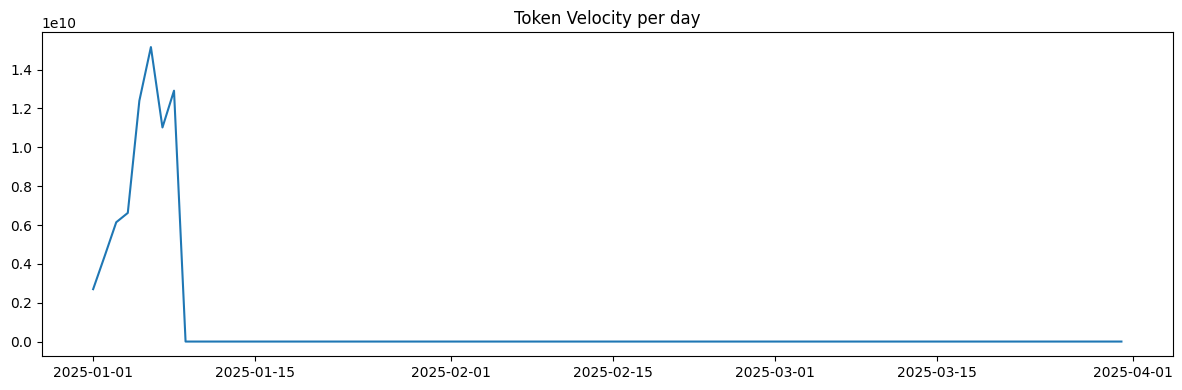

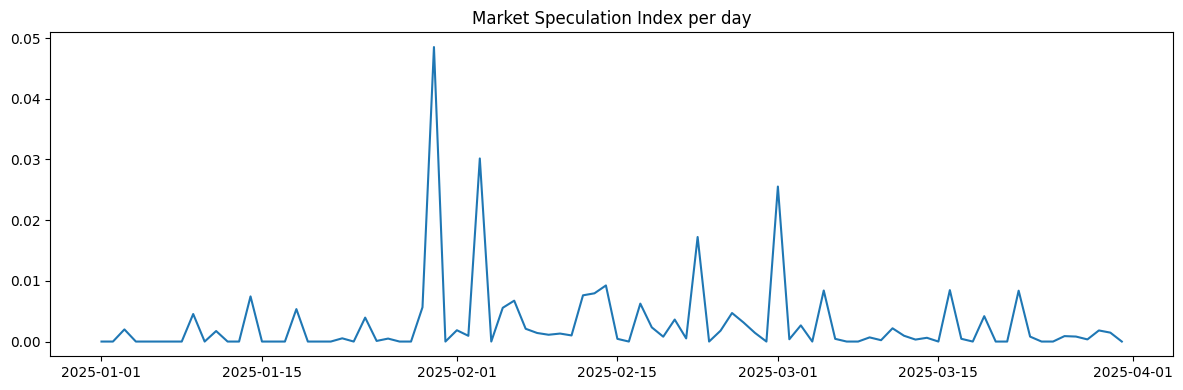

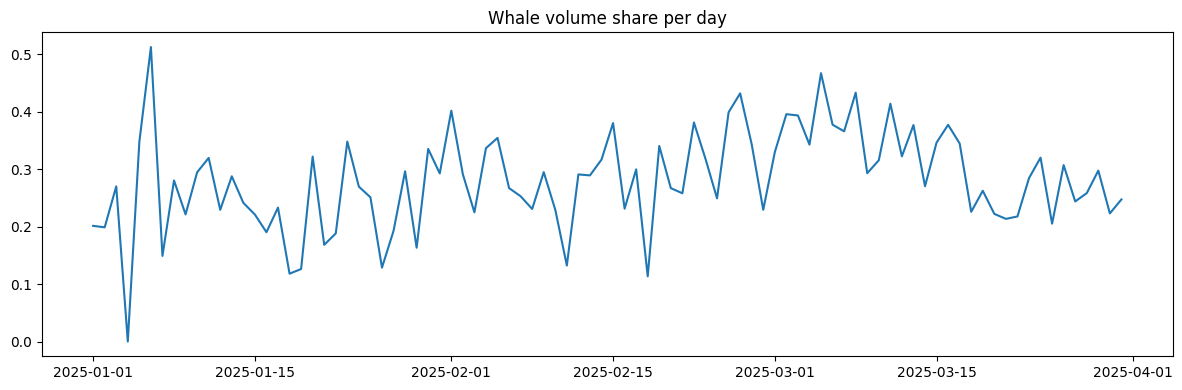


Sanity: CAC day dtype: datetime64[ns]
Sanity: WIS cols: ['day', 'whale_volume', 'total_volume', 'whale_volume_share', 'slippage_delta_whale_minus_other', 'spread_delta_whale_minus_other', 'WIS']


In [8]:
try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_SEED = 42

def _dt(x):
    return pd.to_datetime(x, errors="coerce")

def _floor_day(x):
    """
    Works for Series and scalars.
    """
    x = _dt(x)
    if isinstance(x, pd.Series):
        return x.dt.floor("D")
    if pd.isna(x):
        return pd.NaT
    return pd.Timestamp(x).floor("D")

def _pick_col(df, candidates, required=True, df_name="df"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"{df_name}: не найдена ни одна из колонок {candidates}. Доступные: {list(df.columns)}")
    return None

def extract_base_from_instrument(x: str):
    if not isinstance(x, str):
        return x
    x = x.upper().strip()
    QUOTES = ["USDT","USDC","BUSD","USD","BTC","ETH","EUR","TRY","BRL","GBP"]
    for q in QUOTES:
        if x.endswith(q) and len(x) > len(q):
            return x[:-len(q)]
    return x

def ensure_resource_key_in_trades(mt: pd.DataFrame):
    c = _pick_col(
        mt,
        ["resource","resource_key","asset_base","base_asset","asset","token_symbol","asset_exch","instrument_exch","symbol","pair"],
        required=True,
        df_name="market_trades",
    )
    if c in ["instrument_exch","symbol","pair"]:
        mt["resource_key"] = mt[c].map(extract_base_from_instrument)
    else:
        mt["resource_key"] = mt[c].astype(str).str.upper()
    return mt

def gini(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    s = x.sum()
    if s == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / s) / n

def top_share(x, p=0.01):
    x = pd.Series(x).dropna()
    x = x[x >= 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.nan
    k = max(1, int(len(x) * p))
    return float(x.head(k).sum() / x.sum())

def _rolling_sum_by_user_day(df, user_col, day_col, val_col, window=7):
    d = df.sort_values([user_col, day_col]).copy()
    d[val_col] = pd.to_numeric(d[val_col], errors="coerce").fillna(0.0)
    d[f"{val_col}_{window}d"] = (
        d.groupby(user_col)[val_col]
         .rolling(window=window, min_periods=1)
         .sum()
         .reset_index(level=0, drop=True)
    )
    return d

# =========================
# 0) Validate required frames
# =========================
need = ["users","sessions","market_trades","token_ledger"]
missing = [n for n in need if n not in globals() or globals()[n] is None]
if missing:
    raise ValueError(f"Не найдены датафреймы: {missing}")

print("users cols:", list(users.columns))
print("sessions cols:", list(sessions.columns))
print("market_trades cols:", list(market_trades.columns))
print("token_ledger cols:", list(token_ledger.columns))

# 1) Enrich optional tables

def enrich_optional_tables(users, sessions, market_trades, token_ledger, seed=42):
    rng = np.random.default_rng(seed)

    u = users.copy()
    s = sessions.copy()
    mt = market_trades.copy()
    tl = token_ledger.copy()

    u["created_at"] = _dt(u["created_at"])
    s["start_ts"] = _dt(s["start_ts"])
    s["end_ts"] = _dt(s["end_ts"])
    mt["ts"] = _dt(mt["ts"])
    tl["ts"] = _dt(tl["ts"])

    s["day"] = _floor_day(s["start_ts"])
    mt["day"] = _floor_day(mt["ts"])
    tl["day"] = _floor_day(tl["ts"])

    mt = ensure_resource_key_in_trades(mt)

    day_min = min(u["created_at"].min(), s["day"].min(), mt["day"].min(), tl["day"].min())
    day_max = max(u["created_at"].max(), s["day"].max(), mt["day"].max(), tl["day"].max())
    day_min = pd.Timestamp(day_min).floor("D")
    day_max = pd.Timestamp(day_max).floor("D")
    days = pd.date_range(day_min, day_max, freq="D")

    resources = sorted(mt["resource_key"].dropna().unique().tolist())
    if not resources:
        resources = ["ORE","CRYSTAL","GAS","WATER"]

    # --- price_oracle_daily: day x resource ---
    mt["gross_token"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0) * pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)

    # VWAP without groupby.apply (faster + no warning)
    agg = mt.groupby(["day","resource_key"], as_index=False).agg(
        gross_sum=("gross_token","sum"),
        amt_sum=("amount_base","sum"),
    )
    agg["price_token"] = agg["gross_sum"] / agg["amt_sum"].replace(0, np.nan)
    vwap = agg[["day","resource_key","price_token"]]

    grid = pd.MultiIndex.from_product([days, resources], names=["day","resource_key"]).to_frame(index=False)
    po = grid.merge(vwap, on=["day","resource_key"], how="left").sort_values(["resource_key","day"])

    po["price_token"] = po.groupby("resource_key")["price_token"].ffill().bfill()
    po["price_token"] = po["price_token"].fillna(po["price_token"].median())

    po["log_ret"] = np.log(po["price_token"]).groupby(po["resource_key"]).diff()
    po["volatility"] = po.groupby("resource_key")["log_ret"].rolling(7, min_periods=2).std().reset_index(level=0, drop=True)
    po["volatility"] = po["volatility"].fillna(po["volatility"].median()).fillna(0.02)

    price_oracle = po.rename(columns={"resource_key":"resource"})[["day","resource","price_token","volatility"]]

    # --- econ_events ---
    n_events = min(12, max(4, len(resources)*2))
    ev_rows = []
    for i in range(n_events):
        res = rng.choice(resources)
        start = rng.choice(days)
        dur = int(rng.integers(2, 9))
        end = min(start + pd.Timedelta(days=dur), days[-1])
        ev_rows.append({
            "event_id": i+1,
            "event_type": rng.choice(["supply_shock","demand_spike","oracle_glitch","chain_congestion","governance_vote"]),
            "affected_resource": res,
            "start_ts": pd.Timestamp(start) + pd.Timedelta(hours=int(rng.integers(0, 12))),
            "end_ts": pd.Timestamp(end) + pd.Timedelta(hours=int(rng.integers(12, 24))),
            "intensity": float(np.round(rng.uniform(0.5, 2.0), 3)),
        })
    econ_events = pd.DataFrame(ev_rows)
    econ_events["start_ts"] = _dt(econ_events["start_ts"])
    econ_events["end_ts"] = _dt(econ_events["end_ts"])
    econ_events["start_day"] = _floor_day(econ_events["start_ts"])
    econ_events["end_day"] = _floor_day(econ_events["end_ts"])

    # --- resource_production_daily ---
    sold = mt.groupby(["day","resource_key"], as_index=False)["amount_base"].sum().rename(columns={"amount_base":"sold_amount"})
    base = grid.merge(sold, on=["day","resource_key"], how="left").fillna({"sold_amount":0.0})

    res_base = {r: rng.uniform(2000, 12000) for r in resources}
    res_liq = {r: rng.uniform(0.3, 1.1) for r in resources}

    def shock_mult(day, res):
        sub = econ_events[econ_events["affected_resource"] == res]
        if sub.empty:
            return 1.0
        active = sub[(sub["start_day"] <= day) & (sub["end_day"] >= day)]
        if active.empty:
            return 1.0
        return float(1.0 + 0.15 * active["intensity"].max())

    base["baseline"] = base["resource_key"].map(res_base)
    base["liq"] = base["resource_key"].map(res_liq)
    base["shock_mult"] = [shock_mult(d, r) for d, r in zip(base["day"], base["resource_key"])]

    noise = rng.normal(0, 0.15, size=len(base))
    base["produced_amount"] = (base["baseline"] * base["shock_mult"] * (1 + noise) + base["sold_amount"] / base["liq"]).clip(lower=0)
    resource_production_daily = base.rename(columns={"resource_key":"resource"})[["day","resource","produced_amount"]]

    # --- planet_state_daily (user-day progression) ---
    sess_ud = s.groupby(["user_id","day"], as_index=False).agg(
        sessions_cnt=("session_id","count"),
        session_time=("session_len_sec","sum"),
    )
    sess_ud["session_time"] = sess_ud["session_time"].fillna(0.0)

    rew_ud = tl[tl["tx_type"]=="reward"].groupby(["user_id","day"], as_index=False)["amount"].sum().rename(columns={"amount":"rewards"})
    ud = sess_ud.merge(rew_ud, on=["user_id","day"], how="left").fillna({"rewards":0.0})

    # user-days from signup to end
    user_days = []
    for uid, cts in u[["user_id","created_at"]].itertuples(index=False):
        start = pd.Timestamp(cts).floor("D")
        start = max(start, days[0])
        for d in days[days >= start]:
            user_days.append((int(uid), pd.Timestamp(d)))
    ud_grid = pd.DataFrame(user_days, columns=["user_id","day"])

    ud = ud_grid.merge(ud, on=["user_id","day"], how="left").fillna({"sessions_cnt":0,"session_time":0.0,"rewards":0.0})
    ud = ud.sort_values(["user_id","day"])

    ud["eng"] = np.log1p(ud["session_time"]) + 0.3*np.log1p(ud["sessions_cnt"]) + 0.2*np.log1p(ud["rewards"])
    ud["eng_cum"] = ud.groupby("user_id")["eng"].cumsum()

    ud["buildings_level"] = np.floor(1 + ud["eng_cum"] / 8.0).clip(upper=80)
    ud["tech_tier"] = np.floor(1 + ud["eng_cum"] / 35.0).clip(upper=10)
    ud["storage"] = (1000 + 60*ud["buildings_level"] + 200*ud["tech_tier"]).astype(float)
    ud["rare_assets"] = np.floor((ud["tech_tier"]-1).clip(lower=0) * rng.uniform(0.2, 0.5) + rng.poisson(0.2, size=len(ud))).clip(lower=0)
    ud["resource_output"] = (10*ud["buildings_level"]*(1 + 0.08*ud["tech_tier"]) + rng.normal(0, 8, size=len(ud))).clip(lower=0)

    planet_state_daily = ud[["user_id","day","buildings_level","resource_output","tech_tier","storage","rare_assets"]].copy()
    planet_state_daily["planet_id"] = planet_state_daily["user_id"].astype(int)

    # --- guilds ---
    n_guilds = 20
    guild_ids = np.arange(1, n_guilds+1)
    gm_rows = []
    for r in u.itertuples(index=False):
        if rng.random() > 0.55:
            continue
        gid = int(rng.choice(guild_ids))
        gm_rows.append({
            "user_id": int(r.user_id),
            "guild_id": gid,
            "joined_at": pd.Timestamp(r.created_at) + pd.Timedelta(days=int(rng.integers(0, 14)))
        })
    guild_membership = pd.DataFrame(gm_rows)

    if not guild_membership.empty:
        user2guild = guild_membership.drop_duplicates("user_id")[["user_id","guild_id"]]
        g_sess = ud.merge(user2guild, on="user_id", how="inner").groupby(["guild_id","day"], as_index=False)["sessions_cnt"].sum()

        ge_rows = []
        for row in g_sess.itertuples(index=False):
            lam = max(0.2, 0.15 * float(row.sessions_cnt))
            k = int(rng.poisson(lam))
            for _ in range(k):
                ge_rows.append({
                    "guild_id": int(row.guild_id),
                    "ts": pd.Timestamp(row.day) + pd.Timedelta(seconds=int(rng.integers(0, 86400))),
                    "event_type": rng.choice(["joint_build","guild_mission","resource_convoy","staking_pool_vote","market_coordination"]),
                })
        guild_events = pd.DataFrame(ge_rows)
    else:
        guild_events = pd.DataFrame(columns=["guild_id","ts","event_type"])

    # --- nft ---
    nft_rows = []
    usage_rows = []
    nft_id_counter = 1
    for r in u.itertuples(index=False):
        uid = int(r.user_id)
        whale = int(getattr(r, "whale_flag", 0))
        p_own = 0.25 + 0.35*whale
        if rng.random() > p_own:
            continue
        n_own = int(rng.integers(1, 4 + 3*whale))
        owned_ids = []
        for _ in range(n_own):
            owned_ids.append(nft_id_counter)
            nft_rows.append({
                "user_id": uid,
                "nft_id": nft_id_counter,
                "acquired_ts": pd.Timestamp(r.created_at) + pd.Timedelta(days=int(rng.integers(0, 40)))
            })
            nft_id_counter += 1
        if owned_ids:
            k_use = int(rng.integers(0, 10 + 10*whale))
            for _ in range(k_use):
                nft = int(rng.choice(owned_ids))
                d = rng.choice(days)
                usage_rows.append({
                    "user_id": uid,
                    "nft_id": nft,
                    "ts": pd.Timestamp(d) + pd.Timedelta(seconds=int(rng.integers(0, 86400))),
                    "use_type": rng.choice(["boost_prod","discount_fee","rare_drop","storage_expand","craft_bonus"]),
                })
    nft_ownership = pd.DataFrame(nft_rows)
    nft_usage_events = pd.DataFrame(usage_rows)

    # --- funnel_events ---
    first_sess = s.groupby("user_id", as_index=False)["start_ts"].min().rename(columns={"start_ts":"first_session_ts"})
    first_trade = mt.groupby("maker_user_id", as_index=False)["ts"].min().rename(columns={"maker_user_id":"user_id","ts":"first_trade_ts"})
    first_stake = tl[tl["tx_type"]=="stake"].groupby("user_id", as_index=False)["ts"].min().rename(columns={"ts":"first_stake_ts"})

    fe = u[["user_id","created_at"]].merge(first_sess, on="user_id", how="left") \
                                   .merge(first_trade, on="user_id", how="left") \
                                   .merge(first_stake, on="user_id", how="left")

    fe_rows = []
    for row in fe.itertuples(index=False):
        uid = int(row.user_id)
        created = pd.Timestamp(row.created_at)

        fe_rows.append({"user_id":uid, "ts":created, "event_name":"signup"})
        fs = row.first_session_ts if not pd.isna(row.first_session_ts) else created + pd.Timedelta(hours=int(rng.integers(1, 72)))
        fs = pd.Timestamp(fs)
        fe_rows.append({"user_id":uid, "ts":fs, "event_name":"first_session"})
        fe_rows.append({"user_id":uid, "ts":fs+pd.Timedelta(minutes=int(rng.integers(5, 240))), "event_name":"create_planet"})
        fe_rows.append({"user_id":uid, "ts":fs+pd.Timedelta(hours=int(rng.integers(4, 120))), "event_name":"first_milestone"})

        first_reward = tl[(tl["user_id"]==uid) & (tl["tx_type"]=="reward")]["ts"].min()
        if pd.isna(first_reward):
            first_reward = fs + pd.Timedelta(hours=int(rng.integers(6, 240)))
        first_reward = pd.Timestamp(first_reward)
        fe_rows.append({"user_id":uid, "ts":first_reward, "event_name":"first_claim"})

        ft = row.first_trade_ts if not pd.isna(row.first_trade_ts) else first_reward + pd.Timedelta(hours=int(rng.integers(6, 200)))
        ft = pd.Timestamp(ft)
        fe_rows.append({"user_id":uid, "ts":ft, "event_name":"first_trade"})

        stk = row.first_stake_ts if not pd.isna(row.first_stake_ts) else ft + pd.Timedelta(hours=int(rng.integers(12, 260)))
        stk = pd.Timestamp(stk)
        fe_rows.append({"user_id":uid, "ts":stk, "event_name":"first_stake"})

    funnel_events = pd.DataFrame(fe_rows)

    # --- marketing_spend ---
    marketing_spend = None
    if "acq_channel" in u.columns:
        nu = u.copy()
        nu["cohort_day"] = _floor_day(nu["created_at"])
        nu = nu.groupby(["cohort_day","acq_channel"], as_index=False)["user_id"].nunique().rename(columns={"user_id":"new_users"})
        spend_rows = []
        for row in nu.itertuples(index=False):
            base_cac = rng.uniform(2.0, 12.0)
            spend = float(row.new_users * base_cac * rng.uniform(0.7, 1.4))
            spend_rows.append({"day": pd.Timestamp(row.cohort_day), "acq_channel": row.acq_channel, "spend": spend})
        marketing_spend = pd.DataFrame(spend_rows)

    return {
        "price_oracle": price_oracle,
        "econ_events": econ_events.drop(columns=["start_day","end_day"]),
        "resource_production_daily": resource_production_daily,
        "planet_state_daily": planet_state_daily,
        "guild_membership": guild_membership,
        "guild_events": guild_events,
        "nft_ownership": nft_ownership,
        "nft_usage_events": nft_usage_events,
        "funnel_events": funnel_events,
        "marketing_spend": marketing_spend,
    }

enriched = enrich_optional_tables(users, sessions, market_trades, token_ledger, seed=RANDOM_SEED)

# expose as globals
price_oracle = enriched["price_oracle"]
econ_events = enriched["econ_events"]
resource_production_daily = enriched["resource_production_daily"]
planet_state_daily = enriched["planet_state_daily"]
guild_membership = enriched["guild_membership"]
guild_events = enriched["guild_events"]
nft_ownership = enriched["nft_ownership"]
nft_usage_events = enriched["nft_usage_events"]
funnel_events = enriched["funnel_events"]
marketing_spend = enriched["marketing_spend"]

print("\nEnriched tables:")
for k, v in enriched.items():
    print(f"- {k}: {None if v is None else v.shape}")

# 2) Standard metrics

def compute_standard_metrics(
    users: pd.DataFrame,
    sessions: pd.DataFrame,
    market_trades: pd.DataFrame = None,
    token_ledger: pd.DataFrame = None,
    marketing_spend: pd.DataFrame = None,
    funnel_events: pd.DataFrame = None,
    retention_days=(1, 7, 30, 90),
    conv_days=7,
    churn_inactive_days=14,
):
    u = users.copy()
    s = sessions.copy()

    user_id_col = _pick_col(u, ["user_id","id"], df_name="users")
    created_col = _pick_col(u, ["created_at","signup_ts","registered_at","reg_ts"], df_name="users")

    sess_user_col = _pick_col(s, ["user_id","id_user"], df_name="sessions")
    sess_ts_col   = _pick_col(s, ["start_ts","ts","session_start_ts"], df_name="sessions")
    sess_len_col  = _pick_col(s, ["session_len_sec","duration_sec","len_sec"], required=False, df_name="sessions")

    u[created_col] = _dt(u[created_col])
    u["cohort_day"] = _floor_day(u[created_col])

    s[sess_ts_col] = _dt(s[sess_ts_col])
    s["day"] = _floor_day(s[sess_ts_col])

    # DAU/WAU/MAU
    dau = s.groupby("day")[sess_user_col].nunique().reset_index(name="DAU")
    s["week"] = s["day"].dt.to_period("W").dt.start_time
    s["month"] = s["day"].dt.to_period("M").dt.start_time
    wau = s.groupby("week")[sess_user_col].nunique().reset_index(name="WAU")
    mau = s.groupby("month")[sess_user_col].nunique().reset_index(name="MAU")

    # Retention
    user_day_active = s.groupby([sess_user_col,"day"]).size().reset_index(name="active_flag")
    user_day_active["active_flag"] = 1
    user_day_active = user_day_active.rename(columns={sess_user_col:user_id_col})

    cohort_sizes = u.groupby("cohort_day")[user_id_col].nunique().reset_index(name="cohort_size")

    retention = cohort_sizes.copy()
    for d in retention_days:
        tmp = u[[user_id_col,"cohort_day"]].copy()
        tmp["target_day"] = tmp["cohort_day"] + pd.Timedelta(days=int(d))
        tmp = tmp.merge(
            user_day_active[[user_id_col,"day","active_flag"]],
            left_on=[user_id_col,"target_day"],
            right_on=[user_id_col,"day"],
            how="left"
        )
        tmp["ret"] = tmp["active_flag"].fillna(0).astype(int)
        ret = tmp.groupby("cohort_day")["ret"].mean().reset_index(name=f"ret_d{d}")
        retention = retention.merge(ret, on="cohort_day", how="left")

    # Churn proxy
    last_active = user_day_active.groupby(user_id_col)["day"].max().reset_index(name="last_active_day")
    last_active["churn_day"] = last_active["last_active_day"] + pd.Timedelta(days=int(churn_inactive_days))
    churn_daily = last_active.groupby("churn_day")[user_id_col].nunique().reset_index(name="churned_users").rename(columns={"churn_day":"day"})
    active_daily = user_day_active.groupby("day")[user_id_col].nunique().reset_index(name="active_users")
    churn = churn_daily.merge(active_daily, on="day", how="left")
    churn["active_users"] = churn["active_users"].fillna(0)
    churn["churn_rate_proxy"] = churn["churned_users"] / churn["active_users"].replace(0, np.nan)

    # Session count daily
    sess_cnt = s.groupby([sess_user_col,"day"]).size().reset_index(name="sessions_cnt").rename(columns={sess_user_col:user_id_col})
    sess_agg_daily = sess_cnt.groupby("day").agg(
        avg_sessions_per_user=("sessions_cnt","mean"),
        median_sessions_per_user=("sessions_cnt","median"),
        total_sessions=("sessions_cnt","sum"),
        users=(user_id_col,"nunique"),
    ).reset_index()

    # Session length daily
    if sess_len_col and sess_len_col in s.columns:
        s[sess_len_col] = pd.to_numeric(s[sess_len_col], errors="coerce")
        sess_len_daily = (
            s.groupby("day")[sess_len_col]
             .agg(
                 avg_session_len="mean",
                 median_session_len="median",
                 p90_session_len=lambda x: x.quantile(0.90),
                 sessions_with_len="count",
             )
             .reset_index()
        )
    else:
        sess_len_daily = None

    # Conversion
    first_session = s.groupby(sess_user_col)[sess_ts_col].min().reset_index(name="first_session_ts").rename(columns={sess_user_col:user_id_col})
    conv = u[[user_id_col, created_col]].merge(first_session, on=user_id_col, how="left")
    conv["days_to_first_session"] = (conv["first_session_ts"] - conv[created_col]).dt.total_seconds() / 86400.0
    conv["converted"] = (conv["days_to_first_session"] <= conv_days).fillna(False).astype(int)
    conversion = {
        "conv_days": conv_days,
        "conversion_rate": float(conv["converted"].mean()),
        "converted_users": int(conv["converted"].sum()),
        "new_users": int(len(conv)),
        "median_days_to_first_session": float(conv["days_to_first_session"].median(skipna=True)),
    }

    # ARPU/ARPPU/LTV
    arpu_daily = None
    arppu_daily = None
    ltv_user = None
    if token_ledger is not None:
        tl = token_ledger.copy()
        tl["ts"] = _dt(_pick_col(tl, ["ts","timestamp"], df_name="token_ledger"))
        tl["day"] = _floor_day(tl["ts"])
        tl_user = _pick_col(tl, ["user_id","id_user"], df_name="token_ledger")
        tx_type = _pick_col(tl, ["tx_type","type"], df_name="token_ledger")
        amt_col = _pick_col(tl, ["amount","amt"], df_name="token_ledger")

        rev_types = ["tax","market_fee","fee"]
        tl["is_rev"] = tl[tx_type].isin(rev_types)
        tl["rev_token"] = np.where(tl["is_rev"], -pd.to_numeric(tl[amt_col], errors="coerce"), 0.0)
        tl["rev_token"] = tl["rev_token"].fillna(0.0).clip(lower=0)

        rev_daily = tl.groupby("day")["rev_token"].sum().reset_index(name="revenue_token")

        arpu_daily = rev_daily.merge(dau, on="day", how="left")
        arpu_daily["DAU"] = arpu_daily["DAU"].fillna(0)
        arpu_daily["ARPU_token"] = arpu_daily["revenue_token"] / arpu_daily["DAU"].replace(0, np.nan)

        paying_daily = tl.loc[tl["rev_token"] > 0].groupby("day")[tl_user].nunique().reset_index(name="paying_users")
        arppu_daily = rev_daily.merge(paying_daily, on="day", how="left")
        arppu_daily["paying_users"] = arppu_daily["paying_users"].fillna(0)
        arppu_daily["ARPPU_token"] = arppu_daily["revenue_token"] / arppu_daily["paying_users"].replace(0, np.nan)

        ltv_user = tl.groupby(tl_user)["rev_token"].sum().reset_index(name="LTV_token").rename(columns={tl_user:user_id_col})
        ltv_user = ltv_user.merge(u[[user_id_col]], on=user_id_col, how="right").fillna({"LTV_token":0.0})

    # Funnel
    funnel = None
    if funnel_events is not None:
        fe = funnel_events.copy()
        fe_user = _pick_col(fe, ["user_id","id_user"], df_name="funnel_events")
        fe_ev = _pick_col(fe, ["event_name","event"], df_name="funnel_events")
        steps = ["signup","first_session","create_planet","first_milestone","first_claim","first_trade","first_stake"]
        reach = [(st, fe.loc[fe[fe_ev]==st, fe_user].nunique()) for st in steps]
        funnel = pd.DataFrame(reach, columns=["step","users_reached"])
        funnel["conv_from_prev"] = funnel["users_reached"] / funnel["users_reached"].shift(1)

    # CAC  
    cac = None
    if marketing_spend is not None and "acq_channel" in u.columns:
        ms = marketing_spend.copy()
        day_col = _pick_col(ms, ["day","ts","date"], df_name="marketing_spend")
        ms["day"] = _floor_day(ms[day_col])

        ch_col = _pick_col(ms, ["acq_channel","channel"], df_name="marketing_spend")
        spend_col = _pick_col(ms, ["spend","cost","usd_spend"], df_name="marketing_spend")
        ms[spend_col] = pd.to_numeric(ms[spend_col], errors="coerce").fillna(0.0)

        new_users_by_day_ch = u.copy()
        new_users_by_day_ch["day"] = u["cohort_day"]
        new_users_by_day_ch = new_users_by_day_ch.groupby(["day","acq_channel"])[user_id_col].nunique().reset_index(name="new_users")

        cac = ms.groupby(["day",ch_col])[spend_col].sum().reset_index(name="spend").merge(
            new_users_by_day_ch.rename(columns={"acq_channel":ch_col}),
            on=["day",ch_col],
            how="left"
        )
        cac["new_users"] = cac["new_users"].fillna(0)
        cac["CAC"] = cac["spend"] / cac["new_users"].replace(0, np.nan)

    return {
        "dau": dau,
        "wau": wau,
        "mau": mau,
        "retention": retention,
        "churn_proxy": churn,
        "arpu_daily": arpu_daily,
        "arppu_daily": arppu_daily,
        "ltv_user": ltv_user,
        "session_count_daily": sess_agg_daily,
        "session_len_daily": sess_len_daily,
        "conversion": conversion,
        "funnel": funnel,
        "cac": cac,
    }

# 3) DeFi metrics (WIS already robust; also fixed day parsing for RLR/PDI)
def compute_defi_metrics(
    market_trades: pd.DataFrame,
    token_ledger: pd.DataFrame,
    sessions: pd.DataFrame = None,
    resource_production_daily: pd.DataFrame = None,
    planet_state_daily: pd.DataFrame = None,
    guild_membership: pd.DataFrame = None,
    guild_events: pd.DataFrame = None,
    nft_ownership: pd.DataFrame = None,
    nft_usage_events: pd.DataFrame = None,
):
    mt = market_trades.copy()
    mt["ts"] = _dt(mt["ts"])
    mt["day"] = _floor_day(mt["ts"])
    mt = ensure_resource_key_in_trades(mt)

    mt["amount_base"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0)
    mt["price"] = pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)
    mt["gross_token"] = mt["amount_base"] * mt["price"]

    tl = token_ledger.copy()
    tl["ts"] = _dt(tl["ts"])
    tl["day"] = _floor_day(tl["ts"])
    tl["amount"] = pd.to_numeric(tl["amount"], errors="coerce").fillna(0.0)

    # --- Token Velocity ---
    daily_vol = mt.groupby("day", as_index=False)["gross_token"].sum().rename(columns={"gross_token":"trading_volume_token"})
    piv = tl.groupby(["day","tx_type"], as_index=False)["amount"].sum()
    piv = piv.pivot_table(index="day", columns="tx_type", values="amount", aggfunc="sum", fill_value=0).reset_index()
    piv.columns = [str(c) for c in piv.columns]
    for c in ["reward","tax","market_fee","fee","stake","unstake"]:
        if c not in piv.columns:
            piv[c] = 0.0
    piv["emission"] = piv["reward"]
    piv["sinks"] = (-(piv["tax"] + piv["market_fee"] + piv["fee"])).clip(lower=0)
    piv["net_issuance"] = piv["emission"] - piv["sinks"]
    piv["locked_delta"] = piv["stake"] + piv["unstake"]
    piv["locked_proxy"] = piv["locked_delta"].cumsum()
    piv["supply_proxy"] = piv["net_issuance"].cumsum()
    piv["circulating_proxy"] = (piv["supply_proxy"] - piv["locked_proxy"]).clip(lower=1e-6)

    tv = daily_vol.merge(piv[["day","circulating_proxy","supply_proxy","locked_proxy","emission","sinks","net_issuance"]], on="day", how="left")
    tv["token_velocity"] = tv["trading_volume_token"] / tv["circulating_proxy"]

    # --- RLR ---
    rlr = None
    if resource_production_daily is not None:
        pr = resource_production_daily.copy()
        day_col = _pick_col(pr, ["day","ts","date"], df_name="resource_production_daily")
        pr["day"] = _floor_day(pr[day_col])
        pr_res = _pick_col(pr, ["resource","resource_key","asset_base"], df_name="resource_production_daily")
        pr_amt = _pick_col(pr, ["produced_amount","produced","amount"], df_name="resource_production_daily")
        pr["resource_key"] = pr[pr_res].astype(str).str.upper()
        pr[pr_amt] = pd.to_numeric(pr[pr_amt], errors="coerce").fillna(0.0)

        sold = mt.groupby(["day","resource_key"], as_index=False)["amount_base"].sum().rename(columns={"amount_base":"sold_amount"})
        produced = pr.groupby(["day","resource_key"], as_index=False)[pr_amt].sum().rename(columns={pr_amt:"produced_amount"})
        rlr = sold.merge(produced, on=["day","resource_key"], how="outer").fillna(0.0)
        rlr["RLR"] = rlr["sold_amount"] / rlr["produced_amount"].replace(0, np.nan)

    # --- PDI ---
    pdi = None
    if planet_state_daily is not None:
        ps = planet_state_daily.copy()
        day_col = _pick_col(ps, ["day","ts","date"], df_name="planet_state_daily")
        ps["day"] = _floor_day(ps[day_col])

        for col in ["buildings_level","resource_output","tech_tier","storage","rare_assets"]:
            if col not in ps.columns:
                ps[col] = 0.0
            ps[col] = pd.to_numeric(ps[col], errors="coerce").fillna(0.0)

        w = {"buildings_level":0.25, "resource_output":0.30, "tech_tier":0.20, "storage":0.15, "rare_assets":0.10}
        ps["PDI"] = (
            w["buildings_level"] * np.log1p(ps["buildings_level"])
            + w["resource_output"] * np.log1p(ps["resource_output"])
            + w["tech_tier"] * ps["tech_tier"]
            + w["storage"] * np.log1p(ps["storage"])
            + w["rare_assets"] * np.log1p(ps["rare_assets"])
        )
        pdi = ps.groupby(["user_id","day"], as_index=False)["PDI"].mean()

    # --- DWD ---
    bal = tl.groupby("user_id", as_index=False)["amount"].sum().rename(columns={"amount":"balance_proxy"})
    bal["balance_proxy_pos"] = bal["balance_proxy"].clip(lower=0)
    dwd = {
        "gini_balance_proxy": float(gini(bal["balance_proxy_pos"].to_numpy())),
        "top1_share": float(top_share(bal["balance_proxy_pos"], 0.01)),
        "top5_share": float(top_share(bal["balance_proxy_pos"], 0.05)),
        "users": int(len(bal)),
    }

    # --- MSI ---
    mt_sorted = mt.sort_values(["maker_user_id","resource_key","ts"]).copy()
    mt_sorted["dt_prev_sec"] = mt_sorted.groupby(["maker_user_id","resource_key"])["ts"].diff().dt.total_seconds()
    mt_sorted["is_fast"] = (mt_sorted["dt_prev_sec"] <= 300).fillna(False).astype(int)
    fast = mt_sorted.loc[mt_sorted["is_fast"]==1].groupby("day", as_index=False)["gross_token"].sum().rename(columns={"gross_token":"fast_volume"})
    total = mt_sorted.groupby("day", as_index=False)["gross_token"].sum().rename(columns={"gross_token":"total_volume"})
    msi = total.merge(fast, on="day", how="left")
    msi["fast_volume"] = msi["fast_volume"].fillna(0.0)
    msi["MSI"] = msi["fast_volume"] / msi["total_volume"].replace(0, np.nan)

    # --- WIS (robust, no merge collisions) ---
    user_gross = mt.groupby("maker_user_id", as_index=False)["gross_token"].sum().rename(columns={"gross_token":"gross_user"}).sort_values("gross_user", ascending=False)
    k = max(1, int(0.01 * len(user_gross)))
    whale_users = set(user_gross.head(k)["maker_user_id"].tolist())

    mt2 = mt.copy()
    mt2["is_whale"] = mt2["maker_user_id"].isin(whale_users).astype(int)
    mt2["whale_gross"] = mt2["gross_token"] * mt2["is_whale"]

    wis = mt2.groupby("day", as_index=False).agg(
        whale_volume=("whale_gross","sum"),
        total_volume=("gross_token","sum"),
    )
    wis["whale_volume_share"] = wis["whale_volume"] / wis["total_volume"].replace(0, np.nan)

    # slippage/spread deltas (safe)
    if "slippage_bps" in mt2.columns:
        slip_whale = mt2.loc[mt2["is_whale"]==1].groupby("day")["slippage_bps"].mean().rename("slip_whale")
        slip_non   = mt2.loc[mt2["is_whale"]==0].groupby("day")["slippage_bps"].mean().rename("slip_non")
        slip = pd.concat([slip_whale, slip_non], axis=1).reset_index()
        slip["slippage_delta_whale_minus_other"] = (slip["slip_whale"] - slip["slip_non"]).fillna(0.0)
        wis = wis.merge(slip[["day","slippage_delta_whale_minus_other"]], on="day", how="left")
    if "slippage_delta_whale_minus_other" not in wis.columns:
        wis["slippage_delta_whale_minus_other"] = 0.0
    wis["slippage_delta_whale_minus_other"] = wis["slippage_delta_whale_minus_other"].fillna(0.0)

    if "spread_bps" in mt2.columns:
        spr_whale = mt2.loc[mt2["is_whale"]==1].groupby("day")["spread_bps"].mean().rename("spr_whale")
        spr_non   = mt2.loc[mt2["is_whale"]==0].groupby("day")["spread_bps"].mean().rename("spr_non")
        spr = pd.concat([spr_whale, spr_non], axis=1).reset_index()
        spr["spread_delta_whale_minus_other"] = (spr["spr_whale"] - spr["spr_non"]).fillna(0.0)
        wis = wis.merge(spr[["day","spread_delta_whale_minus_other"]], on="day", how="left")
    if "spread_delta_whale_minus_other" not in wis.columns:
        wis["spread_delta_whale_minus_other"] = 0.0
    wis["spread_delta_whale_minus_other"] = wis["spread_delta_whale_minus_other"].fillna(0.0)

    wis["WIS"] = wis["whale_volume_share"].fillna(0.0) + 0.001*wis["slippage_delta_whale_minus_other"] + 0.001*wis["spread_delta_whale_minus_other"]

    # --- GSI ---
    gsi = None
    if guild_membership is not None and guild_events is not None and (not guild_membership.empty) and (not guild_events.empty):
        ge = guild_events.copy()
        ge["ts"] = _dt(ge["ts"])
        ge["day"] = _floor_day(ge["ts"])
        mem = guild_membership.groupby("guild_id", as_index=False)["user_id"].nunique().rename(columns={"user_id":"members"})
        evc = ge.groupby(["guild_id","day"], as_index=False).size().rename(columns={"size":"guild_events_cnt"})
        gsi = evc.merge(mem, on="guild_id", how="left")
        gsi["GSI"] = np.log1p(gsi["guild_events_cnt"]) * np.log1p(gsi["members"].fillna(0))

    # --- NUS ---
    nus = None
    if nft_ownership is not None and nft_usage_events is not None and (not nft_ownership.empty):
        no = nft_ownership.copy()
        nu = nft_usage_events.copy()
        owned = no.groupby("user_id", as_index=False)["nft_id"].nunique().rename(columns={"nft_id":"nft_owned"})
        used = nu.groupby("user_id", as_index=False)["nft_id"].nunique().rename(columns={"nft_id":"nft_used_distinct"})
        uses = nu.groupby("user_id", as_index=False).size().rename(columns={"size":"nft_uses_total"})
        nus = owned.merge(used, on="user_id", how="left").merge(uses, on="user_id", how="left").fillna(0)
        nus["NUS"] = (nus["nft_uses_total"] / nus["nft_owned"].replace(0, np.nan)).fillna(0)

    return {
        "token_velocity_daily": tv,
        "rlr_day_resource": rlr,
        "pdi": pdi,
        "dwd": dwd,
        "msi_daily": msi,
        "wis_daily": wis,
        "gsi": gsi,
        "nus_user": nus,
        "whale_users_cnt": len(whale_users),
    }

# 4) RUN
std = compute_standard_metrics(
    users=users,
    sessions=sessions,
    market_trades=market_trades,
    token_ledger=token_ledger,
    marketing_spend=marketing_spend,
    funnel_events=funnel_events,
    retention_days=(1,7,30,90),
    conv_days=7,
    churn_inactive_days=14,
)

defi = compute_defi_metrics(
    market_trades=market_trades,
    token_ledger=token_ledger,
    sessions=sessions,
    resource_production_daily=resource_production_daily,
    planet_state_daily=planet_state_daily,
    guild_membership=guild_membership,
    guild_events=guild_events,
    nft_ownership=nft_ownership,
    nft_usage_events=nft_usage_events,
)

# 5) OUTPUTS
print("\n=== Conversion ===")
print(std["conversion"])

print("\n=== Funnel ===")
display(std["funnel"].head(10))

print("\n=== Retention head ===")
display(std["retention"].head())

print("\n=== DAU head ===")
display(std["dau"].head())

if std["arpu_daily"] is not None:
    print("\n=== ARPU head ===")
    display(std["arpu_daily"].head())

if std["cac"] is not None:
    print("\n=== CAC head ===")
    display(std["cac"].head())

print("\n=== DeFi DWD ===")
print(defi["dwd"])
print("whale_users_cnt:", defi["whale_users_cnt"])

print("\n=== Token Velocity head ===")
display(defi["token_velocity_daily"].head())

print("\n=== RLR head ===")
display(defi["rlr_day_resource"].head() if defi["rlr_day_resource"] is not None else "RLR None")

print("\n=== PDI head ===")
display(defi["pdi"].head() if defi["pdi"] is not None else "PDI None")

print("\n=== MSI head ===")
display(defi["msi_daily"].head())

print("\n=== WIS head ===")
display(defi["wis_daily"].head())

print("\n=== GSI head ===")
display(defi["gsi"].head() if defi["gsi"] is not None else "GSI None")

print("\n=== NUS head ===")
display(defi["nus_user"].head() if defi["nus_user"] is not None else "NUS None")

# quick plots
tv = defi["token_velocity_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(tv["day"], tv["token_velocity"])
plt.title("Token Velocity per day")
plt.tight_layout(); plt.show()

msi = defi["msi_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(msi["day"], msi["MSI"])
plt.title("Market Speculation Index per day")
plt.tight_layout(); plt.show()

wis = defi["wis_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(wis["day"], wis["whale_volume_share"])
plt.title("Whale volume share per day")
plt.tight_layout(); plt.show()

print("\nSanity: CAC day dtype:", None if std["cac"] is None else std["cac"]["day"].dtype)
print("Sanity: WIS cols:", list(defi["wis_daily"].columns))


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

## 8) Data Export

- Saving all enriched tables to CSV:
  - price_oracle_daily, econ_events, resource_production_daily, planet_state_daily,
    guild_membership, guild_events, nft_ownership, nft_usage_events,
    funnel_events, marketing_spend

In [9]:
OUT_DIR = r"./synthetic_data"  
os.makedirs(OUT_DIR, exist_ok=True)

PLANET_MODE = "gzip"          

PLANET_SAMPLE_N = 200_000     

# HELPERS
def _save_df(df, path, *, index=False, compression=None):
    df.to_csv(path, index=index, compression=compression)
    size_mb = os.path.getsize(path) / (1024**2)
    return size_mb

def save_dataset(name, df, filename=None, mode="csv"):
    if df is None:
        print(f"[SKIP] {name}: df is None")
        return

    if not isinstance(df, pd.DataFrame):
        # если вдруг это dict/scalar
        try:
            df = pd.DataFrame(df)
        except Exception:
            print(f"[SKIP] {name}: not a DataFrame and cannot convert")
            return

    if filename is None:
        filename = f"{name}.csv"

    out_path = os.path.join(OUT_DIR, filename)

    print(f"[SAVE] {name}: shape={df.shape} -> {out_path}", flush=True)

    if mode == "csv":
        size = _save_df(df, out_path, index=False, compression=None)
    elif mode == "gzip":
        if not out_path.endswith(".gz"):
            out_path = out_path + ".gz"
        size = _save_df(df, out_path, index=False, compression="gzip")
    elif mode == "sample_csv":
        d2 = df.sample(min(len(df), PLANET_SAMPLE_N), random_state=42) if len(df) else df
        size = _save_df(d2, out_path, index=False, compression=None)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    print(f"      done. size={size:.2f} MB", flush=True)

# DATASETS LIST (as requested)
datasets = [
    ("price_oracle", globals().get("price_oracle")),
    ("econ_events", globals().get("econ_events")),
    ("resource_production_daily", globals().get("resource_production_daily")),
    ("planet_state_daily", globals().get("planet_state_daily")),
    ("guild_membership", globals().get("guild_membership")),
    ("guild_events", globals().get("guild_events")),
    ("nft_ownership", globals().get("nft_ownership")),
    ("nft_usage_events", globals().get("nft_usage_events")),
    ("funnel_events", globals().get("funnel_events")),
    ("marketing_spend", globals().get("marketing_spend")),
]

# RUN SAVE
print(f"Output folder: {os.path.abspath(OUT_DIR)}", flush=True)

for name, df in datasets:
    if name == "planet_state_daily":
        # special handling for huge table
        if PLANET_MODE == "gzip":
            save_dataset(name, df, filename=f"{name}.csv", mode="gzip")
        elif PLANET_MODE == "sample_csv":
            save_dataset(name, df, filename=f"{name}_sample_{PLANET_SAMPLE_N}.csv", mode="sample_csv")
        else:
            save_dataset(name, df, filename=f"{name}.csv", mode="csv")
    else:
        save_dataset(name, df, filename=f"{name}.csv", mode="csv")

print("All requested datasets saved.", flush=True)


Output folder: C:\Users\Shaim\defi game\synthetic_data
[SAVE] price_oracle: shape=(450, 4) -> ./synthetic_data\price_oracle.csv
      done. size=0.02 MB
[SAVE] econ_events: shape=(10, 6) -> ./synthetic_data\econ_events.csv
      done. size=0.00 MB
[SAVE] resource_production_daily: shape=(450, 3) -> ./synthetic_data\resource_production_daily.csv
      done. size=0.02 MB
[SAVE] planet_state_daily: shape=(916272, 8) -> ./synthetic_data\planet_state_daily.csv
      done. size=12.43 MB
[SAVE] guild_membership: shape=(11003, 3) -> ./synthetic_data\guild_membership.csv
      done. size=0.30 MB
[SAVE] guild_events: shape=(23802, 3) -> ./synthetic_data\guild_events.csv
      done. size=0.90 MB
[SAVE] nft_ownership: shape=(10430, 3) -> ./synthetic_data\nft_ownership.csv
      done. size=0.31 MB
[SAVE] nft_usage_events: shape=(23794, 4) -> ./synthetic_data\nft_usage_events.csv
      done. size=0.99 MB
[SAVE] funnel_events: shape=(140000, 3) -> ./synthetic_data\funnel_events.csv
      done. size=5

## 5) Economy / Taxes / Econometrics

### 5.1 Microstructure EDA
- Relationship between volatility (oracle) ↔ slippage/spread
- Liquidity and execution quality by resources and segments
- Bull/bear modes and their impact on spread/slippage

### 5.2 Extensive vs Intensive Margin
- Extensive: Probability to trade model (trade > 0)
- Intensive: Volume given trade model (volume | trade > 0)

### 5.3 Laffer Curve
- Tax revenue vs rate/bucket
- Finding the optimum: 'max revenue' vs 'max volume'

> **Econometric Analysis:**
The Laffer curve clearly demonstrates the saturation point where further tax increases begin to suppress trading activity. Distinguishing between Extensive and Intensive margins helps understand whether the tax discourages the trade itself or simply reduces its average volume.

== Build daily dashboard ==


,day,DAU,trading_volume_token,revenue_token,ARPU_token,token_velocity,circulating_proxy,locked_proxy,supply_proxy,emission,sinks,net_issuance,MSI,fast_volume,total_volume,whale_volume_share,WIS
0,2025-01-01,176,2696.633602,NaN,NaN,2.696634e+09,0.000001,359.793527,-115.330786,38.476695,153.807481,-115.330786,0.000000,0.000000,2696.633602,0.201474,0.241337
1,2025-01-02,324,4402.736592,NaN,NaN,4.402737e+09,0.000001,549.607376,-226.054827,132.513628,243.237669,-110.724041,0.000000,0.000000,4402.736592,0.198912,0.167826
2,2025-01-03,495,6142.682880,NaN,NaN,6.142683e+09,0.000001,1189.138704,-288.192005,273.884645,336.021823,-62.137178,0.001998,12.274653,6142.682880,0.270278,0.308679
3,2025-01-04,655,6622.910404,NaN,NaN,6.622910e+09,0.000001,1431.193932,-163.669688,491.932515,367.410198,124.522317,0.000000,0.000000,6622.910404,0.000000,0.000000
4,2025-01-05,790,12396.681906,NaN,NaN,1.239668e+10,0.000001,2047.239474,-16.225790,829.062378,681.618480,147.443898,0.000000,0.000000,12396.681906,0.347833,0.335089


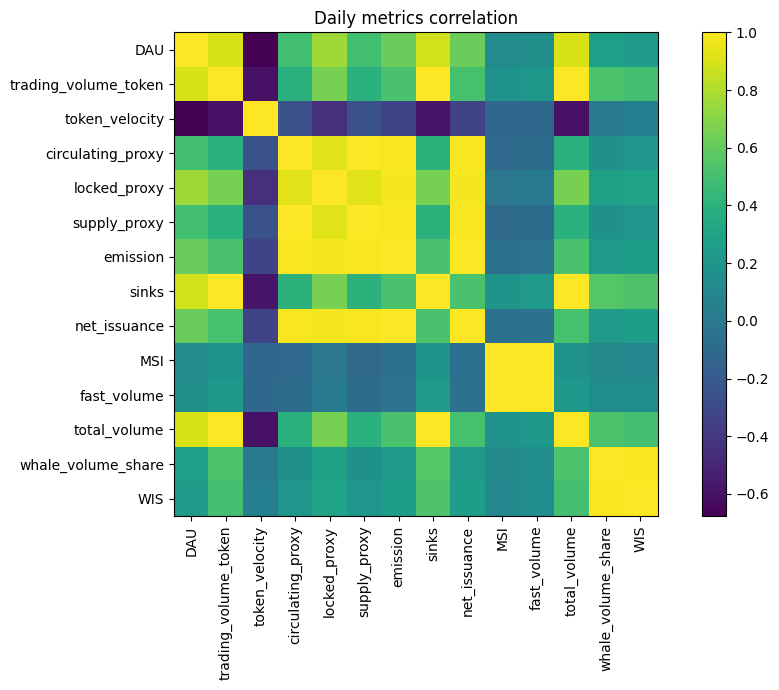

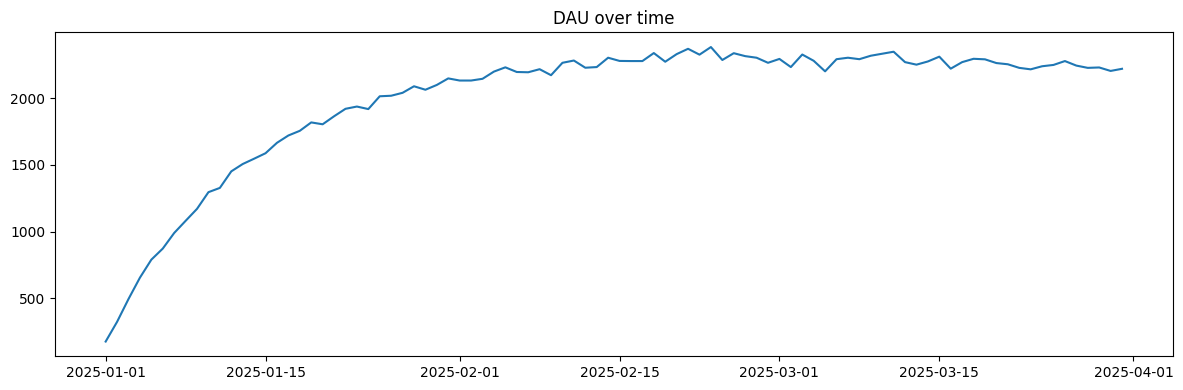

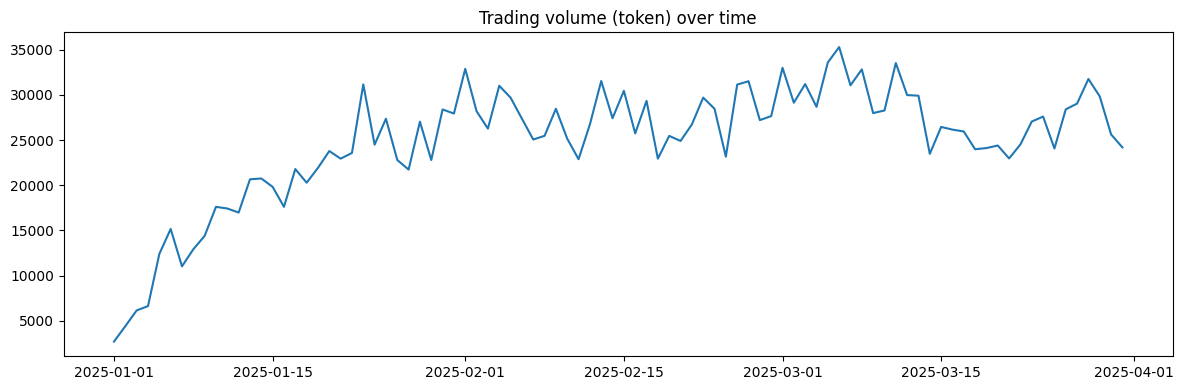

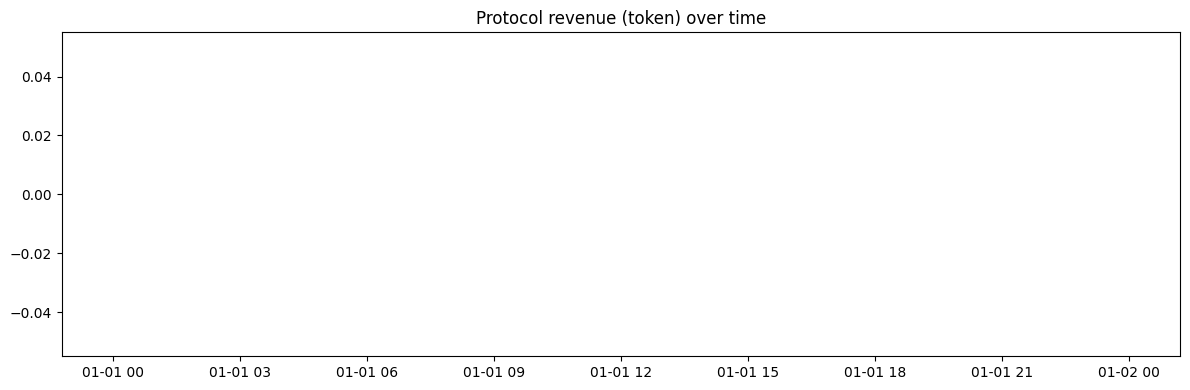

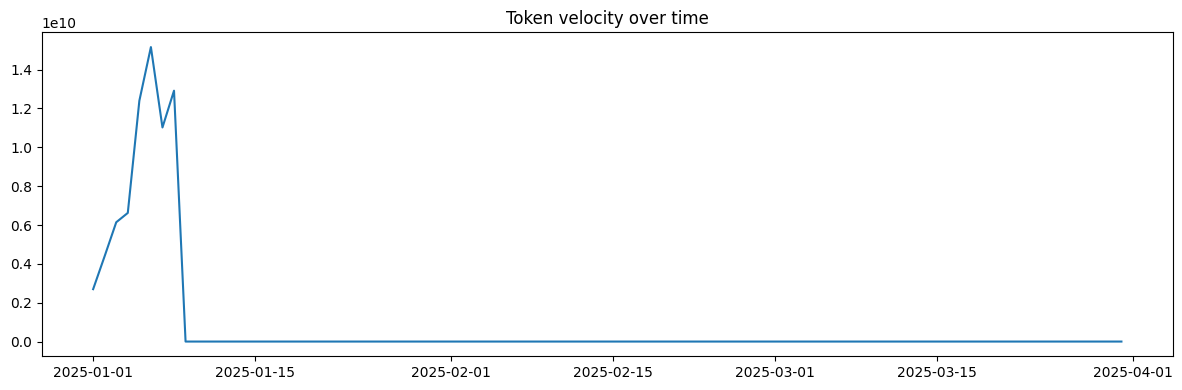

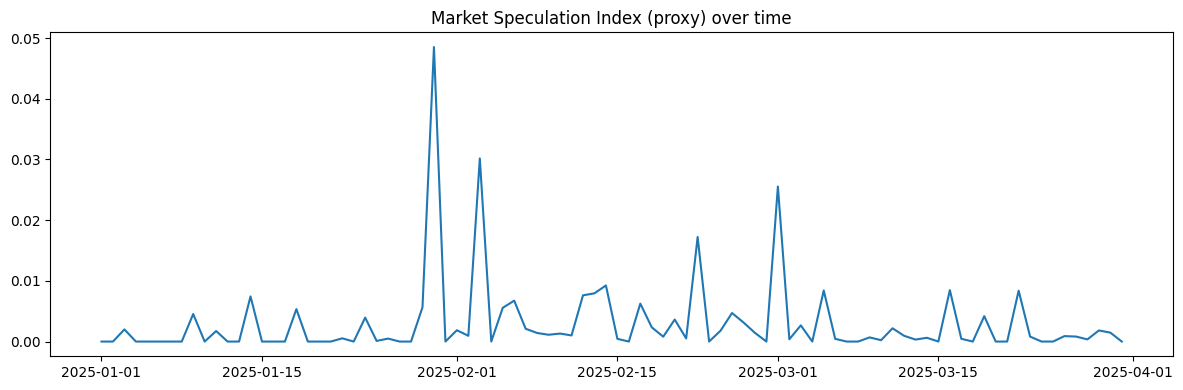

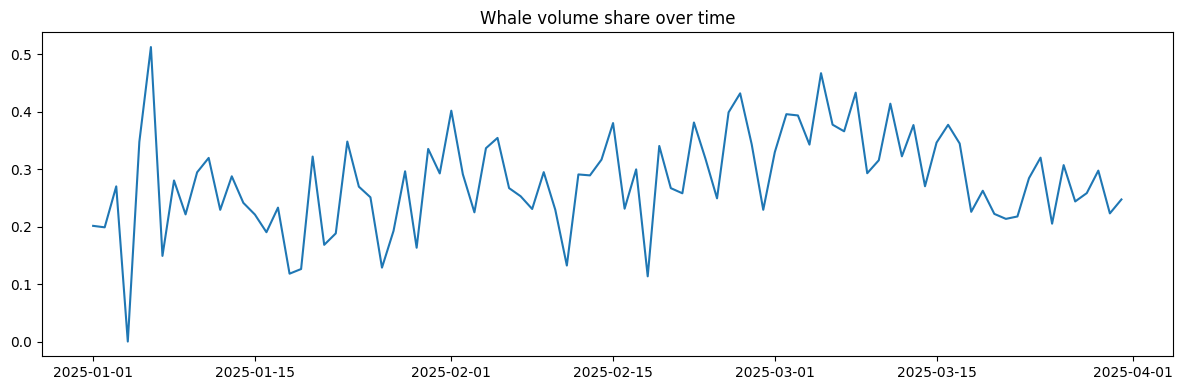

== Retention + Funnel ==


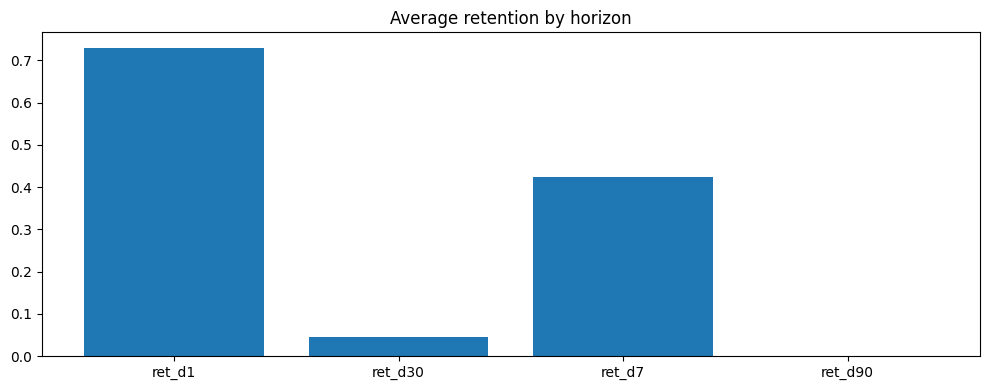

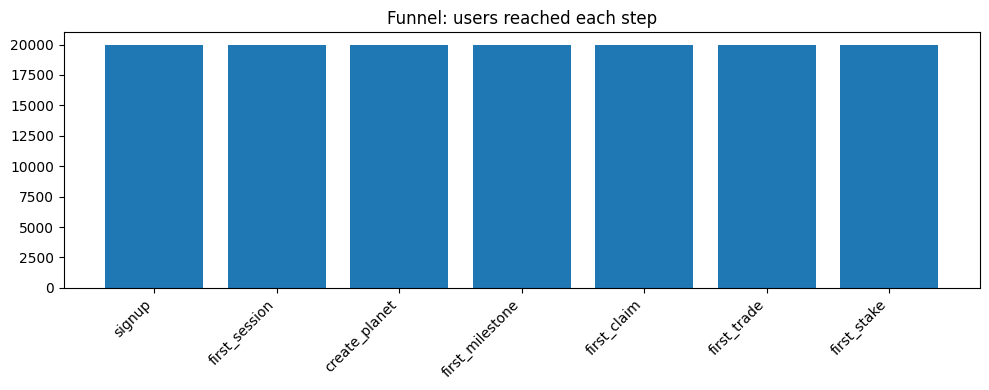

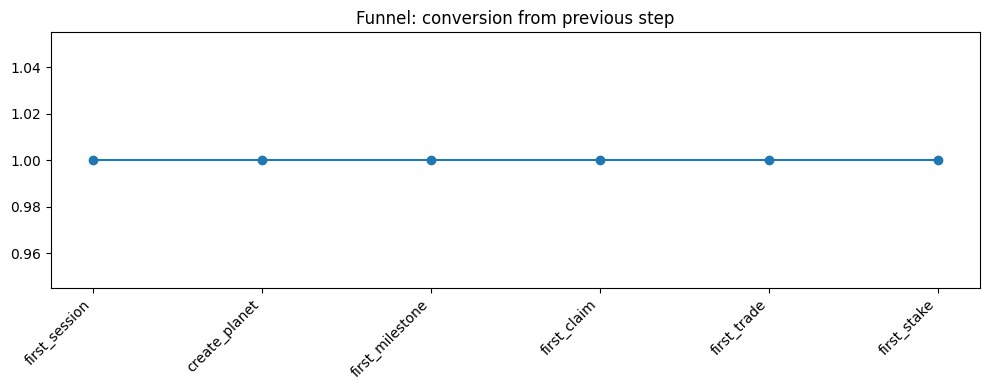

== Build user-level features ==


,user_id,country,acq_channel,device_os,app_version,wallet_type,chain_pref,is_kyc,player_segment,risk_profile,whale_flag,initial_deposit_usd,sessions_cnt,active_days,total_session_time,avg_session_len,trades_cnt,traded_days,trading_volume,avg_slippage,avg_spread,avg_tax_amount,avg_fee_amount,eff_tax_rate,eff_fee_rate,ledger_tx_cnt,rewards_total,taxes_total,fees_total,stake_net,LTV_token
0,1,BR,organic,Windows,1.3.0,EOA,OP,0,trader,conservative,0,34.64,9.0,8.0,16386.0,1820.666667,14.0,5.0,542.230554,135.410,94.328571,1.936538,0.077461,0.05,0.002,104.0,1432.998530,27.111529,1.084461,0.0,28.195990
1,2,TR,partner,Windows,1.3.0,EOA,BSC,1,trader,aggressive,0,154.43,18.0,13.0,29244.0,1624.666667,0.0,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.00,0.000,7.0,19.458753,0.000000,0.000000,0.0,0.000000
2,3,US,ads,macOS,1.2.0,custodial,ARB,0,builder,aggressive,0,206.08,13.0,7.0,16203.0,1246.384615,0.0,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.00,0.000,21.0,246.098573,0.000000,0.000000,0.0,0.000000
3,4,DE,ads,macOS,1.1.0,EOA,OP,0,builder,aggressive,0,60.36,26.0,19.0,40752.0,1567.384615,5.0,2.0,145.837689,159.630,104.520000,1.458377,0.058335,0.05,0.002,57.0,488.754955,7.291883,0.291675,0.0,7.583558
4,5,DE,organic,Android,1.2.0,EOA,POLY,0,trader,aggressive,0,45.69,14.0,8.0,20147.0,1439.071429,4.0,3.0,48.410813,120.495,81.600000,0.605135,0.024205,0.05,0.002,54.0,628.576112,2.420541,0.096821,0.0,2.517362


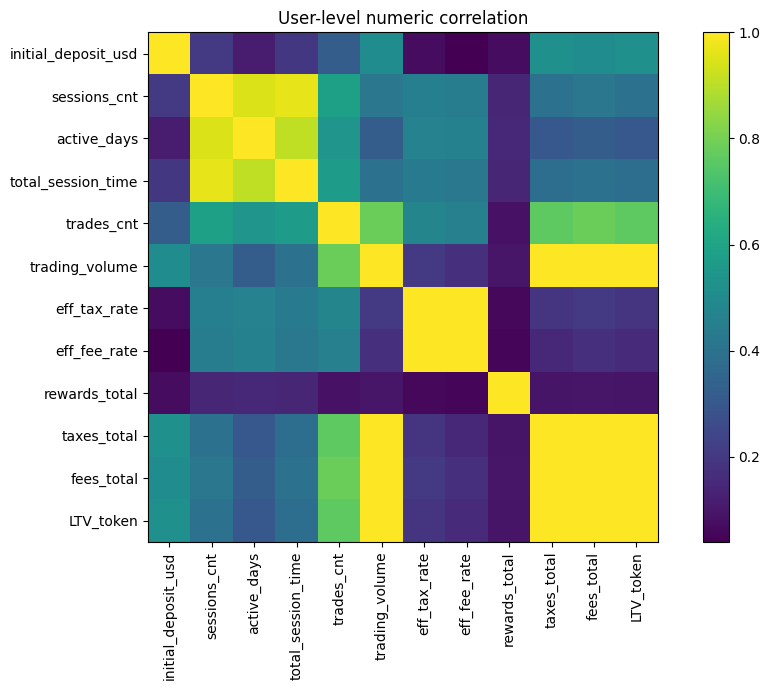

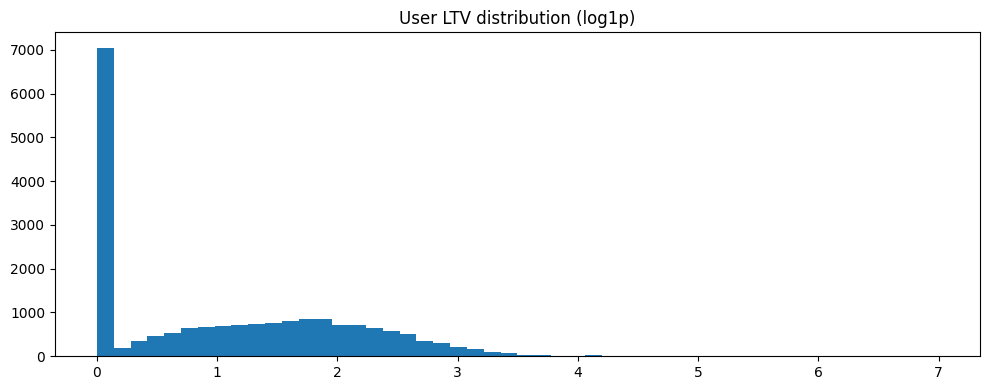

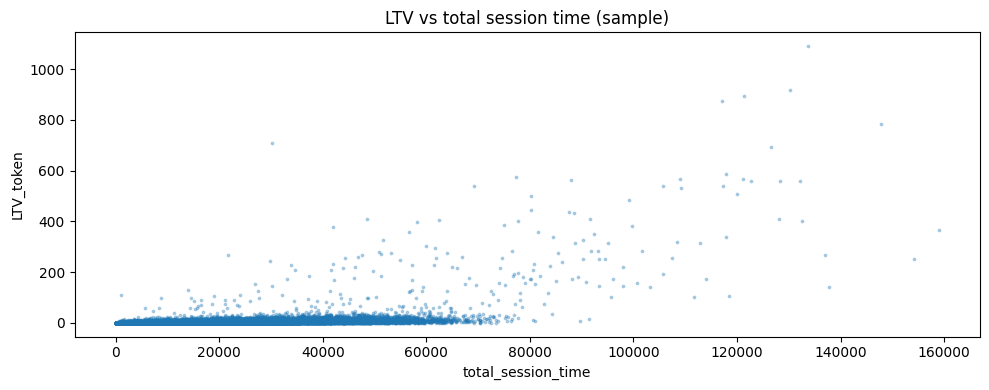

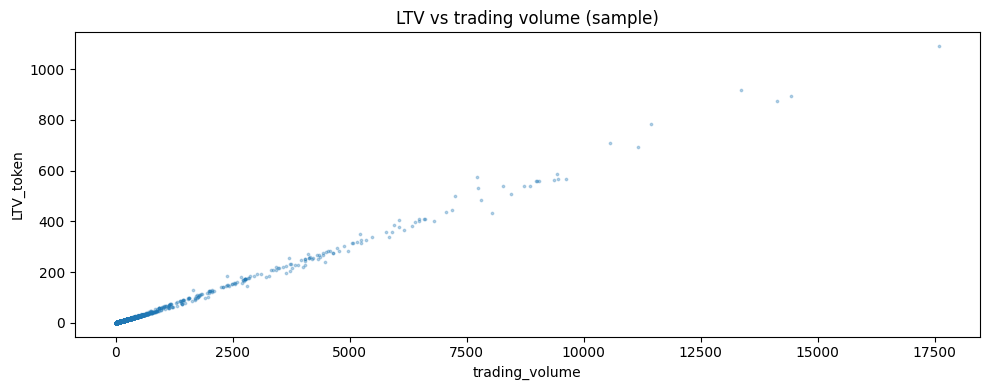

,whale_flag,users,mean_LTV,mean_volume,mean_time,mean_tax_rate
0,0,19734,3.868014,74.354223,21929.893129,0.032338
1,1,266,177.049039,2872.905466,57077.928571,0.049991


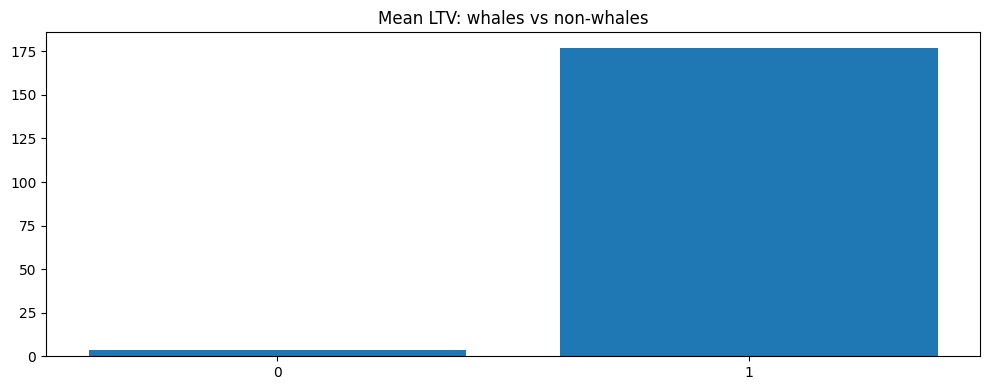

== Microstructure: volatility -> slippage/spread ==


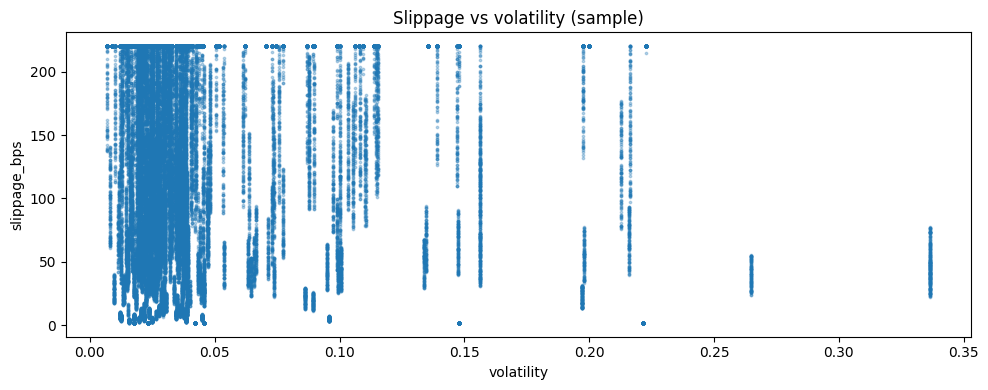

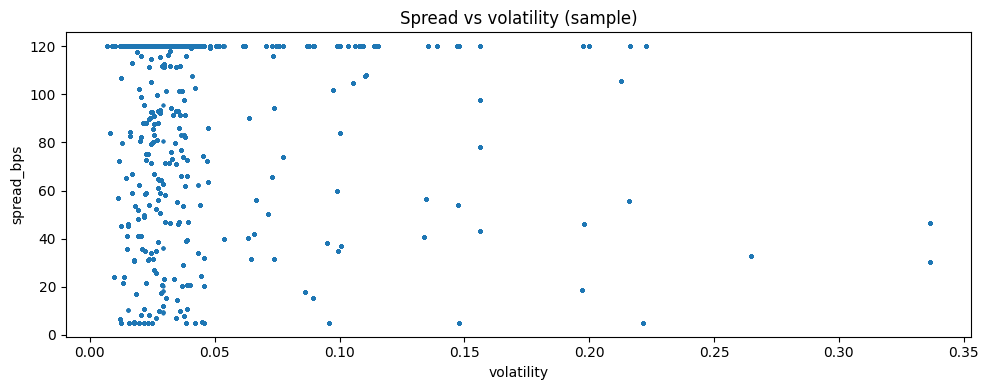

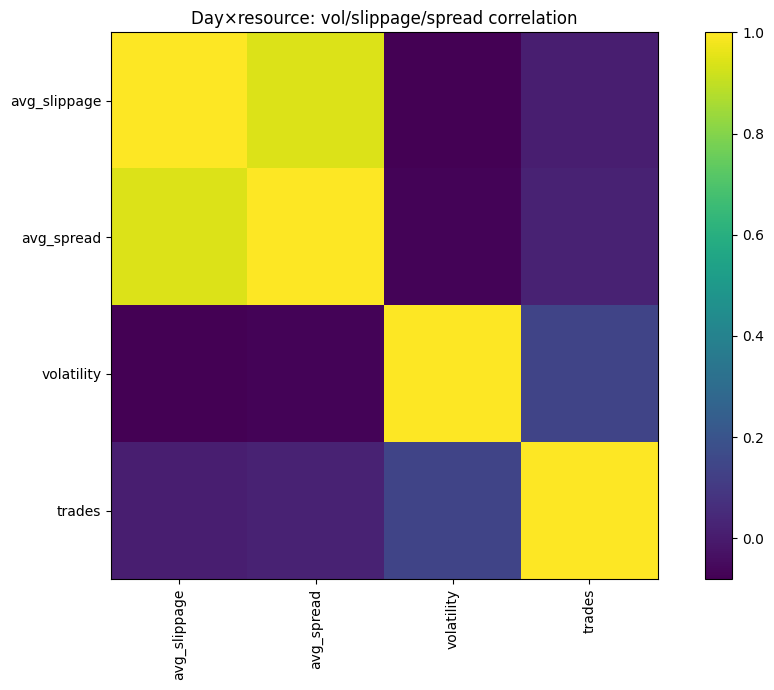

== Taxes: buckets + Laffer-ish curve ==


,user_7d_volume_bucket,trades,gross,avg_tax_rate,tax_rev,avg_slip
0,high,305,4.361335e+04,0.075,3271.001375,134.838754
1,low,54886,1.558071e+06,0.050,77903.557125,134.212322
2,mid,4575,6.298146e+05,0.060,37788.875644,133.810723


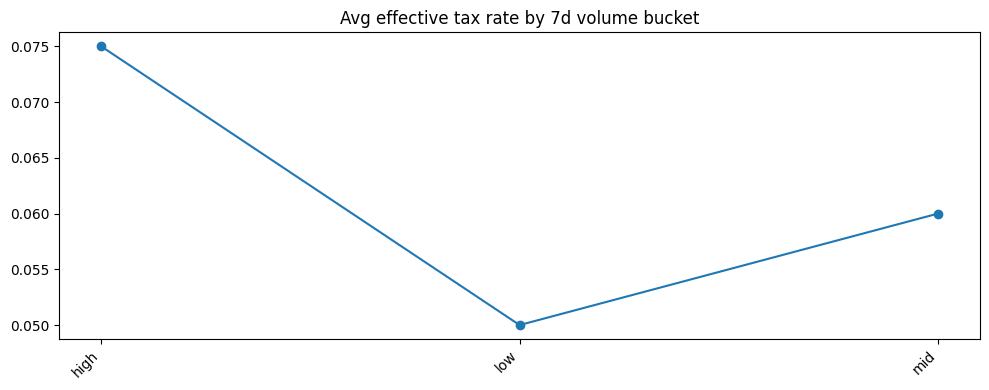

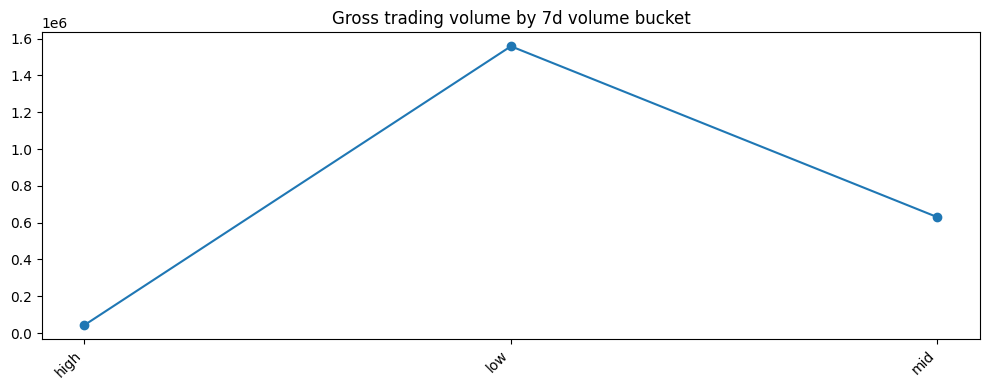

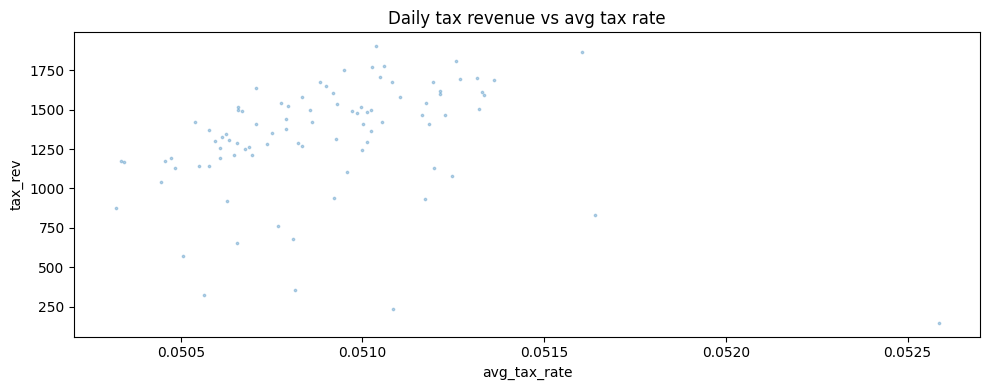

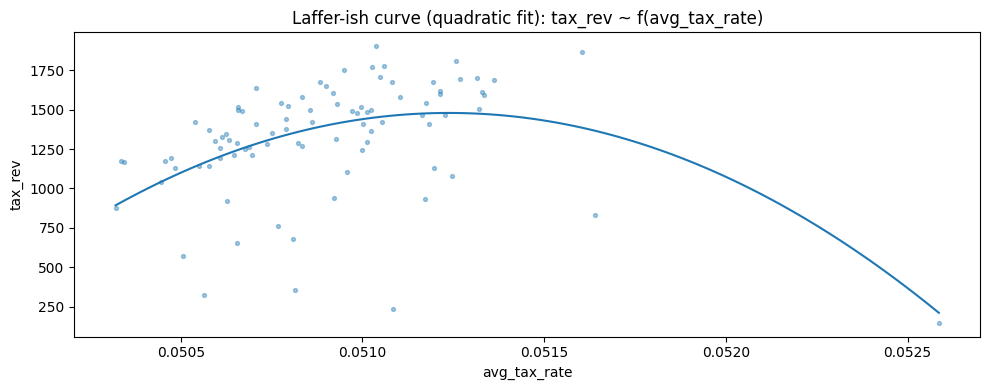

Quadratic fit coefficients: a=-6.962e+08, b=7.135e+07, c=-1.826e+06
== Shock experiment: event windows (affected resource) ==


,shock,mean_gross,median_gross,mean_trades,mean_slip,n
0,0,4905.480557,5059.498568,132.177215,135.349267,395
1,1,5342.441263,5136.622870,137.381818,124.295098,55


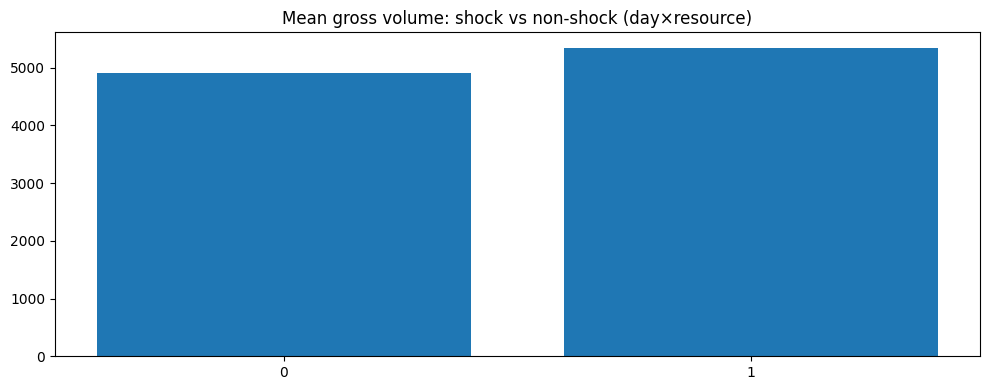

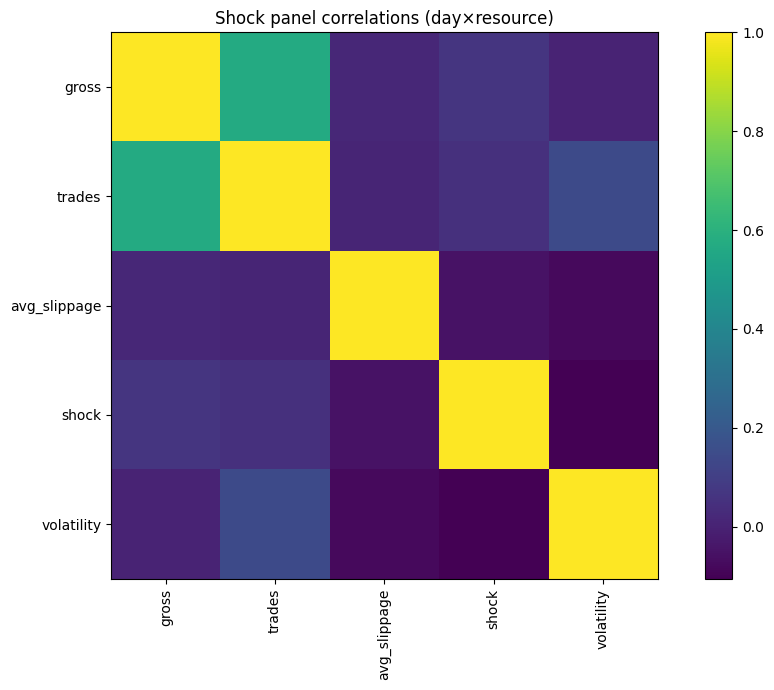

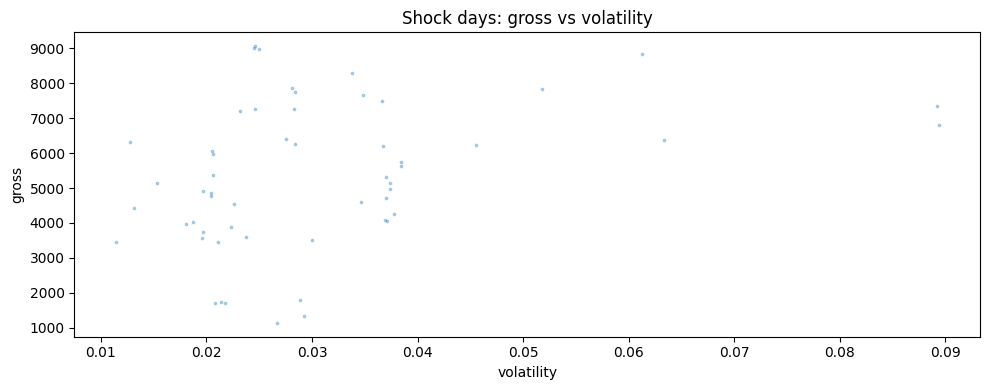

== Extensive vs intensive margin models (robust) ==
day×resource did_trade counts: {1: 450}
Fallback to user×day extensive margin (day×resource has only class=1).
user×day made_trade counts: {0: 8861275, 1: 138725}
[OK] LogisticRegression (user×day) AUC=1.000 | coef=[213.64652379   5.42705984] | intercept=-7.7794
[OK] LinearRegression (intensive log_gross (user×day)) coef=[223.12524266  -0.50160688] | intercept=-7.4419


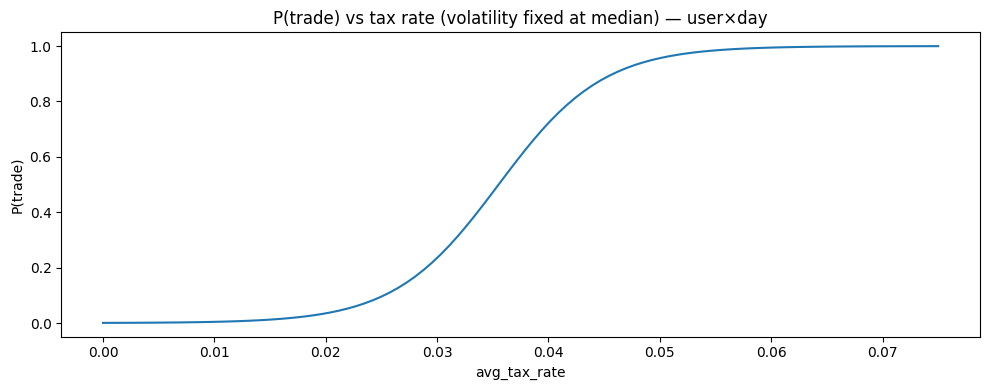

In [10]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def _dt(x): return pd.to_datetime(x, errors="coerce")
def p(msg): print(msg, flush=True)

def safe_merge(left, right, on, how="left"):
    if left is None or right is None:
        return left
    return left.merge(right, on=on, how=how)

def corr_heatmap(df, title="Correlation heatmap"):
    num = df.select_dtypes(include=[np.number]).copy()
    num = num.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")
    if num.shape[1] < 2:
        p(f"[SKIP] {title}: too few numeric columns")
        return
    c = num.corr()
    plt.figure(figsize=(10, 7))
    plt.imshow(c.values)
    plt.xticks(range(len(c.columns)), c.columns, rotation=90)
    plt.yticks(range(len(c.index)), c.index)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def scatter_sample(df, x, y, title=None, sample_n=50000):
    if x not in df.columns or y not in df.columns:
        p(f"[SKIP] scatter {x} vs {y}: missing column")
        return
    d = df[[x,y]].dropna()
    if len(d) == 0:
        p(f"[SKIP] scatter {x} vs {y}: empty after dropna")
        return
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=RANDOM_SEED)
    plt.figure(figsize=(10,4))
    plt.scatter(d[x], d[y], s=3, alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

# 1) DAILY DASHBOARD (time series)
p("== Build daily dashboard ==")

# DAU
dau = std.get("dau").copy()
dau["day"] = _dt(dau["day"])

# Revenue (from ARPU table if exists)
arpu = std.get("arpu_daily")
if arpu is not None:
    arpu = arpu.copy()
    arpu["day"] = _dt(arpu["day"])
    rev_daily = arpu[["day","revenue_token","ARPU_token"]].copy()
else:
    # fallback: from token_ledger taxes/fees
    tl = token_ledger.copy()
    tl["ts"] = _dt(tl["ts"]); tl["day"] = tl["ts"].dt.floor("D")
    tl["amount"] = pd.to_numeric(tl["amount"], errors="coerce").fillna(0.0)
    rev_daily = (
        tl[tl["tx_type"].isin(["tax","fee","market_fee"])]
        .groupby("day")["amount"].apply(lambda x: np.abs(x).sum())
        .reset_index(name="revenue_token")
    )
    rev_daily["ARPU_token"] = np.nan

# Trading volume daily from trades
mt = market_trades.copy()
mt["ts"] = _dt(mt["ts"]); mt["day"] = mt["ts"].dt.floor("D")
mt["amount_base"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0)
mt["price"] = pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)
mt["gross_token"] = mt["amount_base"] * mt["price"]
vol_daily = mt.groupby("day")["gross_token"].sum().reset_index(name="trading_volume_token")

# DeFi daily
tv = defi.get("token_velocity_daily").copy()
tv["day"] = _dt(tv["day"])
msi = defi.get("msi_daily").copy()
msi["day"] = _dt(msi["day"])
wis = defi.get("wis_daily").copy()
wis["day"] = _dt(wis["day"])

daily = dau.merge(vol_daily, on="day", how="left") \
           .merge(rev_daily[["day","revenue_token","ARPU_token"]], on="day", how="left") \
           .merge(tv[["day","token_velocity","circulating_proxy","locked_proxy","supply_proxy","emission","sinks","net_issuance"]], on="day", how="left") \
           .merge(msi[["day","MSI","fast_volume","total_volume"]], on="day", how="left") \
           .merge(wis[["day","whale_volume_share","WIS"]], on="day", how="left")

daily = daily.sort_values("day")

display(daily.head())
corr_heatmap(daily.drop(columns=["day"]), "Daily metrics correlation")

# ---- plots ----
plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["DAU"])
plt.title("DAU over time")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["trading_volume_token"])
plt.title("Trading volume (token) over time")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["revenue_token"])
plt.title("Protocol revenue (token) over time")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["token_velocity"])
plt.title("Token velocity over time")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["MSI"])
plt.title("Market Speculation Index (proxy) over time")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["day"], daily["whale_volume_share"])
plt.title("Whale volume share over time")
plt.tight_layout(); plt.show()

# 2) RETENTION + FUNNEL VISUALS
p("== Retention + Funnel ==")

ret = std.get("retention").copy()
ret["cohort_day"] = _dt(ret["cohort_day"])
ret_cols = [c for c in ret.columns if c.startswith("ret_d")]
ret_mean = ret[ret_cols].mean(numeric_only=True).sort_index()

plt.figure(figsize=(10,4))
plt.bar(ret_mean.index, ret_mean.values)
plt.title("Average retention by horizon")
plt.tight_layout(); plt.show()

funnel = std.get("funnel").copy()
plt.figure(figsize=(10,4))
plt.bar(funnel["step"], funnel["users_reached"])
plt.xticks(rotation=45, ha="right")
plt.title("Funnel: users reached each step")
plt.tight_layout(); plt.show()

if "conv_from_prev" in funnel.columns:
    plt.figure(figsize=(10,4))
    plt.plot(funnel["step"], funnel["conv_from_prev"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Funnel: conversion from previous step")
    plt.tight_layout(); plt.show()

# 3) USER-LEVEL DATASET FOR CORR / SEGMENTS
p("== Build user-level features ==")

u = users.copy()
u["created_at"] = _dt(u["created_at"])

# sessions -> totals
s = sessions.copy()
s["start_ts"] = _dt(s["start_ts"]); s["day"] = s["start_ts"].dt.floor("D")
s["session_len_sec"] = pd.to_numeric(s["session_len_sec"], errors="coerce").fillna(0.0)

sess_user = s.groupby("user_id").agg(
    sessions_cnt=("session_id","count"),
    active_days=("day","nunique"),
    total_session_time=("session_len_sec","sum"),
    avg_session_len=("session_len_sec","mean"),
).reset_index()

# trades -> totals (maker-side)
mt2 = mt.copy()
mt_user = mt2.groupby("maker_user_id").agg(
    trades_cnt=("trade_id","count"),
    traded_days=("day","nunique"),
    trading_volume=("gross_token","sum"),
    avg_slippage=("slippage_bps","mean"),
    avg_spread=("spread_bps","mean"),
    avg_tax_amount=("tax_amount","mean"),
    avg_fee_amount=("fee_amount","mean"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

# effective tax rate (token terms)
mt2["tax_amount"] = pd.to_numeric(mt2["tax_amount"], errors="coerce").fillna(0.0)
mt2["fee_amount"] = pd.to_numeric(mt2["fee_amount"], errors="coerce").fillna(0.0)
mt2["eff_tax_rate"] = mt2["tax_amount"] / mt2["gross_token"].replace(0, np.nan)
mt2["eff_fee_rate"] = mt2["fee_amount"] / mt2["gross_token"].replace(0, np.nan)

tax_user = mt2.groupby("maker_user_id").agg(
    eff_tax_rate=("eff_tax_rate","mean"),
    eff_fee_rate=("eff_fee_rate","mean"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

# ledger -> totals
tl = token_ledger.copy()
tl["ts"] = _dt(tl["ts"]); tl["day"] = tl["ts"].dt.floor("D")
tl["amount"] = pd.to_numeric(tl["amount"], errors="coerce").fillna(0.0)

ledger_user = tl.groupby("user_id").agg(
    ledger_tx_cnt=("ledger_id","count"),
    rewards_total=("amount", lambda x: x[tl.loc[x.index,"tx_type"].eq("reward")].sum()),
    taxes_total=("amount", lambda x: np.abs(x[tl.loc[x.index,"tx_type"].eq("tax")]).sum()),
    fees_total=("amount", lambda x: np.abs(x[tl.loc[x.index,"tx_type"].isin(["fee","market_fee"])]).sum()),
    stake_net=("amount", lambda x: x[tl.loc[x.index,"tx_type"].isin(["stake","unstake"])].sum()),
).reset_index()

# LTV from std
ltv = std.get("ltv_user")
if ltv is not None:
    ltv = ltv.copy()
else:
    ltv = ledger_user[["user_id"]].copy()
    ltv["LTV_token"] = ledger_user["taxes_total"] + ledger_user["fees_total"]

user_feat = (
    u[["user_id","country","acq_channel","device_os","app_version","wallet_type","chain_pref","is_kyc","player_segment","risk_profile","whale_flag","initial_deposit_usd"]]
    .merge(sess_user, on="user_id", how="left")
    .merge(mt_user, on="user_id", how="left")
    .merge(tax_user, on="user_id", how="left")
    .merge(ledger_user, on="user_id", how="left")
    .merge(ltv[["user_id","LTV_token"]], on="user_id", how="left")
)

# fill NA numeric
for c in ["sessions_cnt","active_days","total_session_time","avg_session_len",
          "trades_cnt","traded_days","trading_volume","avg_slippage","avg_spread",
          "avg_tax_amount","avg_fee_amount","eff_tax_rate","eff_fee_rate",
          "ledger_tx_cnt","rewards_total","taxes_total","fees_total","stake_net","LTV_token"]:
    if c in user_feat.columns:
        user_feat[c] = pd.to_numeric(user_feat[c], errors="coerce").fillna(0.0)

display(user_feat.head())
corr_heatmap(user_feat[[
    "initial_deposit_usd","sessions_cnt","active_days","total_session_time",
    "trades_cnt","trading_volume","eff_tax_rate","eff_fee_rate",
    "rewards_total","taxes_total","fees_total","LTV_token"
]], "User-level numeric correlation")

# ---- user-level plots ----
plt.figure(figsize=(10,4))
x = np.log1p(user_feat["LTV_token"])
plt.hist(x.dropna(), bins=50)
plt.title("User LTV distribution (log1p)")
plt.tight_layout(); plt.show()

scatter_sample(user_feat, "total_session_time", "LTV_token", "LTV vs total session time (sample)", sample_n=30000)
scatter_sample(user_feat, "trading_volume", "LTV_token", "LTV vs trading volume (sample)", sample_n=30000)

# whales vs non-whales comparisons
if "whale_flag" in user_feat.columns:
    grp = user_feat.groupby("whale_flag").agg(
        users=("user_id","nunique"),
        mean_LTV=("LTV_token","mean"),
        mean_volume=("trading_volume","mean"),
        mean_time=("total_session_time","mean"),
        mean_tax_rate=("eff_tax_rate","mean"),
    ).reset_index()
    display(grp)

    plt.figure(figsize=(10,4))
    plt.bar(grp["whale_flag"].astype(str), grp["mean_LTV"])
    plt.title("Mean LTV: whales vs non-whales")
    plt.tight_layout(); plt.show()

# 4) MICROSTRUCTURE: VOLATILITY vs SLIPPAGE/SPREAD
p("== Microstructure: volatility -> slippage/spread ==")
if "price_oracle" in globals() and price_oracle is not None:
    po = price_oracle.copy()
    po["day"] = _dt(po["day"]).dt.floor("D")
    po["resource"] = po["resource"].astype(str).str.upper()

    mtm = market_trades.copy()
    mtm["ts"] = _dt(mtm["ts"]); mtm["day"] = mtm["ts"].dt.floor("D")
    mtm["resource"] = mtm["asset_base"].astype(str).str.upper()
    mtm["slippage_bps"] = pd.to_numeric(mtm["slippage_bps"], errors="coerce")
    mtm["spread_bps"] = pd.to_numeric(mtm["spread_bps"], errors="coerce")

    m2 = mtm.merge(po[["day","resource","volatility"]], on=["day","resource"], how="left")

    scatter_sample(m2, "volatility", "slippage_bps", "Slippage vs volatility (sample)", sample_n=50000)
    scatter_sample(m2, "volatility", "spread_bps", "Spread vs volatility (sample)", sample_n=50000)

    # day-resource aggregates and correlation
    dr = m2.groupby(["day","resource"], as_index=False).agg(
        avg_slippage=("slippage_bps","mean"),
        avg_spread=("spread_bps","mean"),
        volatility=("volatility","mean"),
        trades=("trade_id","count"),
    )
    corr_heatmap(dr.drop(columns=["day","resource"]), "Day×resource: vol/slippage/spread correlation")
else:
    p("[SKIP] price_oracle is missing")

# 5) TAX ANALYTICS: BUCKETS + LAFFER CURVE (simple)
p("== Taxes: buckets + Laffer-ish curve ==")

mt_tax = market_trades.copy()
mt_tax["ts"] = _dt(mt_tax["ts"]); mt_tax["day"] = mt_tax["ts"].dt.floor("D")
mt_tax["amount_base"] = pd.to_numeric(mt_tax["amount_base"], errors="coerce").fillna(0.0)
mt_tax["price"] = pd.to_numeric(mt_tax["price"], errors="coerce").fillna(0.0)
mt_tax["gross_token"] = mt_tax["amount_base"] * mt_tax["price"]
mt_tax["tax_amount"] = pd.to_numeric(mt_tax["tax_amount"], errors="coerce").fillna(0.0)
mt_tax["fee_amount"] = pd.to_numeric(mt_tax["fee_amount"], errors="coerce").fillna(0.0)
mt_tax["eff_tax_rate"] = mt_tax["tax_amount"] / mt_tax["gross_token"].replace(0, np.nan)

# bucket view (7d volume bucket already in your trades)
if "user_7d_volume_bucket" in mt_tax.columns:
    bucket = mt_tax.groupby("user_7d_volume_bucket").agg(
        trades=("trade_id","count"),
        gross=("gross_token","sum"),
        avg_tax_rate=("eff_tax_rate","mean"),
        tax_rev=("tax_amount","sum"),
        avg_slip=("slippage_bps","mean"),
    ).reset_index().sort_values("user_7d_volume_bucket")
    display(bucket)

    plt.figure(figsize=(10,4))
    plt.plot(bucket["user_7d_volume_bucket"].astype(str), bucket["avg_tax_rate"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Avg effective tax rate by 7d volume bucket")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(bucket["user_7d_volume_bucket"].astype(str), bucket["gross"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Gross trading volume by 7d volume bucket")
    plt.tight_layout(); plt.show()

# Laffer-ish: daily revenue vs daily avg tax rate (trade-weighted)
daily_tax = mt_tax.groupby("day").agg(
    tax_rev=("tax_amount","sum"),
    gross=("gross_token","sum"),
    avg_tax_rate=("eff_tax_rate","mean"),
).reset_index()
daily_tax["avg_tax_rate"] = daily_tax["avg_tax_rate"].fillna(0.0)

scatter_sample(daily_tax, "avg_tax_rate", "tax_rev", "Daily tax revenue vs avg tax rate", sample_n=999999)

# quadratic fit for illustration
x = daily_tax["avg_tax_rate"].to_numpy()
y = daily_tax["tax_rev"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)
if m.sum() >= 10:
    coef = np.polyfit(x[m], y[m], deg=2)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ys = coef[0]*xs*xs + coef[1]*xs + coef[2]
    plt.figure(figsize=(10,4))
    plt.scatter(x[m], y[m], s=8, alpha=0.4)
    plt.plot(xs, ys)
    plt.title("Laffer-ish curve (quadratic fit): tax_rev ~ f(avg_tax_rate)")
    plt.xlabel("avg_tax_rate"); plt.ylabel("tax_rev")
    plt.tight_layout(); plt.show()
    p(f"Quadratic fit coefficients: a={coef[0]:.4g}, b={coef[1]:.4g}, c={coef[2]:.4g}")

# 6) SHOCK "EXPERIMENT": EVENT STUDY LIGHT (shock vs non-shock)
p("== Shock experiment: event windows (affected resource) ==")

if ("econ_events" in globals() and econ_events is not None) and ("price_oracle" in globals() and price_oracle is not None):
    ev = econ_events.copy()
    ev["start_ts"] = _dt(ev["start_ts"]); ev["end_ts"] = _dt(ev["end_ts"])
    ev["start_day"] = ev["start_ts"].dt.floor("D")
    ev["end_day"] = ev["end_ts"].dt.floor("D")
    ev["affected_resource"] = ev["affected_resource"].astype(str).str.upper()

    mt_ev = market_trades.copy()
    mt_ev["ts"] = _dt(mt_ev["ts"]); mt_ev["day"] = mt_ev["ts"].dt.floor("D")
    mt_ev["resource"] = mt_ev["asset_base"].astype(str).str.upper()
    mt_ev["amount_base"] = pd.to_numeric(mt_ev["amount_base"], errors="coerce").fillna(0.0)
    mt_ev["price"] = pd.to_numeric(mt_ev["price"], errors="coerce").fillna(0.0)
    mt_ev["gross_token"] = mt_ev["amount_base"] * mt_ev["price"]

    dr = mt_ev.groupby(["day","resource"], as_index=False).agg(
        gross=("gross_token","sum"),
        trades=("trade_id","count"),
        avg_slippage=("slippage_bps","mean")
    )

    # mark shock day-resource by expanding events (few events -> ok)
    dr["shock"] = 0
    for row in ev.itertuples(index=False):
        mask = (dr["resource"] == row.affected_resource) & (dr["day"] >= row.start_day) & (dr["day"] <= row.end_day)
        dr.loc[mask, "shock"] = 1

    shock_cmp = dr.groupby("shock").agg(
        mean_gross=("gross","mean"),
        median_gross=("gross","median"),
        mean_trades=("trades","mean"),
        mean_slip=("avg_slippage","mean"),
        n=("gross","size"),
    ).reset_index()
    display(shock_cmp)

    plt.figure(figsize=(10,4))
    plt.bar(shock_cmp["shock"].astype(str), shock_cmp["mean_gross"])
    plt.title("Mean gross volume: shock vs non-shock (day×resource)")
    plt.tight_layout(); plt.show()

    # add volatility and see relationship under shock
    po = price_oracle.copy()
    po["day"] = _dt(po["day"]).dt.floor("D")
    po["resource"] = po["resource"].astype(str).str.upper()
    dr2 = dr.merge(po[["day","resource","volatility"]], on=["day","resource"], how="left")
    corr_heatmap(dr2.drop(columns=["day","resource"]), "Shock panel correlations (day×resource)")

    scatter_sample(dr2[dr2["shock"]==1], "volatility", "gross", "Shock days: gross vs volatility", sample_n=50000)
else:
    p("[SKIP] econ_events or price_oracle missing")

# 7) EXTENSIVE vs INTENSIVE MARGIN (simple modeling)
p("== Extensive vs intensive margin models (robust) ==")

try:
    from sklearn.linear_model import LogisticRegression, LinearRegression
    from sklearn.metrics import roc_auc_score
except Exception as e:
    p(f"[SKIP] sklearn not available: {e}")
    LogisticRegression = None

def _fit_logit(X, y, label=""):
    y = np.asarray(y)
    uniq = np.unique(y[~pd.isna(y)])
    if len(uniq) < 2:
        p(f"[SKIP] LogisticRegression ({label}): only one class in y -> {uniq}")
        return None
    clf = LogisticRegression(max_iter=300)
    clf.fit(X, y)
    pred = clf.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, pred) if len(np.unique(y)) > 1 else np.nan
    p(f"[OK] LogisticRegression ({label}) AUC={auc:.3f} | coef={clf.coef_[0]} | intercept={clf.intercept_[0]:.4f}")
    return clf

def _fit_lin(X, y, label=""):
    reg = LinearRegression()
    reg.fit(X, y)
    p(f"[OK] LinearRegression ({label}) coef={reg.coef_} | intercept={reg.intercept_:.4f}")
    return reg

if LogisticRegression is not None:

    # A) Try day×resource panel (as you had)
    ok_panel = False
    if ("price_oracle" in globals() and price_oracle is not None):
        po = price_oracle.copy()
        po["day"] = _dt(po["day"]).dt.floor("D")
        po["resource"] = po["resource"].astype(str).str.upper()

        mtm = market_trades.copy()
        mtm["ts"] = _dt(mtm["ts"]); mtm["day"] = mtm["ts"].dt.floor("D")
        mtm["resource"] = mtm["asset_base"].astype(str).str.upper()
        mtm["amount_base"] = pd.to_numeric(mtm["amount_base"], errors="coerce").fillna(0.0)
        mtm["price"] = pd.to_numeric(mtm["price"], errors="coerce").fillna(0.0)
        mtm["gross_token"] = mtm["amount_base"] * mtm["price"]
        mtm["tax_amount"] = pd.to_numeric(mtm["tax_amount"], errors="coerce").fillna(0.0)
        mtm["eff_tax_rate"] = mtm["tax_amount"] / mtm["gross_token"].replace(0, np.nan)

        panel = mtm.groupby(["day","resource"], as_index=False).agg(
            trades=("trade_id","count"),
            gross=("gross_token","sum"),
            avg_tax_rate=("eff_tax_rate","mean"),
        ).merge(po[["day","resource","volatility"]], on=["day","resource"], how="left")

        panel["avg_tax_rate"] = panel["avg_tax_rate"].fillna(0.0)
        panel["volatility"] = panel["volatility"].fillna(panel["volatility"].median())
        panel["did_trade"] = (panel["trades"] > 0).astype(int)

        vc = panel["did_trade"].value_counts(dropna=False).to_dict()
        p(f"day×resource did_trade counts: {vc}")

        if panel["did_trade"].nunique() >= 2:
            ok_panel = True
            X = panel[["avg_tax_rate","volatility"]].to_numpy()
            y = panel["did_trade"].to_numpy()

            clf = _fit_logit(X, y, label="day×resource")

            traded = panel[panel["did_trade"]==1].copy()
            traded["log_gross"] = np.log1p(traded["gross"])
            X2 = traded[["avg_tax_rate","volatility"]].to_numpy()
            y2 = traded["log_gross"].to_numpy()
            reg = _fit_lin(X2, y2, label="intensive log_gross (day×resource)")

            # plot P(trade) vs tax rate at median vol
            if clf is not None:
                v0 = float(np.nanmedian(panel["volatility"]))
                xs = np.linspace(panel["avg_tax_rate"].min(), panel["avg_tax_rate"].max(), 100)
                Xg = np.column_stack([xs, np.full_like(xs, v0)])
                ppred = clf.predict_proba(Xg)[:,1]
                plt.figure(figsize=(10,4))
                plt.plot(xs, ppred)
                plt.title("P(trade) vs tax rate (volatility fixed at median) — day×resource")
                plt.xlabel("avg_tax_rate"); plt.ylabel("P(trade)")
                plt.tight_layout(); plt.show()

    # B) Fallback: user×day panel (almost always has zeros)
    if not ok_panel:
        p("Fallback to user×day extensive margin (day×resource has only class=1).")

        # user-day activity (from sessions)
        s = sessions.copy()
        s["start_ts"] = _dt(s["start_ts"])
        s["day"] = s["start_ts"].dt.floor("D")
        ud = s.groupby(["user_id","day"], as_index=False).agg(
            session_time=("session_len_sec","sum"),
            sessions_cnt=("session_id","count"),
        )
        ud["session_time"] = pd.to_numeric(ud["session_time"], errors="coerce").fillna(0.0)
        ud["is_active"] = 1

        # user-day trading (from market_trades)
        mtm = market_trades.copy()
        mtm["ts"] = _dt(mtm["ts"]); mtm["day"] = mtm["ts"].dt.floor("D")
        mtm["gross_token"] = pd.to_numeric(mtm["amount_base"], errors="coerce").fillna(0.0) * pd.to_numeric(mtm["price"], errors="coerce").fillna(0.0)
        mtm["tax_amount"] = pd.to_numeric(mtm["tax_amount"], errors="coerce").fillna(0.0)
        mtm["eff_tax_rate"] = mtm["tax_amount"] / mtm["gross_token"].replace(0, np.nan)

        ut = mtm.groupby(["maker_user_id","day"], as_index=False).agg(
            trades=("trade_id","count"),
            gross=("gross_token","sum"),
            avg_tax_rate=("eff_tax_rate","mean"),
            avg_slippage=("slippage_bps","mean"),
            avg_spread=("spread_bps","mean"),
        ).rename(columns={"maker_user_id":"user_id"})
        ut["avg_tax_rate"] = ut["avg_tax_rate"].fillna(0.0)

        # build full user×day grid for window (use days present in sessions)
        days = pd.DataFrame({"day": pd.Series(pd.unique(s["day"].dropna())).sort_values()})
        users_list = pd.DataFrame({"user_id": users["user_id"].unique()})
        grid = users_list.merge(days, how="cross")

        panel_ud = grid.merge(ut, on=["user_id","day"], how="left").merge(
            price_oracle.assign(resource=lambda d: d["resource"].astype(str).str.upper()) if ("price_oracle" in globals() and price_oracle is not None) else None,
            how="left",
            left_on=["day"], right_on=["day"]
        )

        # fill: no trade => 0 trades and 0 gross
        panel_ud["trades"] = panel_ud["trades"].fillna(0).astype(int)
        panel_ud["gross"] = panel_ud["gross"].fillna(0.0)
        panel_ud["avg_tax_rate"] = panel_ud["avg_tax_rate"].fillna(0.0)

        # volatility: use daily average over resources (if present)
        if "price_oracle" in globals() and price_oracle is not None and "volatility" in price_oracle.columns:
            po = price_oracle.copy()
            po["day"] = _dt(po["day"]).dt.floor("D")
            vol_day = po.groupby("day")["volatility"].mean().reset_index(name="volatility_day")
            panel_ud = panel_ud.merge(vol_day, on="day", how="left")
        else:
            panel_ud["volatility_day"] = np.nan

        panel_ud["volatility_day"] = panel_ud["volatility_day"].fillna(panel_ud["volatility_day"].median())
        panel_ud["made_trade"] = (panel_ud["trades"] > 0).astype(int)

        vc = panel_ud["made_trade"].value_counts(dropna=False).to_dict()
        p(f"user×day made_trade counts: {vc}")

        # Extensive (probability to trade)
        X = panel_ud[["avg_tax_rate","volatility_day"]].to_numpy()
        y = panel_ud["made_trade"].to_numpy()
        clf = _fit_logit(X, y, label="user×day")

        # Intensive: log gross among traded
        traded = panel_ud[panel_ud["made_trade"]==1].copy()
        if len(traded) > 0:
            traded["log_gross"] = np.log1p(traded["gross"])
            X2 = traded[["avg_tax_rate","volatility_day"]].to_numpy()
            y2 = traded["log_gross"].to_numpy()
            reg = _fit_lin(X2, y2, label="intensive log_gross (user×day)")

        # plot P(trade) vs tax rate
        if clf is not None:
            v0 = float(np.nanmedian(panel_ud["volatility_day"]))
            xs = np.linspace(panel_ud["avg_tax_rate"].min(), panel_ud["avg_tax_rate"].max(), 100)
            Xg = np.column_stack([xs, np.full_like(xs, v0)])
            ppred = clf.predict_proba(Xg)[:,1]
            plt.figure(figsize=(10,4))
            plt.plot(xs, ppred)
            plt.title("P(trade) vs tax rate (volatility fixed at median) — user×day")
            plt.xlabel("avg_tax_rate"); plt.ylabel("P(trade)")
            plt.tight_layout(); plt.show()
else:
    p("[SKIP] sklearn missing -> cannot fit models.")

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

[     0.0s] Base tables found. Checking optional tables...
[     0.0s] All optional tables already exist. Skipping enrichment.
[     0.0s] Computing STANDARD metrics...
[     1.3s] STANDARD metrics done.
[     1.3s] Computing DEFI metrics...
[     6.3s] DEFI metrics done.

=== Conversion ===
{'conv_days': 7, 'conversion_rate': 0.9913, 'converted_users': 19826, 'new_users': 20000, 'median_days_to_first_session': 0.04342592592592592}

=== Funnel ===


,step,users_reached,conv_from_prev
0,signup,20000,NaN
1,first_session,20000,1.0
2,create_planet,20000,1.0
3,first_milestone,20000,1.0
4,first_claim,20000,1.0
5,first_trade,20000,1.0
6,first_stake,20000,1.0



=== Retention (head) ===


,cohort_day,cohort_size,ret_d1,ret_d7,ret_d30,ret_d90
0,2025-01-01,224,0.750000,0.406250,0.058036,0.0
1,2025-01-02,222,0.743243,0.450450,0.067568,0.0
2,2025-01-03,240,0.712500,0.475000,0.041667,0.0
3,2025-01-04,244,0.741803,0.430328,0.086066,0.0
4,2025-01-05,221,0.733032,0.470588,0.067873,0.0



=== DAU (head) ===


...

,day,trading_volume_token,circulating_proxy,supply_proxy,locked_proxy,emission,sinks,net_issuance,token_velocity
0,2025-01-01,2696.633602,0.000001,-115.330786,359.793527,38.476695,153.807481,-115.330786,2.696634e+09
1,2025-01-02,4402.736592,0.000001,-226.054827,549.607376,132.513628,243.237669,-110.724041,4.402737e+09
2,2025-01-03,6142.682880,0.000001,-288.192005,1189.138704,273.884645,336.021823,-62.137178,6.142683e+09
3,2025-01-04,6622.910404,0.000001,-163.669688,1431.193932,491.932515,367.410198,124.522317,6.622910e+09
4,2025-01-05,12396.681906,0.000001,-16.225790,2047.239474,829.062378,681.618480,147.443898,1.239668e+10



=== MSI daily (head) ===


,day,total_volume,fast_volume,MSI
0,2025-01-01,2696.633602,0.000000,0.000000
1,2025-01-02,4402.736592,0.000000,0.000000
2,2025-01-03,6142.682880,12.274653,0.001998
3,2025-01-04,6622.910404,0.000000,0.000000
4,2025-01-05,12396.681906,0.000000,0.000000



=== WIS daily (head) ===


,day,whale_volume,total_volume,whale_traders,whale_volume_share,slippage_delta_whale_minus_other,spread_delta_whale_minus_other,WIS
0,2025-01-01,543.301432,2696.633602,1,0.201474,27.596026,12.267308,0.241337
1,2025-01-02,875.755358,4402.736592,1,0.198912,-18.071051,-13.014865,0.167826
2,2025-01-03,1660.231392,6142.682880,2,0.270278,24.914527,13.486527,0.308679
3,2025-01-04,0.000000,6622.910404,0,0.000000,0.000000,0.000000,0.000000
4,2025-01-05,4311.973533,12396.681906,4,0.347833,-10.860997,-1.882736,0.335089


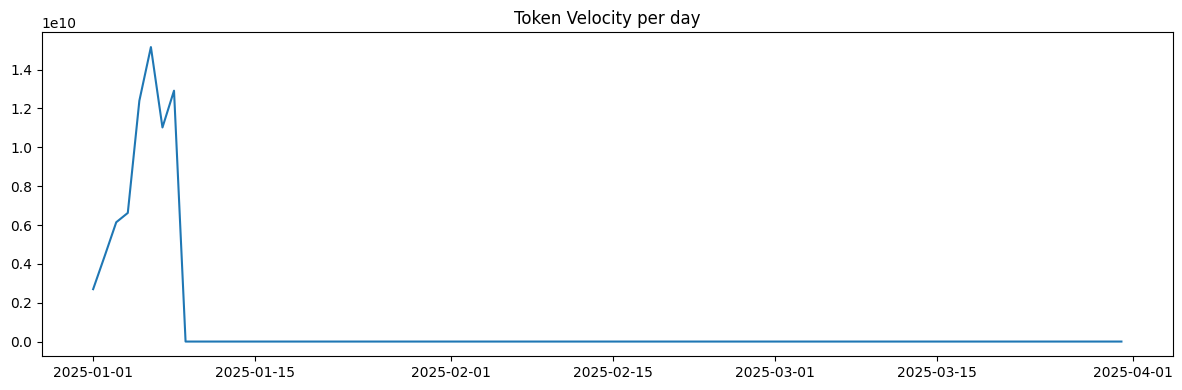

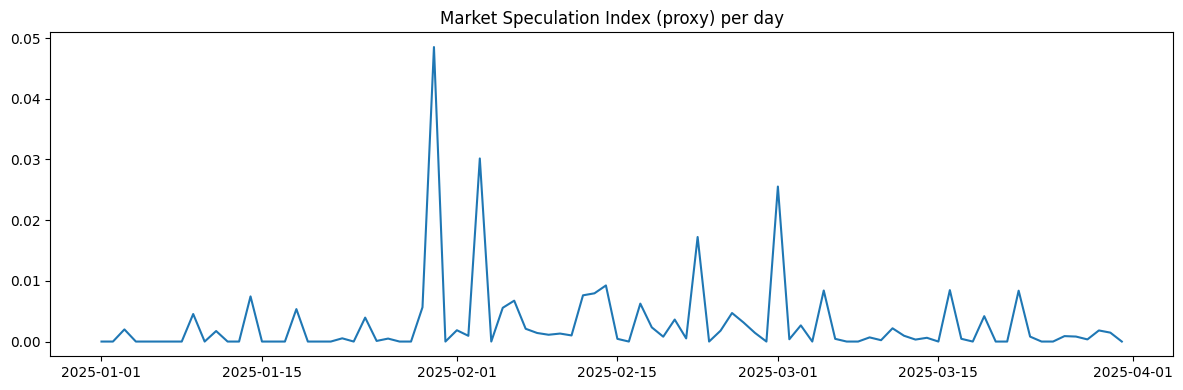

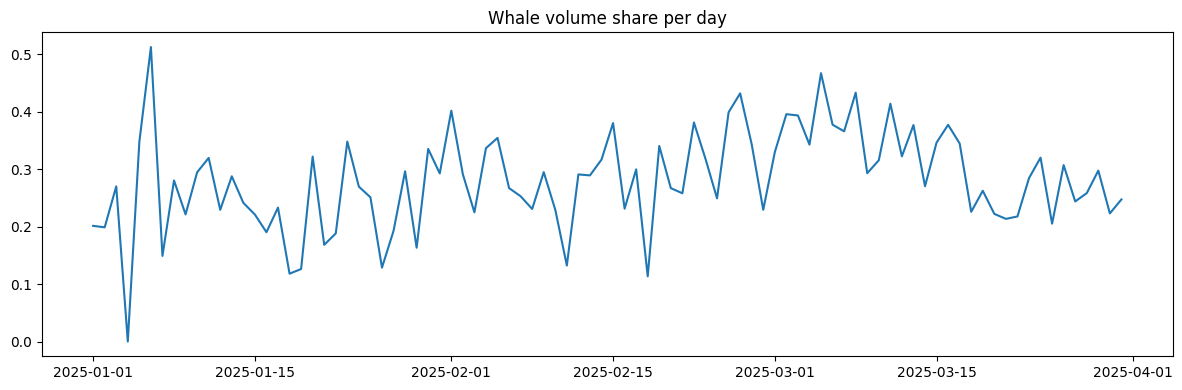

[     7.4s] ALL DONE


In [11]:
# 0) PROGRESS / TIMER
T0 = time.perf_counter()
def p(msg):
    print(f"[{time.perf_counter()-T0:8.1f}s] {msg}", flush=True)

# 1) HELPERS

def _dt(x):
    return pd.to_datetime(x, errors="coerce")

def _floor_day(x):
    # x can be Series/array-like
    return _dt(x).dt.floor("D")

def _pick_col(df, candidates, required=True, df_name="df"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"{df_name}: не найдена ни одна из колонок {candidates}. Доступные: {list(df.columns)}")
    return None

def extract_base_from_instrument(x: str):
    if not isinstance(x, str):
        return x
    x = x.upper().strip()
    QUOTES = ["USDT","USDC","BUSD","USD","BTC","ETH","EUR","TRY","BRL","GBP"]
    for q in QUOTES:
        if x.endswith(q) and len(x) > len(q):
            return x[:-len(q)]
    return x

def ensure_resource_key_in_trades(mt: pd.DataFrame):
    c = _pick_col(
        mt,
        ["resource","resource_key","asset_base","base_asset","asset","token_symbol","asset_exch","instrument_exch","symbol","pair"],
        required=True,
        df_name="market_trades"
    )
    if c in ["instrument_exch","symbol","pair"]:
        mt["resource_key"] = mt[c].map(extract_base_from_instrument)
    else:
        mt["resource_key"] = mt[c].astype(str).str.upper()
    return mt

def gini(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    s = x.sum()
    if s == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / s) / n

def top_share(x, p=0.01):
    x = pd.Series(x).dropna()
    x = x[x >= 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.nan
    k = max(1, int(len(x) * p))
    return float(x.head(k).sum() / x.sum())

def _rolling_sum_by_user_day(df, user_col, day_col, val_col, window=7):
    d = df.sort_values([user_col, day_col]).copy()
    d[val_col] = pd.to_numeric(d[val_col], errors="coerce").fillna(0.0)
    d[f"{val_col}_{window}d"] = (
        d.groupby(user_col)[val_col]
         .rolling(window=window, min_periods=1)
         .sum()
         .reset_index(level=0, drop=True)
    )
    return d

# 2) ENRICH OPTIONAL TABLES (with progress)
def enrich_optional_tables(users, sessions, market_trades, token_ledger, seed=42, chunk_users=2000, max_planet_rows=2_500_000):
    rng = np.random.default_rng(seed)
    p("Enrichment: start")

    u = users.copy()
    s = sessions.copy()
    mt = market_trades.copy()
    tl = token_ledger.copy()

    # Parse dates
    u["created_at"] = _dt(u["created_at"])
    s["start_ts"] = _dt(s["start_ts"])
    s["end_ts"]   = _dt(s["end_ts"])
    mt["ts"]      = _dt(mt["ts"])
    tl["ts"]      = _dt(tl["ts"])

    s["day"]  = _floor_day(s["start_ts"])
    mt["day"] = _floor_day(mt["ts"])
    tl["day"] = _floor_day(tl["ts"])

    mt = ensure_resource_key_in_trades(mt)

    # Calendar range
    day_min = min(u["created_at"].min(), s["day"].min(), mt["day"].min(), tl["day"].min())
    day_max = max(u["created_at"].max(), s["day"].max(), mt["day"].max(), tl["day"].max())
    day_min = pd.Timestamp(day_min).floor("D")
    day_max = pd.Timestamp(day_max).floor("D")
    days = pd.date_range(day_min, day_max, freq="D")

    resources = sorted(mt["resource_key"].dropna().unique().tolist())
    if not resources:
        resources = ["ORE","CRYSTAL","GAS","WATER"]

    p(f"Enrichment: calendar ready | days={len(days)} resources={len(resources)} users={len(u)}")

    # --- price_oracle_daily ---
    p("Enrichment: price_oracle (VWAP + volatility)")
    mt["amount_base"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0)
    mt["price"]       = pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)
    mt["gross_token"] = mt["amount_base"] * mt["price"]

    agg = mt.groupby(["day","resource_key"], as_index=False).agg(
        gross_sum=("gross_token","sum"),
        amt_sum=("amount_base","sum"),
    )
    agg["price_token"] = agg["gross_sum"] / agg["amt_sum"].replace(0, np.nan)

    grid = pd.MultiIndex.from_product([days, resources], names=["day","resource_key"]).to_frame(index=False)
    po = grid.merge(agg[["day","resource_key","price_token"]], on=["day","resource_key"], how="left").sort_values(["resource_key","day"])
    po["price_token"] = po.groupby("resource_key")["price_token"].ffill().bfill()
    po["price_token"] = po["price_token"].fillna(po["price_token"].median())

    po["log_ret"] = np.log(po["price_token"]).groupby(po["resource_key"]).diff()
    po["volatility"] = (
        po.groupby("resource_key")["log_ret"]
          .rolling(7, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    po["volatility"] = po["volatility"].fillna(po["volatility"].median()).fillna(0.02)

    price_oracle = po.rename(columns={"resource_key":"resource"})[["day","resource","price_token","volatility"]]
    p(f"Enrichment: price_oracle done | shape={price_oracle.shape}")

    # --- econ_events ---
    p("Enrichment: econ_events")
    n_events = min(12, max(4, len(resources)*2))
    ev_rows = []
    for i in range(n_events):
        res = rng.choice(resources)
        start = rng.choice(days)
        dur = int(rng.integers(2, 9))
        end = min(start + pd.Timedelta(days=dur), days[-1])
        ev_rows.append({
            "event_id": i+1,
            "event_type": rng.choice(["supply_shock","demand_spike","oracle_glitch","chain_congestion","governance_vote"]),
            "affected_resource": res,
            "start_ts": pd.Timestamp(start) + pd.Timedelta(hours=int(rng.integers(0, 12))),
            "end_ts": pd.Timestamp(end) + pd.Timedelta(hours=int(rng.integers(12, 24))),
            "intensity": float(np.round(rng.uniform(0.5, 2.0), 3)),
        })
    econ_events = pd.DataFrame(ev_rows)
    econ_events["start_ts"] = _dt(econ_events["start_ts"])
    econ_events["end_ts"]   = _dt(econ_events["end_ts"])
    econ_events["start_day"] = econ_events["start_ts"].dt.floor("D")
    econ_events["end_day"]   = econ_events["end_ts"].dt.floor("D")
    p(f"Enrichment: econ_events done | shape={econ_events.shape}")

    # --- resource_production_daily ---
    p("Enrichment: resource_production_daily")
    sold = mt.groupby(["day","resource_key"], as_index=False)["amount_base"].sum().rename(columns={"amount_base":"sold_amount"})
    base = grid.merge(sold, on=["day","resource_key"], how="left").fillna({"sold_amount":0.0})

    res_base = {r: rng.uniform(2000, 12000) for r in resources}
    res_liq  = {r: rng.uniform(0.3, 1.1) for r in resources}

    def shock_mult(day, res):
        sub = econ_events[econ_events["affected_resource"] == res]
        if sub.empty:
            return 1.0
        active = sub[(sub["start_day"] <= day) & (sub["end_day"] >= day)]
        if active.empty:
            return 1.0
        return float(1.0 + 0.15 * active["intensity"].max())

    base["baseline"] = base["resource_key"].map(res_base)
    base["liq"] = base["resource_key"].map(res_liq)
    base["shock_mult"] = [shock_mult(d, r) for d, r in zip(base["day"], base["resource_key"])]

    noise = rng.normal(0, 0.15, size=len(base))
    base["produced_amount"] = (base["baseline"] * base["shock_mult"] * (1 + noise) + base["sold_amount"] / base["liq"]).clip(lower=0)

    resource_production_daily = base.rename(columns={"resource_key":"resource"})[["day","resource","produced_amount"]]
    p(f"Enrichment: resource_production_daily done | shape={resource_production_daily.shape}")

    # --- planet_state_daily ---
    p("Enrichment: planet_state_daily (usually the slowest)")
    days_np   = days.to_numpy(dtype="datetime64[D]")
    starts_np = _floor_day(u["created_at"]).to_numpy(dtype="datetime64[D]")
    uids_np   = u["user_id"].to_numpy()

    start_idx = np.searchsorted(days_np, starts_np)
    total_rows = int((len(days_np) - start_idx).sum())
    p(f"planet_state: building user×day grid | rows≈{total_rows:,}")

    # Safety cap to avoid OOM / “вечность”
    if total_rows > max_planet_rows:
        p(f"planet_state: too many rows ({total_rows:,}) -> limiting to last 120 days")
        days = days[-120:]
        days_np = days.to_numpy(dtype="datetime64[D]")
        start_idx = np.searchsorted(days_np, starts_np)
        total_rows = int((len(days_np) - start_idx).sum())
        p(f"planet_state: new rows≈{total_rows:,} days={len(days)}")

    chunks = []
    n = len(uids_np)
    for i0 in range(0, n, chunk_users):
        i1 = min(i0 + chunk_users, n)
        idx_chunk = start_idx[i0:i1]
        uid_chunk = uids_np[i0:i1]

        lens = (len(days_np) - idx_chunk).astype(int)
        lens = np.clip(lens, 0, None)
        rep_uid = np.repeat(uid_chunk, lens)

        # concat days per user in chunk
        day_concat = np.concatenate([days_np[idx:] for idx in idx_chunk if idx < len(days_np)]) if rep_uid.size else np.array([], dtype="datetime64[D]")

        chunks.append(pd.DataFrame({
            "user_id": rep_uid.astype(int),
            "day": pd.to_datetime(day_concat)
        }))

        p(f"planet_state: grid chunk {i1}/{n} | chunk_rows={rep_uid.size:,}")

    ud_grid = pd.concat(chunks, ignore_index=True)
    p(f"planet_state: grid ready | shape={ud_grid.shape}")

    # engagement per user-day from sessions + rewards
    sess_ud = s.groupby(["user_id","day"], as_index=False).agg(
        sessions_cnt=("session_id","count"),
        session_time=("session_len_sec","sum"),
    )
    sess_ud["session_time"] = pd.to_numeric(sess_ud["session_time"], errors="coerce").fillna(0.0)

    rew_ud = tl[tl["tx_type"]=="reward"].groupby(["user_id","day"], as_index=False)["amount"].sum().rename(columns={"amount":"rewards"})

    ud = (
        ud_grid.merge(sess_ud, on=["user_id","day"], how="left")
              .merge(rew_ud, on=["user_id","day"], how="left")
              .fillna({"sessions_cnt":0,"session_time":0.0,"rewards":0.0})
              .sort_values(["user_id","day"])
    )

    ud["eng"] = np.log1p(ud["session_time"]) + 0.3*np.log1p(ud["sessions_cnt"]) + 0.2*np.log1p(ud["rewards"])
    ud["eng_cum"] = ud.groupby("user_id")["eng"].cumsum()

    ud["buildings_level"] = np.floor(1 + ud["eng_cum"] / 8.0).clip(upper=80)
    ud["tech_tier"]       = np.floor(1 + ud["eng_cum"] / 35.0).clip(upper=10)
    ud["storage"]         = (1000 + 60*ud["buildings_level"] + 200*ud["tech_tier"]).astype(float)
    ud["rare_assets"]     = np.floor((ud["tech_tier"]-1).clip(lower=0) * rng.uniform(0.2, 0.5) + rng.poisson(0.2, size=len(ud))).clip(lower=0)
    ud["resource_output"] = (10*ud["buildings_level"]*(1 + 0.08*ud["tech_tier"]) + rng.normal(0, 8, size=len(ud))).clip(lower=0)

    planet_state_daily = ud[["user_id","day","buildings_level","resource_output","tech_tier","storage","rare_assets"]].copy()
    planet_state_daily["planet_id"] = planet_state_daily["user_id"].astype(int)
    p(f"Enrichment: planet_state_daily done | shape={planet_state_daily.shape}")

    # --- guild tables ---
    p("Enrichment: guild tables")
    n_guilds = 20
    guild_ids = np.arange(1, n_guilds+1)

    gm_rows = []
    for i, r in enumerate(u.itertuples(index=False), 1):
        if rng.random() > 0.55:
            continue
        gm_rows.append({
            "user_id": int(r.user_id),
            "guild_id": int(rng.choice(guild_ids)),
            "joined_at": pd.Timestamp(r.created_at) + pd.Timedelta(days=int(rng.integers(0, 14)))
        })
        if i % 5000 == 0:
            p(f"guild_membership: users {i}/{len(u)}")

    guild_membership = pd.DataFrame(gm_rows)
    if not guild_membership.empty:
        user2guild = guild_membership.drop_duplicates("user_id")[["user_id","guild_id"]]
        g_sess = ud.merge(user2guild, on="user_id", how="inner").groupby(["guild_id","day"], as_index=False)["sessions_cnt"].sum()

        ge_rows = []
        for j, row in enumerate(g_sess.itertuples(index=False), 1):
            lam = max(0.2, 0.15 * float(row.sessions_cnt))
            k = int(rng.poisson(lam))
            if k:
                base_ts = pd.Timestamp(row.day)
                for _ in range(k):
                    ge_rows.append({
                        "guild_id": int(row.guild_id),
                        "ts": base_ts + pd.Timedelta(seconds=int(rng.integers(0, 86400))),
                        "event_type": rng.choice(["joint_build","guild_mission","resource_convoy","staking_pool_vote","market_coordination"]),
                    })
            if j % 5000 == 0:
                p(f"guild_events: guild-days {j}/{len(g_sess)}")

        guild_events = pd.DataFrame(ge_rows)
    else:
        guild_events = pd.DataFrame(columns=["guild_id","ts","event_type"])

    p(f"Enrichment: guild done | membership={guild_membership.shape} events={guild_events.shape}")

    # --- NFT ---
    p("Enrichment: nft tables")
    nft_rows, usage_rows = [], []
    nft_id_counter = 1
    for i, r in enumerate(u.itertuples(index=False), 1):
        uid = int(r.user_id)
        whale = int(getattr(r, "whale_flag", 0))
        p_own = 0.25 + 0.35*whale
        if rng.random() > p_own:
            if i % 5000 == 0:
                p(f"nft: users {i}/{len(u)}")
            continue

        n_own = int(rng.integers(1, 4 + 3*whale))
        owned_ids = []
        for _ in range(n_own):
            owned_ids.append(nft_id_counter)
            nft_rows.append({
                "user_id": uid,
                "nft_id": nft_id_counter,
                "acquired_ts": pd.Timestamp(r.created_at) + pd.Timedelta(days=int(rng.integers(0, 40)))
            })
            nft_id_counter += 1

        k_use = int(rng.integers(0, 10 + 10*whale))
        for _ in range(k_use):
            nft = int(rng.choice(owned_ids))
            d = rng.choice(days)
            usage_rows.append({
                "user_id": uid,
                "nft_id": nft,
                "ts": pd.Timestamp(d) + pd.Timedelta(seconds=int(rng.integers(0, 86400))),
                "use_type": rng.choice(["boost_prod","discount_fee","rare_drop","storage_expand","craft_bonus"]),
            })

        if i % 5000 == 0:
            p(f"nft: users {i}/{len(u)}")

    nft_ownership = pd.DataFrame(nft_rows)
    nft_usage_events = pd.DataFrame(usage_rows)
    p(f"Enrichment: nft done | ownership={nft_ownership.shape} usage={nft_usage_events.shape}")

    # --- funnel_events ---
    p("Enrichment: funnel_events")
    first_sess = s.groupby("user_id", as_index=False)["start_ts"].min().rename(columns={"start_ts":"first_session_ts"})
    first_trade = mt.groupby("maker_user_id", as_index=False)["ts"].min().rename(columns={"maker_user_id":"user_id","ts":"first_trade_ts"})
    first_stake = tl[tl["tx_type"]=="stake"].groupby("user_id", as_index=False)["ts"].min().rename(columns={"ts":"first_stake_ts"})

    fe = (
        u[["user_id","created_at"]]
        .merge(first_sess, on="user_id", how="left")
        .merge(first_trade, on="user_id", how="left")
        .merge(first_stake, on="user_id", how="left")
    )

    fe_rows = []
    for i, row in enumerate(fe.itertuples(index=False), 1):
        uid = int(row.user_id)
        created = pd.Timestamp(row.created_at)

        fe_rows.append({"user_id":uid, "ts":created, "event_name":"signup"})
        fs = row.first_session_ts if not pd.isna(row.first_session_ts) else created + pd.Timedelta(hours=int(rng.integers(1, 72)))
        fs = pd.Timestamp(fs)
        fe_rows.append({"user_id":uid, "ts":fs, "event_name":"first_session"})
        fe_rows.append({"user_id":uid, "ts":fs+pd.Timedelta(minutes=int(rng.integers(5, 240))), "event_name":"create_planet"})
        fe_rows.append({"user_id":uid, "ts":fs+pd.Timedelta(hours=int(rng.integers(4, 120))), "event_name":"first_milestone"})

        first_reward = tl[(tl["user_id"]==uid) & (tl["tx_type"]=="reward")]["ts"].min()
        if pd.isna(first_reward):
            first_reward = fs + pd.Timedelta(hours=int(rng.integers(6, 240)))
        first_reward = pd.Timestamp(first_reward)
        fe_rows.append({"user_id":uid, "ts":first_reward, "event_name":"first_claim"})

        ft = row.first_trade_ts if not pd.isna(row.first_trade_ts) else first_reward + pd.Timedelta(hours=int(rng.integers(6, 200)))
        ft = pd.Timestamp(ft)
        fe_rows.append({"user_id":uid, "ts":ft, "event_name":"first_trade"})

        stk = row.first_stake_ts if not pd.isna(row.first_stake_ts) else ft + pd.Timedelta(hours=int(rng.integers(12, 260)))
        stk = pd.Timestamp(stk)
        fe_rows.append({"user_id":uid, "ts":stk, "event_name":"first_stake"})

        if i % 5000 == 0:
            p(f"funnel_events: users {i}/{len(fe)}")

    funnel_events = pd.DataFrame(fe_rows)
    p(f"Enrichment: funnel_events done | shape={funnel_events.shape}")

    # --- marketing_spend ---
    marketing_spend = None
    if "acq_channel" in u.columns:
        p("Enrichment: marketing_spend")
        nu = u.copy()
        nu["cohort_day"] = _floor_day(nu["created_at"])
        nu = nu.groupby(["cohort_day","acq_channel"], as_index=False)["user_id"].nunique().rename(columns={"user_id":"new_users"})
        spend_rows = []
        for row in nu.itertuples(index=False):
            base_cac = rng.uniform(2.0, 12.0)
            spend = float(row.new_users * base_cac * rng.uniform(0.7, 1.4))
            spend_rows.append({"day": pd.Timestamp(row.cohort_day), "acq_channel": row.acq_channel, "spend": spend})
        marketing_spend = pd.DataFrame(spend_rows)
        p(f"Enrichment: marketing_spend done | shape={marketing_spend.shape}")

    p("Enrichment: DONE")
    return {
        "price_oracle": price_oracle,
        "econ_events": econ_events.drop(columns=["start_day","end_day"]),
        "resource_production_daily": resource_production_daily,
        "planet_state_daily": planet_state_daily,
        "guild_membership": guild_membership,
        "guild_events": guild_events,
        "nft_ownership": nft_ownership,
        "nft_usage_events": nft_usage_events,
        "funnel_events": funnel_events,
        "marketing_spend": marketing_spend,
    }

# 3) STANDARD PRODUCT METRICS (10)
def compute_standard_metrics(
    users: pd.DataFrame,
    sessions: pd.DataFrame,
    market_trades: pd.DataFrame = None,
    token_ledger: pd.DataFrame = None,
    marketing_spend: pd.DataFrame = None,
    funnel_events: pd.DataFrame = None,
    retention_days=(1,7,30,90),
    conv_days=7,
    churn_inactive_days=14
):
    u = users.copy()
    s = sessions.copy()

    user_id_col = _pick_col(u, ["user_id","id"], df_name="users")
    created_col = _pick_col(u, ["created_at","signup_ts","registered_at","reg_ts"], df_name="users")

    sess_user_col = _pick_col(s, ["user_id","id_user"], df_name="sessions")
    sess_ts_col   = _pick_col(s, ["start_ts","ts","session_start_ts"], df_name="sessions")
    sess_len_col  = _pick_col(s, ["session_len_sec","duration_sec","len_sec"], required=False, df_name="sessions")

    u[created_col] = _dt(u[created_col])
    u["cohort_day"] = u[created_col].dt.floor("D")

    s[sess_ts_col] = _dt(s[sess_ts_col])
    s["day"] = s[sess_ts_col].dt.floor("D")

    # 1) DAU / WAU / MAU
    dau = s.groupby("day")[sess_user_col].nunique().reset_index(name="DAU")
    s["week"] = s["day"].dt.to_period("W").dt.start_time
    s["month"] = s["day"].dt.to_period("M").dt.start_time
    wau = s.groupby("week")[sess_user_col].nunique().reset_index(name="WAU")
    mau = s.groupby("month")[sess_user_col].nunique().reset_index(name="MAU")

    # 2) Retention (cohort)
    user_day_active = s.groupby([sess_user_col, "day"]).size().reset_index(name="active_flag")
    user_day_active["active_flag"] = 1
    user_day_active = user_day_active.rename(columns={sess_user_col: user_id_col})

    cohort_sizes = u.groupby("cohort_day")[user_id_col].nunique().reset_index(name="cohort_size")

    retention_rows = []
    for d in retention_days:
        tmp = u[[user_id_col, "cohort_day"]].copy()
        tmp["target_day"] = tmp["cohort_day"] + pd.Timedelta(days=int(d))
        tmp = tmp.merge(
            user_day_active[[user_id_col, "day","active_flag"]],
            left_on=[user_id_col,"target_day"],
            right_on=[user_id_col,"day"],
            how="left"
        )
        tmp["ret"] = tmp["active_flag"].fillna(0).astype(int)
        ret = tmp.groupby("cohort_day")["ret"].mean().reset_index(name=f"ret_d{d}")
        retention_rows.append(ret)

    retention = cohort_sizes.copy()
    for r in retention_rows:
        retention = retention.merge(r, on="cohort_day", how="left")

    # 3) Churn proxy
    last_active = user_day_active.groupby(user_id_col)["day"].max().reset_index(name="last_active_day")
    last_active["churn_day"] = last_active["last_active_day"] + pd.Timedelta(days=int(churn_inactive_days))
    churn_daily = last_active.groupby("churn_day")[user_id_col].nunique().reset_index(name="churned_users").rename(columns={"churn_day":"day"})
    active_daily = user_day_active.groupby("day")[user_id_col].nunique().reset_index(name="active_users")
    churn = churn_daily.merge(active_daily, on="day", how="left")
    churn["active_users"] = churn["active_users"].fillna(0)
    churn["churn_rate_proxy"] = churn["churned_users"] / churn["active_users"].replace(0, np.nan)

    # 8) Session count & length
    sess_cnt = s.groupby([sess_user_col, "day"]).size().reset_index(name="sessions_cnt").rename(columns={sess_user_col:user_id_col})
    sess_agg_daily = sess_cnt.groupby("day").agg(
        avg_sessions_per_user=("sessions_cnt","mean"),
        median_sessions_per_user=("sessions_cnt","median"),
        total_sessions=("sessions_cnt","sum"),
        users=(user_id_col,"nunique"),
    ).reset_index()

    if sess_len_col and sess_len_col in s.columns:
        s[sess_len_col] = pd.to_numeric(s[sess_len_col], errors="coerce")
        g = s.groupby("day")[sess_len_col]
        sess_len_daily = pd.DataFrame({
            "day": g.mean().index,
            "avg_session_len": g.mean().values,
            "median_session_len": g.median().values,
            "p90_session_len": g.quantile(0.90).values,
            "sessions_with_len": g.count().values,
        })
    else:
        sess_len_daily = None

    # 6) Conversion rate (signup -> first session within N days)
    first_session = s.groupby(sess_user_col)[sess_ts_col].min().reset_index(name="first_session_ts").rename(columns={sess_user_col:user_id_col})
    conv = u[[user_id_col, created_col]].merge(first_session, on=user_id_col, how="left")
    conv["days_to_first_session"] = (conv["first_session_ts"] - conv[created_col]).dt.total_seconds() / 86400.0
    conv["converted"] = (conv["days_to_first_session"] <= conv_days).fillna(False).astype(int)
    conversion = {
        "conv_days": int(conv_days),
        "conversion_rate": float(conv["converted"].mean()),
        "converted_users": int(conv["converted"].sum()),
        "new_users": int(len(conv)),
        "median_days_to_first_session": float(conv["days_to_first_session"].median(skipna=True)),
    }

    # 4/5/7 ARPU/ARPPU/LTV (revenue proxy from ledger)
    arpu_daily = None
    arppu_daily = None
    ltv_user = None

    if token_ledger is not None:
        tl = token_ledger.copy()
        tl_ts = _pick_col(tl, ["ts","timestamp"], df_name="token_ledger")
        tl_user = _pick_col(tl, ["user_id","id_user"], df_name="token_ledger")
        tx_type = _pick_col(tl, ["tx_type","type"], df_name="token_ledger")
        amt_col = _pick_col(tl, ["amount","amt"], df_name="token_ledger")

        tl[tl_ts] = _dt(tl[tl_ts])
        tl["day"] = tl[tl_ts].dt.floor("D")
        tl[amt_col] = pd.to_numeric(tl[amt_col], errors="coerce").fillna(0.0)

        rev_types = ["tax","market_fee","fee"]
        tl["rev_token"] = np.where(tl[tx_type].isin(rev_types), np.abs(tl[amt_col]), 0.0)

        rev_daily = tl.groupby("day")["rev_token"].sum().reset_index(name="revenue_token")

        arpu_daily = rev_daily.merge(dau, on="day", how="left")
        arpu_daily["DAU"] = arpu_daily["DAU"].fillna(0)
        arpu_daily["ARPU_token"] = arpu_daily["revenue_token"] / arpu_daily["DAU"].replace(0, np.nan)

        paying_daily = tl[tl["rev_token"] > 0].groupby("day")[tl_user].nunique().reset_index(name="paying_users")
        arppu_daily = rev_daily.merge(paying_daily, on="day", how="left")
        arppu_daily["paying_users"] = arppu_daily["paying_users"].fillna(0)
        arppu_daily["ARPPU_token"] = arppu_daily["revenue_token"] / arppu_daily["paying_users"].replace(0, np.nan)

        ltv_user = tl.groupby(tl_user)["rev_token"].sum().reset_index(name="LTV_token").rename(columns={tl_user:user_id_col})
        ltv_user = ltv_user.merge(u[[user_id_col]], on=user_id_col, how="right").fillna({"LTV_token":0.0})

    # 9) Funnel
    if funnel_events is not None:
        fe = funnel_events.copy()
        fe_user = _pick_col(fe, ["user_id","id_user"], df_name="funnel_events")
        fe_ts   = _pick_col(fe, ["ts","event_ts","timestamp"], df_name="funnel_events")
        fe_ev   = _pick_col(fe, ["event_name","event"], df_name="funnel_events")
        fe[fe_ts] = _dt(fe[fe_ts])

        steps = ["signup","first_session","create_planet","first_milestone","first_claim","first_trade","first_stake"]
        reach = [(st, fe.loc[fe[fe_ev]==st, fe_user].nunique()) for st in steps]
        funnel = pd.DataFrame(reach, columns=["step","users_reached"])
        funnel["conv_from_prev"] = funnel["users_reached"] / funnel["users_reached"].shift(1)
    else:
        steps = [("signup", u[user_id_col].nunique()),
                 ("first_session", s[sess_user_col].nunique())]
        if market_trades is not None:
            mt = market_trades.copy()
            steps.append(("first_trade", mt["maker_user_id"].nunique()))
        if token_ledger is not None:
            tl = token_ledger.copy()
            steps.append(("first_claim_reward", tl.loc[tl["tx_type"]=="reward", "user_id"].nunique()))
            steps.append(("first_stake", tl.loc[tl["tx_type"]=="stake", "user_id"].nunique()))
        funnel = pd.DataFrame(steps, columns=["step","users_reached"])
        funnel["conv_from_prev"] = funnel["users_reached"] / funnel["users_reached"].shift(1)

    # 10) CAC
    cac = None
    if marketing_spend is not None and "acq_channel" in u.columns:
        ms = marketing_spend.copy()
        ms_day_col = _pick_col(ms, ["day","ts","date"], df_name="marketing_spend")
        ch_col = _pick_col(ms, ["acq_channel","channel"], df_name="marketing_spend")
        spend_col = _pick_col(ms, ["spend","cost","usd_spend"], df_name="marketing_spend")

        ms["day"] = _floor_day(ms[ms_day_col])  # <-- FIXED (was passing string before)
        ms[spend_col] = pd.to_numeric(ms[spend_col], errors="coerce").fillna(0.0)

        new_users_by_day_ch = u.copy()
        new_users_by_day_ch["day"] = u["cohort_day"]
        new_users_by_day_ch = new_users_by_day_ch.groupby(["day","acq_channel"])[user_id_col].nunique().reset_index(name="new_users")

        cac = (
            ms.groupby(["day",ch_col])[spend_col].sum().reset_index(name="spend")
              .merge(new_users_by_day_ch.rename(columns={"acq_channel":ch_col}), on=["day",ch_col], how="left")
        )
        cac["new_users"] = cac["new_users"].fillna(0)
        cac["CAC"] = cac["spend"] / cac["new_users"].replace(0, np.nan)

    return {
        "dau": dau,
        "wau": wau,
        "mau": mau,
        "retention": retention,
        "churn_proxy": churn,
        "arpu_daily": arpu_daily,
        "arppu_daily": arppu_daily,
        "ltv_user": ltv_user,
        "session_count_daily": sess_agg_daily,
        "session_len_daily": sess_len_daily,
        "conversion": conversion,
        "funnel": funnel,
        "cac": cac,
    }
# 4) DEFI-SPECIFIC METRICS (10)
def compute_defi_metrics(
    market_trades: pd.DataFrame,
    token_ledger: pd.DataFrame,
    sessions: pd.DataFrame = None,
    price_oracle: pd.DataFrame = None,
    econ_events: pd.DataFrame = None,
    resource_production_daily: pd.DataFrame = None,
    planet_state_daily: pd.DataFrame = None,
    guild_membership: pd.DataFrame = None,
    guild_events: pd.DataFrame = None,
    nft_ownership: pd.DataFrame = None,
    nft_usage_events: pd.DataFrame = None,
):
    mt = market_trades.copy()
    mt["ts"] = _dt(mt["ts"])
    mt["day"] = mt["ts"].dt.floor("D")
    mt = ensure_resource_key_in_trades(mt)

    amt_base = _pick_col(mt, ["amount_base","qty_base","base_amount"], df_name="market_trades")
    price    = _pick_col(mt, ["price","px"], df_name="market_trades")
    user_col = _pick_col(mt, ["maker_user_id","user_id"], df_name="market_trades")
    trade_id = _pick_col(mt, ["trade_id","id_trade"], df_name="market_trades")

    slippage = _pick_col(mt, ["slippage_bps"], required=False, df_name="market_trades")
    spread   = _pick_col(mt, ["spread_bps"], required=False, df_name="market_trades")

    mt[amt_base] = pd.to_numeric(mt[amt_base], errors="coerce").fillna(0.0)
    mt[price]    = pd.to_numeric(mt[price], errors="coerce").fillna(0.0)
    mt["gross_token"] = mt[amt_base] * mt[price]

    # ledger
    tl = token_ledger.copy()
    tl["ts"]  = _dt(tl["ts"])
    tl["day"] = tl["ts"].dt.floor("D")
    tl_user = _pick_col(tl, ["user_id","id_user"], df_name="token_ledger")
    tx_type = _pick_col(tl, ["tx_type","type"], df_name="token_ledger")
    amt     = _pick_col(tl, ["amount","amt"], df_name="token_ledger")
    tl[amt] = pd.to_numeric(tl[amt], errors="coerce").fillna(0.0)

    # 1) Token Velocity (TV)
    daily_vol = mt.groupby("day")["gross_token"].sum().reset_index(name="trading_volume_token")

    piv = tl.groupby(["day", tx_type])[amt].sum().reset_index()
    piv = piv.pivot_table(index="day", columns=tx_type, values=amt, aggfunc="sum", fill_value=0).reset_index()
    piv.columns = [str(c) for c in piv.columns]

    for c in ["reward","tax","market_fee","fee","stake","unstake"]:
        if c not in piv.columns:
            piv[c] = 0.0

    piv["emission"] = piv["reward"]
    piv["sinks"] = (np.abs(piv["tax"]) + np.abs(piv["market_fee"]) + np.abs(piv["fee"]))
    piv["net_issuance"] = piv["emission"] - piv["sinks"]

    # locked proxy
    piv["locked_delta"] = piv["stake"] + piv["unstake"]
    piv["locked_proxy"] = piv["locked_delta"].cumsum()
    piv["supply_proxy"] = piv["net_issuance"].cumsum()
    piv["circulating_proxy"] = (piv["supply_proxy"] - piv["locked_proxy"]).clip(lower=1e-6)

    tv = daily_vol.merge(
        piv[["day","circulating_proxy","supply_proxy","locked_proxy","emission","sinks","net_issuance"]],
        on="day", how="left"
    )
    tv["token_velocity"] = tv["trading_volume_token"] / tv["circulating_proxy"]

    # 2) RLR (Resource Liquidity Ratio)
    rlr = None
    if resource_production_daily is not None:
        pr = resource_production_daily.copy()
        pr["day"] = _floor_day(pr["day"])
        pr["resource"] = pr["resource"].astype(str).str.upper()
        pr["produced_amount"] = pd.to_numeric(pr["produced_amount"], errors="coerce").fillna(0.0)

        sold = mt.groupby(["day","resource_key"])[amt_base].sum().reset_index(name="sold_amount")
        sold = sold.rename(columns={"resource_key":"resource"})
        sold["resource"] = sold["resource"].astype(str).str.upper()

        produced = pr.groupby(["day","resource"])["produced_amount"].sum().reset_index()
        rlr = sold.merge(produced, on=["day","resource"], how="outer").fillna(0.0)
        rlr["RLR"] = rlr["sold_amount"] / rlr["produced_amount"].replace(0, np.nan)
    else:
        print("SKIP RLR: нет resource_production_daily.")

    # 3) PDI (Planet Development Index)
    pdi = None
    if planet_state_daily is not None:
        ps = planet_state_daily.copy()
        ps["day"] = _floor_day(ps["day"])
        for c in ["buildings_level","resource_output","tech_tier","storage","rare_assets"]:
            if c not in ps.columns:
                ps[c] = 0.0
            ps[c] = pd.to_numeric(ps[c], errors="coerce").fillna(0.0)

        w = {"buildings_level":0.25, "resource_output":0.30, "tech_tier":0.20, "storage":0.15, "rare_assets":0.10}
        ps["PDI"] = (
            w["buildings_level"] * np.log1p(ps["buildings_level"]) +
            w["resource_output"] * np.log1p(ps["resource_output"]) +
            w["tech_tier"] * ps["tech_tier"] +
            w["storage"] * np.log1p(ps["storage"]) +
            w["rare_assets"] * np.log1p(ps["rare_assets"])
        )
        pdi = ps.groupby(["user_id","day"])["PDI"].mean().reset_index()
    else:
        print("SKIP PDI: нет planet_state_daily.")

    # 4) DWD (wealth distribution)
    bal = tl.groupby(tl_user)[amt].sum().reset_index(name="balance_proxy").rename(columns={tl_user:"user_id"})
    bal["balance_proxy_pos"] = bal["balance_proxy"].clip(lower=0)
    dwd = {
        "gini_balance_proxy": float(gini(bal["balance_proxy_pos"].to_numpy())),
        "top1_share": float(top_share(bal["balance_proxy_pos"], 0.01)),
        "top5_share": float(top_share(bal["balance_proxy_pos"], 0.05)),
        "users": int(len(bal)),
    }

    # 5) YER (Yield-to-engagement)
    yer = None
    if sessions is not None:
        s = sessions.copy()
        s["start_ts"] = _dt(s["start_ts"])
        s["day"] = s["start_ts"].dt.floor("D")
        s["session_len_sec"] = pd.to_numeric(s["session_len_sec"], errors="coerce").fillna(0.0)
        eng = s.groupby(["user_id","day"])["session_len_sec"].sum().reset_index(name="session_time")

        rew = tl[tl[tx_type]=="reward"].groupby([tl_user,"day"])[amt].sum().reset_index(name="rewards").rename(columns={tl_user:"user_id"})
        ud = eng.merge(rew, on=["user_id","day"], how="left").fillna({"rewards":0.0}).sort_values(["user_id","day"])
        ud = _rolling_sum_by_user_day(ud, "user_id", "day", "rewards", window=7)
        ud = _rolling_sum_by_user_day(ud, "user_id", "day", "session_time", window=7)
        ud["YER_7d"] = ud["rewards_7d"] / ud["session_time_7d"].replace(0, np.nan)
        yer = ud
    else:
        print("SKIP YER: нет sessions.")

    # 6) SCUF (smart contract usage frequency)
    scuf_ud = tl.groupby([tl_user,"day"]).size().reset_index(name="SCUF_tx_per_day").rename(columns={tl_user:"user_id"})

    # 7) GSI (guild strength)
    gsi = None
    if guild_membership is not None and guild_events is not None and len(guild_membership) and len(guild_events):
        gm = guild_membership.copy()
        ge = guild_events.copy()
        ge["ts"] = _dt(ge["ts"])
        ge["day"] = ge["ts"].dt.floor("D")
        mem = gm.groupby("guild_id")["user_id"].nunique().reset_index(name="members")
        evcnt = ge.groupby(["guild_id","day"]).size().reset_index(name="guild_events_cnt")
        gsi = evcnt.merge(mem, on="guild_id", how="left")
        gsi["GSI"] = np.log1p(gsi["guild_events_cnt"]) * np.log1p(gsi["members"].fillna(0))
    else:
        print("SKIP GSI: нет guild_membership/guild_events.")

    # 8) MSI (market speculation index) – без groupby.apply (быстрее и без warning)
    mt_sorted = mt.sort_values([user_col, "resource_key", "ts"]).copy()
    mt_sorted["dt_prev_sec"] = mt_sorted.groupby([user_col,"resource_key"])["ts"].diff().dt.total_seconds()
    fast_thr = 300  # 5 минут
    mt_sorted["is_fast"] = (mt_sorted["dt_prev_sec"] <= fast_thr).fillna(False)

    fast = mt_sorted.loc[mt_sorted["is_fast"]].groupby("day")["gross_token"].sum().reset_index(name="fast_volume")
    total = mt_sorted.groupby("day")["gross_token"].sum().reset_index(name="total_volume")
    msi = total.merge(fast, on="day", how="left").fillna({"fast_volume":0.0})
    msi["MSI"] = msi["fast_volume"] / msi["total_volume"].replace(0, np.nan)

    # 9) WIS (whale impact score)
    user_gross = mt.groupby(user_col)["gross_token"].sum().reset_index(name="gross_user").sort_values("gross_user", ascending=False)
    k = max(1, int(0.01 * len(user_gross)))
    whale_users = set(user_gross.head(k)[user_col].tolist())

    mt2 = mt.copy()
    mt2["is_whale"] = mt2[user_col].isin(whale_users)

    daily_whale = mt2.groupby("day").agg(
        whale_volume=("gross_token", lambda x: x[mt2.loc[x.index,"is_whale"]].sum()),
        total_volume=("gross_token","sum"),
        whale_traders=(user_col, lambda x: x[mt2.loc[x.index,"is_whale"]].nunique()),
    ).reset_index()
    daily_whale["whale_volume_share"] = daily_whale["whale_volume"] / daily_whale["total_volume"].replace(0, np.nan)

    # slippage/spread deltas (robust: always create columns)
    daily_whale["slippage_delta_whale_minus_other"] = 0.0
    daily_whale["spread_delta_whale_minus_other"]   = 0.0

    if slippage and slippage in mt2.columns:
        mt2[slippage] = pd.to_numeric(mt2[slippage], errors="coerce")
        slip = mt2.groupby(["day","is_whale"])[slippage].mean().unstack()
        # columns: True/False possibly
        slip_whale = slip.get(True, pd.Series(index=slip.index, dtype=float))
        slip_non   = slip.get(False, pd.Series(index=slip.index, dtype=float))
        slip_delta = (slip_whale - slip_non).rename("slippage_delta_whale_minus_other").reset_index()
        daily_whale = daily_whale.merge(slip_delta, on="day", how="left", suffixes=("","_new"))
        if "slippage_delta_whale_minus_other_new" in daily_whale.columns:
            daily_whale["slippage_delta_whale_minus_other"] = daily_whale["slippage_delta_whale_minus_other_new"].fillna(0.0)
            daily_whale = daily_whale.drop(columns=["slippage_delta_whale_minus_other_new"])

    if spread and spread in mt2.columns:
        mt2[spread] = pd.to_numeric(mt2[spread], errors="coerce")
        spr = mt2.groupby(["day","is_whale"])[spread].mean().unstack()
        spr_whale = spr.get(True, pd.Series(index=spr.index, dtype=float))
        spr_non   = spr.get(False, pd.Series(index=spr.index, dtype=float))
        spr_delta = (spr_whale - spr_non).rename("spread_delta_whale_minus_other").reset_index()
        daily_whale = daily_whale.merge(spr_delta, on="day", how="left", suffixes=("","_new"))
        if "spread_delta_whale_minus_other_new" in daily_whale.columns:
            daily_whale["spread_delta_whale_minus_other"] = daily_whale["spread_delta_whale_minus_other_new"].fillna(0.0)
            daily_whale = daily_whale.drop(columns=["spread_delta_whale_minus_other_new"])

    daily_whale["WIS"] = (
        daily_whale["whale_volume_share"].fillna(0)
        + 0.001 * daily_whale["slippage_delta_whale_minus_other"].fillna(0)
        + 0.001 * daily_whale["spread_delta_whale_minus_other"].fillna(0)
    )

    # 10) NUS (NFT utility score)
    nus = None
    if nft_ownership is not None and nft_usage_events is not None and len(nft_ownership) and len(nft_usage_events):
        no = nft_ownership.copy()
        nu = nft_usage_events.copy()
        nu["ts"] = _dt(nu["ts"])
        nu["day"] = nu["ts"].dt.floor("D")

        owned = no.groupby("user_id")["nft_id"].nunique().reset_index(name="nft_owned")
        used = nu.groupby("user_id")["nft_id"].nunique().reset_index(name="nft_used_distinct")
        uses = nu.groupby("user_id").size().reset_index(name="nft_uses_total")

        nus = owned.merge(used, on="user_id", how="left").merge(uses, on="user_id", how="left").fillna(0)
        nus["NUS"] = (nus["nft_uses_total"] / nus["nft_owned"].replace(0, np.nan)).fillna(0.0)
    else:
        print("SKIP NUS: нет nft_ownership/nft_usage_events.")

    return {
        "token_velocity_daily": tv,
        "rlr_day_resource": rlr,
        "pdi_user_day": pdi,
        "dwd": dwd,
        "yer_user_day": yer,
        "scuf_user_day": scuf_ud,
        "gsi": gsi,
        "msi_daily": msi,
        "wis_daily": daily_whale,
        "nus_user": nus,
        "whale_users_cnt": len(whale_users),
    }
# 5) RUN (everything)
need = ["users","sessions","market_trades","token_ledger"]
for n in need:
    if n not in globals() or globals()[n] is None:
        raise ValueError(f"Не найдено {n}. Нужны users, sessions, market_trades, token_ledger.")

p("Base tables found. Checking optional tables...")

# If optional not provided, enrich them
optional_names = [
    "price_oracle","econ_events","resource_production_daily","planet_state_daily",
    "guild_membership","guild_events","nft_ownership","nft_usage_events","funnel_events","marketing_spend"
]
missing = [x for x in optional_names if (x not in globals() or globals()[x] is None)]
if missing:
    p(f"Optional tables missing: {missing} -> enriching now")
    enriched = enrich_optional_tables(users, sessions, market_trades, token_ledger, seed=42, chunk_users=2000)
    for k,v in enriched.items():
        globals()[k] = v
else:
    p("All optional tables already exist. Skipping enrichment.")

p("Computing STANDARD metrics...")
std = compute_standard_metrics(
    users=users,
    sessions=sessions,
    market_trades=market_trades,
    token_ledger=token_ledger,
    marketing_spend=globals().get("marketing_spend", None),
    funnel_events=globals().get("funnel_events", None),
    retention_days=(1,7,30,90),
    conv_days=7,
    churn_inactive_days=14
)
p("STANDARD metrics done.")

p("Computing DEFI metrics...")
defi = compute_defi_metrics(
    market_trades=market_trades,
    token_ledger=token_ledger,
    sessions=sessions,
    price_oracle=globals().get("price_oracle", None),
    econ_events=globals().get("econ_events", None),
    resource_production_daily=globals().get("resource_production_daily", None),
    planet_state_daily=globals().get("planet_state_daily", None),
    guild_membership=globals().get("guild_membership", None),
    guild_events=globals().get("guild_events", None),
    nft_ownership=globals().get("nft_ownership", None),
    nft_usage_events=globals().get("nft_usage_events", None),
)
p("DEFI metrics done.")

# 6) OUTPUTS + QUICK PLOTS
print("\n=== Conversion ===")
print(std["conversion"])

print("\n=== Funnel ===")
display(std["funnel"])

print("\n=== Retention (head) ===")
display(std["retention"].head())

print("\n=== DAU (head) ===")
display(std["dau"].head())

if std["arpu_daily"] is not None:
    print("\n=== ARPU daily (head) ===")
    display(std["arpu_daily"].head())

if std["cac"] is not None:
    print("\n=== CAC (head) ===")
    display(std["cac"].head())

print("\n=== DWD ===")
print(defi["dwd"])

print("\n=== Token Velocity daily (head) ===")
display(defi["token_velocity_daily"].head())

print("\n=== MSI daily (head) ===")
display(defi["msi_daily"].head())

print("\n=== WIS daily (head) ===")
display(defi["wis_daily"].head())

# Plots
tv = defi["token_velocity_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(tv["day"], tv["token_velocity"])
plt.title("Token Velocity per day")
plt.tight_layout(); plt.show()

msi = defi["msi_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(msi["day"], msi["MSI"])
plt.title("Market Speculation Index (proxy) per day")
plt.tight_layout(); plt.show()

wis = defi["wis_daily"].dropna()
plt.figure(figsize=(12,4))
plt.plot(wis["day"], wis["whale_volume_share"])
plt.title("Whale volume share per day")
plt.tight_layout(); plt.show()

p("ALL DONE")


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

In [12]:
feat = users[[
    "user_id","created_at","country","acq_channel","campaign_id","device_os","client","app_version",
    "wallet_type","chain_pref","is_kyc","player_segment","risk_profile","whale_flag","initial_deposit_usd"
]].copy()

feat["cohort_day"] = pd.to_datetime(feat["created_at"]).dt.floor("D")

# planets per user
if planets is not None:
    p = planets.groupby("user_id").agg(
        planets_cnt=("planet_id","count"),
        first_planet_at=("created_at","min"),
    ).reset_index()
    feat = feat.merge(p, on="user_id", how="left")

# sessions aggregates
if sessions is not None:
    s = sessions.copy()
    s["start_ts"] = pd.to_datetime(s["start_ts"])
    agg_s = s.groupby("user_id").agg(
        sessions_cnt=("session_id","count"),
        total_session_len=("session_len_sec","sum"),
        avg_session_len=("session_len_sec","mean"),
        first_session=("start_ts","min"),
        last_session=("start_ts","max"),
        active_days=("start_ts", lambda x: x.dt.floor("D").nunique())
    ).reset_index()
    feat = feat.merge(agg_s, on="user_id", how="left")

# production aggregates
if resource_daily is not None:
    rd = resource_daily.copy()
    rd["day"] = pd.to_datetime(rd["day"])
    agg_rd = rd.groupby("user_id").agg(
        produced_total=("produced","sum"),
        consumed_total=("consumed","sum"),
        avg_efficiency=("efficiency","mean"),
        planets_days=("day","nunique"),
    ).reset_index()
    feat = feat.merge(agg_rd, on="user_id", how="left")

# market aggregates (maker side)
if market_trades is not None:
    mt = market_trades.copy()
    mt["ts"] = pd.to_datetime(mt["ts"])
    mt["gross_token"] = mt["amount_base"] * mt["price"]

    agg_m = mt.groupby("maker_user_id").agg(
        trades_cnt=("trade_id","count"),
        trade_days=("ts", lambda x: x.dt.floor("D").nunique()),
        gross_token=("gross_token","sum"),
        tax_paid=("tax_amount","sum"),
        fee_paid=("fee_amount","sum"),
        avg_slippage=("slippage_bps","mean"),
        avg_spread=("spread_bps","mean"),
    ).reset_index().rename(columns={"maker_user_id":"user_id"})
    feat = feat.merge(agg_m, on="user_id", how="left")

# token ledger aggregates (+ breakdown by tx_type)
if token_ledger is not None:
    tl = token_ledger.copy()
    tl["ts"] = pd.to_datetime(tl["ts"])

    agg_t = tl.groupby("user_id").agg(
        ledger_tx=("ledger_id","count"),
        ledger_net=("amount","sum"),
        ledger_days=("ts", lambda x: x.dt.floor("D").nunique())
    ).reset_index()
    feat = feat.merge(agg_t, on="user_id", how="left")

    piv = tl.pivot_table(index="user_id", columns="tx_type", values="amount", aggfunc="sum", fill_value=0).reset_index()
    piv.columns = [str(c) for c in piv.columns]
    feat = feat.merge(piv, on="user_id", how="left")

# alliances membership
if membership is not None:
    mem = membership.copy()
    mem["join_ts"] = pd.to_datetime(mem["join_ts"], errors="coerce")
    agg_mem = mem.groupby("user_id").agg(
        in_alliance=("alliance_id", lambda x: int(x.notna().any())),
        alliances_cnt=("alliance_id","nunique"),
        first_join=("join_ts","min"),
    ).reset_index()
    feat = feat.merge(agg_mem, on="user_id", how="left")

# contracts
if contracts is not None:
    c = contracts.copy()
    sup = c.groupby("supplier_user_id").agg(
        contracts_as_supplier=("contract_id","count"),
        avg_fulfilled_supplier=("fulfilled_ratio","mean")
    ).reset_index().rename(columns={"supplier_user_id":"user_id"})
    buy = c.groupby("buyer_user_id").agg(
        contracts_as_buyer=("contract_id","count"),
        avg_fulfilled_buyer=("fulfilled_ratio","mean")
    ).reset_index().rename(columns={"buyer_user_id":"user_id"})
    feat = feat.merge(sup, on="user_id", how="left").merge(buy, on="user_id", how="left")

# governance votes
if gov_votes is not None:
    gv = gov_votes.copy()
    gv["ts"] = pd.to_datetime(gv["ts"])
    agg_gv = gv.groupby("user_id").agg(
        votes_cnt=("vote_id","count"),
        proposals_voted=("proposal_id","nunique"),
        voting_power_sum=("voting_power","sum"),
        tokens_locked_sum=("tokens_locked","sum"),
    ).reset_index()
    feat = feat.merge(agg_gv, on="user_id", how="left")

# fill numeric NaNs with 0
num_cols = [c for c in feat.columns if pd.api.types.is_numeric_dtype(feat[c])]
feat[num_cols] = feat[num_cols].fillna(0)

print("User-level feature table:", feat.shape)
display(feat.head(5))


User-level feature table: (20000, 54)


,user_id,created_at,country,acq_channel,campaign_id,device_os,client,app_version,wallet_type,chain_pref,is_kyc,player_segment,risk_profile,whale_flag,initial_deposit_usd,cohort_day,planets_cnt,first_planet_at,sessions_cnt,total_session_len,avg_session_len,first_session,last_session,active_days,produced_total,consumed_total,avg_efficiency,planets_days,trades_cnt,trade_days,gross_token,tax_paid,fee_paid,avg_slippage,avg_spread,ledger_tx,ledger_net,ledger_days,market_fee,reward,stake,tax,unstake,in_alliance,alliances_cnt,first_join,contracts_as_supplier,avg_fulfilled_supplier,contracts_as_buyer,avg_fulfilled_buyer,votes_cnt,proposals_voted,voting_power_sum,tokens_locked_sum
0,1,2025-01-09 00:49:11,BR,organic,cmp_organic_5,Windows,web,1.3.0,EOA,OP,0,trader,conservative,0,34.64,2025-01-09,3.0,2025-01-15 19:27:54,9.0,16386.0,1820.666667,2025-01-09 07:17:37,2025-01-17 06:51:54,8.0,35874.752,19613.385,0.782283,76.0,14.0,5.0,542.230554,27.111529,1.084461,135.410,94.328571,104.0,1404.802540,79.0,-1.084461,1432.998530,0.0,-27.111529,0.0,0.0,0.0,NaT,0.0,0.000,1.0,0.6727,1.0,1.0,4.1667,1.3627
1,2,2025-03-11 17:17:50,TR,partner,cmp_partner_4,Windows,mobile,1.3.0,EOA,BSC,1,trader,aggressive,0,154.43,2025-03-11,1.0,2025-03-25 06:51:02,18.0,29244.0,1624.666667,2025-03-11 02:36:15,2025-03-31 06:40:51,13.0,560.551,314.794,0.734757,7.0,0.0,0.0,0.000000,0.000000,0.000000,0.000,0.000000,7.0,19.458753,7.0,0.000000,19.458753,0.0,0.000000,0.0,1.0,1.0,2025-03-27 17:17:50,0.0,0.000,0.0,0.0000,1.0,1.0,7.5794,10.2367
2,3,2025-02-28 05:08:05,US,ads,cmp_ads_1,macOS,web,1.2.0,custodial,ARB,0,builder,aggressive,0,206.08,2025-02-28,4.0,2025-03-11 07:54:11,13.0,16203.0,1246.384615,2025-02-28 12:25:34,2025-03-08 21:28:39,7.0,6924.343,3843.727,0.786067,21.0,0.0,0.0,0.000000,0.000000,0.000000,0.000,0.000000,21.0,246.098573,21.0,0.000000,246.098573,0.0,0.000000,0.0,0.0,0.0,NaT,1.0,0.945,0.0,0.0000,2.0,2.0,4.4434,6.3845
3,4,2025-02-09 17:04:10,DE,ads,cmp_ads_34,macOS,web,1.1.0,EOA,OP,0,builder,aggressive,0,60.36,2025-02-09,2.0,2025-02-13 15:05:59,26.0,40752.0,1567.384615,2025-02-09 14:49:21,2025-03-20 12:52:34,19.0,11944.937,6351.055,0.783843,47.0,5.0,2.0,145.837689,7.291883,0.291675,159.630,104.520000,57.0,481.171397,47.0,-0.291675,488.754955,0.0,-7.291883,0.0,0.0,0.0,NaT,0.0,0.000,0.0,0.0000,7.0,7.0,45.7171,58.0930
4,5,2025-02-08 13:32:59,DE,organic,cmp_organic_6,Android,mobile,1.2.0,EOA,POLY,0,trader,aggressive,0,45.69,2025-02-08,3.0,2025-02-14 12:47:35,14.0,20147.0,1439.071429,2025-02-09 04:18:11,2025-02-22 12:48:44,8.0,15273.713,8497.676,0.793173,46.0,4.0,3.0,48.410813,2.420541,0.096821,120.495,81.600000,54.0,626.058750,48.0,-0.096821,628.576112,0.0,-2.420541,0.0,1.0,1.0,2025-02-12 13:32:59,0.0,0.000,0.0,0.0000,4.0,4.0,12.0783,19.6969


> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

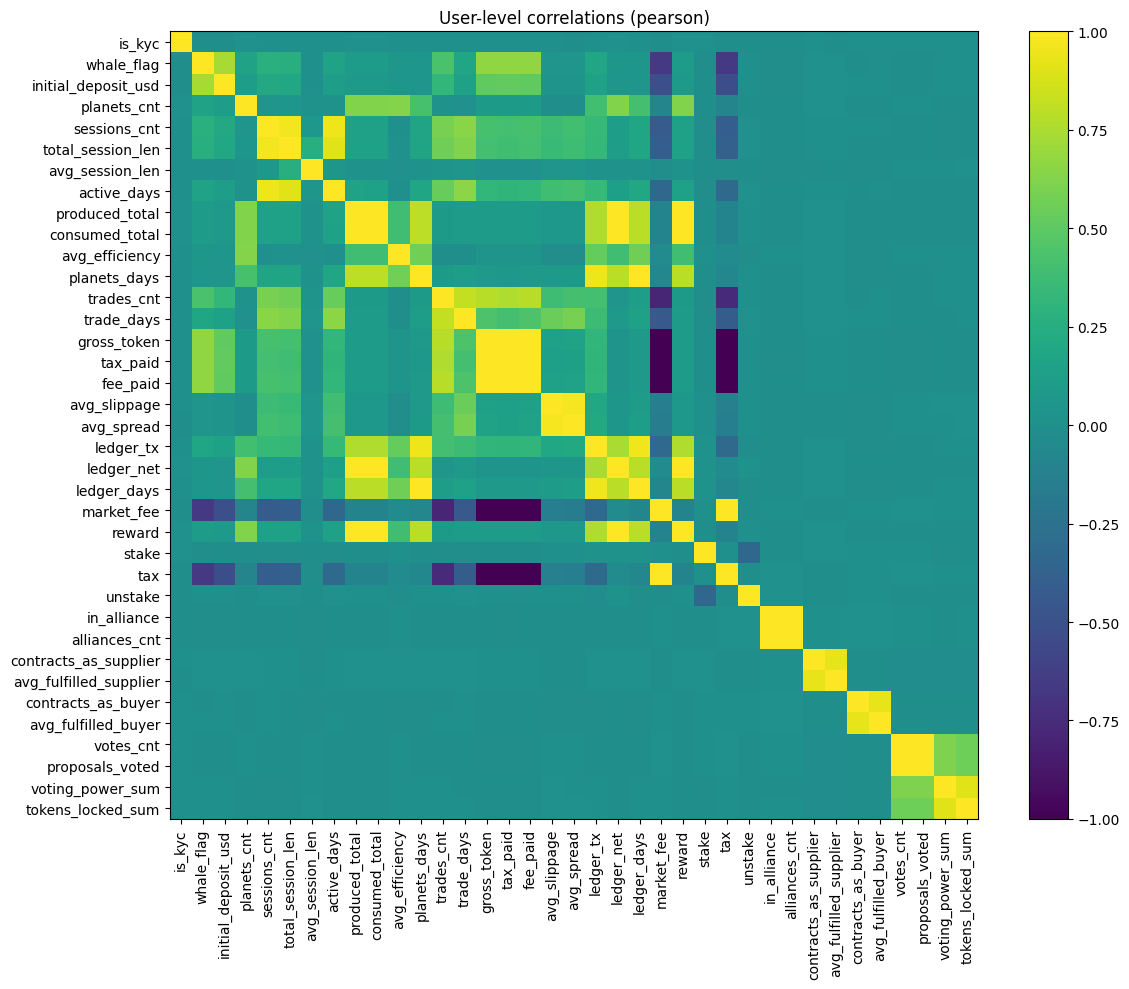

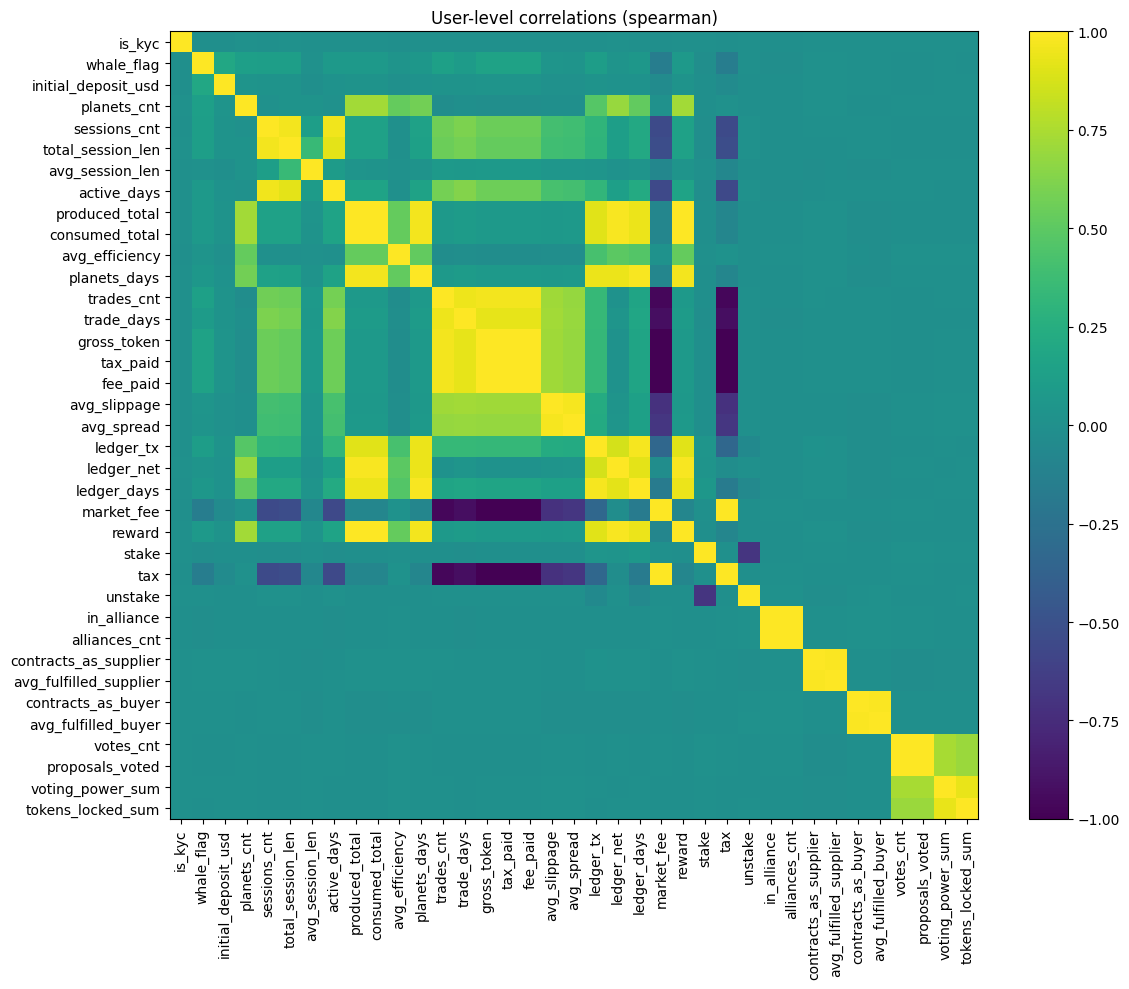

Top correlation pairs (Pearson):


,a,b,corr
614,fee_paid,market_fee,-1.000000
1255,votes_cnt,proposals_voted,1.000000
1027,in_alliance,alliances_cnt,1.000000
580,tax_paid,tax,-1.000000
534,gross_token,fee_paid,1.000000
540,gross_token,market_fee,-1.000000
305,produced_total,consumed_total,0.999919
319,produced_total,reward,0.998834
356,consumed_total,reward,0.998746
428,planets_days,ledger_days,0.998631


Top correlation pairs (Spearman):


,a,b,corr
580,tax_paid,tax,-1.000000
1255,votes_cnt,proposals_voted,1.000000
614,fee_paid,market_fee,-1.000000
1027,in_alliance,alliances_cnt,1.000000
534,gross_token,fee_paid,1.000000
540,gross_token,market_fee,-1.000000
543,gross_token,tax,-0.999991
533,gross_token,tax_paid,0.999991
839,market_fee,tax,0.999991
571,tax_paid,fee_paid,0.999991


In [13]:
def corr_heatmap(df_num: pd.DataFrame, title: str, method="pearson"):
    if df_num.shape[1] < 2:
        print(title, "- not enough numeric columns")
        return
    corr = df_num.corr(method=method)
    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect="auto", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(f"{title} ({method})")
    plt.tight_layout()
    plt.show()

def top_corr_pairs(df_num: pd.DataFrame, method="pearson", topk=25):
    corr = df_num.corr(method=method).stack().reset_index()
    corr.columns = ["a","b","corr"]
    corr = corr[corr["a"] != corr["b"]]
    corr["abs"] = corr["corr"].abs()
    corr["pair"] = corr.apply(lambda r: "||".join(sorted([r["a"], r["b"]])), axis=1)
    corr = corr.drop_duplicates("pair").sort_values("abs", ascending=False).head(topk)
    return corr[["a","b","corr"]]

num = feat.select_dtypes(include=[np.number]).copy()
if "user_id" in num.columns:
    num = num.drop(columns=["user_id"])

corr_heatmap(num, "User-level correlations", method="pearson")
corr_heatmap(num, "User-level correlations", method="spearman")

print("Top correlation pairs (Pearson):")
display(top_corr_pairs(num, method="pearson", topk=25))

print("Top correlation pairs (Spearman):")
display(top_corr_pairs(num, method="spearman", topk=25))


planets_cnt                       sessions_cnt                        active_days                       produced_total                               trades_cnt                        \
                   mean median      sum count         mean median       sum count        mean median      sum count           mean    median           sum count       mean median      sum count   
acq_channel                                                                                                                                                                                         
ads               1.605    1.0  11116.0  6925       13.644   12.0   94488.0  6925       8.462    7.0  58602.0  6925       8837.871  4227.879  6.120226e+07  6925      2.863    1.0  19825.0  6925   
influencer        1.678    1.0   3293.0  1963       14.485   13.0   28434.0  1963       9.136    8.0  17934.0  1963       9292.101  4210.868  1.824039e+07  1963      2.977    2.0   5844.0  1963   
organic           1.620    1.0  11497.0  7097       14.581   13.0  103482.0  7097       9.183    8.0  65171.0  7097       8806.507  4284.905  6.249978e+07  7097      3.035    2.0  21540.0  7097   
partner           1.608    1.0   1622.0  1009       14.005   13.0   14131.0  1009       8.845    8.0   8925.0  1009       8702.946  3841.794  8.781272e+06  1009      2.893    2.0   2919.0  1009   
referral          1.600    1.0   4810.0  3006       15.218   14.0   45744.0  3006       9.692    9.0  29134.0  3006       8771.405  4212.106  2.636684e+07  3006      3.206    2.0   9638.0  3006   

            gross_token                           tax_paid                         fee_paid                        ledger_net                             ledger_tx                        votes_cnt  \
                   mean  median         sum count     mean median        sum count     mean median       sum count       mean   median          sum count      mean median       sum count      mean   
acq_channel                                                                                                                                                                                            
ads             114.048  29.175  789779.944  6925    6.130  1.459  42446.837  6925    0.228  0.058  1579.560  6925    348.907  163.713  2416178.591  6925    36.530   32.0  252968.0  6925     2.925   
influencer      110.979  32.452  217851.247  1963    5.998  1.623  11774.024  1963    0.222  0.065   435.703  1963    368.290  166.658   722952.435  1963    37.472   32.0   73557.0  1963     2.875   
organic         115.714  34.102  821218.900  7097    6.175  1.705  43822.718  7097    0.231  0.068  1642.438  7097    347.856  166.074  2468734.398  7097    37.054   33.0  262972.0  7097     2.942   
partner          91.421  34.319   92243.733  1009    4.713  1.721   4755.636  1009    0.183  0.069   184.487  1009    345.889  149.402   349002.147  1009    36.151   31.0   36476.0  1009     3.065   
referral        103.262  38.829  310405.266  3006    5.377  1.941  16164.219  3006    0.207  0.078   620.811  3006    346.629  165.959  1041968.121  3006    37.383   34.0  112372.0  3006     2.958   

                                  in_alliance                       
            median      sum count        mean median     sum count  
acq_channel                                                         
ads            3.0  20257.0  6925       0.413    0.0  2857.0  6925  
influencer     3.0   5644.0  1963       0.401    0.0   788.0  1963  
organic        3.0  20878.0  7097       0.424    0.0  3006.0  7097  
partner        3.0   3093.0  1009       0.424    0.0   428.0  1009  
referral       3.0   8893.0  3006       0.436    0.0  1311.0  3006

planets_cnt                       sessions_cnt                        active_days                       produced_total                               trades_cnt                        \
                      mean median      sum count         mean median       sum count        mean median      sum count           mean    median           sum count       mean median      sum count   
player_segment                                                                                                                                                                                         
builder              2.175    2.0  17584.0  8085       14.614   13.0  118152.0  8085       9.265    8.0  74906.0  8085      11917.273  6946.581  9.635115e+07  8085      2.476    1.0  20016.0  8085   
investor             1.244    1.0   4962.0  3988       11.919   11.0   47533.0  3988       7.882    7.0  31433.0  3988       6761.662  2581.780  2.696551e+07  3988      2.272    1.0   9061.0  3988   
social               1.248    1.0   2505.0  2007       12.204   11.0   24494.0  2007       8.194    7.0  16445.0  2007       7047.271  3006.996  1.414387e+07  2007      2.159    1.0   4334.0  2007   
trader               1.231    1.0   7287.0  5920       16.233   15.0   96100.0  5920       9.625    8.0  56982.0  5920       6694.259  2363.442  3.963001e+07  5920      4.452    3.0  26355.0  5920   

               gross_token                            tax_paid                         fee_paid                        ledger_net                             ledger_tx                         \
                      mean  median          sum count     mean median        sum count     mean median       sum count       mean   median          sum count      mean median       sum count   
player_segment                                                                                                                                                                                   
builder             85.877  27.977   694315.732  8085    4.499  1.399  36376.001  8085    0.172  0.056  1388.631  8085    474.022  275.747  3832466.231  8085    40.767   40.0  329602.0  8085   
investor            92.528  20.528   369001.722  3988    4.969  1.026  19815.042  3988    0.185  0.041   738.003  3988    267.083  101.307  1065128.772  3988    32.284   24.0  128747.0  3988   
social              80.923  23.503   162413.227  2007    4.304  1.175   8637.355  2007    0.162  0.047   324.827  2007    279.482  118.195   560919.858  2007    32.814   26.0   65857.0  2007   
trader             169.893  63.458  1005768.409  5920    9.144  3.173  54135.035  5920    0.340  0.127  2011.537  5920    260.189   89.650  1540320.830  5920    36.172   28.0  214139.0  5920   

               votes_cnt                       in_alliance                       
                    mean median      sum count        mean median     sum count  
player_segment                                                                   
builder            2.948    3.0  23833.0  8085       0.427    0.0  3451.0  8085  
investor           2.922    3.0  11653.0  3988       0.424    0.0  1689.0  3988  
social             2.892    3.0   5805.0  2007       0.408    0.0   819.0  2007  
trader             2.952    3.0  17474.0  5920       0.411    0.0  2431.0  5920

planets_cnt                        sessions_cnt                         active_days                         produced_total                                 trades_cnt                  \
                  mean median      sum  count         mean median       sum  count        mean median       sum  count           mean     median           sum  count       mean median      sum   
whale_flag                                                                                                                                                                                         
0                1.593    1.0  31440.0  19734       14.015   13.0  276564.0  19734       8.880    8.0  175240.0  19734       8716.511   4133.493  1.720116e+08  19734      2.751    2.0  54294.0   
1                3.376    3.0    898.0    266       36.523   36.0    9715.0    266      17.015   14.0    4526.0    266      19093.651  12753.171  5.078911e+06    266     20.571   14.0   5472.0   

                  gross_token                               tax_paid                            fee_paid                         ledger_net                              ledger_tx                   \
            count        mean    median          sum  count     mean   median        sum  count     mean median       sum  count       mean   median          sum  count      mean median       sum   
whale_flag                                                                                                                                                                                            
0           19734      74.354    32.060  1467306.236  19734    3.719    1.604  73396.775  19734    0.149  0.064  2934.613  19734    346.748  163.262  6842731.397  19734    36.277   32.0  715897.0   
1             266    2872.905  1991.801   764192.854    266  171.303  117.903  45566.659    266    5.746  3.984  1528.386    266    586.858  329.287   156104.294    266    84.391   83.0   22448.0   

                  votes_cnt                        in_alliance                        
            count      mean median      sum  count        mean median     sum  count  
whale_flag                                                                            
0           19734     2.939    3.0  58007.0  19734       0.420    0.0  8296.0  19734  
1             266     2.850    3.0    758.0    266       0.353    0.0    94.0    266

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\3805725560.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


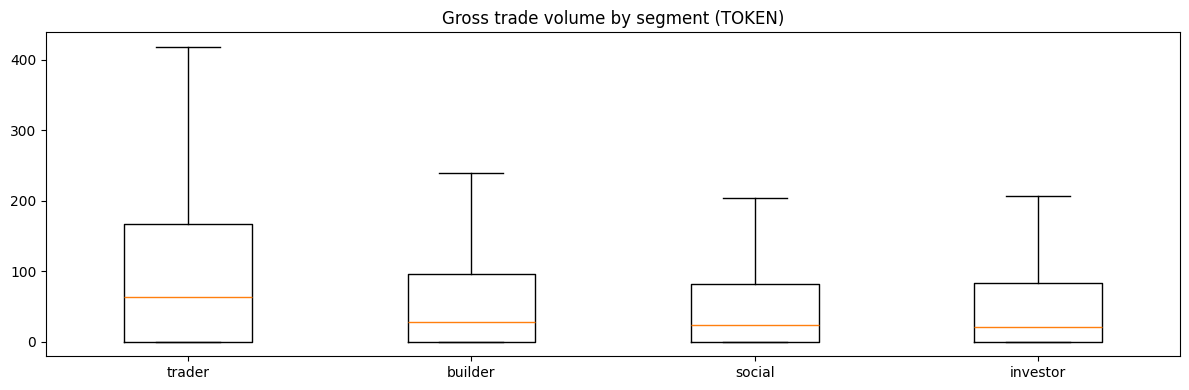

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\3805725560.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


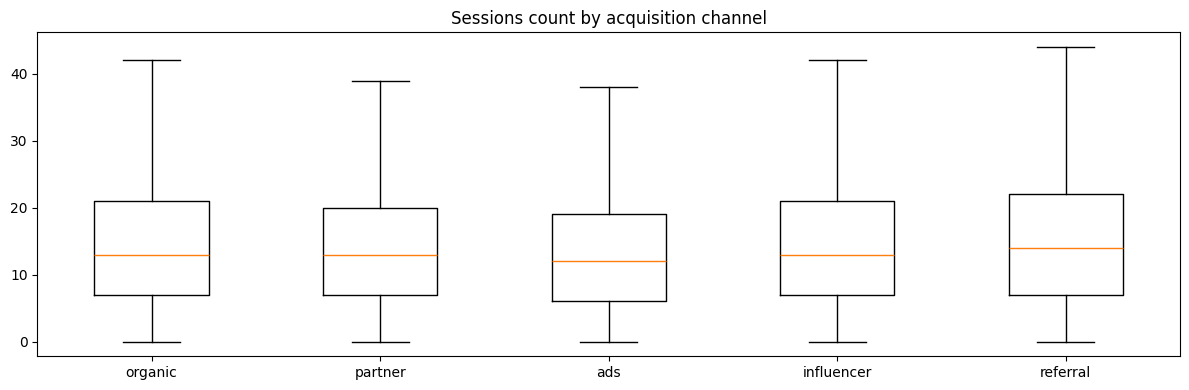

In [14]:
def group_summary(df: pd.DataFrame, group_col: str, metrics: list[str]) -> pd.DataFrame:
    return df.groupby(group_col)[metrics].agg(["mean","median","sum","count"]).round(3)

def box_by_group(df, group_col, value_col, title):
    tmp = df[[group_col, value_col]].copy()
    tmp = tmp[tmp[value_col].notna()]
    groups = tmp[group_col].astype(str).unique().tolist()
    data = [tmp[tmp[group_col].astype(str)==g][value_col].values for g in groups]
    plt.figure(figsize=(12,4))
    plt.boxplot(data, labels=groups, showfliers=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

metrics_focus = [
    "planets_cnt","sessions_cnt","active_days","produced_total",
    "trades_cnt","gross_token","tax_paid","fee_paid",
    "ledger_net","ledger_tx","votes_cnt","in_alliance"
]
metrics_focus = [m for m in metrics_focus if m in feat.columns]

if "acq_channel" in feat.columns:
    display(group_summary(feat, "acq_channel", metrics_focus))

if "player_segment" in feat.columns:
    display(group_summary(feat, "player_segment", metrics_focus))

if "whale_flag" in feat.columns:
    display(group_summary(feat, "whale_flag", metrics_focus))

if "player_segment" in feat.columns and "gross_token" in feat.columns:
    box_by_group(feat, "player_segment", "gross_token", "Gross trade volume by segment (TOKEN)")

if "acq_channel" in feat.columns and "sessions_cnt" in feat.columns:
    box_by_group(feat, "acq_channel", "sessions_cnt", "Sessions count by acquisition channel")


> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

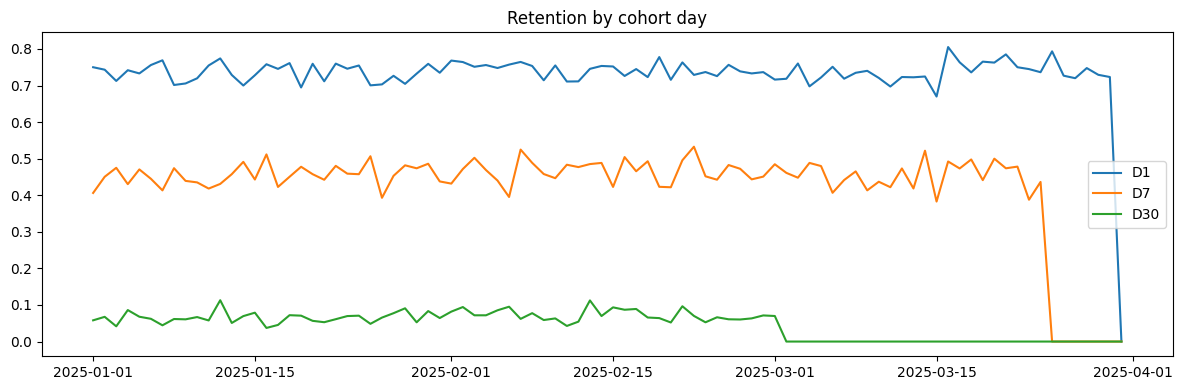

,users,r1,r7,r30
acq_channel,,,,
organic,7097,0.724109,0.429759,0.049176
ads,6925,0.733285,0.400433,0.035957
referral,3006,0.732202,0.446773,0.054890
influencer,1963,0.738156,0.433520,0.054508
partner,1009,0.711596,0.429138,0.050545


In [15]:
if sessions is None or users is None:
    print("Need sessions + users for retention")
else:
    s = sessions.copy()
    s["day"] = pd.to_datetime(s["start_ts"]).dt.floor("D")
    u = users.copy()
    u["cohort_day"] = pd.to_datetime(u["created_at"]).dt.floor("D")

    act = s.groupby("user_id")["day"].apply(lambda x: set(x.unique())).reset_index(name="active_set")
    base = u[["user_id","cohort_day","acq_channel","player_segment","whale_flag"]].merge(act, on="user_id", how="left")
    base["active_set"] = base["active_set"].apply(lambda x: x if isinstance(x, set) else set())

    def retention_at(d):
        return base.apply(lambda r: int((r["cohort_day"] + pd.Timedelta(days=d)) in r["active_set"]), axis=1)

    for d in [1,7,30]:
        base[f"ret_d{d}"] = retention_at(d)

    cohort = base.groupby("cohort_day").agg(
        users=("user_id","count"),
        r1=("ret_d1","mean"),
        r7=("ret_d7","mean"),
        r30=("ret_d30","mean")
    ).reset_index()

    plt.figure(figsize=FIGSIZE)
    plt.plot(cohort["cohort_day"], cohort["r1"], label="D1")
    plt.plot(cohort["cohort_day"], cohort["r7"], label="D7")
    plt.plot(cohort["cohort_day"], cohort["r30"], label="D30")
    plt.legend()
    plt.title("Retention by cohort day")
    plt.tight_layout(); plt.show()

    ch = base.groupby("acq_channel").agg(
        users=("user_id","count"),
        r1=("ret_d1","mean"),
        r7=("ret_d7","mean"),
        r30=("ret_d30","mean")
    ).sort_values("users", ascending=False)

    display(ch)

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

,stage,users,conv_from_prev
0,signed_up,20000,NaN
1,has_planet,15613,0.780650
2,has_session,19827,1.269903
3,produced_resources,15613,0.787462
4,made_trade,12985,0.831679
5,has_ledger_tx,18769,1.445437
6,staked_or_unstaked,3600,0.191806
7,voted_in_DAO,18963,5.267500
8,joined_alliance,8390,0.442441
9,has_contract,7289,0.868772


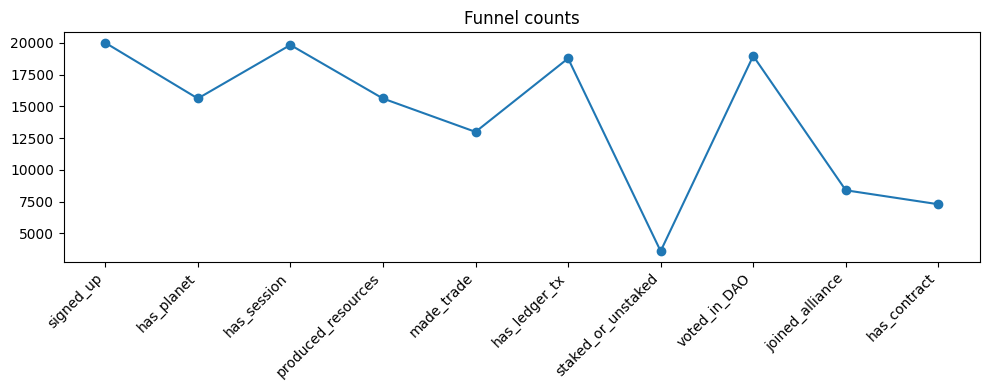

In [16]:
funnel = pd.DataFrame({
    "stage": [
        "signed_up",
        "has_planet",
        "has_session",
        "produced_resources",
        "made_trade",
        "has_ledger_tx",
        "staked_or_unstaked",
        "voted_in_DAO",
        "joined_alliance",
        "has_contract"
    ],
    "users": [
        len(feat),
        int((feat.get("planets_cnt",0) > 0).sum()),
        int((feat.get("sessions_cnt",0) > 0).sum()),
        int((feat.get("produced_total",0) > 0).sum()),
        int((feat.get("trades_cnt",0) > 0).sum()),
        int((feat.get("ledger_tx",0) > 0).sum()),
        int(((feat.get("stake",0) != 0) | (feat.get("unstake",0) != 0)).sum()) if ("stake" in feat.columns or "unstake" in feat.columns) else 0,
        int((feat.get("votes_cnt",0) > 0).sum()),
        int((feat.get("in_alliance",0) > 0).sum()),
        int(((feat.get("contracts_as_supplier",0) > 0) | (feat.get("contracts_as_buyer",0) > 0)).sum())
    ]
})
funnel["conv_from_prev"] = funnel["users"] / funnel["users"].shift(1)
display(funnel)

plt.figure(figsize=(10,4))
plt.plot(funnel["stage"], funnel["users"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Funnel counts")
plt.tight_layout(); plt.show()


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

[merge keys] mt_res='asset_base', po_res='resource'
volatility missing rate after merge: 0.00%


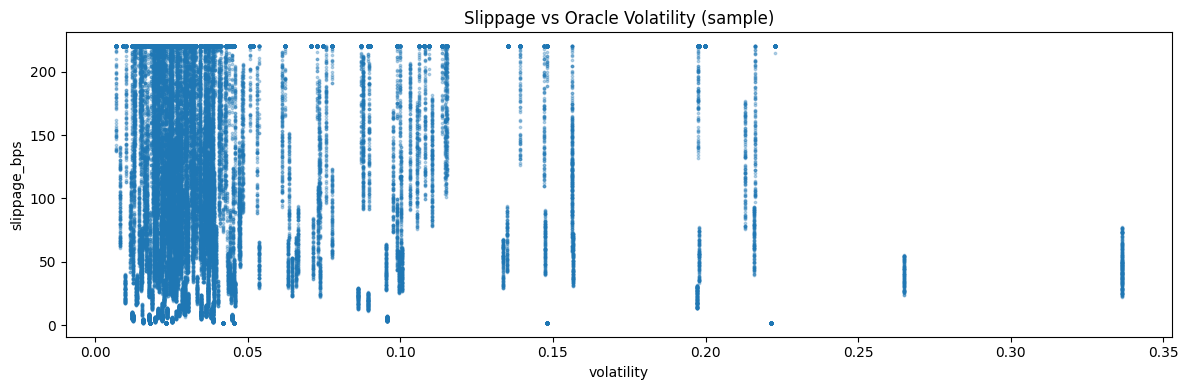

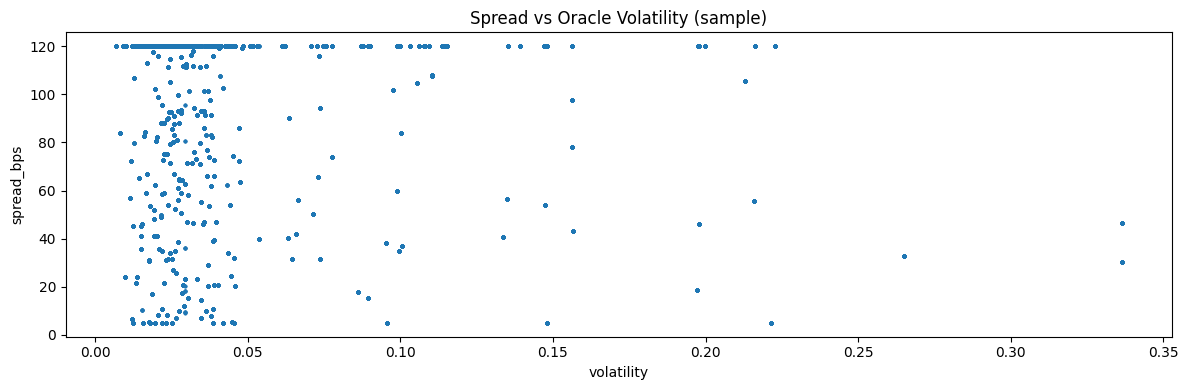

,trades,gross,avg_tax,avg_slippage
user_7d_volume_bucket,,,,
high,305,4.361335e+04,10.724595,134.838754
low,54886,1.558071e+06,1.419370,134.212322
mid,4575,6.298146e+05,8.259864,133.810723


In [17]:
RANDOM_SEED = 42
FIGSIZE = (12, 4)

def pick_resource_col(df: pd.DataFrame):
    # самые вероятные названия
    candidates = [
        "resource", "asset_base", "asset", "token", "token_symbol",
        "asset_exch", "instrument_exch", "market", "market_id"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: попробуем найти что-то похожее
    like = [c for c in df.columns if "asset" in c.lower() or "resource" in c.lower() or "instrument" in c.lower()]
    return like[0] if like else None

if market_trades is None or price_oracle is None:
    print("Need market_trades + price_oracle_daily for microstructure EDA")
else:
    mt = market_trades.copy()
    mt["day"] = pd.to_datetime(mt["ts"], errors="coerce").dt.floor("D")

    po = price_oracle.copy()
    po["day"] = pd.to_datetime(po["day"], errors="coerce").dt.floor("D")

    # 1) определяем колонку ресурса в mt
    mt_res = pick_resource_col(mt)
    if mt_res is None:
        raise ValueError(f"Не смог определить колонку ресурса в market_trades. Колонки: {list(mt.columns)}")

    # 2) в oracle ожидаем 'resource', но если вдруг иначе — тоже определим
    po_res = "resource" if "resource" in po.columns else pick_resource_col(po)
    if po_res is None:
        raise ValueError(f"Не смог определить колонку ресурса в price_oracle. Колонки: {list(po.columns)}")

    print(f"[merge keys] mt_res='{mt_res}', po_res='{po_res}'")

    # 3) если mt_res это instrument_exch типа 'ASTERUSDT', а oracle хранит 'ASTER' —
    #    можно добавить "нормализацию" (опционально). Пока просто пробуем прямой merge.
    m2 = mt.merge(
        po.rename(columns={po_res: "resource_key"})[["day", "resource_key", "volatility", "price_token"]],
        left_on=["day", mt_res],
        right_on=["day", "resource_key"],
        how="left"
    )

    # если почти всё NaN по volatility — вероятно нужен маппинг/нормализация
    miss_rate = m2["volatility"].isna().mean()
    print(f"volatility missing rate after merge: {miss_rate:.2%}")
    if miss_rate > 0.85:
        print("⚠️ Похоже, ключи не совпали (например instrument_exch vs resource). Нужно нормализовать ключи. См. блок ниже.")

    # scatter sample
    sample_n = min(50000, len(m2))
    sample = m2.sample(sample_n, random_state=RANDOM_SEED) if sample_n > 0 else m2

    if "volatility" in sample.columns and sample["volatility"].notna().any():
        plt.figure(figsize=FIGSIZE)
        plt.scatter(sample["volatility"], sample["slippage_bps"], s=3, alpha=0.3)
        plt.title("Slippage vs Oracle Volatility (sample)")
        plt.xlabel("volatility"); plt.ylabel("slippage_bps")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=FIGSIZE)
        plt.scatter(sample["volatility"], sample["spread_bps"], s=3, alpha=0.3)
        plt.title("Spread vs Oracle Volatility (sample)")
        plt.xlabel("volatility"); plt.ylabel("spread_bps")
        plt.tight_layout(); plt.show()
    else:
        print("Нет volatility после merge (или все NaN).")

    # buckets
    if "user_7d_volume_bucket" in mt.columns:
        mt2 = mt.copy()
        mt2["gross_token"] = mt2["amount_base"] * mt2["price"]
        bucket = mt2.groupby("user_7d_volume_bucket").agg(
            trades=("trade_id","count"),
            gross=("gross_token","sum"),
            avg_tax=("tax_amount","mean"),
            avg_slippage=("slippage_bps","mean")
        )
        display(bucket)


> **Econometric Analysis:**
The Laffer curve clearly demonstrates the saturation point where further tax increases begin to suppress trading activity. Distinguishing between Extensive and Intensive margins helps understand whether the tax discourages the trade itself or simply reduces its average volume.

Top 1% wealth_proxy share: 0.070


C:\Users\Shaim\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


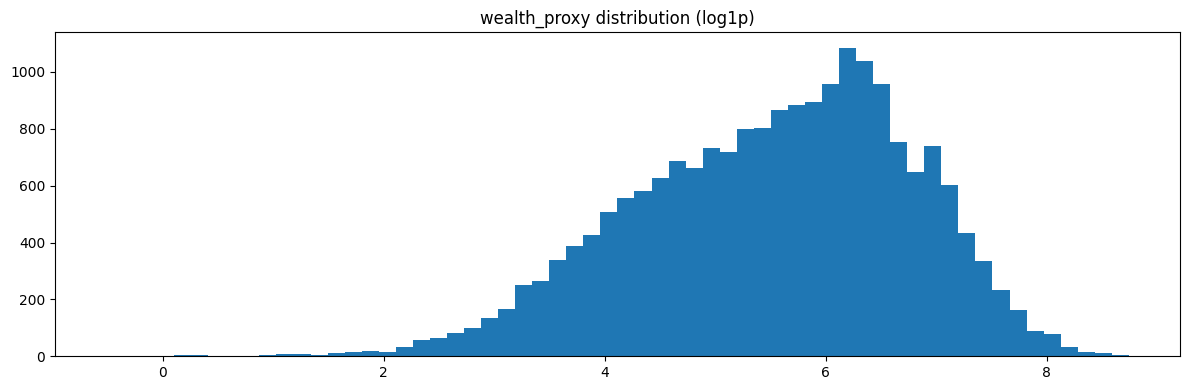

In [18]:
if "ledger_net" not in feat.columns:
    print("No ledger_net in feat (token_ledger missing?)")
else:
    wealth = feat[["user_id","whale_flag","initial_deposit_usd","ledger_net"]].copy()
    wealth["wealth_proxy"] = wealth["initial_deposit_usd"] + wealth["ledger_net"]
    wealth = wealth.sort_values("wealth_proxy", ascending=False)

    n = len(wealth)
    top1 = max(1, int(n * 0.01))
    share_top1 = wealth.head(top1)["wealth_proxy"].sum() / max(1e-9, wealth["wealth_proxy"].sum())
    print(f"Top 1% wealth_proxy share: {share_top1:.3f}")

    plot_hist(wealth["wealth_proxy"], "wealth_proxy distribution", log=True)


> **Analytical Comment (EDA):**
Initial distribution analysis reveals 'heavy tails' in trading volumes and activity. Special attention should be paid to users in the top deciles (whales), as they generate the bulk of liquidity. Missing value checks confirm data quality for further econometric modeling.

,users,avg_gross,avg_trades,avg_active_days,avg_ledger
in_alliance,,,,,
0.0,11610,114.700747,3.013351,9.015332,351.695123
1.0,8390,107.249514,2.953635,8.950894,347.515532


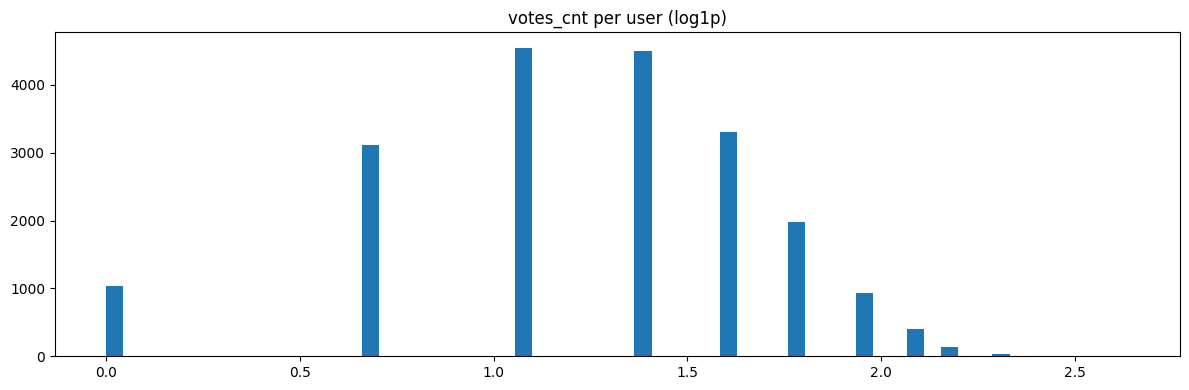

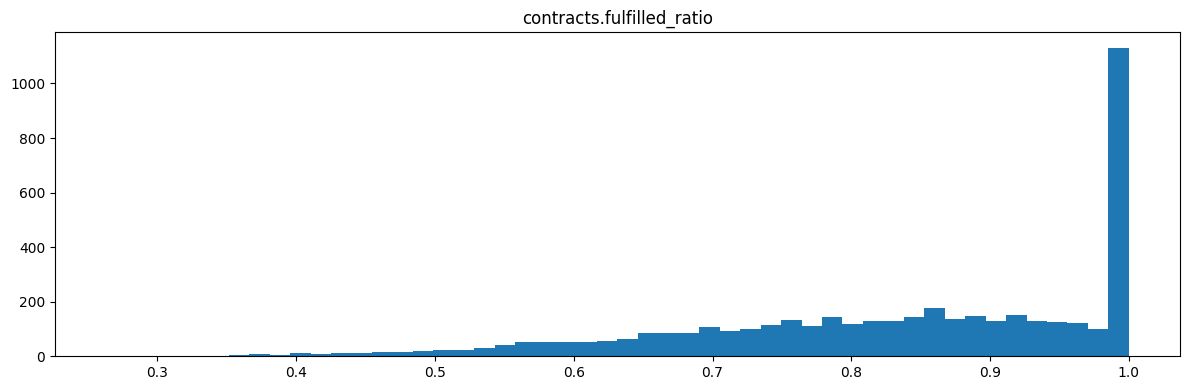

In [19]:
if "in_alliance" in feat.columns and "gross_token" in feat.columns:
    grp = feat.groupby("in_alliance").agg(
        users=("user_id","count"),
        avg_gross=("gross_token","mean"),
        avg_trades=("trades_cnt","mean"),
        avg_active_days=("active_days","mean"),
        avg_ledger=("ledger_net","mean") if "ledger_net" in feat.columns else ("user_id","count")
    )
    display(grp)

if "votes_cnt" in feat.columns:
    plot_hist(feat["votes_cnt"], "votes_cnt per user", log=True)

if contracts is not None:
    plot_hist(contracts["fulfilled_ratio"], "contracts.fulfilled_ratio", bins=50)


> **Analytical Comment (EDA):**
Initial distribution analysis reveals 'heavy tails' in trading volumes and activity. Special attention should be paid to users in the top deciles (whales), as they generate the bulk of liquidity. Missing value checks confirm data quality for further econometric modeling.

In [20]:
if exp_assign is None or experiments is None:
    print("No experiments/assignments tables found")
else:
    ea = exp_assign.copy()
    ea["assigned_ts"] = pd.to_datetime(ea["assigned_ts"], errors="coerce")
    display(ea.groupby(["experiment_id","variant"]).agg(n=("user_id","count")).reset_index())

    ab = ea.merge(feat, on="user_id", how="left")

    cov = ["initial_deposit_usd","whale_flag","player_segment","acq_channel","planets_cnt","sessions_cnt"]
    cov = [c for c in cov if c in ab.columns]

    for exp_id in ab["experiment_id"].unique():
        sub = ab[ab["experiment_id"]==exp_id].copy()
        print(f"\nExperiment: {exp_id}")

        num_cov = [c for c in cov if pd.api.types.is_numeric_dtype(sub[c])]
        if num_cov:
            display(sub.groupby("variant")[num_cov].mean().round(3))

        cat_cov = [c for c in cov if sub[c].dtype == "O"]
        for c in cat_cov:
            display(pd.crosstab(sub["variant"], sub[c], normalize="index").round(3))


,experiment_id,variant,n
0,EXP_NFT_RENT,A,1941
1,EXP_NFT_RENT,B,1993
2,EXP_TAX_DYNAMIC,A,2567
3,EXP_TAX_DYNAMIC,B,2597



Experiment: EXP_TAX_DYNAMIC


,initial_deposit_usd,whale_flag,planets_cnt,sessions_cnt
variant,,,,
A,122.549,0.019,1.660,16.228
B,109.595,0.006,1.585,15.729


player_segment,builder,investor,social,trader
variant,,,,
A,0.409,0.202,0.097,0.293
B,0.408,0.202,0.098,0.292


acq_channel,ads,influencer,organic,partner,referral
variant,,,,,
A,0.336,0.103,0.350,0.051,0.159
B,0.332,0.101,0.362,0.047,0.157



Experiment: EXP_NFT_RENT


,initial_deposit_usd,whale_flag,planets_cnt,sessions_cnt
variant,,,,
A,122.423,0.012,1.613,16.072
B,124.935,0.017,1.618,16.088


player_segment,builder,investor,social,trader
variant,,,,
A,0.405,0.199,0.098,0.298
B,0.399,0.199,0.112,0.290


acq_channel,ads,influencer,organic,partner,referral
variant,,,,,
A,0.353,0.098,0.359,0.046,0.144
B,0.352,0.097,0.357,0.043,0.151


In [21]:
# --- checks ---
need = ["users", "sessions", "market_trades"]
for n in need:
    if n not in globals() or globals()[n] is None:
        raise ValueError(f"Not found {n}. Check users/sessions/market_trades.")

# --- build minimal user-level feature table for ML (можно заменить на твой feat, если он уже есть) ---
feat_ml = users[[
    "user_id","created_at","country","acq_channel","device_os","client","app_version",
    "wallet_type","chain_pref","is_kyc","player_segment","risk_profile","whale_flag","initial_deposit_usd"
]].copy()

feat_ml["cohort_day"] = pd.to_datetime(feat_ml["created_at"]).dt.floor("D")

# sessions aggregates
s = sessions.copy()
s["start_ts"] = pd.to_datetime(s["start_ts"], errors="coerce")
s["day"] = s["start_ts"].dt.floor("D")

agg_s = s.groupby("user_id").agg(
    sessions_cnt=("session_id","count"),
    total_session_len=("session_len_sec","sum"),
    avg_session_len=("session_len_sec","mean"),
    active_days=("day","nunique"),
    first_session=("start_ts","min"),
    last_session=("start_ts","max"),
).reset_index()

feat_ml = feat_ml.merge(agg_s, on="user_id", how="left")

# market aggregates
mt = market_trades.copy()
mt["ts"] = pd.to_datetime(mt["ts"], errors="coerce")
mt["gross_token"] = mt["amount_base"] * mt["price"]

agg_m = mt.groupby("maker_user_id").agg(
    trades_cnt=("trade_id","count"),
    trade_days=("ts", lambda x: x.dt.floor("D").nunique()),
    gross_token=("gross_token","sum"),
    tax_paid=("tax_amount","sum"),
    fee_paid=("fee_amount","sum"),
    avg_slippage=("slippage_bps","mean"),
    avg_spread=("spread_bps","mean"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

feat_ml = feat_ml.merge(agg_m, on="user_id", how="left")

# fill numeric NaNs -> 0
num_cols = [c for c in feat_ml.columns if pd.api.types.is_numeric_dtype(feat_ml[c])]
feat_ml[num_cols] = feat_ml[num_cols].fillna(0)

# --- targets ---
feat_ml["made_trade"] = (feat_ml["trades_cnt"] > 0).astype(int)

# retention D7: активность в cohort_day + 7
act_days = s.groupby("user_id")["day"].apply(lambda x: set(x.dropna().unique())).reset_index(name="active_set")
tmp = feat_ml[["user_id","cohort_day"]].merge(act_days, on="user_id", how="left")
tmp["active_set"] = tmp["active_set"].apply(lambda x: x if isinstance(x, set) else set())
feat_ml["ret_d7"] = tmp.apply(lambda r: int((r["cohort_day"] + pd.Timedelta(days=7)) in r["active_set"]), axis=1)

display(feat_ml[["user_id","made_trade","ret_d7","sessions_cnt","trades_cnt","gross_token"]].head())
print("Targets distribution:")
print("made_trade:", feat_ml["made_trade"].mean().round(3), "positive_rate")
print("ret_d7:", feat_ml["ret_d7"].mean().round(3), "positive_rate")


,user_id,made_trade,ret_d7,sessions_cnt,trades_cnt,gross_token
0,1,1,1,9.0,14.0,542.230554
1,2,0,1,18.0,0.0,0.000000
2,3,0,1,13.0,0.0,0.000000
3,4,1,1,26.0,5.0,145.837689
4,5,1,0,14.0,4.0,48.410813


Targets distribution:
made_trade: 0.649 positive_rate
ret_d7: 0.422 positive_rate


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[made_trade] LogisticRegression: ROC-AUC=0.803, PR-AUC=0.875


,feature,importance
4,active_days,0.265398
3,sessions_cnt,0.031325
6,total_session_len,0.007378
8,player_segment,0.004451
5,avg_session_len,0.000616
0,initial_deposit_usd,0.000475
9,country,0.000186
15,app_version,0.000159
2,whale_flag,0.000019
12,wallet_type,-0.000039


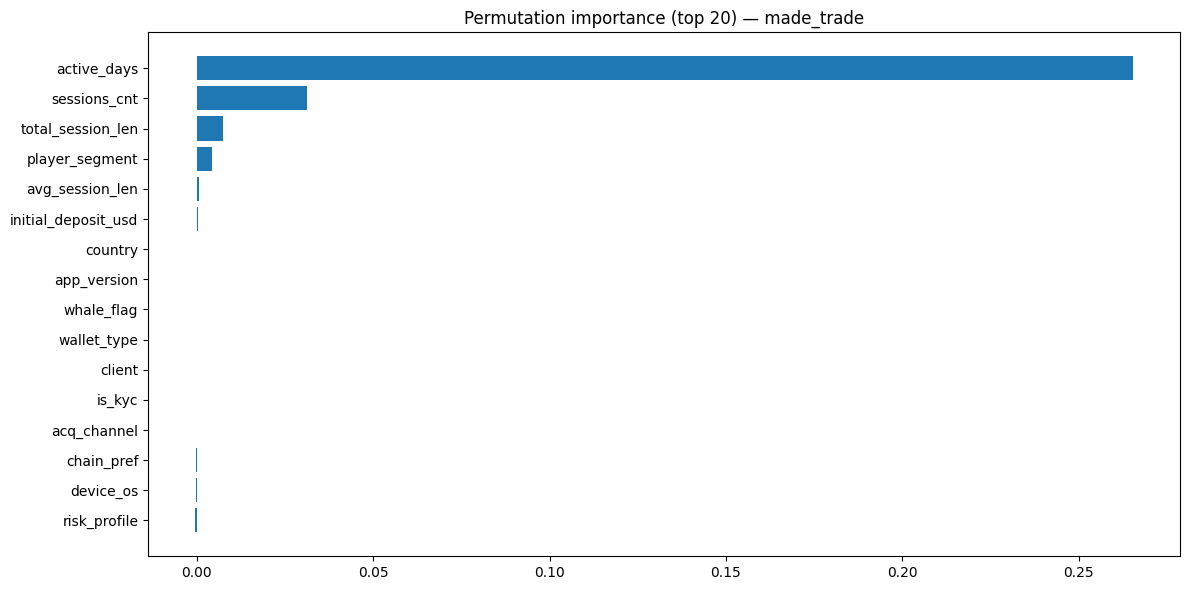

C:\Users\Shaim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[ret_d7] LogisticRegression: ROC-AUC=0.809, PR-AUC=0.692


,feature,importance
4,active_days,0.094355
3,sessions_cnt,0.087493
6,total_session_len,0.001605
8,player_segment,0.000512
14,risk_profile,0.000324
9,country,0.000317
0,initial_deposit_usd,0.000296
11,device_os,0.000202
7,acq_channel,0.000144
1,is_kyc,0.000132


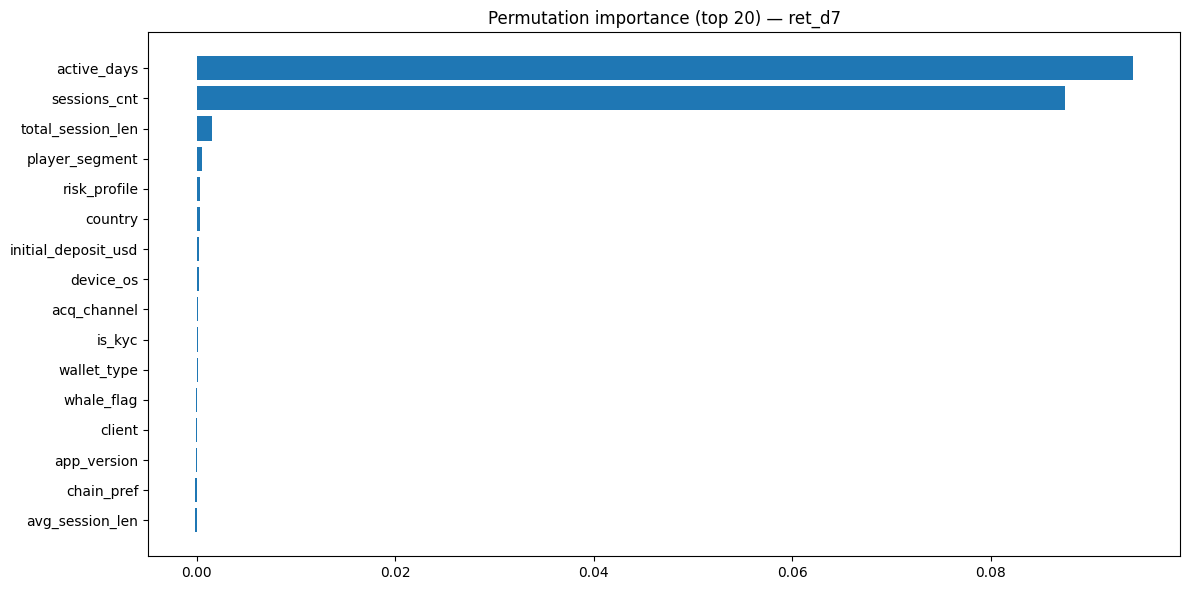

In [22]:

base_features = [
    "initial_deposit_usd","is_kyc","whale_flag",
    "sessions_cnt","active_days","avg_session_len","total_session_len",
]
cat_features = ["acq_channel","player_segment","country","client","device_os","wallet_type","chain_pref","risk_profile","app_version"]

base_features = [c for c in base_features if c in feat_ml.columns]
cat_features  = [c for c in cat_features  if c in feat_ml.columns]

def run_feature_importance(target_col: str):
    df = feat_ml.copy()

    X = df[base_features + cat_features].copy()
    y = df[target_col].astype(int).copy()

    # train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # try sklearn pipeline
    try:
        from sklearn.compose import ColumnTransformer
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import OneHotEncoder
        from sklearn.impute import SimpleImputer
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import roc_auc_score, average_precision_score
        from sklearn.inspection import permutation_importance

        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imp", SimpleImputer(strategy="median")),
                ]), base_features),
                ("cat", Pipeline(steps=[
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]), cat_features),
            ],
            remainder="drop"
        )

        clf = LogisticRegression(max_iter=2000, n_jobs=None)
        pipe = Pipeline(steps=[("pre", pre), ("clf", clf)])

        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]

        roc = roc_auc_score(y_test, proba)
        ap  = average_precision_score(y_test, proba)
        print(f"\n[{target_col}] LogisticRegression: ROC-AUC={roc:.3f}, PR-AUC={ap:.3f}")

        # permutation importance on test
        r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=42, scoring="roc_auc")
        imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
        display(imp.head(20))

        # plot top 20
        top = imp.head(20).iloc[::-1]
        plt.figure(figsize=(12,6))
        plt.barh(top["feature"], top["importance"])
        plt.title(f"Permutation importance (top 20) — {target_col}")
        plt.tight_layout()
        plt.show()

        return pipe, imp

    except Exception as e:
        print("sklearn pipeline failed, fallback to statsmodels. Error:", repr(e))
        import statsmodels.api as sm

        # simple: one-hot manually
        X2 = pd.get_dummies(X, columns=cat_features, dummy_na=True)
        X2 = X2.fillna(X2.median(numeric_only=True))
        X_train2, X_test2, y_train2, y_test2 = train_test_split(
            X2, y, test_size=0.25, random_state=42, stratify=y
        )

        X_train2 = sm.add_constant(X_train2, has_constant="add")
        X_test2  = sm.add_constant(X_test2,  has_constant="add")

        model = sm.Logit(y_train2, X_train2).fit(disp=False)
        pred = model.predict(X_test2)

        # crude AUC (без sklearn) 
        coefs = model.params.drop("const").abs().sort_values(ascending=False)
        print(f"\n[{target_col}] statsmodels Logit fitted. Top |coef|:")
        display(coefs.head(20))

        return model, coefs

# run for both targets
model_trade, imp_trade = run_feature_importance("made_trade")
model_ret7,  imp_ret7  = run_feature_importance("ret_d7")



[made_trade] RandomForest: ROC-AUC=0.802, PR-AUC=0.873


,feature,importance
4,active_days,0.069237
3,sessions_cnt,0.018901
6,total_session_len,0.012360
8,player_segment,0.002760
5,avg_session_len,0.001222
0,initial_deposit_usd,0.000508
7,acq_channel,0.000139
2,whale_flag,0.000085
13,chain_pref,-0.000019
12,wallet_type,-0.000039


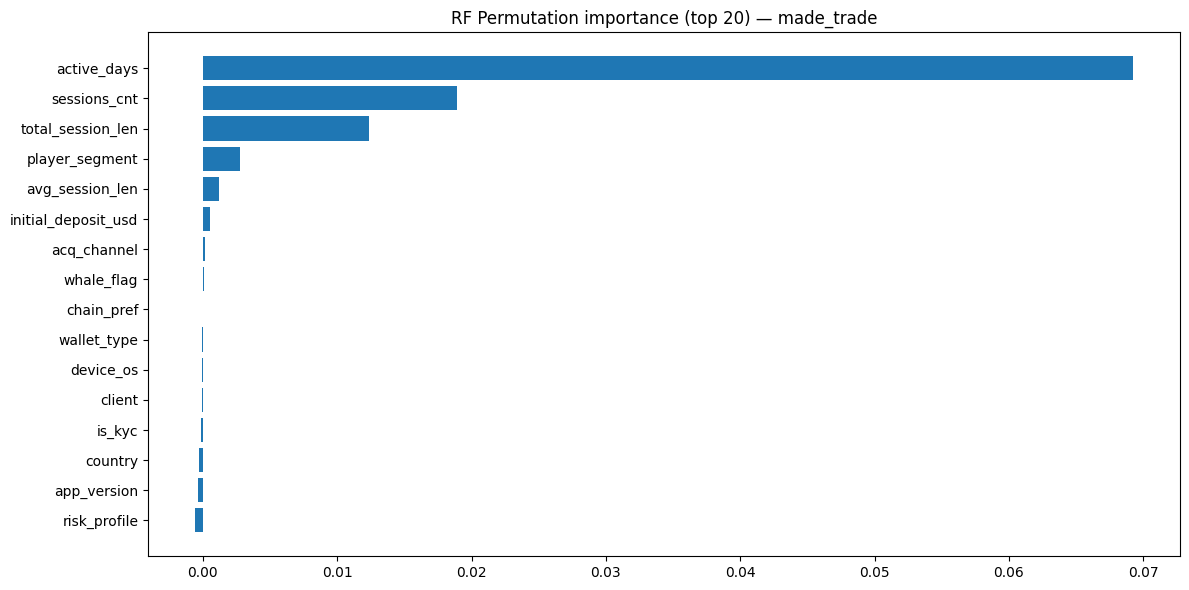


[ret_d7] RandomForest: ROC-AUC=0.809, PR-AUC=0.685


,feature,importance
4,active_days,0.143354
3,sessions_cnt,0.011350
6,total_session_len,0.011171
8,player_segment,0.001340
10,client,0.000706
11,device_os,0.000317
5,avg_session_len,0.000255
15,app_version,0.000230
12,wallet_type,0.000128
1,is_kyc,0.000058


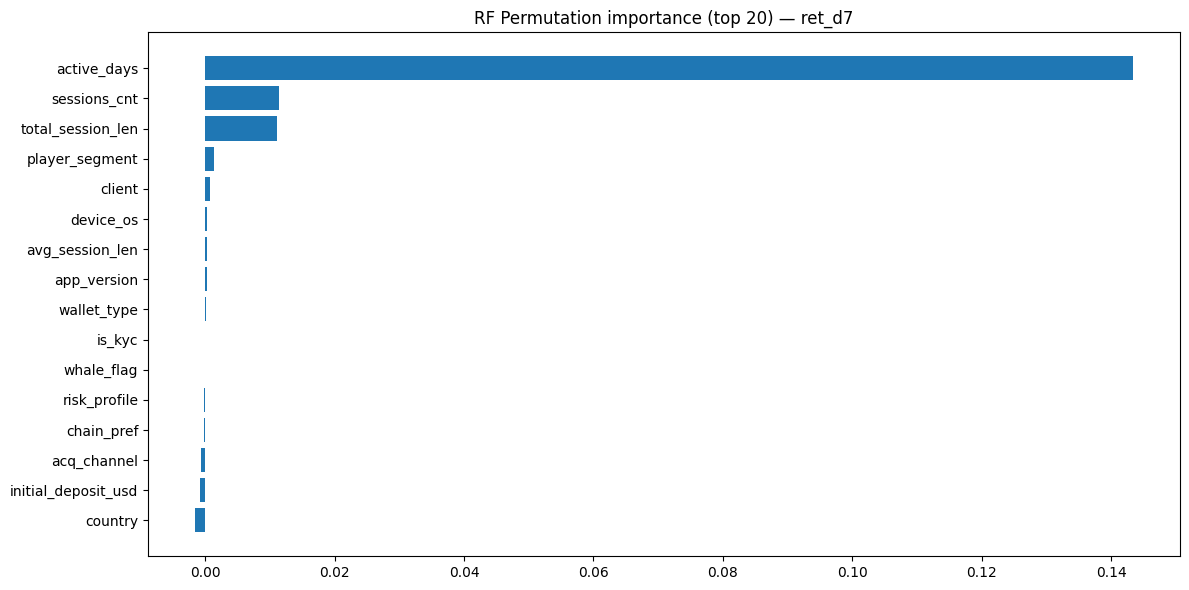

In [23]:
try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import roc_auc_score, average_precision_score
    from sklearn.model_selection import train_test_split
    from sklearn.inspection import permutation_importance

    def rf_importance(target_col: str):
        df = feat_ml.copy()
        X = df[base_features + cat_features].copy()
        y = df[target_col].astype(int).copy()

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline(steps=[
                    ("imp", SimpleImputer(strategy="median")),
                ]), base_features),
                ("cat", Pipeline(steps=[
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]), cat_features),
            ],
            remainder="drop"
        )

        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1
        )

        pipe = Pipeline(steps=[("pre", pre), ("rf", rf)])
        pipe.fit(X_train, y_train)

        proba = pipe.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, proba)
        ap  = average_precision_score(y_test, proba)
        print(f"\n[{target_col}] RandomForest: ROC-AUC={roc:.3f}, PR-AUC={ap:.3f}")

        r = permutation_importance(pipe, X_test, y_test, n_repeats=5, random_state=42, scoring="roc_auc")
        imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
        display(imp.head(20))

        top = imp.head(20).iloc[::-1]
        plt.figure(figsize=(12,6))
        plt.barh(top["feature"], top["importance"])
        plt.title(f"RF Permutation importance (top 20) — {target_col}")
        plt.tight_layout()
        plt.show()

    rf_importance("made_trade")
    rf_importance("ret_d7")

except Exception as e:
    print("RandomForest block skipped (sklearn not available):", repr(e))


In [24]:
RANDOM_SEED = 42

need = ["market_trades","price_oracle","econ_events"]
for n in need:
    if n not in globals() or globals()[n] is None:
        raise ValueError(f"Не найдено {n}. Нужны market_trades, price_oracle_daily, economic_events.")

mt = market_trades.copy()
mt["ts"] = pd.to_datetime(mt["ts"], errors="coerce")
mt["day"] = mt["ts"].dt.floor("D")
mt["gross_token"] = mt["amount_base"] * mt["price"]

po = price_oracle.copy()
po["day"] = pd.to_datetime(po["day"], errors="coerce").dt.floor("D")

print("market_trades columns:", list(mt.columns))
print("price_oracle columns:", list(po.columns))

def pick_resource_col(df: pd.DataFrame):
    candidates = [
        "resource", "asset_base", "asset", "token_symbol", "asset_exch",
        "instrument_exch", "symbol", "pair"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: похожие названия
    like = [c for c in df.columns if any(k in c.lower() for k in ["resource","asset","instrument","symbol","pair"])]
    return like[0] if like else None

res_col = pick_resource_col(mt)
if res_col is None:
    raise ValueError("Не смог определить колонку ресурса в market_trades. Пришли list(mt.columns) — подберу вручную.")

print(f"Chosen res_col in market_trades: {res_col}")

def extract_base_from_instrument(x: str):
    if not isinstance(x, str):
        return x
    x = x.upper().strip()
    # самые частые котировки
    QUOTES = ["USDT","USDC","BUSD","USD","BTC","ETH","EUR","TRY","BRL","GBP"]
    for q in QUOTES:
        if x.endswith(q) and len(x) > len(q):
            return x[:-len(q)]
    return x

if res_col in ["instrument_exch","symbol","pair"]:
    mt["resource_key"] = mt[res_col].map(extract_base_from_instrument)
else:
    mt["resource_key"] = mt[res_col].astype(str).str.upper()

# oracle key
if "resource" not in po.columns:
    # если вдруг oracle тоже не resource — найдём похожее
    po_res = pick_resource_col(po)
    if po_res is None:
        raise ValueError("В price_oracle_daily нет 'resource' и не нашёл похожих колонок.")
    po["resource_key"] = po[po_res].astype(str).str.upper()
else:
    po["resource_key"] = po["resource"].astype(str).str.upper()


dr = mt.groupby(["day","resource_key"]).agg(
    trades=("trade_id","count"),
    traders=("maker_user_id","nunique"),
    gross=("gross_token","sum"),
    avg_tax=("tax_amount","mean"),
    avg_fee=("fee_amount","mean"),
    avg_slippage=("slippage_bps","mean"),
    avg_spread=("spread_bps","mean")
).reset_index().rename(columns={"resource_key":"resource"})


panel = dr.merge(
    po[["day","resource_key","volatility","price_token"]].rename(columns={"resource_key":"resource"}),
    on=["day","resource"],
    how="left"
)

miss_rate = panel["volatility"].isna().mean()
print(f"volatility missing rate after merge: {miss_rate:.2%}")


ev = econ_events.copy()
ev["start_ts"] = pd.to_datetime(ev["start_ts"], errors="coerce")
ev["end_ts"]   = pd.to_datetime(ev["end_ts"], errors="coerce")
ev["start_day"] = ev["start_ts"].dt.floor("D")
ev["end_day"]   = ev["end_ts"].dt.floor("D")

def is_shock(day, res):
    sub = ev[ev["affected_resource"].astype(str).str.upper() == str(res).upper()]
    if sub.empty:
        return 0
    return int(((sub["start_day"] <= day) & (sub["end_day"] >= day)).any())

panel["shock"] = panel.apply(lambda r: is_shock(r["day"], r["resource"]), axis=1)

panel["log_gross"]  = np.log1p(panel["gross"])
panel["log_trades"] = np.log1p(panel["trades"])

display(panel.head())
print("panel shape:", panel.shape)


market_trades columns: ['trade_id', 'ts', 'order_id', 'maker_user_id', 'taker_user_id', 'asset_base', 'asset_quote', 'amount_base', 'price', 'fee_amount', 'tax_amount', 'slippage_bps', 'spread_bps', 'bull_bear_regime', 'user_7d_volume_bucket', 'day', 'gross_token']
price_oracle columns: ['day', 'resource', 'price_token', 'volatility']
Chosen res_col in market_trades: asset_base
volatility missing rate after merge: 0.00%


,day,resource,trades,traders,gross,avg_tax,avg_fee,avg_slippage,avg_spread,volatility,price_token,shock,log_gross,log_trades
0,2025-01-01,CRYSTAL,10,8,283.402731,1.831838,0.056681,26.329000,20.25,0.029424,1.9729,0,5.650391,2.397895
1,2025-01-01,ENERGY,13,12,232.475982,0.894138,0.035766,100.780000,80.55,0.029424,1.3465,0,5.453079,2.639057
2,2025-01-01,FOOD,12,11,448.836107,2.010496,0.074806,111.888333,95.55,0.029424,3.0646,0,6.108883,2.564949
3,2025-01-01,ORE,9,8,862.086332,4.789368,0.191575,10.838889,9.00,0.029424,4.7313,0,6.760515,2.302585
4,2025-01-01,WATER,14,11,869.832450,3.660126,0.124262,187.745000,120.00,0.029424,3.2386,0,6.769450,2.708050


panel shape: (450, 14)


In [25]:
try:
    import statsmodels.formula.api as smf

    model = smf.ols("log_gross ~ volatility + shock + C(day) + C(resource)", data=panel).fit(cov_type="HC1")
    print(model.summary().as_text().splitlines()[0:30])  # верхушка
    print("\nKey coefficients:")
    display(pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    }).loc[["volatility","shock"]])

except Exception as e:
    print("statsmodels not available, fallback to numpy lstsq. Error:", repr(e))
    # build design matrix with dummies
    X = panel[["volatility","shock"]].copy()
    X = pd.concat([X, pd.get_dummies(panel["day"], prefix="day"), pd.get_dummies(panel["resource"], prefix="res")], axis=1)
    y = panel["log_gross"].values
    X = np.column_stack([np.ones(len(X)), X.values])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    print("beta[const, volatility, shock, ...] =", beta[:5])


['                            OLS Regression Results                            ', '==============================================================================', 'Dep. Variable:              log_gross   R-squared:                       0.913', 'Model:                            OLS   Adj. R-squared:                  0.889', 'Method:                 Least Squares   F-statistic:                     73.07', 'Date:                Wed, 07 Jan 2026   Prob (F-statistic):          7.35e-186', 'Time:                        22:41:33   Log-Likelihood:                 153.26', 'No. Observations:                 450   AIC:                            -114.5', 'Df Residuals:                     354   BIC:                             280.0', 'Df Model:                          95                                         ', 'Covariance Type:                  HC1                                         ', '================================================================================================

,coef,pval
volatility,1.576030,6.341144e-07
shock,0.028434,3.673676e-01


> **Econometric Analysis:**
The Laffer curve clearly demonstrates the saturation point where further tax increases begin to suppress trading activity. Distinguishing between Extensive and Intensive margins helps understand whether the tax discourages the trade itself or simply reduces its average volume.

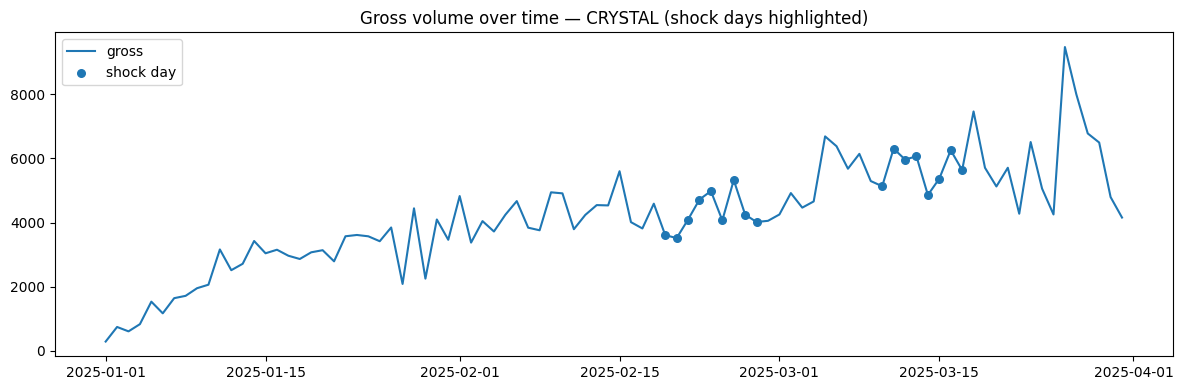

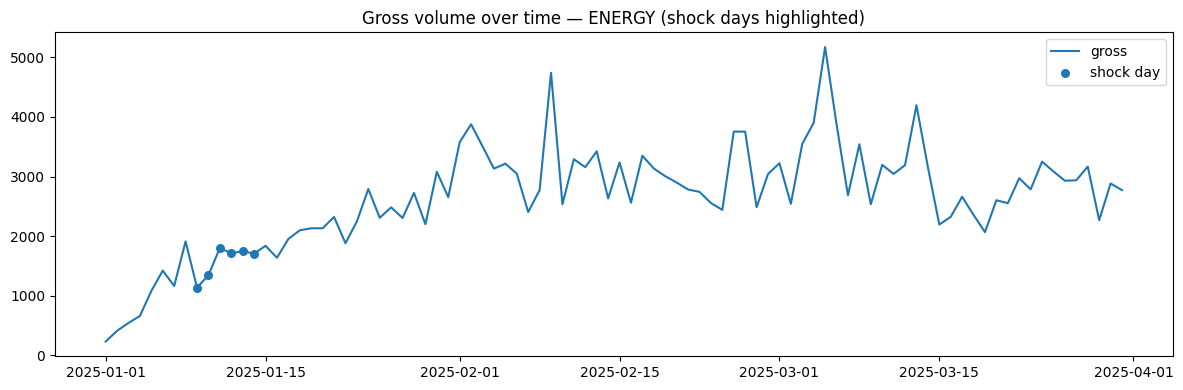

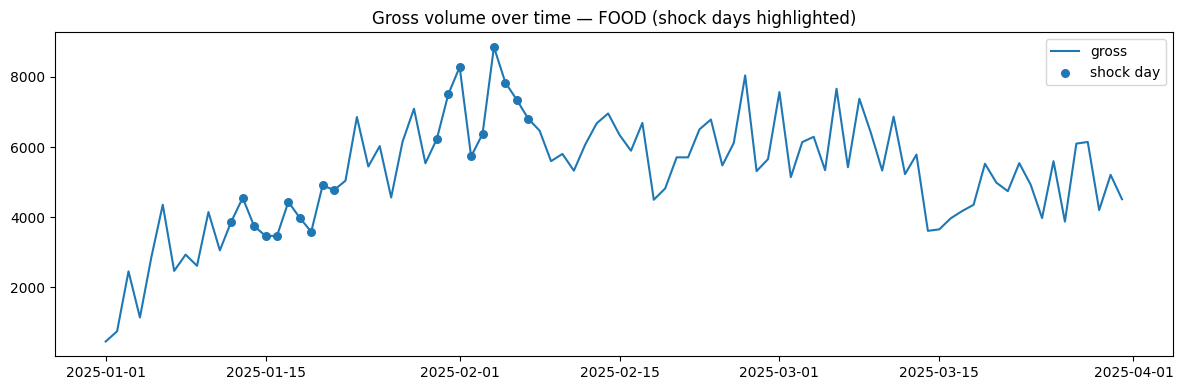

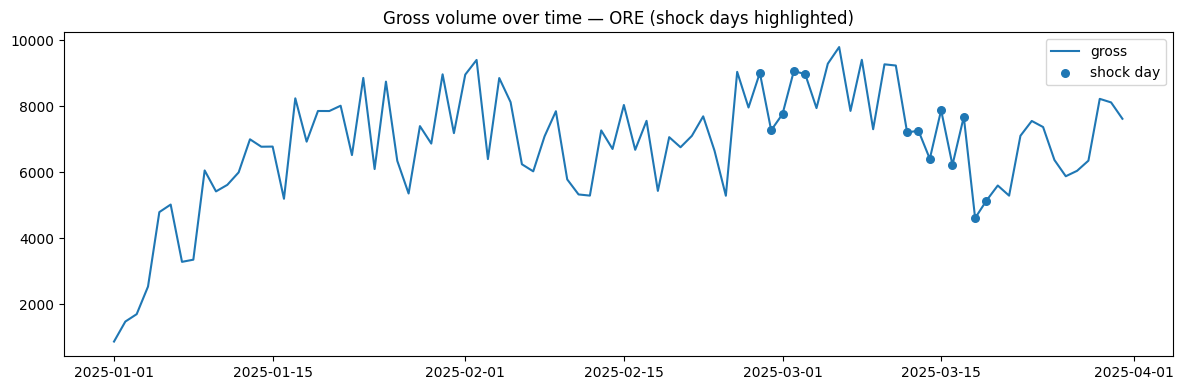

In [26]:
for res in sorted(panel["resource"].unique()):
    sub = panel[panel["resource"] == res].sort_values("day")
    if sub["shock"].sum() == 0:
        continue

    plt.figure(figsize=(12,4))
    plt.plot(sub["day"], sub["gross"], label="gross")
    # отметим шоки
    shock_days = sub[sub["shock"]==1]["day"]
    plt.scatter(shock_days, sub.loc[sub["shock"]==1, "gross"], s=30, label="shock day")
    plt.title(f"Gross volume over time — {res} (shock days highlighted)")
    plt.legend()
    plt.tight_layout()
    plt.show()


tx_type,day,market_fee,reward,stake,tax,unstake,emission,sinks,net_issuance,locked_delta,locked,supply_proxy,circulating_proxy
0,2025-01-01,-5.393267,38.476695,817.624117,-148.414214,-457.830590,38.476695,153.807481,-115.330786,359.793527,359.793527,-115.330786,0.000001
1,2025-01-02,-8.805476,132.513628,846.317590,-234.432193,-656.503741,132.513628,243.237669,-110.724041,189.813849,549.607376,-226.054827,0.000001
2,2025-01-03,-12.285367,273.884645,1145.260640,-323.736456,-505.729312,273.884645,336.021823,-62.137178,639.531328,1189.138704,-288.192005,0.000001
3,2025-01-04,-13.245822,491.932515,927.081438,-354.164376,-685.026210,491.932515,367.410198,124.522317,242.055228,1431.193932,-163.669688,0.000001
4,2025-01-05,-24.793365,829.062378,1101.702430,-656.825115,-485.656888,829.062378,681.618480,147.443898,616.045542,2047.239474,-16.225790,0.000001


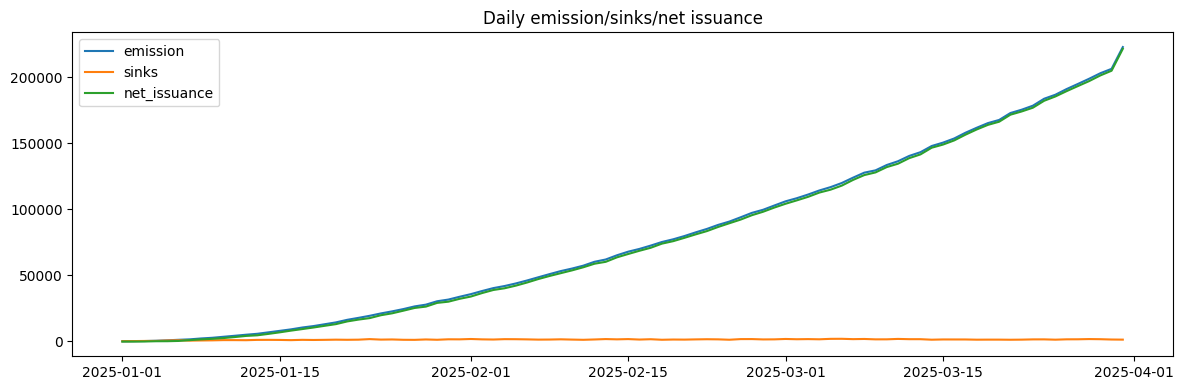

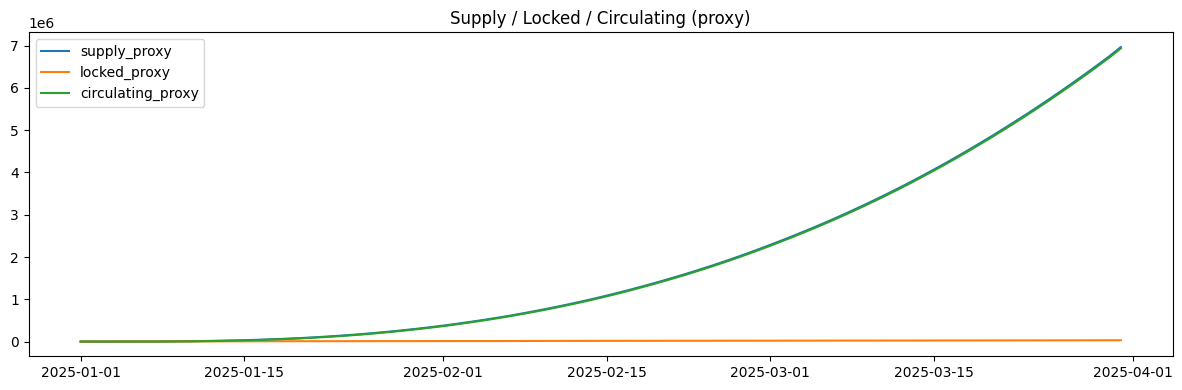

In [27]:
if token_ledger is None or market_trades is None:
    raise ValueError("Нужны token_ledger и market_trades")

tl = token_ledger.copy()
tl["ts"] = pd.to_datetime(tl["ts"], errors="coerce")
tl["day"] = tl["ts"].dt.floor("D")

# daily by tx_type
daily_type = tl.groupby(["day","tx_type"])["amount"].sum().reset_index()
pivot = daily_type.pivot_table(index="day", columns="tx_type", values="amount", aggfunc="sum", fill_value=0).reset_index()

for col in ["reward","tax","market_fee","stake","unstake"]:
    if col not in pivot.columns:
        pivot[col] = 0.0

pivot["emission"] = pivot["reward"]
pivot["sinks"] = -(pivot["tax"] + pivot["market_fee"]) 
pivot["net_issuance"] = pivot["emission"] - pivot["sinks"]

# locked proxy (stake положит, unstake снимет)
pivot["locked_delta"] = pivot["stake"] + pivot["unstake"] 
pivot["locked"] = pivot["locked_delta"].cumsum()

pivot["supply_proxy"] = pivot["net_issuance"].cumsum()
pivot["circulating_proxy"] = (pivot["supply_proxy"] - pivot["locked"]).clip(lower=1e-6)

display(pivot.head())

plt.figure(figsize=(12,4))
plt.plot(pivot["day"], pivot["emission"], label="emission")
plt.plot(pivot["day"], pivot["sinks"], label="sinks")
plt.plot(pivot["day"], pivot["net_issuance"], label="net_issuance")
plt.title("Daily emission/sinks/net issuance")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(pivot["day"], pivot["supply_proxy"], label="supply_proxy")
plt.plot(pivot["day"], pivot["locked"], label="locked_proxy")
plt.plot(pivot["day"], pivot["circulating_proxy"], label="circulating_proxy")
plt.title("Supply / Locked / Circulating (proxy)")
plt.legend()
plt.tight_layout()
plt.show()


,day,gross,trades,traders,avg_slip,circulating_proxy,emission,sinks,velocity
0,2025-01-01,2696.633602,58,30,97.277069,0.000001,38.476695,153.807481,2.696634e+09
1,2025-01-02,4402.736592,120,54,77.123500,0.000001,132.513628,243.237669,4.402737e+09
2,2025-01-03,6142.682880,177,78,171.051073,0.000001,273.884645,336.021823,6.142683e+09
3,2025-01-04,6622.910404,209,99,88.170957,0.000001,491.932515,367.410198,6.622910e+09
4,2025-01-05,12396.681906,290,134,116.386483,0.000001,829.062378,681.618480,1.239668e+10


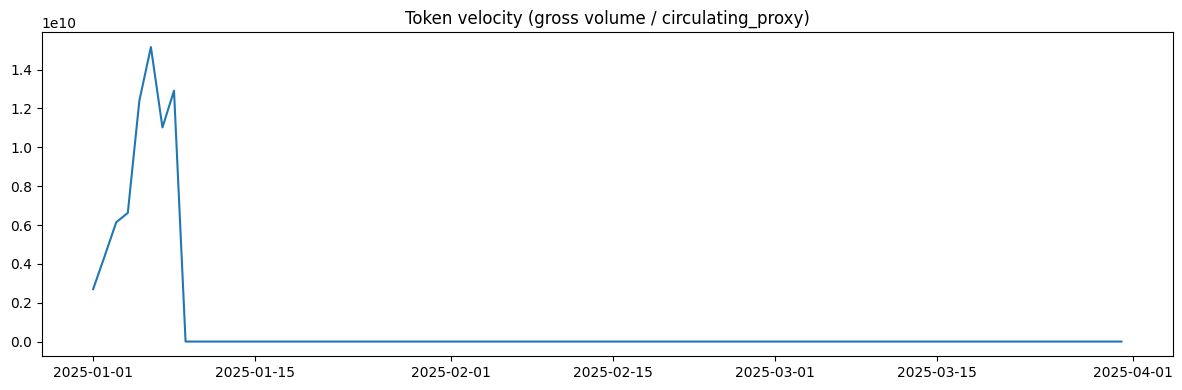

,day,gross,trades,traders,avg_slip,circulating_proxy,emission,sinks,velocity,sink_share_of_gross
0,2025-01-01,2696.633602,58,30,97.277069,1.000000e-06,38.476695,153.807481,2.696634e+09,0.057037
1,2025-01-02,4402.736592,120,54,77.123500,1.000000e-06,132.513628,243.237669,4.402737e+09,0.055247
2,2025-01-03,6142.682880,177,78,171.051073,1.000000e-06,273.884645,336.021823,6.142683e+09,0.054703
3,2025-01-04,6622.910404,209,99,88.170957,1.000000e-06,491.932515,367.410198,6.622910e+09,0.055476
4,2025-01-05,12396.681906,290,134,116.386483,1.000000e-06,829.062378,681.618480,1.239668e+10,0.054984
...,...,...,...,...,...,...,...,...,...,...
85,2025-03-27,29044.592733,748,352,213.232660,6.113885e+06,195048.628375,1599.939885,4.750595e-03,0.055086
86,2025-03-28,31767.412096,705,337,128.655475,6.310365e+06,198979.172408,1767.764960,5.034164e-03,0.055647
87,2025-03-29,29838.607854,718,336,156.904123,6.511452e+06,203180.664670,1664.331458,4.582481e-03,0.055778
88,2025-03-30,25630.500959,746,349,111.404343,6.716014e+06,206510.011794,1425.596889,3.816326e-03,0.055621


In [28]:
mt = market_trades.copy()
mt["ts"] = pd.to_datetime(mt["ts"], errors="coerce")
mt["day"] = mt["ts"].dt.floor("D")
mt["gross_token"] = mt["amount_base"] * mt["price"]

trade_day = mt.groupby("day").agg(
    gross=("gross_token","sum"),
    trades=("trade_id","count"),
    traders=("maker_user_id","nunique"),
    avg_slip=("slippage_bps","mean")
).reset_index()

econ = trade_day.merge(pivot[["day","circulating_proxy","emission","sinks"]], on="day", how="left")
econ["velocity"] = econ["gross"] / econ["circulating_proxy"]

display(econ.head())

plt.figure(figsize=(12,4))
plt.plot(econ["day"], econ["velocity"])
plt.title("Token velocity (gross volume / circulating_proxy)")
plt.tight_layout()
plt.show()

# shares
econ["sink_share_of_gross"] = econ["sinks"] / econ["gross"].replace(0, np.nan)
econ


> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

['                            OLS Regression Results                            ', '==============================================================================', 'Dep. Variable:              log_gross   R-squared:                       0.914', 'Model:                            OLS   Adj. R-squared:                  0.891', 'Method:                 Least Squares   F-statistic:                     91.54', 'Date:                Wed, 07 Jan 2026   Prob (F-statistic):          3.22e-202', 'Time:                        22:41:37   Log-Likelihood:                 157.11', 'No. Observations:                 450   AIC:                            -120.2', 'Df Residuals:                     353   BIC:                             278.4', 'Df Model:                          96                                         ', 'Covariance Type:                  HC1                                         ', '================================================================================================

,coef,pval
log_tax,-195.528420,3.995647e-02
log_vol,1.711257,7.497786e-07
shock,0.027129,3.843077e-01


C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\4216987780.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = tmp.groupby("tax_bin").agg(


,tax_bin,n,gross_mean,trades_mean,vol_mean
0,"(-0.000728, 0.000334]",75,5884.940708,166.613333,0.054562
1,"(0.000334, 0.000354]",75,5478.670164,154.746667,0.041595
2,"(0.000354, 0.000375]",75,5670.065842,146.040000,0.048623
3,"(0.000375, 0.0004]",75,5454.640414,137.946667,0.043152
4,"(0.0004, 0.000505]",75,4643.397887,123.573333,0.040355
5,"(0.000505, 0.00646]",75,2621.606178,67.960000,0.031194


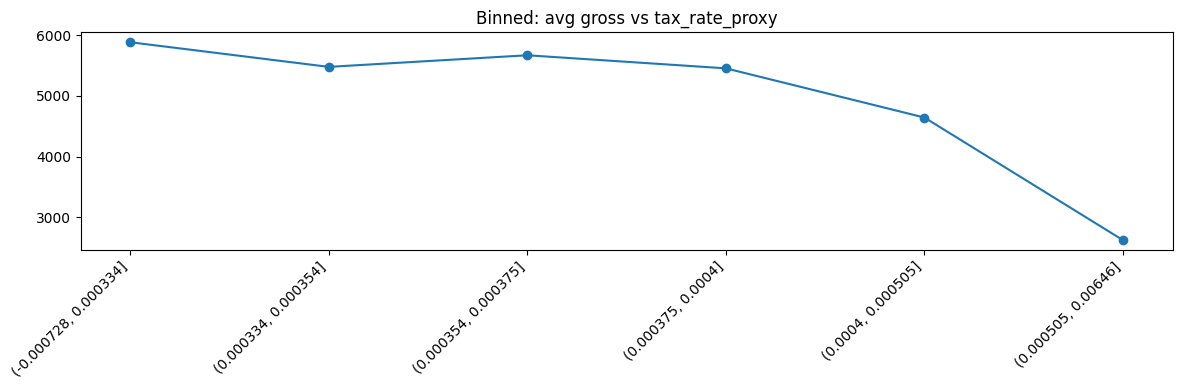

In [29]:
panel2 = panel.copy()

panel2["tax_rate_proxy"] = panel2["avg_tax"] / panel2["gross"].replace(0, np.nan)
panel2["log_tax"] = np.log1p(panel2["tax_rate_proxy"].fillna(0))
panel2["log_vol"] = np.log1p(panel2["volatility"].fillna(0))

try:
    import statsmodels.formula.api as smf

    # elasticity 
    m = smf.ols("log_gross ~ log_tax + log_vol + shock + C(day) + C(resource)", data=panel2).fit(cov_type="HC1")
    print(m.summary().as_text().splitlines()[0:30])
    print("\nKey coefficients:")
    display(pd.DataFrame({"coef": m.params, "pval": m.pvalues}).loc[["log_tax","log_vol","shock"]])

except Exception as e:
    print("statsmodels not available; fallback to correlation plots only. Error:", repr(e))

# binned plot: tax_rate_proxy vs gross
tmp = panel2.copy()
tmp = tmp.replace([np.inf,-np.inf], np.nan).dropna(subset=["tax_rate_proxy","gross"])
tmp["tax_bin"] = pd.qcut(tmp["tax_rate_proxy"], q=min(6, tmp["tax_rate_proxy"].nunique()), duplicates="drop")
b = tmp.groupby("tax_bin").agg(
    n=("gross","count"),
    gross_mean=("gross","mean"),
    trades_mean=("trades","mean"),
    vol_mean=("volatility","mean")
).reset_index()

display(b)

plt.figure(figsize=(12,4))
plt.plot(range(len(b)), b["gross_mean"], marker="o")
plt.xticks(range(len(b)), b["tax_bin"].astype(str), rotation=45, ha="right")
plt.title("Binned: avg gross vs tax_rate_proxy")
plt.tight_layout()
plt.show()


## 9) Level D — Live Ops

### D1) Economic Monitoring and Alerts
- Alerts for sharp net issuance spikes, velocity drops, or concentration growth.

### D2) Policy Simulation
- Simulating the impact of taxes/fees on activity.

### D3) Fraud / Abuse / Bot Detection
- Wash trading, multi-accounting, and economic exploits.

[    0.0s] Parsing datetimes...
[    0.1s] Preparing trade economics columns...
[    0.1s] market_trades rows=59,766, date range: 2025-01-01 00:00:00 .. 2025-03-31 00:00:00
[    0.1s] Computing daily market aggregates...
[    0.2s] Computing daily token ledger aggregates (emission/sinks/issuance/locked)...
[    0.3s] econ_daily ready.


,day,trades,traders,gross,tax_sum,fee_sum,tax_rate_mean,fee_rate_mean,slippage_mean,spread_mean,emission,sinks,net_issuance,locked_proxy,supply_proxy,circulating_proxy,velocity,tax_share_of_gross,fee_share_of_gross,sinks_share_of_gross,emission_share_of_gross
0,2025-01-01,58,30,2696.633602,148.414214,5.393267,0.052586,0.002,97.277069,71.676724,38.476695,153.807481,-115.330786,359.793527,-115.330786,0.000001,2.696634e+09,0.055037,0.002,0.057037,0.014268
1,2025-01-02,120,54,4402.736592,234.432193,8.805476,0.051083,0.002,77.123500,56.938750,132.513628,243.237669,-110.724041,549.607376,-226.054827,0.000001,4.402737e+09,0.053247,0.002,0.055247,0.030098
2,2025-01-03,177,78,6142.682880,323.736456,12.285367,0.050565,0.002,171.051073,107.275424,273.884645,336.021823,-62.137178,1189.138704,-288.192005,0.000001,6.142683e+09,0.052703,0.002,0.054703,0.044587
3,2025-01-04,209,99,6622.910404,354.164376,13.245822,0.050813,0.002,88.170957,74.084928,491.932515,367.410198,124.522317,1431.193932,-163.669688,0.000001,6.622910e+09,0.053476,0.002,0.055476,0.074277
4,2025-01-05,290,134,12396.681906,656.825115,24.793365,0.050655,0.002,116.386483,83.890862,829.062378,681.618480,147.443898,2047.239474,-16.225790,0.000001,1.239668e+10,0.052984,0.002,0.054984,0.066878


[    0.3s] Plotting core economics time series...


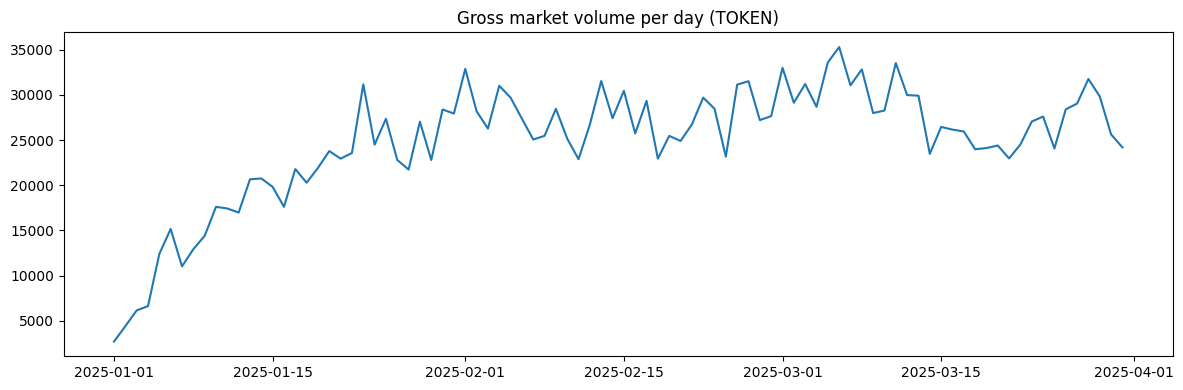

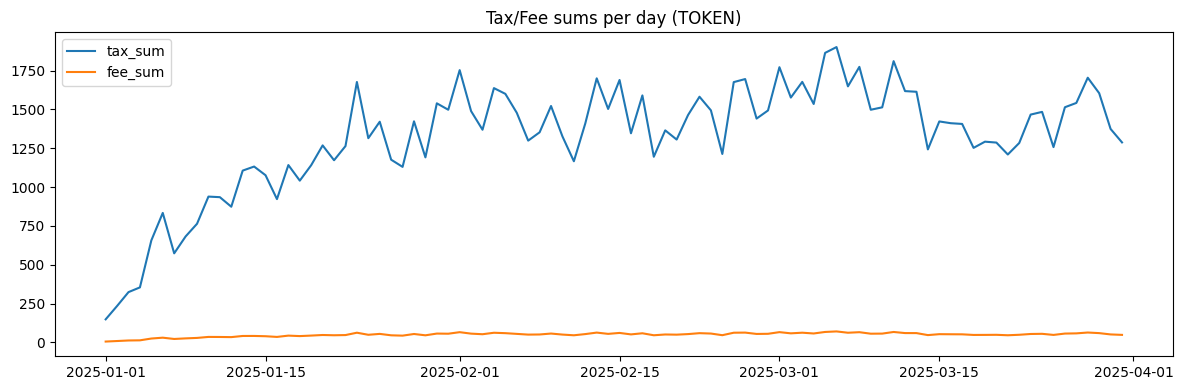

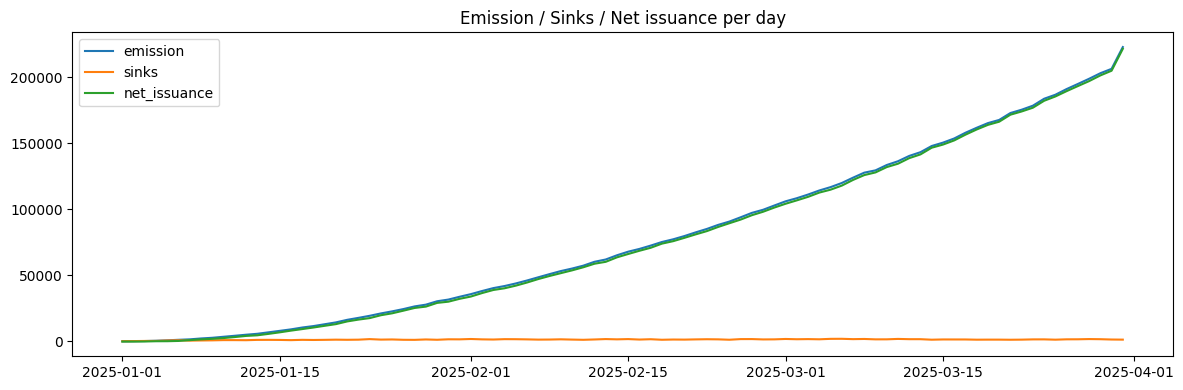

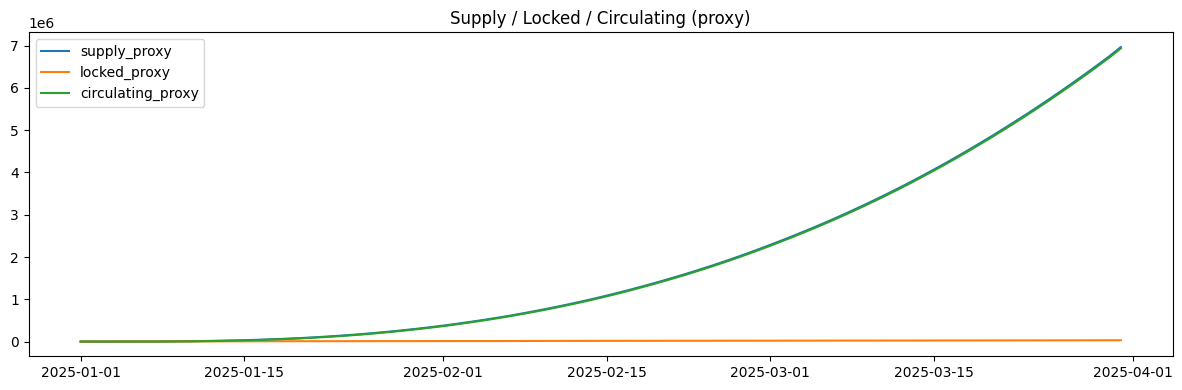

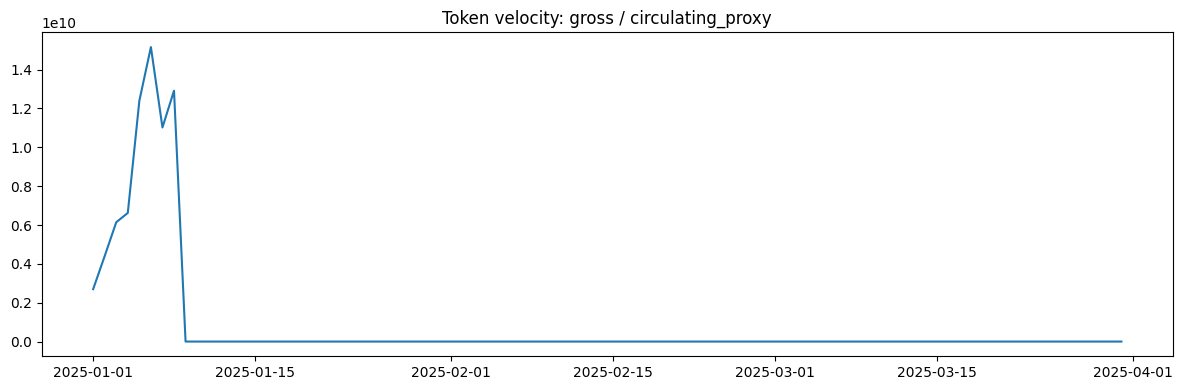

[    2.4s] Tax analysis: distributions & laffer-ish...


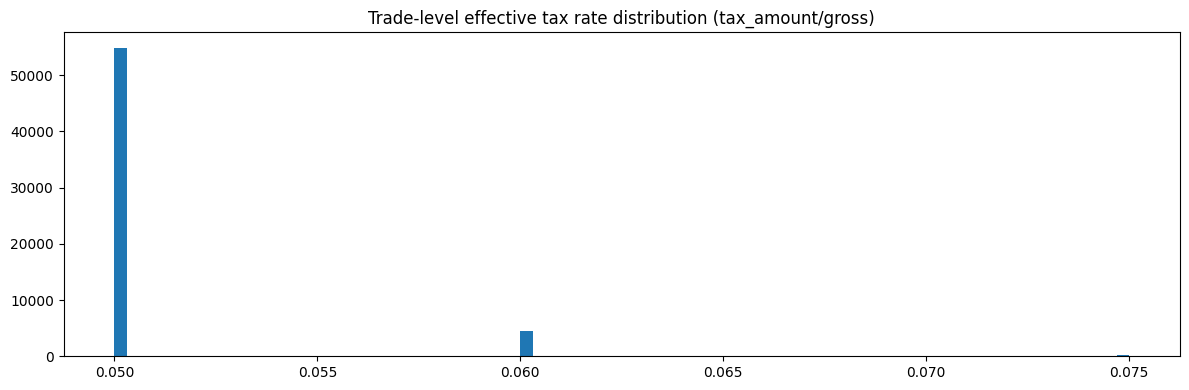

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\3439248669.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_daily = tmp.groupby("tax_rate_bin").agg(


,tax_rate_bin,n_days,gross_mean,tax_sum_mean,tax_rate_mean
0,"(0.0493, 0.0506]",12,20264.066492,1048.766256,0.050466
1,"(0.0506, 0.0507]",11,22476.026402,1177.018903,0.050622
2,"(0.0507, 0.0508]",11,25249.548397,1333.768719,0.050701
3,"(0.0508, 0.0509]",11,23873.243009,1270.456300,0.050817
4,"(0.0509, 0.051]",11,27247.422495,1460.309185,0.050940
5,"(0.051, 0.0511]",11,28557.476763,1533.505794,0.051028
6,"(0.0511, 0.0512]",11,24984.715485,1350.904029,0.051162
7,"(0.0512, 0.0526]",12,26004.794463,1416.053903,0.051457


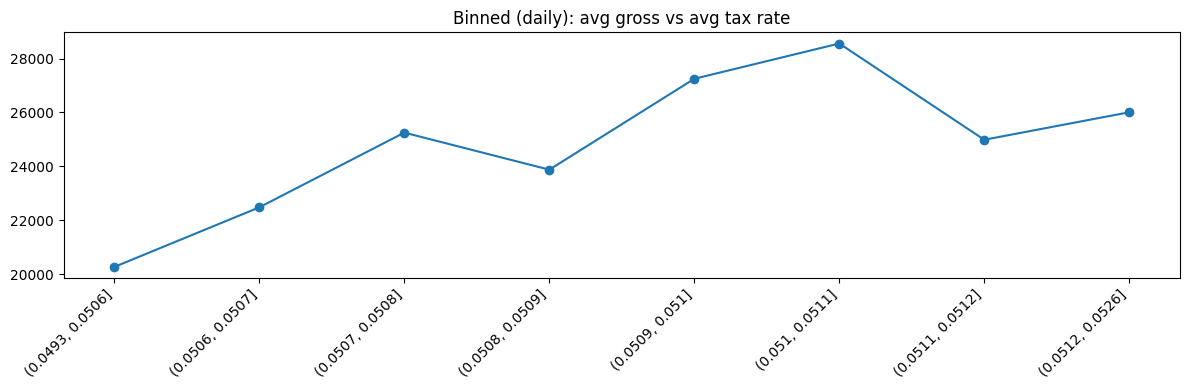

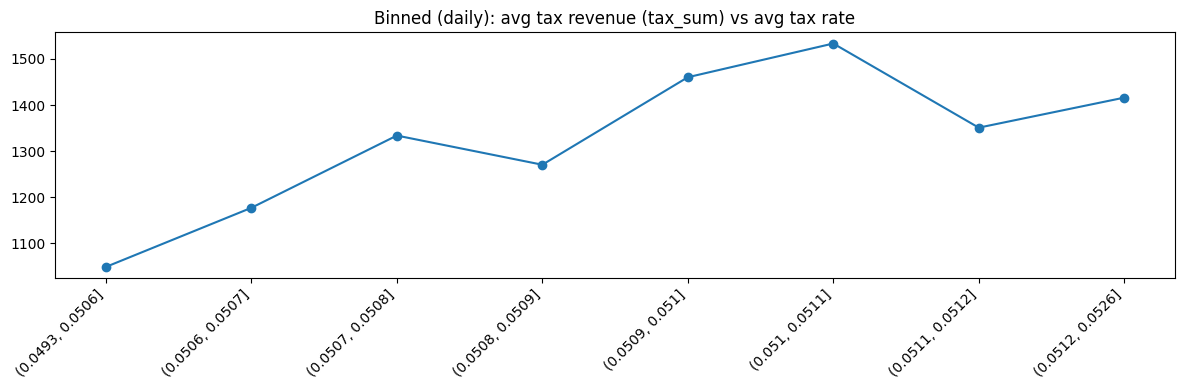

[    3.4s] Volatility ↔ microstructure...


C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\3439248669.py:251: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vw = m2.groupby("day").apply(


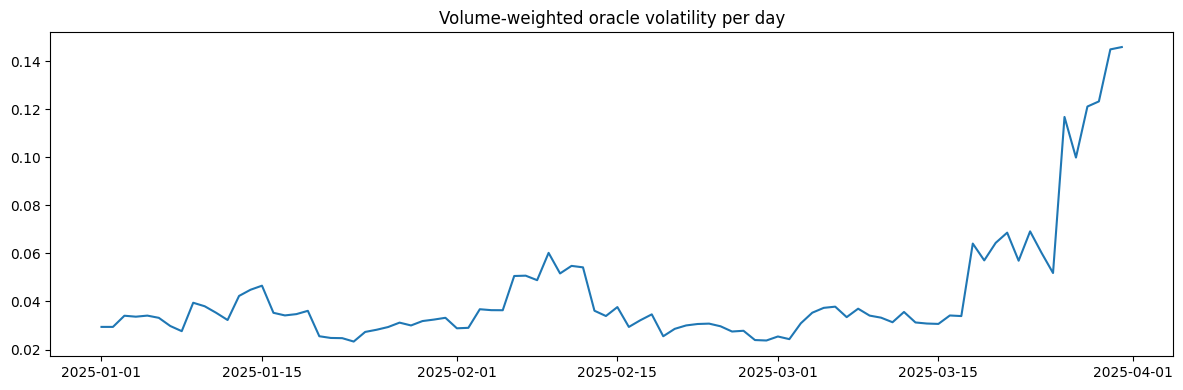

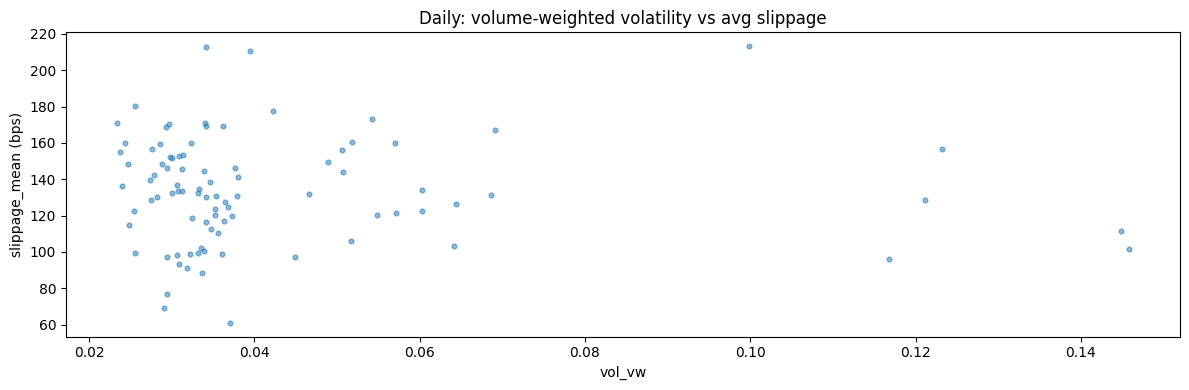

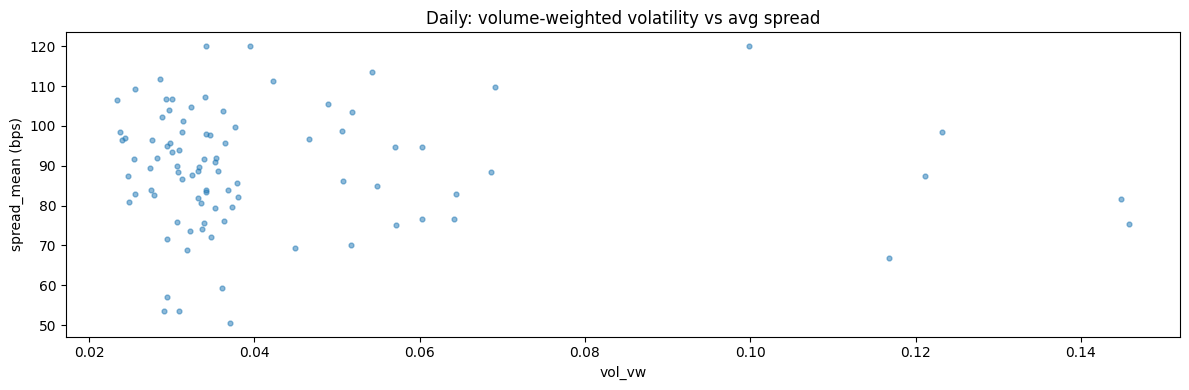

[    4.5s] Building day×resource panel and running FE regressions...


,day,resource,trades,traders,gross,tax_sum,fee_sum,tax_rate_mean,slippage_mean,spread_mean,volatility,price_token,shock,log_gross,log_trades,log_traders,tax_rate_proxy,log_tax,log_vol
0,2025-01-01,CRYSTAL,10,8,283.402731,18.318385,0.566805,0.055000,26.329000,20.25,0.029424,1.9729,0,5.650391,2.397895,2.197225,0.064637,0.062634,0.028999
1,2025-01-01,ENERGY,13,12,232.475982,11.623798,0.464952,0.050000,100.780000,80.55,0.029424,1.3465,0,5.453079,2.639057,2.564949,0.050000,0.048790,0.028999
2,2025-01-01,FOOD,12,11,448.836107,24.125955,0.897672,0.052083,111.888333,95.55,0.029424,3.0646,0,6.108883,2.564949,2.484907,0.053752,0.052357,0.028999
3,2025-01-01,ORE,9,8,862.086332,43.104316,1.724172,0.050000,10.838889,9.00,0.029424,4.7313,0,6.760515,2.302585,2.197225,0.050000,0.048790,0.028999
4,2025-01-01,WATER,14,11,869.832450,51.241760,1.739666,0.055357,187.745000,120.00,0.029424,3.2386,0,6.769450,2.708050,2.484907,0.058910,0.057240,0.028999


[    5.2s] FE OLS: log_gross ~ log_tax + log_vol + shock + dayFE + resourceFE


,coef,pval
log_tax,56.561456,3.029113e-03
log_vol,1.841268,3.633295e-09
shock,0.028141,3.543102e-01


[    5.3s] FE OLS: log_trades ~ log_tax + log_vol + shock + dayFE + resourceFE


...

[    7.0s] Two-way FE (demeaned) + cluster SE by user — key results:


,coef,pval
const,5.146618e-18,1.000000
log_tax,-3.736206e+00,0.550830
log_vol,-5.040445e+01,0.988768
shock_day,-7.725710e+00,0.989847
log_fee,-4.529150e+05,0.477469


[    7.1s] Diff-in-Diff for tax experiment EXP_TAX_DYNAMIC (if available)...
[    7.1s] Experiment window: 2025-01-23 .. 2025-03-08


,treat,post,gross_mean,log_gross_mean,n
0,0,0,85.041534,3.799432,618
1,0,1,93.318311,3.809344,3301
2,1,0,62.586770,3.758355,621
3,1,1,69.923593,3.728587,3198


[    7.1s] DiD (log_gross): -0.0397  (approx % change ~ -3.89%)


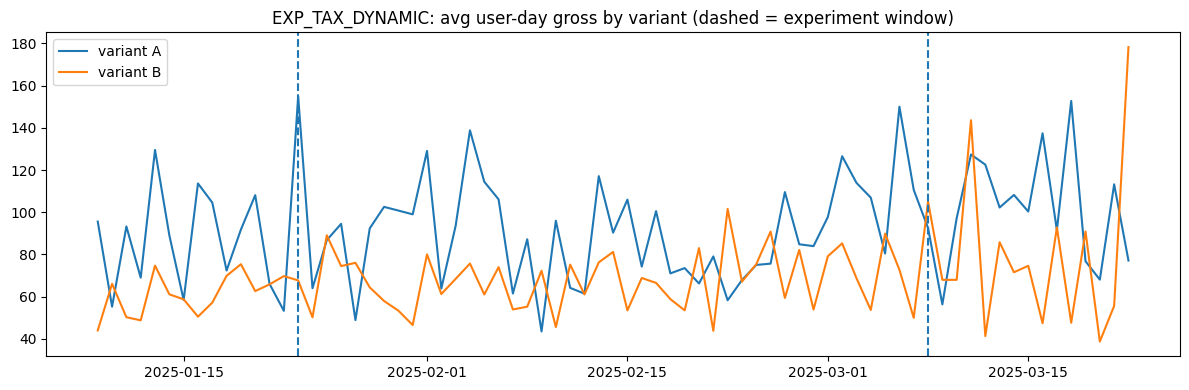

[    7.8s] DiD regression key term (post:treat):


,coef,pval
post,-9.457755e+11,0.372039
treat,-4.240154e-02,0.449229
post:treat,-3.909827e-02,0.524548


[    7.8s] Concentration metrics (top shares & Gini)...
gross: top1% share=0.293, top5% share=0.443, gini=0.644
tax: top1% share=0.329, top5% share=0.477, gini=0.665
fee: top1% share=0.293, top5% share=0.443, gini=0.644


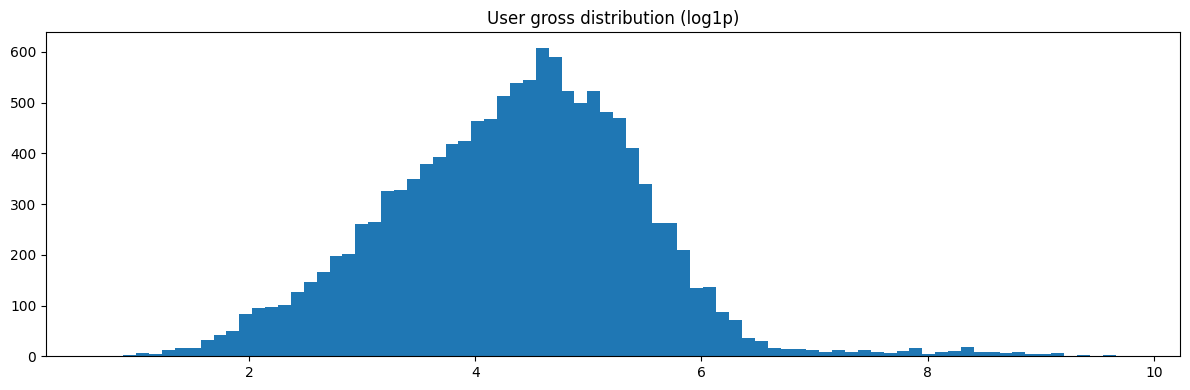

[    8.3s] Elasticity-style summary: log(volume) vs log_tax/log_vol...


,log_gross,log_tax,log_vol,shock
log_gross,1.000000,0.263584,-0.029136,0.066773
log_tax,0.263584,1.000000,-0.029201,0.018776
log_vol,-0.029136,-0.029201,1.000000,-0.083747
shock,0.066773,0.018776,-0.083747,1.000000


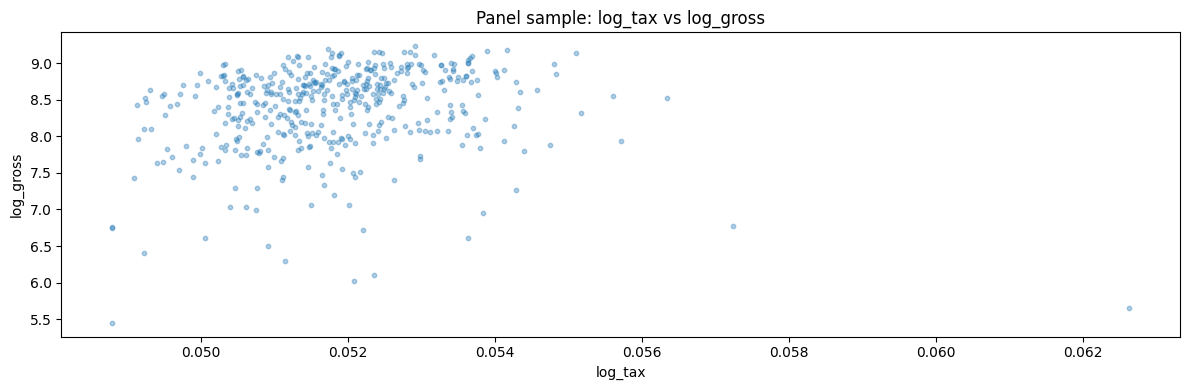

[    8.6s] ECONOMICS / TAX / ECONOMETRICS block DONE
[    8.6s] Artifacts created: econ_daily, panel (day×resource), ud (user×day), user_agg


In [30]:
DATA_DIR = "synthetic_defi_game_data"  
FIGSIZE = (12, 4)
RANDOM_SEED = 42

USER_DAY_FE_SAMPLE_USERS = None  
USER_DAY_MIN_TRADING_DAYS = 1     

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)

t0 = time.time()
def log(msg):
    print(f"[{time.time()-t0:7.1f}s] {msg}")

def read_csv_if_needed(name, data_dir=DATA_DIR):
    path = os.path.join(data_dir, f"{name}.csv")
    if os.path.exists(path):
        return pd.read_csv(path, low_memory=False)
    return None

def ensure_df(var_name, file_name):
    if var_name in globals() and globals()[var_name] is not None:
        return globals()[var_name]
    return read_csv_if_needed(file_name)

users          = ensure_df("users", "users")
sessions       = ensure_df("sessions", "sessions")
market_trades  = ensure_df("market_trades", "market_trades")
token_ledger   = ensure_df("token_ledger", "token_ledger")
price_oracle   = ensure_df("price_oracle", "price_oracle_daily")
econ_events    = ensure_df("econ_events", "economic_events")
experiments    = ensure_df("experiments", "experiments")
exp_assign     = ensure_df("exp_assign", "experiment_assignments")

needed = {
    "users": users, "market_trades": market_trades, "token_ledger": token_ledger,
    "price_oracle_daily": price_oracle, "economic_events": econ_events
}
missing = [k for k,v in needed.items() if v is None]
if missing:
    raise ValueError(f"Не найдены таблицы: {missing}. Проверь DATA_DIR или переменные в памяти.")

# coerce datetime columns (minimal)
def to_dt(s):
    return pd.to_datetime(s, errors="coerce", utc=False)

log("Parsing datetimes...")

users["created_at"] = to_dt(users["created_at"])

# market trades
mt = market_trades.copy()
for c in ["ts"]:
    if c in mt.columns: mt[c] = to_dt(mt[c])
mt["day"] = mt["ts"].dt.floor("D")

# resource column name
if "resource" in mt.columns:
    RES_COL = "resource"
elif "asset_base" in mt.columns:
    RES_COL = "asset_base"
else:
    raise ValueError("Не нашёл колонку ресурса в market_trades (ожидал 'resource' или 'asset_base').")

# token ledger
tl = token_ledger.copy()
tl["ts"] = to_dt(tl["ts"])
tl["day"] = tl["ts"].dt.floor("D")

# price oracle
po = price_oracle.copy()
po["day"] = to_dt(po["day"]).dt.floor("D")
if "resource" not in po.columns:
    raise ValueError("В price_oracle_daily ожидается колонка 'resource'.")

# econ events
ev = econ_events.copy()
ev["start_ts"] = to_dt(ev["start_ts"])
ev["end_ts"]   = to_dt(ev["end_ts"])
ev["start_day"] = ev["start_ts"].dt.floor("D")
ev["end_day"]   = ev["end_ts"].dt.floor("D")

# ============================================================
# 1) ECON BASICS: trades gross, effective tax/fee rates, microstructure
# ============================================================
log("Preparing trade economics columns...")

# gross in TOKEN
mt["gross_token"] = mt["amount_base"] * mt["price"]

# effective rates (avoid div0)
mt["tax_rate_eff"] = (mt["tax_amount"] / mt["gross_token"].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
mt["fee_rate_eff"] = (mt["fee_amount"] / mt["gross_token"].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

# quick sanity
log(f"market_trades rows={len(mt):,}, date range: {mt['day'].min()} .. {mt['day'].max()}")

# ------------------------------------------------------------
# Daily market aggregates (overall)
# ------------------------------------------------------------
log("Computing daily market aggregates...")

daily_market = mt.groupby("day").agg(
    trades=("trade_id", "count"),
    traders=("maker_user_id", "nunique"),
    gross=("gross_token", "sum"),
    tax_sum=("tax_amount", "sum"),
    fee_sum=("fee_amount", "sum"),
    tax_rate_mean=("tax_rate_eff", "mean"),
    fee_rate_mean=("fee_rate_eff", "mean"),
    slippage_mean=("slippage_bps", "mean"),
    spread_mean=("spread_bps", "mean"),
).reset_index()

# ------------------------------------------------------------
# Daily ledger aggregates: emission, sinks, net issuance, locked, supply proxy
# ------------------------------------------------------------
log("Computing daily token ledger aggregates (emission/sinks/issuance/locked)...")

# Ensure tx_type exists
if "tx_type" not in tl.columns:
    raise ValueError("В token_ledger ожидается колонка 'tx_type'.")

daily_type = tl.groupby(["day", "tx_type"])["amount"].sum().reset_index()
ledger_piv = daily_type.pivot_table(index="day", columns="tx_type", values="amount", aggfunc="sum", fill_value=0).reset_index()
ledger_piv.columns = [str(c) for c in ledger_piv.columns]

for col in ["reward", "tax", "market_fee", "stake", "unstake"]:
    if col not in ledger_piv.columns:
        ledger_piv[col] = 0.0

# sources/sinks
ledger_piv["emission"] = ledger_piv["reward"]                       # + to user
ledger_piv["sinks"] = -(ledger_piv["tax"] + ledger_piv["market_fee"])# tax/fee are negative amounts → sinks positive
ledger_piv["net_issuance"] = ledger_piv["emission"] - ledger_piv["sinks"]

# locked proxy (stake adds, unstake removes; in generator unstake is negative amount)
ledger_piv["locked_delta"] = ledger_piv["stake"] + ledger_piv["unstake"]
ledger_piv["locked_proxy"] = ledger_piv["locked_delta"].cumsum()

# supply proxy = cumulative net issuance
ledger_piv["supply_proxy"] = ledger_piv["net_issuance"].cumsum()

# circulating proxy
ledger_piv["circulating_proxy"] = (ledger_piv["supply_proxy"] - ledger_piv["locked_proxy"]).clip(lower=1e-6)

# ------------------------------------------------------------
# Merge daily market + ledger
# ------------------------------------------------------------
econ_daily = daily_market.merge(ledger_piv[[
    "day", "emission", "sinks", "net_issuance", "locked_proxy", "supply_proxy", "circulating_proxy"
]], on="day", how="left")

# velocity
econ_daily["velocity"] = econ_daily["gross"] / econ_daily["circulating_proxy"]

# shares
econ_daily["tax_share_of_gross"] = econ_daily["tax_sum"] / econ_daily["gross"].replace(0, np.nan)
econ_daily["fee_share_of_gross"] = econ_daily["fee_sum"] / econ_daily["gross"].replace(0, np.nan)
econ_daily["sinks_share_of_gross"] = econ_daily["sinks"] / econ_daily["gross"].replace(0, np.nan)
econ_daily["emission_share_of_gross"] = econ_daily["emission"] / econ_daily["gross"].replace(0, np.nan)

log("econ_daily ready.")
display(econ_daily.head())

# ============================================================
# 2) VISUAL: core economics time series
# ============================================================
log("Plotting core economics time series...")

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["gross"])
plt.title("Gross market volume per day (TOKEN)")
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["tax_sum"], label="tax_sum")
plt.plot(econ_daily["day"], econ_daily["fee_sum"], label="fee_sum")
plt.title("Tax/Fee sums per day (TOKEN)")
plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["emission"], label="emission")
plt.plot(econ_daily["day"], econ_daily["sinks"], label="sinks")
plt.plot(econ_daily["day"], econ_daily["net_issuance"], label="net_issuance")
plt.title("Emission / Sinks / Net issuance per day")
plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["supply_proxy"], label="supply_proxy")
plt.plot(econ_daily["day"], econ_daily["locked_proxy"], label="locked_proxy")
plt.plot(econ_daily["day"], econ_daily["circulating_proxy"], label="circulating_proxy")
plt.title("Supply / Locked / Circulating (proxy)")
plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["velocity"])
plt.title("Token velocity: gross / circulating_proxy")
plt.tight_layout(); plt.show()

# ============================================================
# 3) TAX ANALYSIS: effective tax rate distribution & "laffer-ish" views
# ============================================================
log("Tax analysis: distributions & laffer-ish...")

# trade-level effective tax rate
tax_eff = mt["tax_rate_eff"].dropna()
plt.figure(figsize=FIGSIZE)
plt.hist(tax_eff, bins=80)
plt.title("Trade-level effective tax rate distribution (tax_amount/gross)")
plt.tight_layout(); plt.show()

# daily average tax rate vs gross (binned)
tmp = econ_daily[["day", "gross", "tax_rate_mean", "tax_sum"]].copy().dropna()
tmp = tmp[tmp["gross"] > 0]
tmp["tax_rate_bin"] = pd.qcut(tmp["tax_rate_mean"], q=min(8, tmp["tax_rate_mean"].nunique()), duplicates="drop")
bin_daily = tmp.groupby("tax_rate_bin").agg(
    n_days=("day","count"),
    gross_mean=("gross","mean"),
    tax_sum_mean=("tax_sum","mean"),
    tax_rate_mean=("tax_rate_mean","mean")
).reset_index()
display(bin_daily)

plt.figure(figsize=(12,4))
plt.plot(range(len(bin_daily)), bin_daily["gross_mean"], marker="o")
plt.xticks(range(len(bin_daily)), bin_daily["tax_rate_bin"].astype(str), rotation=45, ha="right")
plt.title("Binned (daily): avg gross vs avg tax rate")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(range(len(bin_daily)), bin_daily["tax_sum_mean"], marker="o")
plt.xticks(range(len(bin_daily)), bin_daily["tax_rate_bin"].astype(str), rotation=45, ha="right")
plt.title("Binned (daily): avg tax revenue (tax_sum) vs avg tax rate")
plt.tight_layout(); plt.show()

# ============================================================
# 4) PRICE ORACLE: volatility & link to slippage/spread
# ============================================================
log("Volatility ↔ microstructure...")

# daily aggregate volatility (volume-weighted)
# join mt to po for vol per trade
m2 = mt.merge(po[["day","resource","volatility","price_token"]], left_on=["day", RES_COL], right_on=["day","resource"], how="left")
m2["volatility"] = m2["volatility"].fillna(m2["volatility"].median())

# volume-weighted daily vol
vw = m2.groupby("day").apply(
    lambda g: np.average(g["volatility"], weights=np.clip(g["gross_token"].to_numpy(), 1e-6, None))
).reset_index(name="vol_vw")

econ_daily = econ_daily.merge(vw, on="day", how="left")

plt.figure(figsize=FIGSIZE)
plt.plot(econ_daily["day"], econ_daily["vol_vw"])
plt.title("Volume-weighted oracle volatility per day")
plt.tight_layout(); plt.show()

# scatter: daily vol vs daily slippage_mean
tmp2 = econ_daily.dropna(subset=["vol_vw","slippage_mean","spread_mean","gross"])
plt.figure(figsize=FIGSIZE)
plt.scatter(tmp2["vol_vw"], tmp2["slippage_mean"], s=12, alpha=0.5)
plt.title("Daily: volume-weighted volatility vs avg slippage")
plt.xlabel("vol_vw"); plt.ylabel("slippage_mean (bps)")
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.scatter(tmp2["vol_vw"], tmp2["spread_mean"], s=12, alpha=0.5)
plt.title("Daily: volume-weighted volatility vs avg spread")
plt.xlabel("vol_vw"); plt.ylabel("spread_mean (bps)")
plt.tight_layout(); plt.show()

# ============================================================
# 5) DAY×RESOURCE PANEL: shock indicator + FE regressions (day/resource FE)
# ============================================================
log("Building day×resource panel and running FE regressions...")

# day-resource market
dr = mt.groupby(["day", RES_COL]).agg(
    trades=("trade_id","count"),
    traders=("maker_user_id","nunique"),
    gross=("gross_token","sum"),
    tax_sum=("tax_amount","sum"),
    fee_sum=("fee_amount","sum"),
    tax_rate_mean=("tax_rate_eff","mean"),
    slippage_mean=("slippage_bps","mean"),
    spread_mean=("spread_bps","mean"),
).reset_index().rename(columns={RES_COL: "resource"})

panel = dr.merge(po[["day","resource","volatility","price_token"]], on=["day","resource"], how="left")

# shock indicator
def shock_flag(day, resource):
    sub = ev[ev["affected_resource"] == resource]
    if sub.empty:
        return 0
    return int(((sub["start_day"] <= day) & (sub["end_day"] >= day)).any())

panel["shock"] = panel.apply(lambda r: shock_flag(r["day"], r["resource"]), axis=1)

# transforms
panel["log_gross"]  = np.log1p(panel["gross"])
panel["log_trades"] = np.log1p(panel["trades"])
panel["log_traders"]= np.log1p(panel["traders"])

# tax proxy on panel
panel["tax_rate_proxy"] = (panel["tax_sum"] / panel["gross"].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0.0)
panel["log_tax"] = np.log1p(panel["tax_rate_proxy"])
panel["log_vol"] = np.log1p(panel["volatility"].fillna(panel["volatility"].median()))

display(panel.head())

# FE regression (OLS with C(day)+C(resource))
try:
    import statsmodels.formula.api as smf

    for ycol in ["log_gross", "log_trades", "log_traders"]:
        log(f"FE OLS: {ycol} ~ log_tax + log_vol + shock + dayFE + resourceFE")
        m = smf.ols(f"{ycol} ~ log_tax + log_vol + shock + C(day) + C(resource)", data=panel).fit(cov_type="HC1")
        # show key coefficients only
        out = pd.DataFrame({"coef": m.params, "pval": m.pvalues})
        display(out.loc[["log_tax","log_vol","shock"]])
except Exception as e:
    log(f"statsmodels not available or regression failed: {repr(e)}")

# quick binned view: volatility bins vs gross
tmpb = panel.dropna(subset=["volatility","gross"]).copy()
if tmpb["volatility"].nunique() > 5:
    tmpb["vol_bin"] = pd.qcut(tmpb["volatility"], q=6, duplicates="drop")
    bvol = tmpb.groupby("vol_bin").agg(
        n=("gross","count"),
        gross_mean=("gross","mean"),
        tax_rate_mean=("tax_rate_proxy","mean"),
        slippage_mean=("slippage_mean","mean")
    ).reset_index()
    display(bvol)

# ============================================================
# 6) USER×DAY PANEL: two-way FE (user + day) via demeaning
# ============================================================
log("Building user×day panel for 2-way FE (user+day) economics...")

# user-day from trades
ud = mt.groupby(["maker_user_id","day"]).agg(
    gross=("gross_token","sum"),
    trades=("trade_id","count"),
    tax_sum=("tax_amount","sum"),
    fee_sum=("fee_amount","sum"),
    slippage_mean=("slippage_bps","mean"),
    spread_mean=("spread_bps","mean"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

ud["tax_rate_proxy"] = (ud["tax_sum"] / ud["gross"].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0.0)
ud["fee_rate_proxy"] = (ud["fee_sum"] / ud["gross"].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan).fillna(0.0)

# add daily market condition (vol_vw, shocks count)
ud = ud.merge(econ_daily[["day","vol_vw"]], on="day", how="left")

# optional: shock intensity per day (any shock across resources that day)
shock_day = panel.groupby("day")["shock"].max().reset_index(name="shock_day")
ud = ud.merge(shock_day, on="day", how="left")
ud["shock_day"] = ud["shock_day"].fillna(0).astype(int)

# add user covariates (segment, whale)
u_cov = users[["user_id","acq_channel","player_segment","whale_flag","initial_deposit_usd"]].copy()
ud = ud.merge(u_cov, on="user_id", how="left")

# filter users with some activity
ud_users_days = ud.groupby("user_id")["day"].nunique().reset_index(name="trading_days")
ud = ud.merge(ud_users_days, on="user_id", how="left")
ud = ud[ud["trading_days"] >= USER_DAY_MIN_TRADING_DAYS].copy()

# optional sample users
if USER_DAY_FE_SAMPLE_USERS is not None:
    rng = np.random.default_rng(RANDOM_SEED)
    sampled = rng.choice(ud["user_id"].unique(), size=min(USER_DAY_FE_SAMPLE_USERS, ud["user_id"].nunique()), replace=False)
    ud = ud[ud["user_id"].isin(sampled)].copy()

log(f"user-day panel rows={len(ud):,}, users={ud['user_id'].nunique():,}, days={ud['day'].nunique():,}")

# transforms
ud["log_gross"] = np.log1p(ud["gross"])
ud["log_trades"]= np.log1p(ud["trades"])
ud["log_tax"]   = np.log1p(ud["tax_rate_proxy"])
ud["log_fee"]   = np.log1p(ud["fee_rate_proxy"])
ud["log_vol"]   = np.log1p(ud["vol_vw"].fillna(ud["vol_vw"].median()))

# two-way demeaning (user + day)
def two_way_demean(df: pd.DataFrame, cols: list[str], entity: str, timecol: str, max_iter=30, tol=1e-10):
    """
    Iterative demeaning for two-way FE: removes entity and time means.
    Returns a new DataFrame with demeaned cols.
    """
    out = df[cols].astype(float).copy()

    # initialize
    last = None
    for it in range(max_iter):
        # subtract entity means
        out = out - out.groupby(df[entity]).transform("mean")
        # subtract time means
        out = out - out.groupby(df[timecol]).transform("mean")

        cur = out.to_numpy()
        if last is not None:
            diff = np.nanmax(np.abs(cur - last))
            if diff < tol:
                break
        last = cur
    return out

# run FE regression on demeaned variables
# y: log_gross (or log_trades), x: log_tax, log_vol, shock_day (+ maybe log_fee)
cols_need = ["log_gross","log_trades","log_tax","log_vol","shock_day","log_fee"]
cols_need = [c for c in cols_need if c in ud.columns]

log("Two-way FE demeaning (user+day)...")
demeaned = two_way_demean(ud, cols_need, entity="user_id", timecol="day")

# build regression matrices
def ols_fit(y, X):
    X = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return beta

# choose model spec
spec_x = ["log_tax","log_vol","shock_day","log_fee"]
spec_x = [c for c in spec_x if c in demeaned.columns]

# y = log_gross
y = demeaned["log_gross"].to_numpy()
X = demeaned[spec_x].to_numpy()
beta = ols_fit(y, X)
coef = pd.Series(beta[1:], index=spec_x)
log("Two-way FE coefficients (within estimator) for y=log_gross:")
display(coef.to_frame("coef"))

# Optional: robust SE via statsmodels on demeaned data (cluster by user)
try:
    import statsmodels.api as sm
    X_sm = sm.add_constant(demeaned[spec_x])
    y_sm = demeaned["log_gross"]
    model = sm.OLS(y_sm, X_sm).fit(cov_type="cluster", cov_kwds={"groups": ud["user_id"]})
    log("Two-way FE (demeaned) + cluster SE by user — key results:")
    display(pd.DataFrame({"coef": model.params, "pval": model.pvalues}).loc[["const"] + spec_x])
except Exception as e:
    log(f"statsmodels cluster SE skipped: {repr(e)}")

# ============================================================
# 7) DIFF-IN-DIFF: EXP_TAX_DYNAMIC (if exists)
# ============================================================
log("Diff-in-Diff for tax experiment EXP_TAX_DYNAMIC (if available)...")

if exp_assign is None or experiments is None:
    log("No experiments/assignments tables → skip DiD.")
else:
    ea = exp_assign.copy()
    if "assigned_ts" in ea.columns:
        ea["assigned_ts"] = to_dt(ea["assigned_ts"])
    # find the experiment window
    exp_row = experiments[experiments["experiment_id"] == "EXP_TAX_DYNAMIC"]
    if exp_row.empty:
        log("EXP_TAX_DYNAMIC not found → skip DiD.")
    else:
        exp_row = exp_row.iloc[0]
        exp_start = to_dt(exp_row["start_ts"]).floor("D")
        exp_end   = to_dt(exp_row["end_ts"]).floor("D")
        log(f"Experiment window: {exp_start.date()} .. {exp_end.date()}")

        # users in experiment
        ea_sub = ea[ea["experiment_id"] == "EXP_TAX_DYNAMIC"][["user_id","variant"]].dropna().copy()
        if ea_sub.empty:
            log("No assignments for EXP_TAX_DYNAMIC → skip DiD.")
        else:
            # user-day outcome: gross and trades, restricted to experiment users
            ud_exp = ud[ud["user_id"].isin(ea_sub["user_id"].unique())].merge(ea_sub, on="user_id", how="left")
            ud_exp["post"] = (ud_exp["day"] >= exp_start).astype(int)
            ud_exp["in_window"] = (ud_exp["day"].between(exp_start, exp_end)).astype(int)

            # restrict to window (and include a small pre-window buffer for baseline)
            pre_buf = exp_start - pd.Timedelta(days=14)
            post_buf= exp_end + pd.Timedelta(days=14)
            ud_exp = ud_exp[ud_exp["day"].between(pre_buf, post_buf)].copy()

            # DiD regression: log_gross ~ post + treat + post*treat + day FE (optional)
            ud_exp["treat"] = (ud_exp["variant"] == "B").astype(int)
            ud_exp["log_gross"] = np.log1p(ud_exp["gross"])

            # simple DiD estimate via group means
            g = ud_exp.groupby(["treat","post"]).agg(
                gross_mean=("gross","mean"),
                log_gross_mean=("log_gross","mean"),
                n=("user_id","count")
            ).reset_index()
            display(g)

            # DiD on log_gross_mean
            pre_A  = g[(g.treat==0)&(g.post==0)]["log_gross_mean"].mean()
            post_A = g[(g.treat==0)&(g.post==1)]["log_gross_mean"].mean()
            pre_B  = g[(g.treat==1)&(g.post==0)]["log_gross_mean"].mean()
            post_B = g[(g.treat==1)&(g.post==1)]["log_gross_mean"].mean()
            did = (post_B - pre_B) - (post_A - pre_A)
            log(f"DiD (log_gross): {did:.4f}  (approx % change ~ {np.expm1(did):.2%})")

            # plot time series by variant
            ts = ud_exp.groupby(["day","variant"]).agg(gross=("gross","mean")).reset_index()
            plt.figure(figsize=(12,4))
            for v in sorted(ts["variant"].dropna().unique()):
                sub = ts[ts["variant"]==v].sort_values("day")
                plt.plot(sub["day"], sub["gross"], label=f"variant {v}")
            plt.axvline(exp_start, linestyle="--")
            plt.axvline(exp_end, linestyle="--")
            plt.title("EXP_TAX_DYNAMIC: avg user-day gross by variant (dashed = experiment window)")
            plt.legend()
            plt.tight_layout(); plt.show()

            # regression version (optional)
            try:
                import statsmodels.formula.api as smf
                m = smf.ols("log_gross ~ post * treat + C(day)", data=ud_exp).fit(cov_type="HC1")
                out = pd.DataFrame({"coef": m.params, "pval": m.pvalues})
                log("DiD regression key term (post:treat):")
                display(out.loc[["post", "treat", "post:treat"]])
            except Exception as e:
                log(f"DiD regression skipped: {repr(e)}")

# ============================================================
# 8) CONCENTRATION: volume/tax by top users (Gini & top shares)
# ============================================================
log("Concentration metrics (top shares & Gini)...")

user_agg = mt.groupby("maker_user_id").agg(
    gross=("gross_token","sum"),
    tax=("tax_amount","sum"),
    fee=("fee_amount","sum"),
    trades=("trade_id","count"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

user_agg = user_agg.merge(users[["user_id","whale_flag","player_segment","acq_channel","initial_deposit_usd"]], on="user_id", how="left")

def top_share(x: pd.Series, p: float):
    x = x.dropna().sort_values(ascending=False)
    if x.empty: return np.nan
    k = max(1, int(len(x)*p))
    return x.head(k).sum() / x.sum()

def gini(x: np.ndarray):
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0: return np.nan
    x = np.sort(x)
    n = len(x)
    cum = np.cumsum(x)
    if cum[-1] == 0: return 0.0
    return (n + 1 - 2*np.sum(cum)/cum[-1]) / n

for col in ["gross", "tax", "fee"]:
    s = user_agg[col].abs() if col in ["tax","fee"] else user_agg[col]
    print(f"{col}: top1% share={top_share(s,0.01):.3f}, top5% share={top_share(s,0.05):.3f}, gini={gini(s.to_numpy()):.3f}")

plt.figure(figsize=FIGSIZE)
plt.hist(np.log1p(user_agg["gross"]), bins=80)
plt.title("User gross distribution (log1p)")
plt.tight_layout(); plt.show()

# ============================================================
# 9) FEE/TAX ELASTICITY: daily & panel summary
# ============================================================
log("Elasticity-style summary: log(volume) vs log_tax/log_vol...")

# quick correlation table on panel
corr_cols = ["log_gross","log_tax","log_vol","shock"]
cc = panel[corr_cols].corr(method="spearman")
display(cc)

# scatter: log_tax vs log_gross (panel)
samp = panel.sample(min(8000, len(panel)), random_state=RANDOM_SEED)
plt.figure(figsize=FIGSIZE)
plt.scatter(samp["log_tax"], samp["log_gross"], s=10, alpha=0.35)
plt.title("Panel sample: log_tax vs log_gross")
plt.xlabel("log_tax"); plt.ylabel("log_gross")
plt.tight_layout(); plt.show()

# ============================================================
# DONE
# ============================================================
log("ECONOMICS / TAX / ECONOMETRICS block DONE")
log("Artifacts created: econ_daily, panel (day×resource), ud (user×day), user_agg")


> **DeFi Metrics Interpretation:**
The Gini index and wealth concentration indicate the degree of economic centralization. High token velocity suggests a vibrant market, but excessive emission without adequate burn mechanisms (sinks) could lead to inflationary pressure.

In [31]:
t0 = time.time()
def log(msg): 
    print(f"[{time.time()-t0:7.1f}s] {msg}")

RANDOM_SEED = 42
FIGSIZE = (12,4)

# --- required tables ---
req = ["users","sessions","market_trades","price_oracle","econ_events"]
missing = [x for x in req if x not in globals() or globals()[x] is None]
if missing:
    raise ValueError(f"Need tables {missing}. Check users/sessions/market_trades/price_oracle/econ_events.")

# --- datetime coercion ---
def to_dt(x): 
    return pd.to_datetime(x, errors="coerce", utc=False)

u = users.copy()
u["created_at"] = to_dt(u["created_at"])

s = sessions.copy()
s["start_ts"] = to_dt(s["start_ts"])
s["day"] = s["start_ts"].dt.floor("D")

mt = market_trades.copy()
mt["ts"] = to_dt(mt["ts"])
mt["day"] = mt["ts"].dt.floor("D")

po = price_oracle.copy()
po["day"] = to_dt(po["day"]).dt.floor("D")

ev = econ_events.copy()
ev["start_ts"] = to_dt(ev["start_ts"])
ev["end_ts"]   = to_dt(ev["end_ts"])
ev["start_day"] = ev["start_ts"].dt.floor("D")
ev["end_day"]   = ev["end_ts"].dt.floor("D")

# --- resource column in trades ---
if "resource" in mt.columns:
    RES_COL = "resource"
elif "asset_base" in mt.columns:
    RES_COL = "asset_base"
else:
    raise ValueError("Не нашёл ресурс в market_trades: ожидал 'resource' или 'asset_base'.")

# --- trade economics ---
mt["gross_token"] = mt["amount_base"] * mt["price"]
mt["tax_rate_eff"] = (mt["tax_amount"] / mt["gross_token"].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan)
mt["fee_rate_eff"] = (mt["fee_amount"] / mt["gross_token"].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan)

log(f"Sessions rows={len(s):,}, Trades rows={len(mt):,}")

# ============================================================
# A) DAILY POLICY VARIABLES (tax_rate_policy, vol_vw, shock_day)
# ============================================================
log("Building daily policy variables...")

# daily policy tax rate from all trades (even if user didn't trade that day)
daily_policy = mt.groupby("day").agg(
    gross=("gross_token","sum"),
    tax_sum=("tax_amount","sum"),
    fee_sum=("fee_amount","sum"),
    slippage_mean=("slippage_bps","mean"),
    spread_mean=("spread_bps","mean"),
).reset_index()

daily_policy["tax_rate_policy"] = (daily_policy["tax_sum"] / daily_policy["gross"].replace(0, np.nan)).fillna(0.0)
daily_policy["fee_rate_policy"] = (daily_policy["fee_sum"] / daily_policy["gross"].replace(0, np.nan)).fillna(0.0)

# volume-weighted volatility per day: join trades to oracle vol by (day, resource) then weight by gross_token
po_key = po[["day","resource","volatility"]].copy()
m2 = mt.merge(po_key, left_on=["day", RES_COL], right_on=["day","resource"], how="left")
m2["volatility"] = m2["volatility"].fillna(m2["volatility"].median())

vol_vw = m2.groupby("day").apply(
    lambda g: np.average(g["volatility"], weights=np.clip(g["gross_token"].to_numpy(), 1e-6, None))
).reset_index(name="vol_vw")

daily_policy = daily_policy.merge(vol_vw, on="day", how="left")

# shock_day: any event active that day (across resources) OR build per resource later
def shock_any_day(day):
    return int(((ev["start_day"] <= day) & (ev["end_day"] >= day)).any())

daily_policy["shock_day"] = daily_policy["day"].apply(shock_any_day).astype(int)

display(daily_policy.head())

# ============================================================
# B) ACTIVE USER-DAY PANEL (from sessions)
# ============================================================
log("Building active user-day panel from sessions...")

# user-day activity (restrict to days with sessions => 'active')
user_day = s.groupby(["user_id","day"]).agg(
    sessions_cnt=("session_id","count"),
    session_len_sum=("session_len_sec","sum"),
    session_len_mean=("session_len_sec","mean"),
).reset_index()

log(f"Active user-days={len(user_day):,}")

# ============================================================
# C) USER-DAY TRADE OUTCOMES (merge trades into active user-days)
# ============================================================
log("Aggregating user-day trades...")

ud_trade = mt.groupby(["maker_user_id","day"]).agg(
    traded=("trade_id","count"),
    gross=("gross_token","sum"),
    tax_sum=("tax_amount","sum"),
    fee_sum=("fee_amount","sum"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

ud_trade["traded"] = (ud_trade["traded"] > 0).astype(int)

panel_ud = user_day.merge(ud_trade, on=["user_id","day"], how="left")
panel_ud["traded"] = panel_ud["traded"].fillna(0).astype(int)
for c in ["gross","tax_sum","fee_sum"]:
    panel_ud[c] = panel_ud[c].fillna(0.0)

# add daily policy vars (tax_rate_policy, vol_vw, shock_day)
panel_ud = panel_ud.merge(daily_policy[["day","tax_rate_policy","fee_rate_policy","vol_vw","shock_day"]], on="day", how="left")

# add user covariates
u_cov = u[["user_id","acq_channel","player_segment","whale_flag","initial_deposit_usd","country"]].copy()
panel_ud = panel_ud.merge(u_cov, on="user_id", how="left")

# transforms
panel_ud["log_gross"] = np.log1p(panel_ud["gross"])
panel_ud["log_dep"]   = np.log1p(panel_ud["initial_deposit_usd"].fillna(0))

# lags (within user)
panel_ud = panel_ud.sort_values(["user_id","day"])
panel_ud["traded_lag1"] = panel_ud.groupby("user_id")["traded"].shift(1).fillna(0).astype(int)
panel_ud["log_gross_lag1"] = panel_ud.groupby("user_id")["log_gross"].shift(1).fillna(0.0)

log(f"Econometrics dataset ready: rows={len(panel_ud):,}, users={panel_ud['user_id'].nunique():,}, days={panel_ud['day'].nunique():,}")
display(panel_ud.head())


[    0.1s] Sessions rows=286,279, Trades rows=59,766
[    0.1s] Building daily policy variables...


C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\1248695990.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vol_vw = m2.groupby("day").apply(


,day,gross,tax_sum,fee_sum,slippage_mean,spread_mean,tax_rate_policy,fee_rate_policy,vol_vw,shock_day
0,2025-01-01,2696.633602,148.414214,5.393267,97.277069,71.676724,0.055037,0.002,0.029424,0
1,2025-01-02,4402.736592,234.432193,8.805476,77.123500,56.938750,0.053247,0.002,0.029424,0
2,2025-01-03,6142.682880,323.736456,12.285367,171.051073,107.275424,0.052703,0.002,0.034071,0
3,2025-01-04,6622.910404,354.164376,13.245822,88.170957,74.084928,0.053476,0.002,0.033674,0
4,2025-01-05,12396.681906,656.825115,24.793365,116.386483,83.890862,0.052984,0.002,0.034122,0


[    0.2s] Building active user-day panel from sessions...
[    0.3s] Active user-days=179,766
[    0.3s] Aggregating user-day trades...
[    0.8s] Econometrics dataset ready: rows=179,766, users=19,827, days=90


,user_id,day,sessions_cnt,session_len_sum,session_len_mean,traded,gross,tax_sum,fee_sum,tax_rate_policy,fee_rate_policy,vol_vw,shock_day,acq_channel,player_segment,whale_flag,initial_deposit_usd,country,log_gross,log_dep,traded_lag1,log_gross_lag1
0,1,2025-01-09,2,2266,1133.0,0,0.000000,0.000000,0.000000,0.053044,0.002,0.039475,1,organic,trader,0,34.64,BR,0.000000,3.573469,0,0.000000
1,1,2025-01-10,1,3189,3189.0,1,72.111977,3.605599,0.144224,0.053300,0.002,0.038019,1,organic,trader,0,34.64,BR,4.291992,3.573469,0,0.000000
2,1,2025-01-11,1,1996,1996.0,0,0.000000,0.000000,0.000000,0.053657,0.002,0.035297,1,organic,trader,0,34.64,BR,0.000000,3.573469,1,4.291992
3,1,2025-01-12,1,963,963.0,1,154.140719,7.707036,0.308281,0.051451,0.002,0.032287,1,organic,trader,0,34.64,BR,5.044333,3.573469,0,0.000000
4,1,2025-01-13,1,867,867.0,1,64.769717,3.238486,0.129540,0.053545,0.002,0.042309,1,organic,trader,0,34.64,BR,4.186160,3.573469,1,5.044333


[    0.9s] Fitting EXTENSIVE margin model (traded on active day)...
EXTENSIVE: ROC-AUC=0.533, PR-AUC=0.173


,feature,importance
12,player_segment,0.022803
8,log_gross_lag1,0.004469
10,whale_flag,0.003537
4,sessions_cnt,0.000290
9,log_dep,0.000205
2,vol_vw,0.000026
1,fee_rate_policy,0.000000
0,tax_rate_policy,-0.000002
5,session_len_sum,-0.000015
11,acq_channel,-0.000145


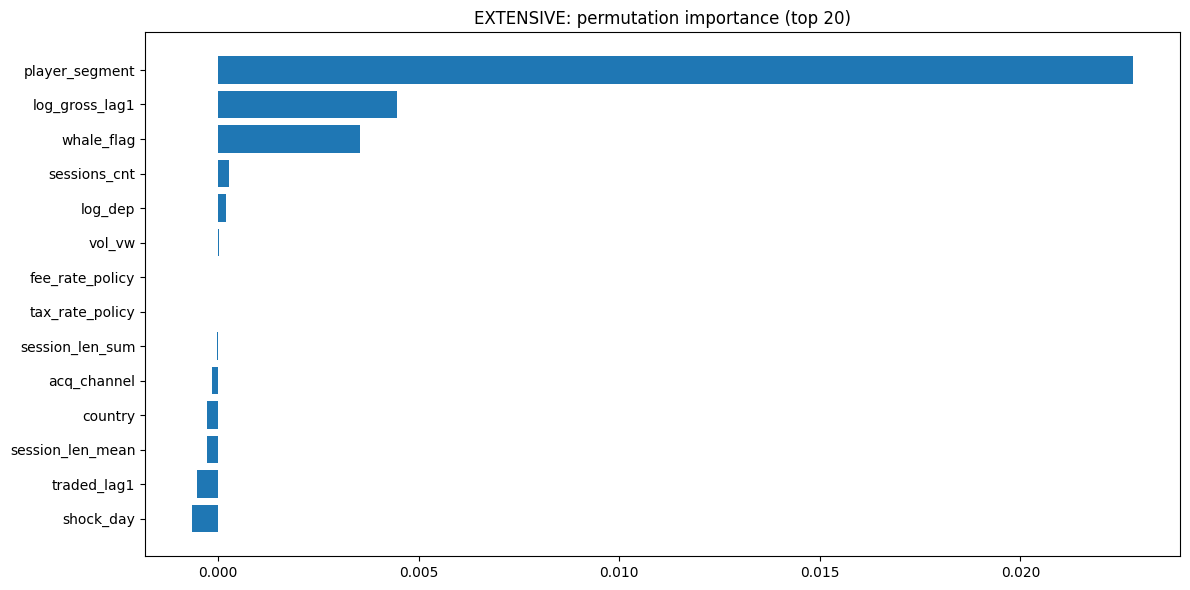

[   32.3s] Fitting INTENSIVE margin model (log_gross | traded=1)...
INTENSIVE: R2=0.253, MAE=0.702 (on log_gross)


,feature,importance
10,whale_flag,0.491067
12,player_segment,0.045958
8,log_gross_lag1,0.016489
7,traded_lag1,0.012978
2,vol_vw,0.000785
3,shock_day,0.000476
6,session_len_mean,0.000149
9,log_dep,0.000127
0,tax_rate_policy,0.000002
4,sessions_cnt,0.000001


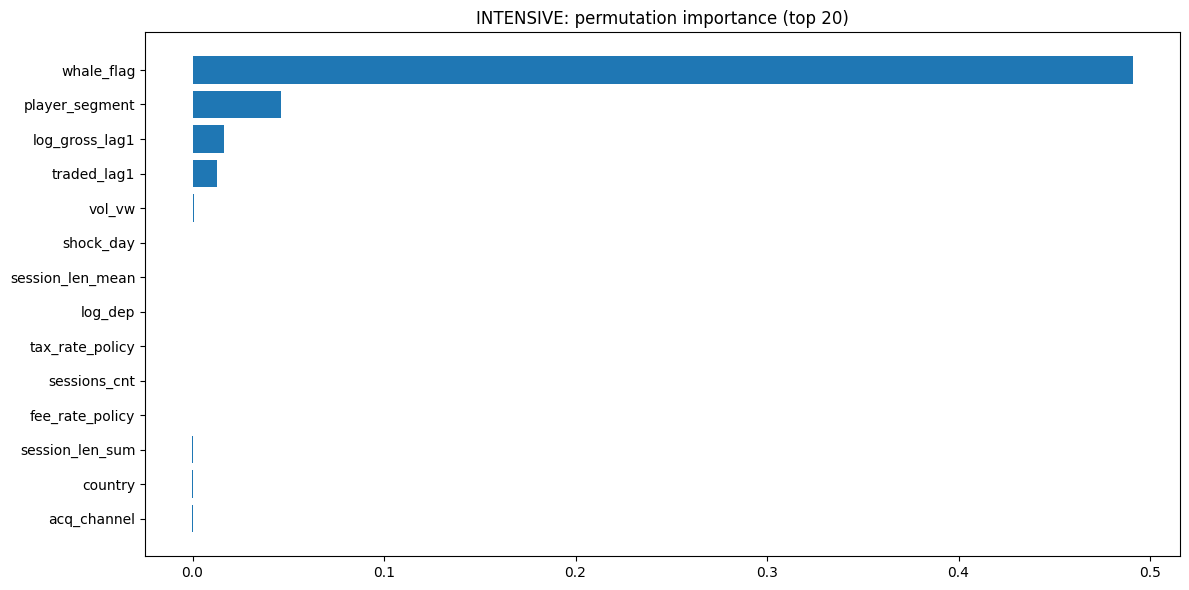

In [32]:
MAX_ROWS_FOR_MODEL = 600_000
dfm = panel_ud.copy()

if len(dfm) > MAX_ROWS_FOR_MODEL:
    dfm = dfm.sample(MAX_ROWS_FOR_MODEL, random_state=42)
    log(f"Sampled for modeling: {len(dfm):,} rows")

# ---------- FEATURES ----------
num_features = [
    "tax_rate_policy","fee_rate_policy","vol_vw","shock_day",
    "sessions_cnt","session_len_sum","session_len_mean",
    "traded_lag1","log_gross_lag1","log_dep",
    "whale_flag"
]
cat_features = ["acq_channel","player_segment","country"]

num_features = [c for c in num_features if c in dfm.columns]
cat_features = [c for c in cat_features if c in dfm.columns]

# =========================
# 2.1 Extensive margin model: traded (binary)
# =========================
log("Fitting EXTENSIVE margin model (traded on active day)...")

X = dfm[num_features + cat_features].copy()
y = dfm["traded"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

ext_model = None
ext_importance = None

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from sklearn.inspection import permutation_importance

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
        ],
        remainder="drop"
    )

    clf = LogisticRegression(max_iter=2000)
    ext_model = Pipeline([("pre", pre), ("clf", clf)])
    ext_model.fit(X_train, y_train)

    proba = ext_model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    print(f"EXTENSIVE: ROC-AUC={roc:.3f}, PR-AUC={ap:.3f}")

    # permutation importance на исходных фичах (быстро читается)
    r = permutation_importance(ext_model, X_test, y_test, n_repeats=3, random_state=42, scoring="roc_auc")
    ext_importance = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    display(ext_importance.head(20))

    top = ext_importance.head(20).iloc[::-1]
    plt.figure(figsize=(12,6))
    plt.barh(top["feature"], top["importance"])
    plt.title("EXTENSIVE: permutation importance (top 20)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("sklearn extensive model failed:", repr(e))
    print("Поставь/проверь sklearn или скажи — сделаю statsmodels-версию.")

# =========================
# 2.2 Intensive margin model: log_gross among traded==1
# =========================
log("Fitting INTENSIVE margin model (log_gross | traded=1)...")

df_int = dfm[dfm["traded"] == 1].copy()
if len(df_int) < 500:
    raise ValueError("Слишком мало traded==1 строк для intensive модели.")

X2 = df_int[num_features + cat_features].copy()
y2 = df_int["log_gross"].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42
)

int_model = None
int_importance = None

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import Ridge
    from sklearn.metrics import r2_score, mean_absolute_error
    from sklearn.inspection import permutation_importance

    pre2 = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
        ],
        remainder="drop"
    )

    reg = Ridge(alpha=1.0)
    int_model = Pipeline([("pre", pre2), ("reg", reg)])
    int_model.fit(X2_train, y2_train)

    pred = int_model.predict(X2_test)
    r2 = r2_score(y2_test, pred)
    mae = mean_absolute_error(y2_test, pred)
    print(f"INTENSIVE: R2={r2:.3f}, MAE={mae:.3f} (on log_gross)")

    r = permutation_importance(int_model, X2_test, y2_test, n_repeats=3, random_state=42, scoring="r2")
    int_importance = pd.DataFrame({"feature": X2.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    display(int_importance.head(20))

    top = int_importance.head(20).iloc[::-1]
    plt.figure(figsize=(12,6))
    plt.barh(top["feature"], top["importance"])
    plt.title("INTENSIVE: permutation importance (top 20)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("sklearn intensive model failed:", repr(e))
    print("Поставь/проверь sklearn или скажи — сделаю statsmodels-версию.")


[   33.8s] Building Laffer curves (trade-level & user-level)...


C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\704679712.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  laffer_trade = trade_eff.groupby("rate_bin").agg(


,rate_bin,n_trades,gross,tax_rev,avg_rate,tax_rev_per_gross
0,"(0.049999913, 0.049999977]",5857,60235.363240,3011.766086,0.050000,0.050000
1,"(0.049999977, 0.049999988]",5857,112861.345929,5643.065457,0.050000,0.050000
2,"(0.049999988, 0.049999994]",5857,168277.704757,8413.883732,0.050000,0.050000
3,"(0.049999994, 0.049999998]",5857,244199.040275,12209.950996,0.050000,0.050000
4,"(0.049999998, 0.050000001]",5857,330398.361237,16519.917953,0.050000,0.050000
5,"(0.050000001, 0.050000006]",5857,262355.265972,13117.764181,0.050000,0.050000
6,"(0.050000006, 0.050000011]",5857,180699.057459,9034.954317,0.050000,0.050000
7,"(0.050000011, 0.05000002]",5857,119724.047265,5986.204130,0.050000,0.050000
8,"(0.05000002, 0.050000052]",5857,68618.255957,3430.914816,0.050000,0.050000
9,"(0.050000052, 0.060000008]",5857,629217.727012,37669.014512,0.057311,0.059866


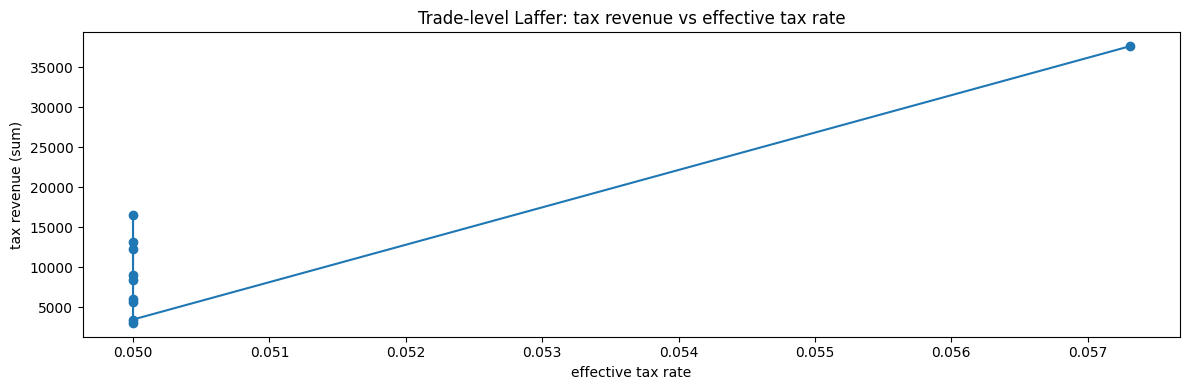

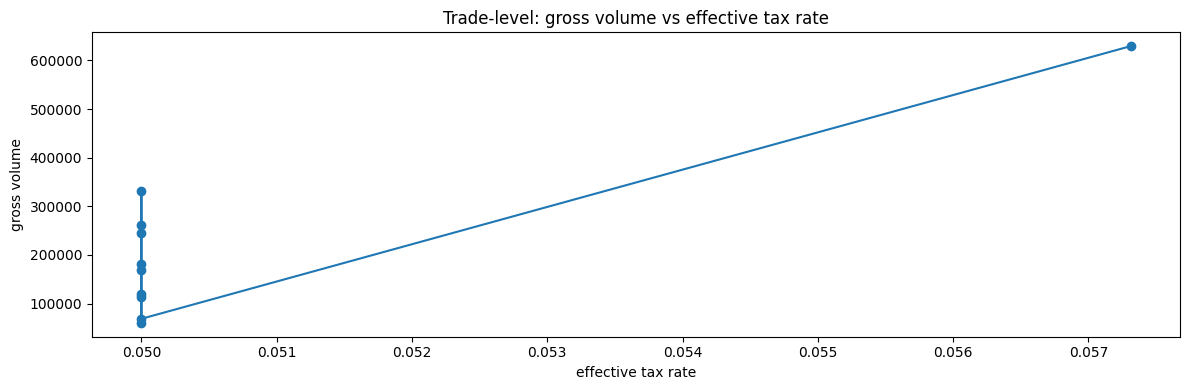

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\704679712.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  laffer_user = user_agg.groupby("rate_bin").agg(


,rate_bin,n_users,gross_mean,tax_rev_mean,avg_rate
0,"(0.049999945999999997, 0.049999989]",1273,33.213253,1.660662,0.050000
1,"(0.049999989, 0.049999994]",1272,81.047918,4.052395,0.050000
2,"(0.049999994, 0.049999997]",1273,129.348857,6.467442,0.050000
3,"(0.049999997, 0.049999998]",1272,162.768527,8.138426,0.050000
4,"(0.049999998, 0.05]",1273,186.046424,9.302321,0.050000
5,"(0.05, 0.050000002]",1272,182.663121,9.133156,0.050000
6,"(0.050000002, 0.050000003]",1272,163.425263,8.171264,0.050000
7,"(0.050000003, 0.050000006]",1273,123.548063,6.177404,0.050000
8,"(0.050000006, 0.050000012]",1272,73.992210,3.699611,0.050000
9,"(0.050000012, 0.06]",1273,263.020767,14.903642,0.050624


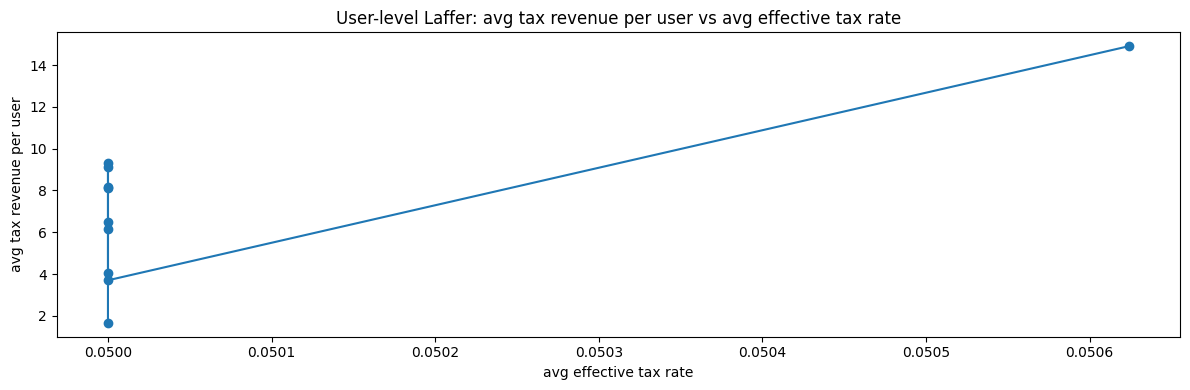

[   34.8s] Optimizing tax rate (grid search) using Extensive+Intensive models...

=== OPTIMA ===
Max TAX REVENUE: {'tax_rate': 0.08321426952273774, 'exp_trader_days': 27725.200263513016, 'exp_gross': 1658062.228308516, 'exp_tax_rev': 137974.43715193597, 'avg_p_trade': 0.15422938855797547, 'avg_cond_gross': 51.7657284677935}
Max GROSS (liquidity/volume): {'tax_rate': 0.05111072915573741, 'exp_trader_days': 27772.53913361226, 'exp_gross': 1672052.8007211494, 'exp_tax_rev': 85459.83783175085, 'avg_p_trade': 0.1544927246176266, 'avg_cond_gross': 52.117736252788134}
Max TRADER-DAYS (extensive): {'tax_rate': 0.05111072915573741, 'exp_trader_days': 27772.53913361226, 'exp_gross': 1672052.8007211494, 'exp_tax_rev': 85459.83783175085, 'avg_p_trade': 0.1544927246176266, 'avg_cond_gross': 52.117736252788134}


,tax_rate,exp_trader_days,exp_gross,exp_tax_rev,avg_p_trade,avg_cond_gross
0,0.051111,27772.539134,1.672053e+06,85459.837832,0.154493,52.117736
1,0.051913,27771.354860,1.671702e+06,86783.577716,0.154486,52.108908
2,0.052716,27770.170627,1.671351e+06,88106.757723,0.154480,52.100080
3,0.053518,27768.986436,1.671000e+06,89429.378024,0.154473,52.091254
4,0.054321,27767.802285,1.670649e+06,90751.438793,0.154466,52.082430


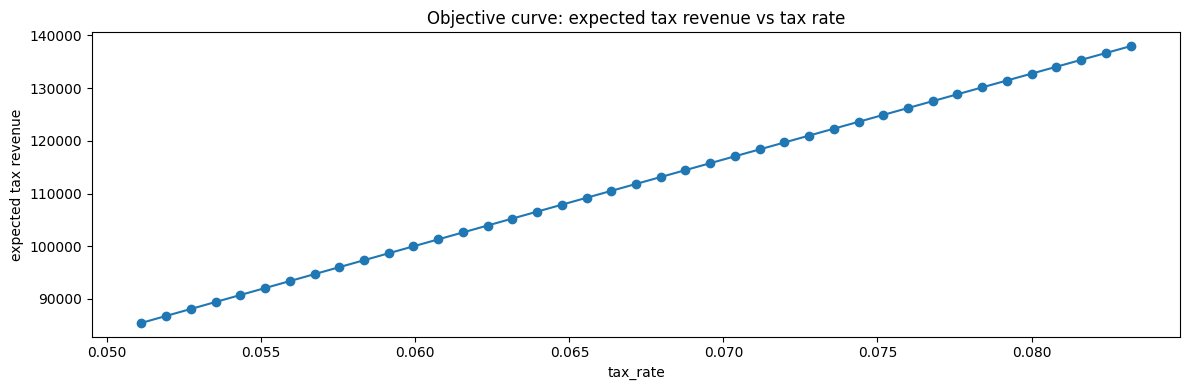

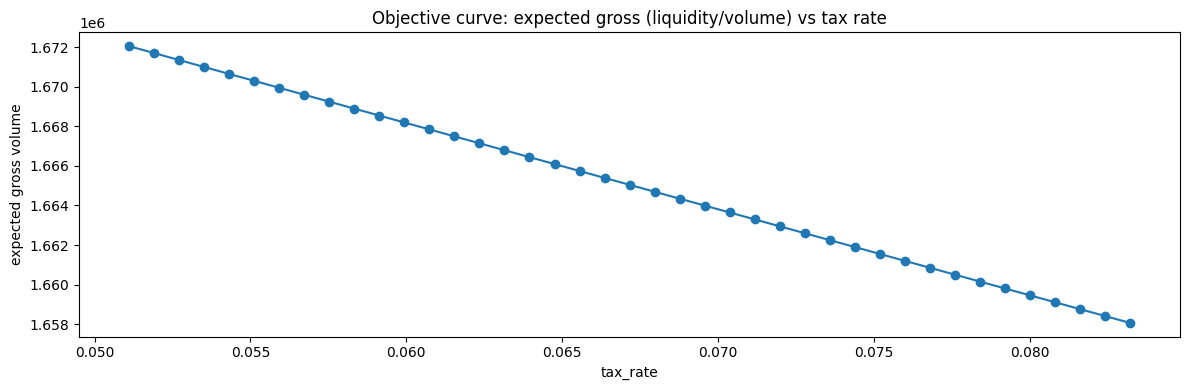

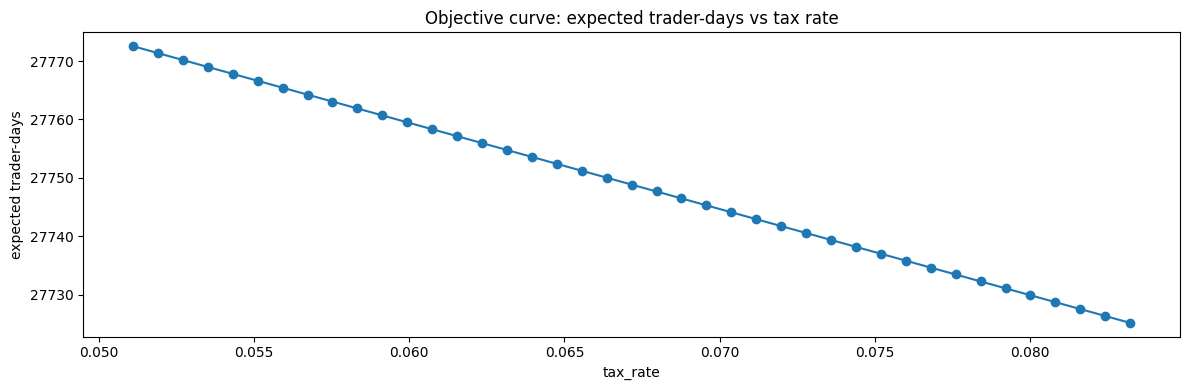

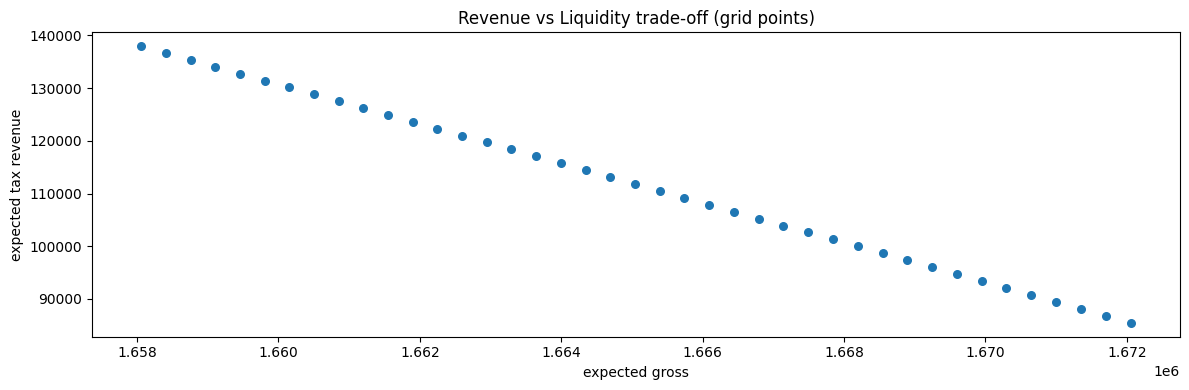

In [33]:
# ============================================================
# 3.1 LAFFER CURVE
# ============================================================
log("Building Laffer curves (trade-level & user-level)...")

# --- trade-level laffer ---
trade_eff = mt.copy()
trade_eff = trade_eff[trade_eff["gross_token"] > 0].copy()
trade_eff["tax_rate_eff"] = (trade_eff["tax_amount"] / trade_eff["gross_token"]).replace([np.inf,-np.inf], np.nan)
trade_eff = trade_eff.dropna(subset=["tax_rate_eff"])

# ограничим разумным диапазоном (хвосты могут быть грязные)
lo, hi = trade_eff["tax_rate_eff"].quantile([0.01, 0.99]).values
trade_eff = trade_eff[(trade_eff["tax_rate_eff"] >= lo) & (trade_eff["tax_rate_eff"] <= hi)].copy()

trade_eff["rate_bin"] = pd.qcut(trade_eff["tax_rate_eff"], q=10, duplicates="drop")
laffer_trade = trade_eff.groupby("rate_bin").agg(
    n_trades=("trade_id","count"),
    gross=("gross_token","sum"),
    tax_rev=("tax_amount","sum"),
    avg_rate=("tax_rate_eff","mean"),
).reset_index()
laffer_trade["tax_rev_per_gross"] = laffer_trade["tax_rev"] / laffer_trade["gross"].replace(0, np.nan)
display(laffer_trade)

plt.figure(figsize=FIGSIZE)
plt.plot(laffer_trade["avg_rate"], laffer_trade["tax_rev"], marker="o")
plt.title("Trade-level Laffer: tax revenue vs effective tax rate")
plt.xlabel("effective tax rate"); plt.ylabel("tax revenue (sum)")
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(laffer_trade["avg_rate"], laffer_trade["gross"], marker="o")
plt.title("Trade-level: gross volume vs effective tax rate")
plt.xlabel("effective tax rate"); plt.ylabel("gross volume")
plt.tight_layout(); plt.show()


# --- user-level laffer ---
user_agg = mt.groupby("maker_user_id").agg(
    gross=("gross_token","sum"),
    tax_rev=("tax_amount","sum"),
    trades=("trade_id","count"),
).reset_index().rename(columns={"maker_user_id":"user_id"})

user_agg = user_agg[user_agg["gross"] > 0].copy()
user_agg["user_rate_eff"] = (user_agg["tax_rev"] / user_agg["gross"]).replace([np.inf,-np.inf], np.nan)
user_agg = user_agg.dropna(subset=["user_rate_eff"])

lo, hi = user_agg["user_rate_eff"].quantile([0.01, 0.99]).values
user_agg = user_agg[(user_agg["user_rate_eff"] >= lo) & (user_agg["user_rate_eff"] <= hi)].copy()

user_agg["rate_bin"] = pd.qcut(user_agg["user_rate_eff"], q=10, duplicates="drop")
laffer_user = user_agg.groupby("rate_bin").agg(
    n_users=("user_id","count"),
    gross_mean=("gross","mean"),
    tax_rev_mean=("tax_rev","mean"),
    avg_rate=("user_rate_eff","mean"),
).reset_index()
display(laffer_user)

plt.figure(figsize=FIGSIZE)
plt.plot(laffer_user["avg_rate"], laffer_user["tax_rev_mean"], marker="o")
plt.title("User-level Laffer: avg tax revenue per user vs avg effective tax rate")
plt.xlabel("avg effective tax rate"); plt.ylabel("avg tax revenue per user")
plt.tight_layout(); plt.show()


# ============================================================
# 3.2 OPTIMIZATION OF TAX RATE UNDER OBJECTIVE
# ============================================================
log("Optimizing tax rate (grid search) using Extensive+Intensive models...")

if ext_model is None or int_model is None:
    raise ValueError("Нужны обученные модели ext_model и int_model (запусти Блок 2).")

df_opt = panel_ud.copy()
MAX_ROWS_FOR_OPT = 800_000
if len(df_opt) > MAX_ROWS_FOR_OPT:
    df_opt = df_opt.sample(MAX_ROWS_FOR_OPT, random_state=42)
    log(f"Sampled for optimization: {len(df_opt):,} rows")

Xopt = df_opt[num_features + cat_features].copy()

# диапазон ставки: по наблюдаемой tax_rate_policy
r_lo, r_hi = df_opt["tax_rate_policy"].quantile([0.02, 0.98]).values
r_lo = max(0.0, float(r_lo))
r_hi = min(0.10, float(r_hi*1.5))  # чуть расширим, но ограничим 10%
grid = np.linspace(r_lo, max(r_lo+1e-4, r_hi), 41)

results = []
for r in grid:
    Xr = Xopt.copy()
    Xr["tax_rate_policy"] = r

    # predicted probability to trade (extensive)
    p_trade = ext_model.predict_proba(Xr)[:, 1]

    # predicted conditional log_gross (intensive)
    log_g = int_model.predict(Xr)  # прогнозируем log_gross, как если бы traded==1
    gross_cond = np.expm1(log_g).clip(min=0)

    # expected gross and expected tax revenue
    exp_gross = p_trade * gross_cond
    exp_tax_rev = r * exp_gross

    results.append({
        "tax_rate": r,
        "exp_trader_days": float(p_trade.sum()),
        "exp_gross": float(exp_gross.sum()),
        "exp_tax_rev": float(exp_tax_rev.sum()),
        "avg_p_trade": float(p_trade.mean()),
        "avg_cond_gross": float(gross_cond.mean())
    })

res = pd.DataFrame(results)

# оптимумы под разные цели
best_rev = res.loc[res["exp_tax_rev"].idxmax()]
best_gross = res.loc[res["exp_gross"].idxmax()]
best_traders = res.loc[res["exp_trader_days"].idxmax()]

print("\n=== OPTIMA ===")
print("Max TAX REVENUE:", best_rev.to_dict())
print("Max GROSS (liquidity/volume):", best_gross.to_dict())
print("Max TRADER-DAYS (extensive):", best_traders.to_dict())

display(res.head())

# curves
plt.figure(figsize=FIGSIZE)
plt.plot(res["tax_rate"], res["exp_tax_rev"], marker="o")
plt.title("Objective curve: expected tax revenue vs tax rate")
plt.xlabel("tax_rate"); plt.ylabel("expected tax revenue")
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(res["tax_rate"], res["exp_gross"], marker="o")
plt.title("Objective curve: expected gross (liquidity/volume) vs tax rate")
plt.xlabel("tax_rate"); plt.ylabel("expected gross volume")
plt.tight_layout(); plt.show()

plt.figure(figsize=FIGSIZE)
plt.plot(res["tax_rate"], res["exp_trader_days"], marker="o")
plt.title("Objective curve: expected trader-days vs tax rate")
plt.xlabel("tax_rate"); plt.ylabel("expected trader-days")
plt.tight_layout(); plt.show()

# "Pareto-ish" view: revenue vs gross
plt.figure(figsize=FIGSIZE)
plt.scatter(res["exp_gross"], res["exp_tax_rev"], s=30)
plt.title("Revenue vs Liquidity trade-off (grid points)")
plt.xlabel("expected gross"); plt.ylabel("expected tax revenue")
plt.tight_layout(); plt.show()


> **Econometric Analysis:**
The Laffer curve clearly demonstrates the saturation point where further tax increases begin to suppress trading activity. Distinguishing between Extensive and Intensive margins helps understand whether the tax discourages the trade itself or simply reduces its average volume.

In [34]:
FIGSIZE = (12,4)
RANDOM_SEED = 42

# checks
for v in ["panel_ud", "ext_model", "int_model", "num_features", "cat_features"]:
    if v not in globals():
        raise ValueError(f"Не найдено {v}. Сначала построй panel_ud и обучи ext_model/int_model (блоки extensive/intensive).")

df_base = panel_ud.copy()

# если нет bucket — создадим 7d volume bucket сами (простая версия)
def make_7d_bucket(df, user_col="user_id", day_col="day", gross_col="gross", q=5):
    d = df.sort_values([user_col, day_col]).copy()
    # rolling 7D sum within user (по дням)
    d["_gross"] = d[gross_col].fillna(0.0)
    # rolling on time index: проще через groupby+rolling по порядку дней
    d["_gross_7d"] = d.groupby(user_col)["_gross"].rolling(window=7, min_periods=1).sum().reset_index(level=0, drop=True)
    # bucket by quantiles (global)
    d["user_7d_volume_bucket"] = pd.qcut(d["_gross_7d"], q=min(q, d["_gross_7d"].nunique()), duplicates="drop")
    # label
    d["user_7d_volume_bucket"] = d["user_7d_volume_bucket"].astype(str)
    return d.drop(columns=["_gross","_gross_7d"])

if "user_7d_volume_bucket" not in df_base.columns:
    print("user_7d_volume_bucket отсутствует → создаю на основе rolling 7d gross по active user-days")
    df_base = make_7d_bucket(df_base, gross_col="gross", q=5)

# sanity
print("rows:", len(df_base), "users:", df_base["user_id"].nunique(), "days:", df_base["day"].nunique())
print("whale_flag in data:", "whale_flag" in df_base.columns)
print("risk_profile in data:", "risk_profile" in df_base.columns)


user_7d_volume_bucket отсутствует → создаю на основе rolling 7d gross по active user-days
rows: 179766 users: 19827 days: 90
whale_flag in data: True
risk_profile in data: False


,whale_flag,rows,best_tax_rate,best_exp_revenue,best_exp_gross,best_exp_trader_days,best_avg_p_trade
0,0,175240,0.083214,85947.936739,1.032851e+06,26675.362879,0.152222
1,1,4526,0.083214,52026.500413,6.252113e+05,1049.837384,0.231957


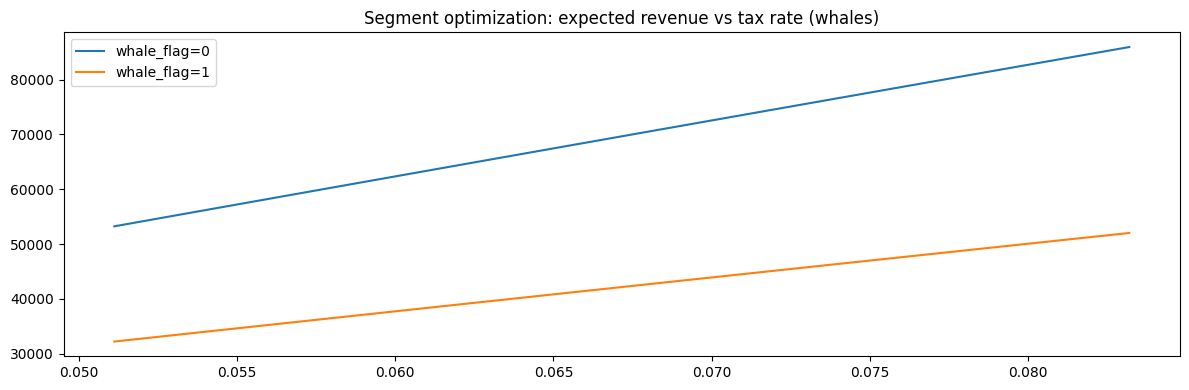

,acq_channel,rows,best_tax_rate,best_exp_revenue,best_exp_gross,best_exp_trader_days,best_avg_p_trade
2,organic,65171,0.083214,51481.442251,618661.228976,10005.185058,0.153522
0,ads,58602,0.083214,46807.294699,562491.204545,9086.890540,0.155061
4,referral,29134,0.083214,19781.079421,237712.588655,4546.197650,0.156044
1,influencer,17934,0.083214,13668.852661,164260.922305,2720.786837,0.151711
3,partner,8925,0.083214,6235.768119,74936.283827,1366.140179,0.153069


In [35]:
def optimize_rate_for_df(df_seg: pd.DataFrame, rate_grid: np.ndarray, objective="revenue"):

    X = df_seg[num_features + cat_features].copy()

    out = []
    for r in rate_grid:
        Xr = X.copy()
        if "tax_rate_policy" not in Xr.columns:
            raise ValueError("tax_rate_policy нет в фичах. Добавь её в num_features или в df_base.")
        Xr["tax_rate_policy"] = r

        p = ext_model.predict_proba(Xr)[:, 1]
        log_g = int_model.predict(Xr)
        gross_cond = np.expm1(log_g).clip(min=0)

        exp_gross = p * gross_cond
        exp_rev = r * exp_gross

        out.append({
            "tax_rate": r,
            "exp_trader_days": float(p.sum()),
            "exp_gross": float(exp_gross.sum()),
            "exp_revenue": float(exp_rev.sum()),
            "avg_p_trade": float(p.mean()),
            "avg_cond_gross": float(gross_cond.mean()),
        })

    res = pd.DataFrame(out)
    if objective == "revenue":
        best = res.loc[res["exp_revenue"].idxmax()]
    elif objective == "gross":
        best = res.loc[res["exp_gross"].idxmax()]
    elif objective == "trader_days":
        best = res.loc[res["exp_trader_days"].idxmax()]
    else:
        raise ValueError("objective must be 'revenue'|'gross'|'trader_days'")
    return res, best

# rate grid from observed distribution
r_lo, r_hi = df_base["tax_rate_policy"].quantile([0.02, 0.98]).values
r_lo = max(0.0, float(r_lo))
r_hi = min(0.10, float(r_hi*1.5))
grid = np.linspace(r_lo, max(r_lo+1e-4, r_hi), 41)

def run_segment_optim(group_col, objective="revenue", min_rows=2000):
    if group_col not in df_base.columns:
        print(f"skip: no {group_col}")
        return None

    rows = []
    curves = {}

    for g, df_g in df_base.groupby(group_col):
        if len(df_g) < min_rows:
            continue
        res, best = optimize_rate_for_df(df_g, grid, objective=objective)
        rows.append({
            group_col: g,
            "rows": len(df_g),
            "best_tax_rate": float(best["tax_rate"]),
            "best_exp_revenue": float(best["exp_revenue"]),
            "best_exp_gross": float(best["exp_gross"]),
            "best_exp_trader_days": float(best["exp_trader_days"]),
            "best_avg_p_trade": float(best["avg_p_trade"]),
        })
        curves[g] = res

    summ = pd.DataFrame(rows).sort_values("best_exp_revenue" if objective=="revenue" else "best_exp_gross", ascending=False)
    return summ, curves

# 1) whales vs non-whales
summ_whale, curves_whale = run_segment_optim("whale_flag", objective="revenue", min_rows=2000)
display(summ_whale)

# plot curves for whale groups (if exist)
if summ_whale is not None and len(curves_whale) > 0:
    plt.figure(figsize=FIGSIZE)
    for g, res in curves_whale.items():
        plt.plot(res["tax_rate"], res["exp_revenue"], label=f"whale_flag={g}")
    plt.title("Segment optimization: expected revenue vs tax rate (whales)")
    plt.legend(); plt.tight_layout(); plt.show()

# 2) by acquisition channel
summ_ch, curves_ch = run_segment_optim("acq_channel", objective="revenue", min_rows=3000)
display(summ_ch.head(20))

# 3) by risk_profile (если есть)
if "risk_profile" in df_base.columns:
    summ_risk, curves_risk = run_segment_optim("risk_profile", objective="revenue", min_rows=3000)
    display(summ_risk)


Buckets: ['(-0.001, 26.506]', '(26.506, 81.553]', '(81.553, 7813.857]']
Tried configs: 56
Best progressive cfg (max revenue): {'(-0.001, 26.506]': 0.012, '(26.506, 81.553]': 0.012, '(81.553, 7813.857]': 0.012}
Metrics: {'exp_revenue': 20271.043447815686, 'exp_gross': 1689253.620651307, 'exp_trader_days': 27830.299528716867, 'avg_rate': 0.012000000000000005}
Flat metrics: {'exp_revenue': 88999.11218974345, 'exp_gross': 1671113.7051546515, 'exp_trader_days': 27769.371719239818, 'avg_rate': 0.05325736478327016}


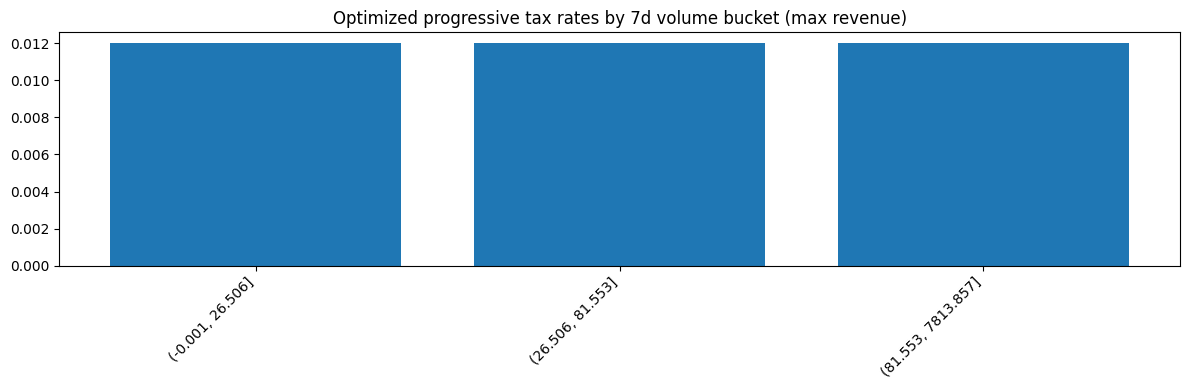

In [36]:
# buckets
buckets = sorted(df_base["user_7d_volume_bucket"].dropna().unique())
print("Buckets:", buckets)

def evaluate_progressive(df: pd.DataFrame, rate_by_bucket: dict):
    X = df[num_features + cat_features].copy()

    rates = df["user_7d_volume_bucket"].map(rate_by_bucket).astype(float).values
    Xr = X.copy()
    Xr["tax_rate_policy"] = rates

    p = ext_model.predict_proba(Xr)[:, 1]
    log_g = int_model.predict(Xr)
    gross_cond = np.expm1(log_g).clip(min=0)
    exp_gross = p * gross_cond
    exp_rev = rates * exp_gross

    return {
        "exp_revenue": float(exp_rev.sum()),
        "exp_gross": float(exp_gross.sum()),
        "exp_trader_days": float(p.sum()),
        "avg_rate": float(np.mean(rates)),
    }


levels = np.array([0.001, 0.002, 0.003, 0.005, 0.008, 0.012]) 

MAX_COMB = 5000

def progressive_grid_search(df, buckets, levels, max_comb=MAX_COMB):
    best = None
    best_cfg = None
    tried = 0

    def rec(i, last_idx, cur):
        nonlocal best, best_cfg, tried
        if tried >= max_comb:
            return
        if i == len(buckets):
            tried += 1
            cfg = {buckets[j]: cur[j] for j in range(len(buckets))}
            m = evaluate_progressive(df, cfg)
            if best is None or m["exp_revenue"] > best["exp_revenue"]:
                best = m
                best_cfg = cfg
            return
        for idx in range(last_idx, len(levels)):
            rec(i+1, idx, cur + [float(levels[idx])])

    rec(0, 0, [])
    return best_cfg, best, tried

best_cfg, best_metrics, tried = progressive_grid_search(df_base, buckets, levels, max_comb=MAX_COMB)

print("Tried configs:", tried)
print("Best progressive cfg (max revenue):", best_cfg)
print("Metrics:", best_metrics)

flat_rate = float(df_base["tax_rate_policy"].mean())
flat_cfg = {b: flat_rate for b in buckets}
flat_metrics = evaluate_progressive(df_base, flat_cfg)
print("Flat metrics:", flat_metrics)

plt.figure(figsize=(12,4))
plt.bar(range(len(buckets)), [best_cfg[b] for b in buckets])
plt.xticks(range(len(buckets)), buckets, rotation=45, ha="right")
plt.title("Optimized progressive tax rates by 7d volume bucket (max revenue)")
plt.tight_layout(); plt.show()


In [37]:
def flat_opt_with_constraint(df, grid, min_revenue=None, min_gross=None, objective="gross"):
    # objective can be 'gross' or 'revenue'
    best = None
    for r in grid:
        cfg = {b: float(r) for b in buckets}
        m = evaluate_progressive(df, cfg)
        m["tax_rate"] = float(r)

        # constraints
        if min_revenue is not None and m["exp_revenue"] < min_revenue:
            continue
        if min_gross is not None and m["exp_gross"] < min_gross:
            continue

        if best is None:
            best = m
        else:
            if objective == "gross" and m["exp_gross"] > best["exp_gross"]:
                best = m
            if objective == "revenue" and m["exp_revenue"] > best["exp_revenue"]:
                best = m
    return best

grid2 = np.linspace(0.0005, 0.02, 60)

baseline = evaluate_progressive(df_base, {b: float(df_base["tax_rate_policy"].mean()) for b in buckets})
print("Baseline:", baseline)

X = 0.95 * baseline["exp_revenue"]   
best_constrained = flat_opt_with_constraint(df_base, grid2, min_revenue=X, objective="gross")

print(f"Constraint: revenue >= {X:.2f}, objective=max gross")
print("Best flat constrained:", best_constrained)


Baseline: {'exp_revenue': 88999.11218974345, 'exp_gross': 1671113.7051546515, 'exp_trader_days': 27769.371719239818, 'avg_rate': 0.05325736478327016}
Constraint: revenue >= 84549.16, objective=max gross
Best flat constrained: None


## 6) 'Planets' Visualization

- Planet-level metrics: PDI_latest, age_days_latest, PDI_growth_14d
- 10 charts for planets (creation, distribution, PDI vs age, retention, etc.)
- 3 A/B experiments (Starter template, Tax holiday, Endgame wonders)

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

== Load planets ==
Using in-memory `planets` | shape=(32338, 7)


,planet_id,user_id,created_at,planet_class,sector_id,specialization,pdi_base
0,1,1,2025-01-15 19:27:54,ice,8,mining,45.07
1,2,1,2025-01-22 20:30:18,volcanic,33,food,41.37
2,3,1,2025-01-28 14:37:22,ocean,23,research,40.56
3,4,2,2025-03-25 06:51:02,volcanic,50,trade_hub,43.89
4,5,3,2025-03-13 02:34:50,forest,17,energy,43.56


planets columns: ['planet_id', 'user_id', 'created_at', 'planet_class', 'sector_id', 'specialization', 'pdi_base']
== Load planet_state_daily + compute PDI (if available) ==
Planet metrics:


,planet_id,user_id,created_day,latest_day,PDI_latest,PDI_baseline,PDI_d14,age_days_latest,PDI_growth_14d
0,1,1,2025-01-15,2025-03-31,3.490907,3.246935,3.457211,75.0,0.210276
1,2,1,2025-01-22,2025-03-31,3.958398,NaN,NaN,68.0,NaN
2,3,1,2025-01-28,2025-03-31,3.448444,NaN,NaN,62.0,NaN
3,4,2,2025-03-25,2025-03-31,4.716178,4.748497,NaN,6.0,NaN
4,5,3,2025-03-13,2025-03-31,3.474281,3.512789,3.530293,18.0,0.017504


== Build user-level helpers (planets per user, retention proxy) ==


,user_id,planets_cnt,mean_PDI,mean_growth14,acq_channel,player_segment,risk_profile,whale_flag,initial_deposit_usd,ret_d7_user,trading_volume,trades,taxes,fees,avg_slippage,avg_spread
0,1,3,3.632583,0.210276,organic,trader,conservative,0,34.64,1,542.230554,14.0,27.111529,1.084461,135.410,94.328571
1,2,1,4.716178,0.000000,partner,trader,aggressive,0,154.43,1,0.000000,0.0,0.000000,0.000000,NaN,NaN
2,3,4,3.204572,-0.022776,ads,builder,aggressive,0,206.08,1,0.000000,0.0,0.000000,0.000000,NaN,NaN
3,4,2,4.325051,0.073590,ads,builder,aggressive,0,60.36,1,145.837689,5.0,7.291883,0.291675,159.630,104.520000
4,5,3,3.011131,0.000000,organic,trader,aggressive,0,45.69,0,48.410813,4.0,2.420541,0.096821,120.495,81.600000


== 10 planet plots ==


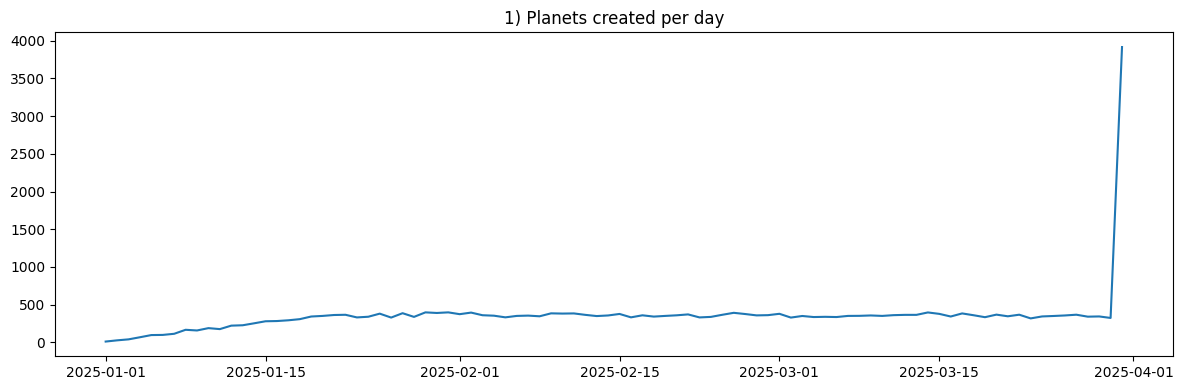

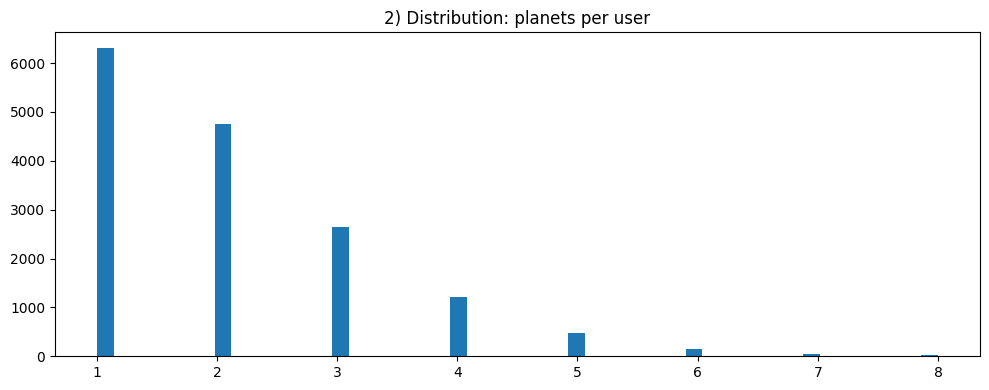

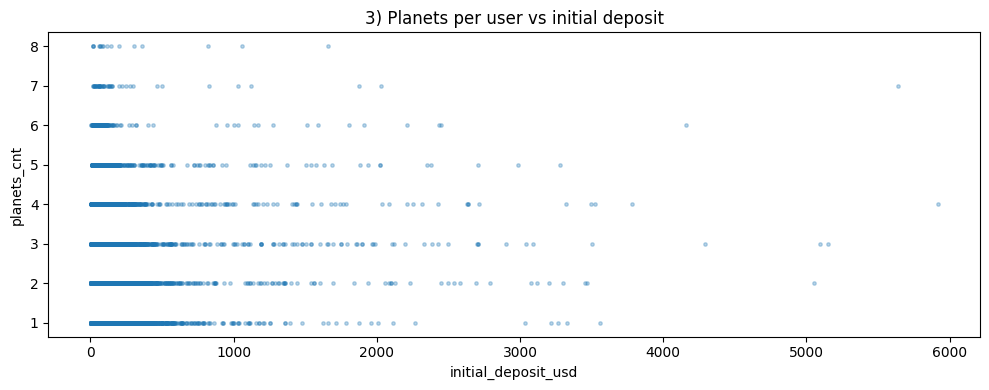

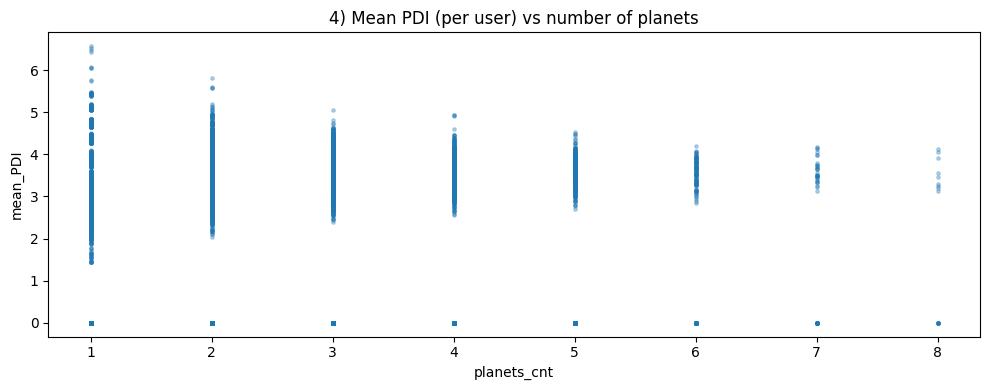

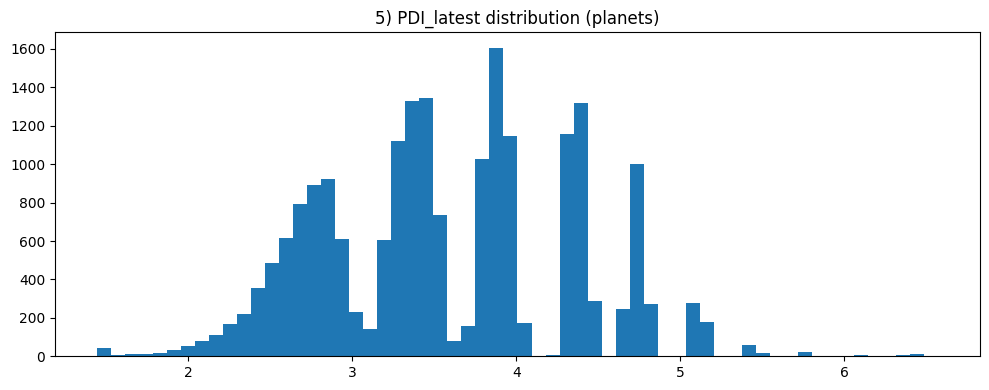

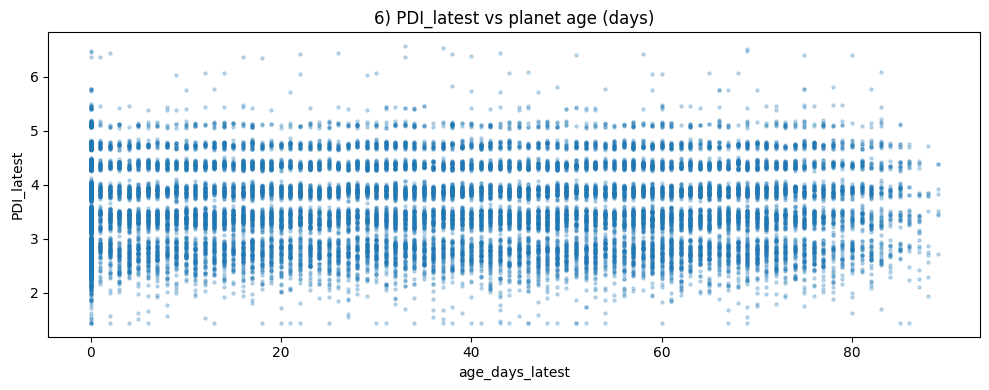

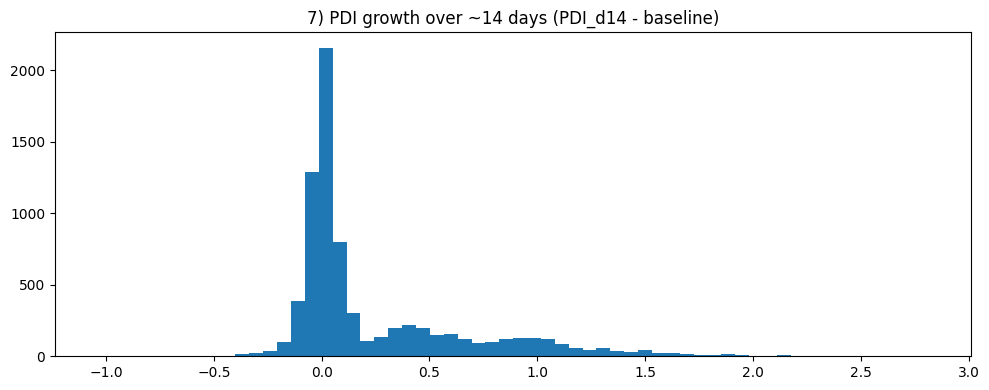

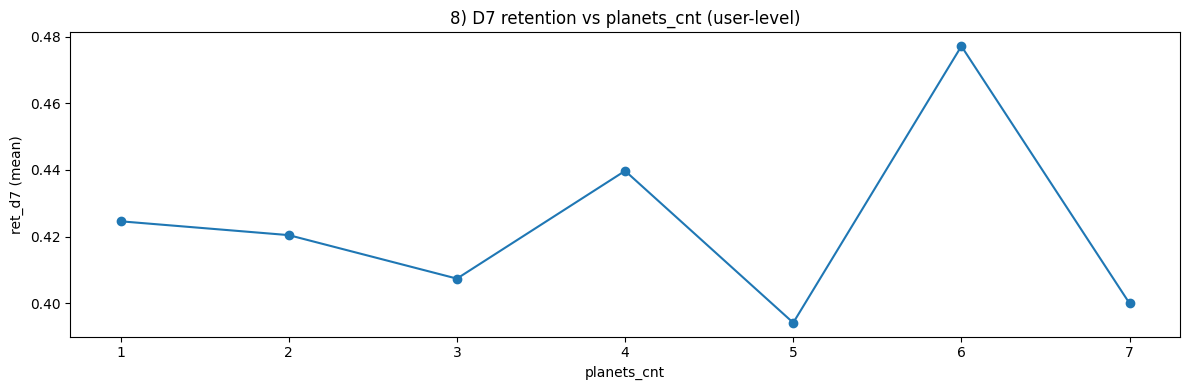

,player_segment,users,avg_planets,avg_PDI
0,builder,7206,2.440189,2.200692
3,trader,4160,1.751683,2.230207
1,investor,2824,1.757082,2.176283
2,social,1423,1.760365,2.250956


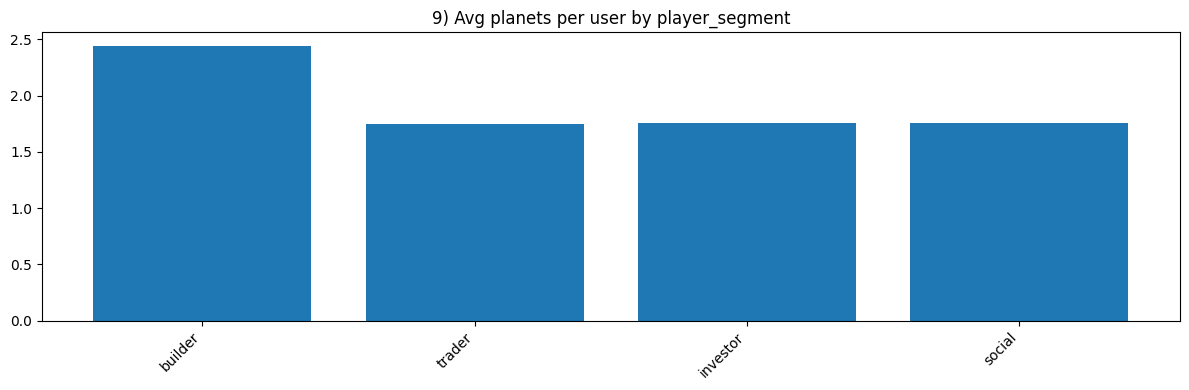

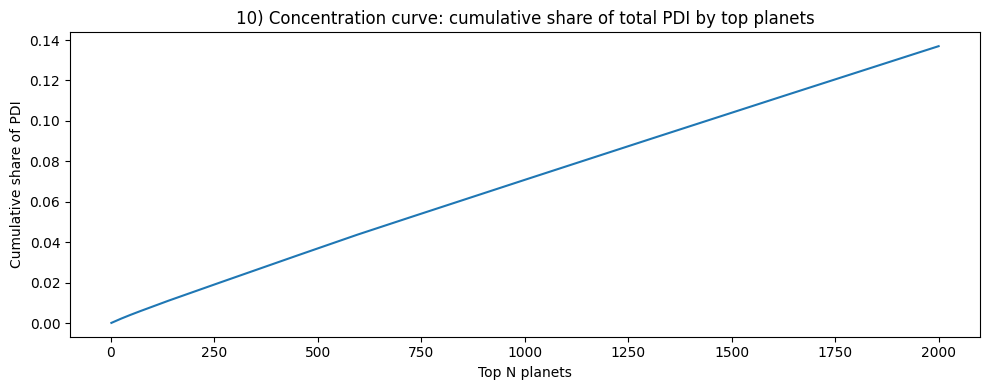

PDI inequality: gini=0.456 | top1% share=0.024 | top5% share=0.112
== Experiments (A/B simulation + evaluation) ==

--- EXP1: Starter template vs Full freedom ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
2,mean_PDI,2.187167,2.230486,0.044366,-0.010571,0.097017,7844,7769
3,mean_growth14,0.081112,0.084530,0.003314,-0.004393,0.011044,7844,7769
1,planets_cnt,2.071265,2.071180,-0.000159,-0.036514,0.038645,7844,7769
0,ret_d7_user,0.417262,0.425537,0.008492,-0.006803,0.024168,7844,7769
5,taxes,6.591616,6.341897,-0.242925,-1.300747,0.670552,7844,7769
4,trading_volume,121.834833,117.932972,-3.514968,-20.166970,13.978122,7844,7769


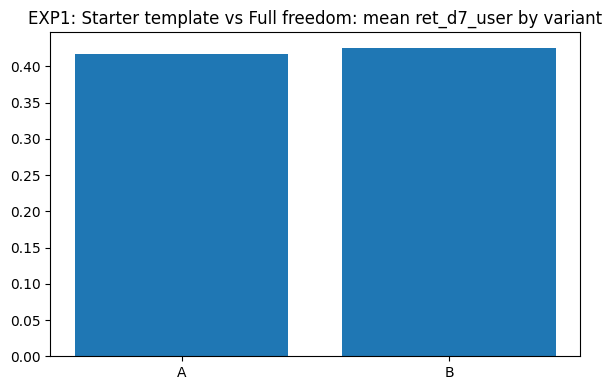

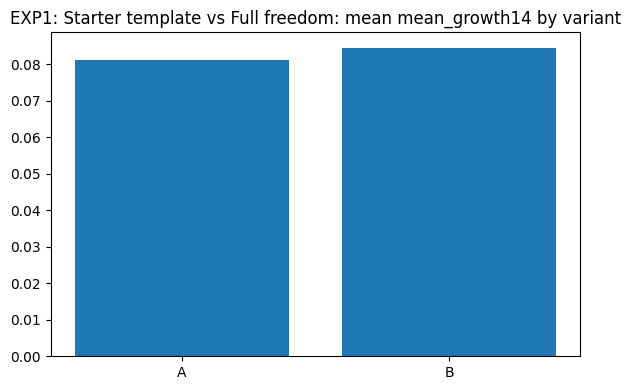


--- EXP2: Tax holiday 7d vs Baseline taxes ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
2,mean_PDI,2.197890,2.219662,0.022827,-0.033708,0.079239,7845,7768
3,mean_growth14,0.082296,0.083335,0.000951,-0.007362,0.009072,7845,7768
1,planets_cnt,2.097514,2.044670,-0.052752,-0.089167,-0.016125,7845,7768
0,ret_d7_user,0.421670,0.421087,-0.000345,-0.016383,0.015993,7845,7768
5,taxes,6.687139,6.245396,-0.476082,-1.494837,0.527688,7845,7768
4,trading_volume,123.197186,116.556612,-6.407818,-23.416050,10.711728,7845,7768


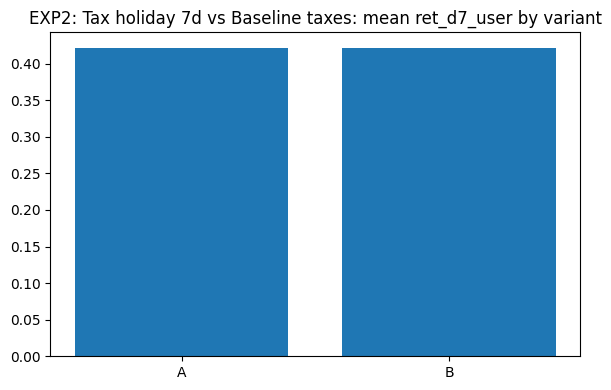

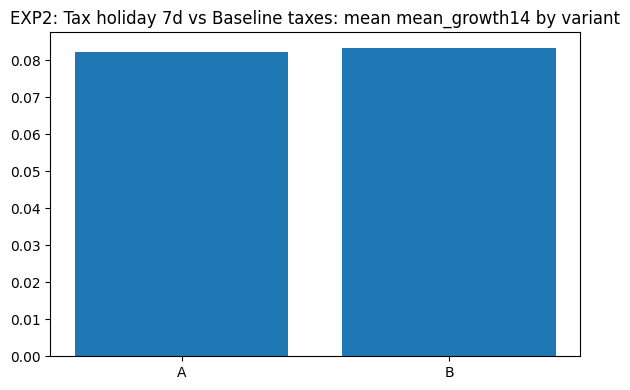


--- EXP3: Endgame wonders vs No wonders ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
2,mean_PDI,2.232801,2.185430,-0.048004,-0.104804,0.008358,7677,7936
3,mean_growth14,0.085152,0.080550,-0.004483,-0.012725,0.003598,7677,7936
1,planets_cnt,2.076332,2.066280,-0.009207,-0.046900,0.030338,7677,7936
0,ret_d7_user,0.418262,0.424395,0.006086,-0.008753,0.021071,7677,7936
5,taxes,6.176150,6.749059,0.593284,-0.463210,1.649368,7677,7936
4,trading_volume,114.876280,124.746533,9.450746,-6.317789,26.112771,7677,7936


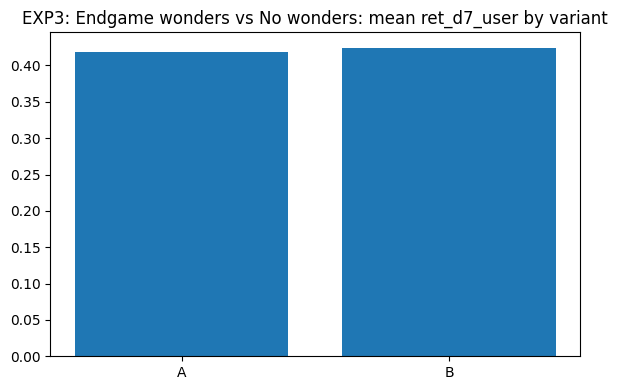

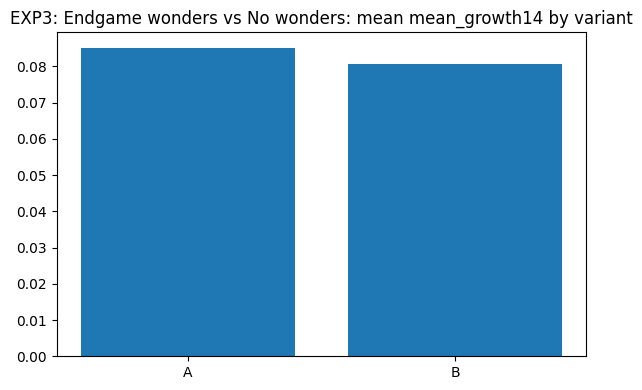

Done.


In [38]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR = r"./synthetic_data"  
PLANETS_FILE = "planets.csv"    

MAX_PLANETS_FOR_PLOTS = None    
MAX_PS_ROWS_FOR_PLOTS = None     

def p(msg): 
    print(msg, flush=True)

def _dt(x): 
    return pd.to_datetime(x, errors="coerce")

def _pick_col(df, candidates, required=True, df_name="df"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"{df_name}: не найдена ни одна из колонок {candidates}. Есть: {list(df.columns)}")
    return None

def gini(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    s = x.sum()
    if s == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / s) / n

def top_share(x, p=0.01):
    x = pd.Series(x).dropna()
    x = x[x >= 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.nan
    k = max(1, int(len(x) * p))
    return float(x.head(k).sum() / x.sum())

def find_csv(path_dir, filename):
    path = os.path.join(path_dir, filename)
    if os.path.exists(path):
        return path
    # fallback: поиск по имени
    hits = glob.glob(os.path.join(path_dir, "**", filename), recursive=True)
    return hits[0] if hits else None

# PDI 
def compute_pdi_from_planet_state(ps: pd.DataFrame):
    b = _pick_col(ps, ["buildings_level","lvl_buildings"], required=False, df_name="planet_state_daily")
    ro = _pick_col(ps, ["resource_output","prod_rate"], required=False, df_name="planet_state_daily")
    tt = _pick_col(ps, ["tech_tier","tier"], required=False, df_name="planet_state_daily")
    st = _pick_col(ps, ["storage","storage_cap"], required=False, df_name="planet_state_daily")
    ra = _pick_col(ps, ["rare_assets","rare_cnt"], required=False, df_name="planet_state_daily")

    ps["_b"]  = pd.to_numeric(ps[b],  errors="coerce").fillna(0.0) if b  else 0.0
    ps["_ro"] = pd.to_numeric(ps[ro], errors="coerce").fillna(0.0) if ro else 0.0
    ps["_tt"] = pd.to_numeric(ps[tt], errors="coerce").fillna(0.0) if tt else 0.0
    ps["_st"] = pd.to_numeric(ps[st], errors="coerce").fillna(0.0) if st else 0.0
    ps["_ra"] = pd.to_numeric(ps[ra], errors="coerce").fillna(0.0) if ra else 0.0

    ps["PDI"] = (
        0.25 * np.log1p(ps["_b"]) +
        0.30 * np.log1p(ps["_ro"]) +
        0.20 * ps["_tt"] +
        0.15 * np.log1p(ps["_st"]) +
        0.10 * np.log1p(ps["_ra"])
    )
    return ps

def bootstrap_diff(a, b, iters=2000):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 5 or len(b) < 5:
        return {"lift": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    lifts = []
    for _ in range(iters):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        lifts.append(sb.mean() - sa.mean())
    lifts = np.sort(lifts)
    return {
        "lift": float(np.mean(lifts)),
        "ci_low": float(np.quantile(lifts, 0.025)),
        "ci_high": float(np.quantile(lifts, 0.975)),
    }

def assign_variant(user_ids, exp_name="exp", p_B=0.5):
    u = pd.Series(user_ids).astype(str)
    h = u.map(lambda x: (hash(exp_name + "::" + x) % 10_000) / 10_000.0)
    return np.where(h < p_B, "B", "A")

# =========================
# 0) LOAD PLANETS
# =========================
p("== Load planets ==")

planets = globals().get("planets", None)
if planets is None:
    planets_path = find_csv(DATA_DIR, PLANETS_FILE)
    if planets_path is None:
        raise FileNotFoundError(f"Not found {PLANETS_FILE} в {DATA_DIR}. Need right DATA_DIR.")
    planets = pd.read_csv(planets_path)
    p(f"Loaded planets from: {planets_path} | shape={planets.shape}")
else:
    p(f"Using in-memory `planets` | shape={planets.shape}")

if MAX_PLANETS_FOR_PLOTS is not None and len(planets) > MAX_PLANETS_FOR_PLOTS:
    planets = planets.sample(MAX_PLANETS_FOR_PLOTS, random_state=RANDOM_SEED).copy()
    p(f"Sampled planets -> shape={planets.shape}")

display(planets.head())
p(f"planets columns: {list(planets.columns)}")

pid_col = _pick_col(planets, ["planet_id","id","planet_uuid"], df_name="planets")
puid_col = _pick_col(planets, ["user_id","owner_user_id"], df_name="planets")
pcreated_col = _pick_col(planets, ["created_at","created_ts","created"], required=False, df_name="planets")

if pcreated_col:
    planets[pcreated_col] = _dt(planets[pcreated_col])
    planets["created_day"] = planets[pcreated_col].dt.floor("D")
else:
    planets["created_day"] = pd.NaT

# =========================
# 1) LOAD planet_state_daily (if exists) + compute PDI + growth
# =========================
p("== Load planet_state_daily + compute PDI (if available) ==")

planet_state_daily = globals().get("planet_state_daily", None)
if planet_state_daily is None:
    ps_path = find_csv(DATA_DIR, "planet_state_daily.csv")
    if ps_path and os.path.exists(ps_path):
        planet_state_daily = pd.read_csv(ps_path)
        p(f"Loaded planet_state_daily from: {ps_path} | shape={planet_state_daily.shape}")
    else:
        p("[WARN] planet_state_daily not found. PDI/growth plots will be skipped.")

ps = None
planet_summary = planets[[pid_col, puid_col, "created_day"]].drop_duplicates().copy()

if planet_state_daily is not None:
    ps = planet_state_daily.copy()
    day_col = _pick_col(ps, ["day","date","ts"], df_name="planet_state_daily")
    ps[day_col] = _dt(ps[day_col]).dt.floor("D")
    ps = ps.rename(columns={day_col: "day"})

    ps_pid = _pick_col(ps, ["planet_id","id","planet_uuid"], df_name="planet_state_daily")
    ps_uid = _pick_col(ps, ["user_id","owner_user_id"], required=False, df_name="planet_state_daily")

    ps = ps.rename(columns={ps_pid: "planet_id"})
    if ps_uid:
        ps = ps.rename(columns={ps_uid: "user_id"})

    if MAX_PS_ROWS_FOR_PLOTS is not None and len(ps) > MAX_PS_ROWS_FOR_PLOTS:
        ps = ps.sample(MAX_PS_ROWS_FOR_PLOTS, random_state=RANDOM_SEED).copy()
        p(f"Sampled planet_state_daily -> shape={ps.shape}")

    # PDI
    ps = compute_pdi_from_planet_state(ps)

    if planet_summary["created_day"].isna().all():
        created_est = ps.groupby("planet_id")["day"].min().reset_index(name="created_day_est")
        planet_summary = planet_summary.merge(created_est, left_on=pid_col, right_on="planet_id", how="left")
        planet_summary["created_day"] = planet_summary["created_day_est"]
        planet_summary = planet_summary.drop(columns=["planet_id","created_day_est"])
        p("Filled planets.created_day from planet_state_daily min(day).")

    # latest snapshot per planet
    ps_sorted = ps.sort_values(["planet_id","day"])
    latest = ps_sorted.drop_duplicates("planet_id", keep="last")[["planet_id","day","PDI"]].rename(
        columns={"day":"latest_day","PDI":"PDI_latest"}
    )

    # PDI at ~day+14 (closest within +/-2 days)
    # join created_day
    tmp = ps_sorted[["planet_id","day","PDI"]].merge(
        planet_summary.rename(columns={pid_col:"planet_id"})[["planet_id","created_day"]],
        on="planet_id", how="left"
    )
    tmp["age_days"] = (tmp["day"] - tmp["created_day"]).dt.days

    # baseline PDI near age 0..1
    base = tmp[tmp["age_days"].between(0,1)].sort_values(["planet_id","age_days"])
    base = base.drop_duplicates("planet_id", keep="first")[["planet_id","PDI"]].rename(columns={"PDI":"PDI_baseline"})

    # PDI near age 14 (+/-2)
    p14 = tmp[tmp["age_days"].between(12,16)].copy()
    p14["dist"] = (p14["age_days"] - 14).abs()
    p14 = p14.sort_values(["planet_id","dist"]).drop_duplicates("planet_id", keep="first")[["planet_id","PDI"]].rename(columns={"PDI":"PDI_d14"})

    planet_metrics = planet_summary.rename(columns={pid_col:"planet_id", puid_col:"user_id"}).merge(latest, on="planet_id", how="left") \
                                  .merge(base, on="planet_id", how="left") \
                                  .merge(p14, on="planet_id", how="left")

    planet_metrics["age_days_latest"] = (planet_metrics["latest_day"] - planet_metrics["created_day"]).dt.days
    planet_metrics["PDI_growth_14d"] = planet_metrics["PDI_d14"] - planet_metrics["PDI_baseline"]
else:
    planet_metrics = planet_summary.rename(columns={pid_col:"planet_id", puid_col:"user_id"}).copy()

p("Planet metrics:")
display(planet_metrics.head())

# =========================
# 2) USER FEATURES (for joins)
# =========================
p("== Build user-level helpers (planets per user, retention proxy) ==")

users = globals().get("users", None)
sessions = globals().get("sessions", None)
market_trades = globals().get("market_trades", None)
token_ledger = globals().get("token_ledger", None)

# planets per user
planets_per_user = planet_metrics.groupby("user_id").agg(
    planets_cnt=("planet_id","nunique"),
    mean_PDI=("PDI_latest","mean") if "PDI_latest" in planet_metrics.columns else ("planet_id","count"),
    mean_growth14=("PDI_growth_14d","mean") if "PDI_growth_14d" in planet_metrics.columns else ("planet_id","count"),
).reset_index()

# user retention d7 proxy (signup day + 7 has any session)
user_ret = None
if users is not None and sessions is not None:
    u = users.copy()
    u["created_at"] = _dt(u["created_at"])
    u["cohort_day"] = u["created_at"].dt.floor("D")

    s = sessions.copy()
    s["start_ts"] = _dt(s["start_ts"])
    s["day"] = s["start_ts"].dt.floor("D")
    active = s.groupby(["user_id","day"]).size().reset_index(name="active")
    active["active"] = 1

    tmp = u[["user_id","cohort_day"]].copy()
    tmp["day7"] = tmp["cohort_day"] + pd.Timedelta(days=7)
    tmp = tmp.merge(active[["user_id","day","active"]], left_on=["user_id","day7"], right_on=["user_id","day"], how="left")
    tmp["ret_d7_user"] = tmp["active"].fillna(0).astype(int)
    user_ret = tmp[["user_id","ret_d7_user"]]
else:
    p("[WARN] users/sessions missing -> user retention proxy skipped")

# user trading volume + taxes (to relate planet performance to economy)
user_econ = None
if market_trades is not None:
    mt = market_trades.copy()
    mt["ts"] = _dt(mt["ts"])
    mt["amount_base"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0)
    mt["price"] = pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)
    mt["gross_token"] = mt["amount_base"] * mt["price"]
    mt["tax_amount"] = pd.to_numeric(mt["tax_amount"], errors="coerce").fillna(0.0)
    mt["fee_amount"] = pd.to_numeric(mt["fee_amount"], errors="coerce").fillna(0.0)
    user_econ = mt.groupby("maker_user_id").agg(
        trading_volume=("gross_token","sum"),
        trades=("trade_id","count"),
        taxes=("tax_amount","sum"),
        fees=("fee_amount","sum"),
        avg_slippage=("slippage_bps","mean"),
        avg_spread=("spread_bps","mean"),
    ).reset_index().rename(columns={"maker_user_id":"user_id"})
else:
    p("[WARN] market_trades missing -> econ join skipped")

user_panel = planets_per_user.copy()
if users is not None:
    user_panel = user_panel.merge(users[["user_id","acq_channel","player_segment","risk_profile","whale_flag","initial_deposit_usd"]], on="user_id", how="left")
if user_ret is not None:
    user_panel = user_panel.merge(user_ret, on="user_id", how="left")
if user_econ is not None:
    user_panel = user_panel.merge(user_econ, on="user_id", how="left")

for c in ["planets_cnt","mean_PDI","mean_growth14","ret_d7_user","trading_volume","trades","taxes","fees","initial_deposit_usd"]:
    if c in user_panel.columns:
        user_panel[c] = pd.to_numeric(user_panel[c], errors="coerce").fillna(0.0)

display(user_panel.head())

# =========================
# 3) 10 PLOTS ABOUT PLANETS
# =========================
p("== 10 planet plots ==")

# Plot 1: Planets created per day
if "created_day" in planet_metrics.columns and planet_metrics["created_day"].notna().any():
    created_ts = planet_metrics.groupby("created_day")["planet_id"].nunique().reset_index(name="planets_created")
    plt.figure(figsize=(12,4))
    plt.plot(created_ts["created_day"], created_ts["planets_created"])
    plt.title("1) Planets created per day")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 1: no created_day")

# Plot 2: Distribution of planets per user
plt.figure(figsize=(10,4))
plt.hist(user_panel["planets_cnt"].clip(lower=0), bins=50)
plt.title("2) Distribution: planets per user")
plt.tight_layout(); plt.show()

# Plot 3: initial_deposit vs planets_cnt
if "initial_deposit_usd" in user_panel.columns:
    d = user_panel[["initial_deposit_usd","planets_cnt"]].dropna()
    plt.figure(figsize=(10,4))
    plt.scatter(d["initial_deposit_usd"], d["planets_cnt"], s=6, alpha=0.3)
    plt.title("3) Planets per user vs initial deposit")
    plt.xlabel("initial_deposit_usd"); plt.ylabel("planets_cnt")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 3: no initial_deposit_usd")

# Plot 4: mean_PDI vs planets_cnt (user-level)
if "mean_PDI" in user_panel.columns and "planets_cnt" in user_panel.columns and "PDI_latest" in planet_metrics.columns:
    d = user_panel[["planets_cnt","mean_PDI"]].replace([np.inf,-np.inf], np.nan).dropna()
    plt.figure(figsize=(10,4))
    plt.scatter(d["planets_cnt"], d["mean_PDI"], s=6, alpha=0.3)
    plt.title("4) Mean PDI (per user) vs number of planets")
    plt.xlabel("planets_cnt"); plt.ylabel("mean_PDI")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 4: no PDI data")

# Plot 5: PDI_latest distribution (planet-level)
if "PDI_latest" in planet_metrics.columns:
    x = planet_metrics["PDI_latest"].replace([np.inf,-np.inf], np.nan).dropna()
    plt.figure(figsize=(10,4))
    plt.hist(x, bins=60)
    plt.title("5) PDI_latest distribution (planets)")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 5: no PDI_latest")

# Plot 6: PDI_latest vs planet age
if "PDI_latest" in planet_metrics.columns and "age_days_latest" in planet_metrics.columns:
    d = planet_metrics[["age_days_latest","PDI_latest"]].dropna()
    plt.figure(figsize=(10,4))
    plt.scatter(d["age_days_latest"], d["PDI_latest"], s=5, alpha=0.25)
    plt.title("6) PDI_latest vs planet age (days)")
    plt.xlabel("age_days_latest"); plt.ylabel("PDI_latest")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 6: need PDI_latest and age_days_latest")

# Plot 7: PDI_growth_14d distribution
if "PDI_growth_14d" in planet_metrics.columns:
    x = planet_metrics["PDI_growth_14d"].replace([np.inf,-np.inf], np.nan).dropna()
    plt.figure(figsize=(10,4))
    plt.hist(x, bins=60)
    plt.title("7) PDI growth over ~14 days (PDI_d14 - baseline)")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 7: no PDI_growth_14d")

# Plot 8: Retention d7 vs planets_cnt
if "ret_d7_user" in user_panel.columns:
    grp = user_panel.groupby("planets_cnt").agg(
        users=("user_id","nunique"),
        ret_d7=("ret_d7_user","mean")
    ).reset_index()
    # ограничим хвост, чтобы график был читаемым
    grp = grp[grp["planets_cnt"] <= np.quantile(grp["planets_cnt"], 0.99)]
    plt.figure(figsize=(12,4))
    plt.plot(grp["planets_cnt"], grp["ret_d7"], marker="o")
    plt.title("8) D7 retention vs planets_cnt (user-level)")
    plt.xlabel("planets_cnt"); plt.ylabel("ret_d7 (mean)")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 8: no ret_d7_user")

# Plot 9: Planet count by segment (bar)
seg_col = None
for c in ["player_segment","risk_profile","acq_channel"]:
    if users is not None and c in users.columns:
        seg_col = c
        break

if seg_col and users is not None:
    seg = user_panel.groupby(seg_col).agg(
        users=("user_id","nunique"),
        avg_planets=("planets_cnt","mean"),
        avg_PDI=("mean_PDI","mean") if "mean_PDI" in user_panel.columns else ("planets_cnt","mean"),
    ).reset_index().sort_values("users", ascending=False).head(20)
    display(seg)
    plt.figure(figsize=(12,4))
    plt.bar(seg[seg_col].astype(str), seg["avg_planets"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"9) Avg planets per user by {seg_col}")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 9: no segment columns")

# Plot 10: Concentration / inequality — share of total PDI by top planets
if "PDI_latest" in planet_metrics.columns:
    x = planet_metrics["PDI_latest"].fillna(0.0).clip(lower=0.0).sort_values(ascending=False).to_numpy()
    if len(x) > 0 and x.sum() > 0:
        cum_share = np.cumsum(x) / x.sum()
        top_k = min(len(x), 2000)
        plt.figure(figsize=(10,4))
        plt.plot(np.arange(1, top_k+1), cum_share[:top_k])
        plt.title("10) Concentration curve: cumulative share of total PDI by top planets")
        plt.xlabel("Top N planets"); plt.ylabel("Cumulative share of PDI")
        plt.tight_layout(); plt.show()

        p(f"PDI inequality: gini={gini(x):.3f} | top1% share={top_share(x,0.01):.3f} | top5% share={top_share(x,0.05):.3f}")
    else:
        p("[SKIP] Plot 10: PDI sum is zero or empty")
else:
    p("[SKIP] Plot 10: no PDI_latest")

# =========================
# 4) "EXPERIMENTS" (A/B ideas + quick measurement)
# =========================
p("== Experiments (A/B simulation + evaluation) ==")

metrics = []
for col in ["ret_d7_user","planets_cnt","mean_PDI","mean_growth14","trading_volume","taxes"]:
    if col in user_panel.columns:
        metrics.append(col)

if len(metrics) == 0:
    p("[SKIP] Experiments: no metrics available in user_panel")
else:
    # Эксперимент 1: "Planet-standart" vs "full freedom"
    user_panel["exp1_variant"] = assign_variant(user_panel["user_id"], exp_name="exp1_starter_template", p_B=0.5)

    # Experiment 2: "7-Day Tax Holiday for a New Planet" vs. "Regular Taxes"
    user_panel["exp2_variant"] = assign_variant(user_panel["user_id"], exp_name="exp2_tax_holiday", p_B=0.5)

    # Experiment 3: "Endgame megastructures (wonders) provide a long-term goal" vs. "no wonders"
    user_panel["exp3_variant"] = assign_variant(user_panel["user_id"], exp_name="exp3_wonders_endgame", p_B=0.5)

    def eval_exp(var_col, exp_name):
        p(f"\n--- {exp_name} ---")
        out = []
        for mcol in metrics:
            a = user_panel.loc[user_panel[var_col]=="A", mcol].to_numpy()
            b = user_panel.loc[user_panel[var_col]=="B", mcol].to_numpy()
            res = bootstrap_diff(a, b, iters=1500)
            out.append({
                "metric": mcol,
                "mean_A": float(np.nanmean(a)) if len(a) else np.nan,
                "mean_B": float(np.nanmean(b)) if len(b) else np.nan,
                "lift_B_minus_A": res["lift"],
                "ci_low": res["ci_low"],
                "ci_high": res["ci_high"],
                "n_A": int(np.sum(user_panel[var_col]=="A")),
                "n_B": int(np.sum(user_panel[var_col]=="B")),
            })
        df = pd.DataFrame(out).sort_values("metric")
        display(df)

        key = [c for c in ["ret_d7_user","mean_growth14","mean_PDI","trading_volume","taxes","planets_cnt"] if c in metrics]
        key = key[:2]
        for mcol in key:
            g = user_panel.groupby(var_col)[mcol].mean().reset_index()
            plt.figure(figsize=(6,4))
            plt.bar(g[var_col].astype(str), g[mcol])
            plt.title(f"{exp_name}: mean {mcol} by variant")
            plt.tight_layout(); plt.show()

    eval_exp("exp1_variant", "EXP1: Starter template vs Full freedom")
    eval_exp("exp2_variant", "EXP2: Tax holiday 7d vs Baseline taxes")
    eval_exp("exp3_variant", "EXP3: Endgame wonders vs No wonders")

p("Done.")


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

## 7) 'Alliances' Visualization

- Alliance-level metrics: members_cnt, events_cnt, ASI (Alliance Strength Index)
- 10 charts for alliances (sizes, events, ASI, retention, volume)
- 3 A/B experiments (Onboarding quest, Fee discount, Endgame wonders)

> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.

== Load alliances ==
Using in-memory `alliances` | shape=(120, 5)


,alliance_id,created_ts,name,policy_type,tax_rebate_pct
0,1,2025-03-07 00:24:09,Alliance_001,balanced,0.0313
1,2,2025-02-11 07:24:40,Alliance_002,free_trade,0.0090
2,3,2025-01-26 22:30:27,Alliance_003,free_trade,0.0489
3,4,2025-01-15 02:36:43,Alliance_004,balanced,0.0077
4,5,2025-01-27 20:50:10,Alliance_005,balanced,0.0006


alliances columns: ['alliance_id', 'created_ts', 'name', 'policy_type', 'tax_rebate_pct']
== Load guild_membership / guild_events ==
guild_membership cols: ['user_id', 'guild_id', 'joined_at']
guild_events cols: ['guild_id', 'ts', 'event_type']
== Build alliance metrics ==


,alliance_id,created_day,name,members_cnt,join_min,join_max,events_cnt,active_days,events_per_day,ASI
0,1,2025-03-07,Alliance_001,556.0,2025-01-02,2025-04-10,1308.0,88.0,14.863636,45.377169
1,2,2025-02-11,Alliance_002,545.0,2025-01-02,2025-04-11,1107.0,90.0,12.300000,44.183325
2,3,2025-01-26,Alliance_003,575.0,2025-01-02,2025-04-12,1375.0,90.0,15.277778,45.935183
3,4,2025-01-15,Alliance_004,571.0,2025-01-02,2025-04-11,1217.0,90.0,13.522222,45.110413
4,5,2025-01-27,Alliance_005,581.0,2025-01-01,2025-04-13,1242.0,88.0,14.113636,45.362904


== Build user-alliance panel ==


,user_id,alliance_id,members_cnt,ASI,events_cnt,events_per_day,acq_channel,player_segment,risk_profile,whale_flag,initial_deposit_usd,ret_d7_user,sessions_cnt,session_time,active_days,trading_volume,trades,taxes,fees,avg_slippage,avg_spread
0,1,4,571.0,45.110413,1217.0,13.522222,organic,trader,conservative,0,34.64,1,9.0,16386.0,8.0,542.230554,14.0,27.111529,1.084461,135.41,94.328571
1,2,8,517.0,43.717639,1090.0,12.111111,partner,trader,aggressive,0,154.43,1,18.0,29244.0,13.0,0.000000,0.0,0.000000,0.000000,NaN,NaN
2,3,19,559.0,44.855003,1197.0,13.449438,ads,builder,aggressive,0,206.08,1,13.0,16203.0,7.0,0.000000,0.0,0.000000,0.000000,NaN,NaN
3,4,4,571.0,45.110413,1217.0,13.522222,ads,builder,aggressive,0,60.36,1,26.0,40752.0,19.0,145.837689,5.0,7.291883,0.291675,159.63,104.520000
4,6,20,525.0,44.154818,1149.0,12.910112,influencer,trader,balanced,0,162.69,0,12.0,15551.0,6.0,0.000000,0.0,0.000000,0.000000,NaN,NaN


== 10 alliance plots ==


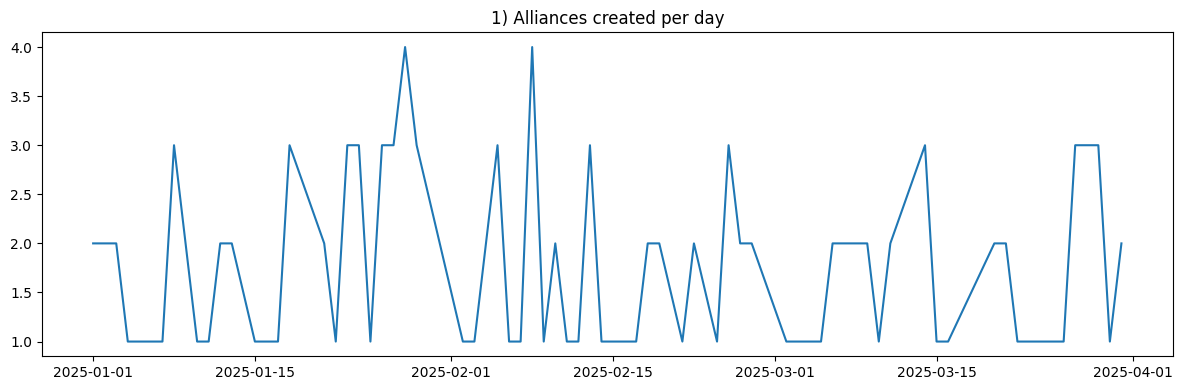

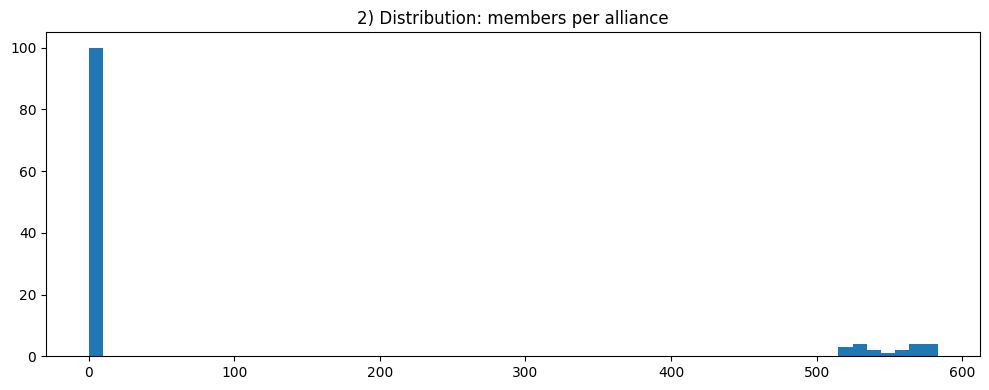

Alliance size inequality: gini=0.837, top1% share=0.053, top5% share=0.315


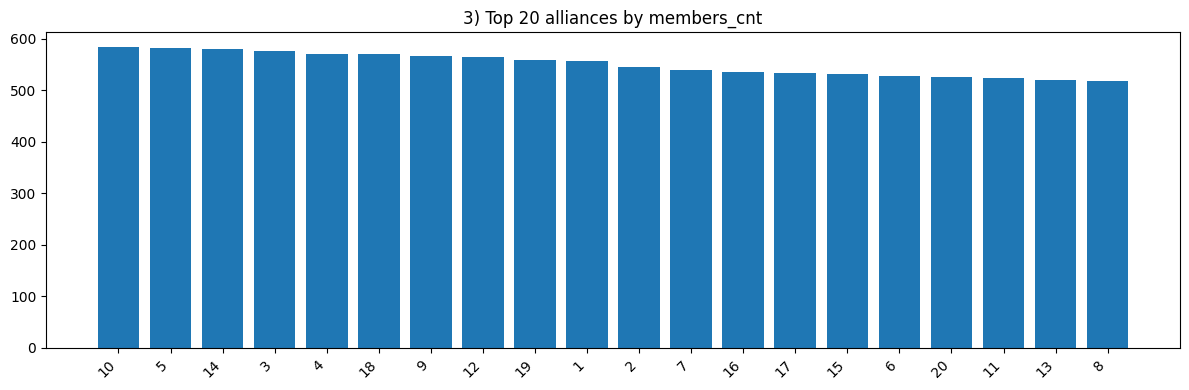

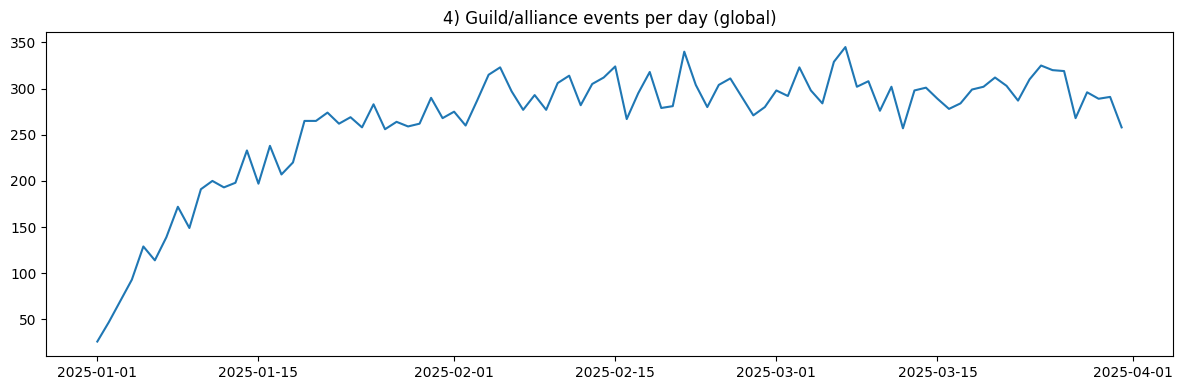

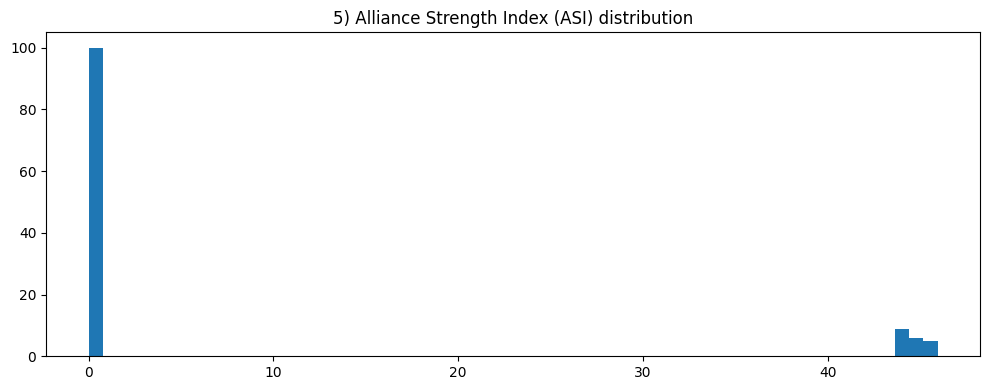

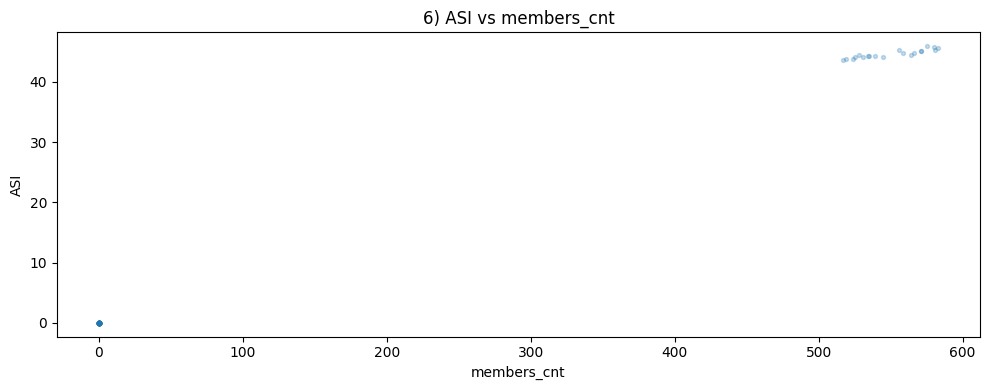

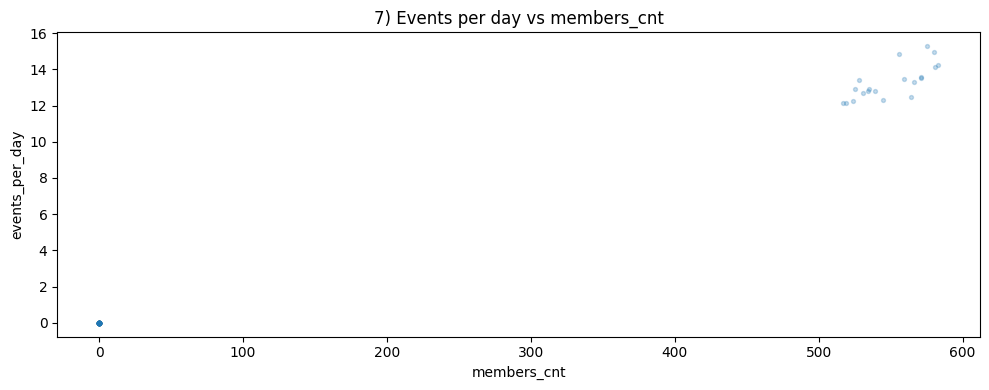

C:\Users\Shaim\AppData\Local\Temp\ipykernel_15388\3054917880.py:381: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = up.groupby("size_bucket").agg(


,size_bucket,users,ret_d7
0,"(0.999, 1101.2]",1101,0.405086
1,"(1101.2, 2201.4]",1100,0.417273
2,"(2201.4, 3301.6]",1100,0.409091
3,"(3301.6, 4401.8]",1100,0.438182
4,"(4401.8, 5502.0]",1101,0.412352
5,"(5502.0, 6602.2]",1100,0.446364
6,"(6602.2, 7702.4]",1100,0.423636
7,"(7702.4, 8802.6]",1100,0.411818
8,"(8802.6, 9902.8]",1100,0.437273
9,"(9902.8, 11003.0]",1101,0.396912


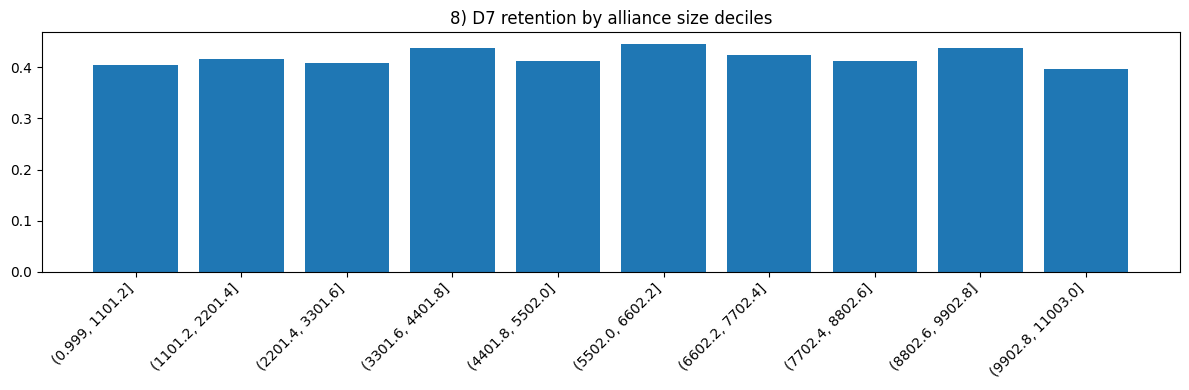

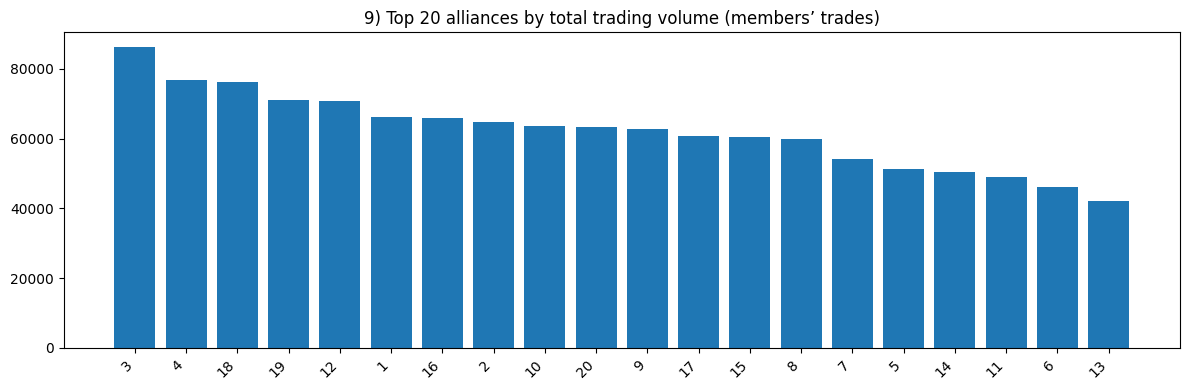

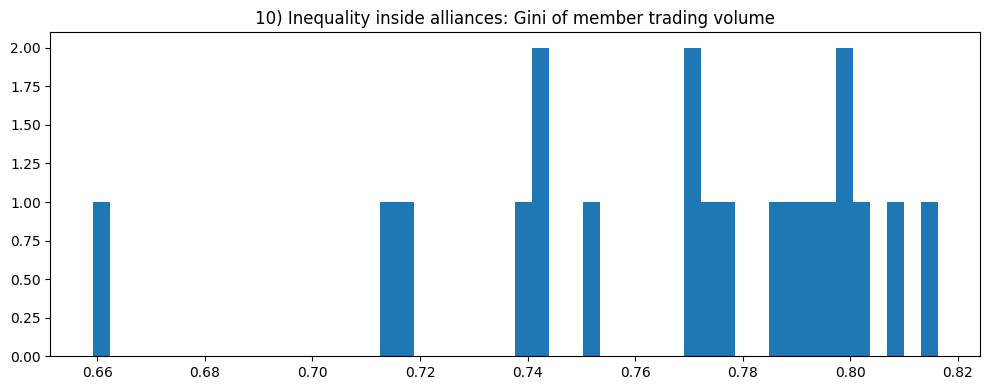

,alliance_id,gini_member_volume
2,3,0.816249
11,12,0.807055
18,19,0.801874
1,2,0.800521
17,18,0.797978
3,4,0.796912
15,16,0.791393
19,20,0.790439
7,8,0.784970
6,7,0.778355


== Experiments (A/B simulation + bootstrap) ==

--- EXP1: Alliance onboarding quest vs none ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
6,fees,0.222528,0.228929,0.005892,-0.030284,0.044239,5499,5504
0,ret_d7_user,0.423532,0.416061,-0.007540,-0.025924,0.011434,5499,5504
2,session_time,22409.401346,22394.799419,-21.951284,-615.508371,548.484646,5499,5504
1,sessions_cnt,14.299327,14.255996,-0.043537,-0.394370,0.298707,5499,5504
5,taxes,5.932328,6.099118,0.165250,-0.898678,1.242723,5499,5504
4,trades,2.961993,3.002907,0.040635,-0.141151,0.215766,5499,5504
3,trading_volume,111.263943,114.464477,2.647629,-15.323783,20.699300,5499,5504


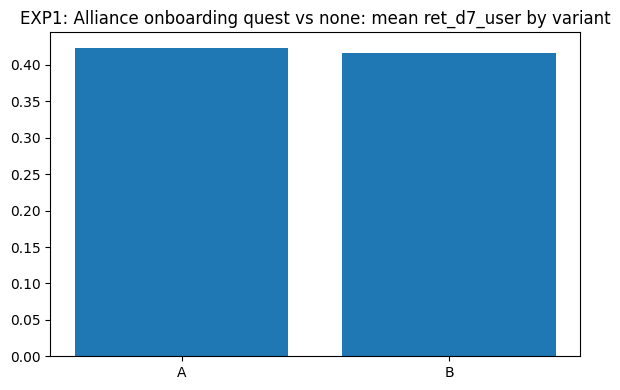

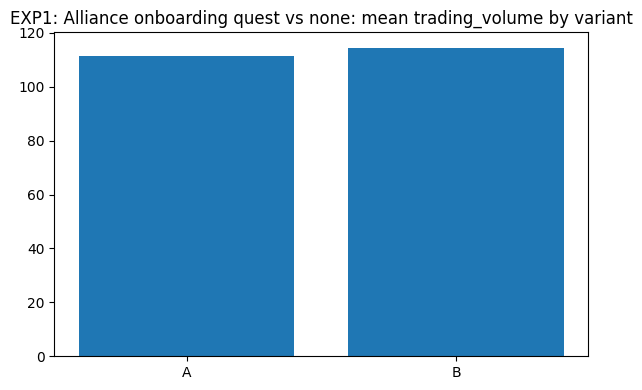


--- EXP2: Alliance fee discount vs baseline ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
6,fees,0.229117,0.222312,-0.006846,-0.044062,0.029918,5526,5477
0,ret_d7_user,0.423272,0.416286,-0.006667,-0.025088,0.012043,5526,5477
2,session_time,22361.120702,22443.440022,88.551991,-509.786591,655.915688,5526,5477
1,sessions_cnt,14.249910,14.305642,0.051504,-0.306940,0.393000,5526,5477
5,taxes,6.129653,5.900850,-0.223120,-1.281316,0.885878,5526,5477
4,trades,2.981723,2.983202,-0.000175,-0.176016,0.180176,5526,5477
3,trading_volume,114.558571,111.156152,-3.228385,-22.182426,14.844194,5526,5477


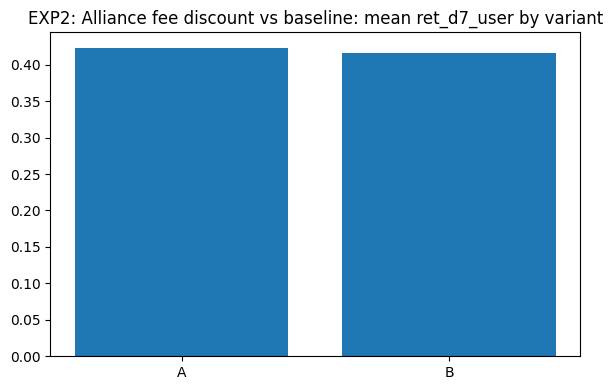

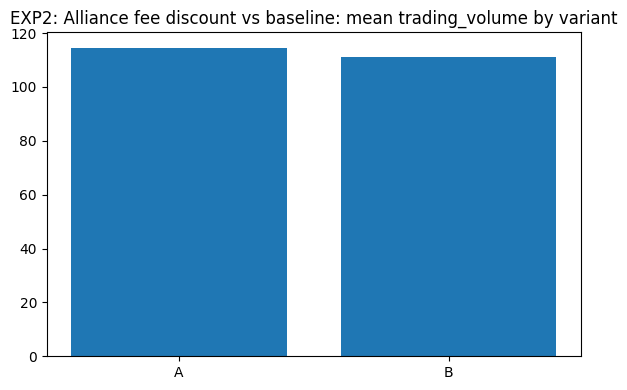


--- EXP3: Alliance endgame wonders vs none ---


,metric,mean_A,mean_B,lift_B_minus_A,ci_low,ci_high,n_A,n_B
6,fees,0.215841,0.235621,0.020496,-0.017891,0.057259,5502,5501
0,ret_d7_user,0.406216,0.433376,0.027217,0.009069,0.045977,5502,5501
2,session_time,22190.460015,22613.772587,442.628533,-120.452795,1048.260405,5502,5501
1,sessions_cnt,14.158306,14.397019,0.238612,-0.119003,0.589189,5502,5501
5,taxes,5.714831,6.316745,0.602346,-0.478459,1.781230,5502,5501
4,trades,2.892585,3.072350,0.176227,-0.010657,0.360452,5502,5501
3,trading_volume,107.920455,117.810319,9.956739,-7.719948,28.355540,5502,5501


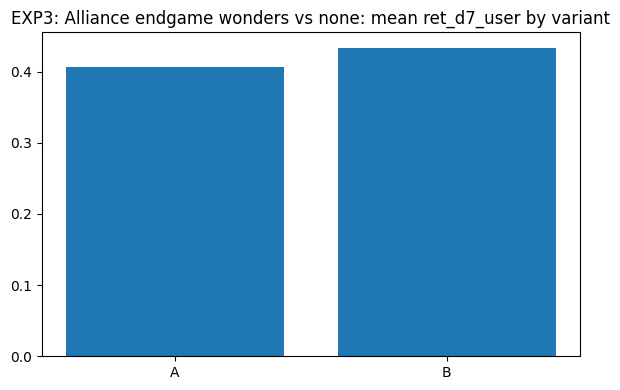

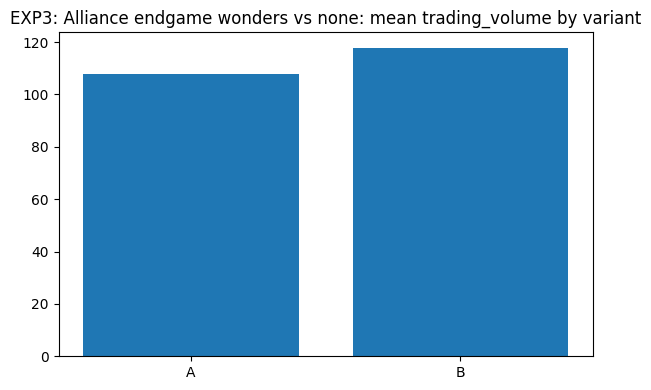

Done.


In [39]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR = r"./synthetic_data"     
ALLIANCE_FILES_TRY = ["aliance.csv", "alliance.csv"] 
MAX_ALLIANCES_FOR_PLOTS = None    
MAX_EVENTS_ROWS_FOR_PLOTS = None    

def p(msg):
    print(msg, flush=True)

def _dt(x):
    return pd.to_datetime(x, errors="coerce")

def _pick_col(df, candidates, required=True, df_name="df"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"{df_name}:not found a column {candidates}. Have: {list(df.columns)}")
    return None

def find_csv(path_dir, filenames):
    for fn in filenames:
        path = os.path.join(path_dir, fn)
        if os.path.exists(path):
            return path
    # fallback recursive search
    for fn in filenames:
        hits = glob.glob(os.path.join(path_dir, "**", fn), recursive=True)
        if hits:
            return hits[0]
    return None

def gini(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    s = x.sum()
    if s == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / s) / n

def top_share(x, p=0.01):
    x = pd.Series(x).dropna()
    x = x[x >= 0].sort_values(ascending=False)
    if len(x) == 0:
        return np.nan
    k = max(1, int(len(x) * p))
    return float(x.head(k).sum() / x.sum())

def bootstrap_diff(a, b, iters=1500):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 10 or len(b) < 10:
        return {"lift": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    lifts = []
    for _ in range(iters):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        lifts.append(sb.mean() - sa.mean())
    lifts = np.sort(lifts)
    return {
        "lift": float(np.mean(lifts)),
        "ci_low": float(np.quantile(lifts, 0.025)),
        "ci_high": float(np.quantile(lifts, 0.975)),
    }

def assign_variant(ids, exp_name="exp", p_B=0.5):
    s = pd.Series(ids).astype(str)
    h = s.map(lambda x: (hash(exp_name + "::" + x) % 10_000) / 10_000.0)
    return np.where(h < p_B, "B", "A")

# =========================
# 0) LOAD ALLIANCES
# =========================
p("== Load alliances ==")

alliances = globals().get("alliances", None)
if alliances is None:
    path = find_csv(DATA_DIR, ALLIANCE_FILES_TRY)
    if path is None:
        raise FileNotFoundError(f"Not found aliance.csv/alliance.csv в {DATA_DIR}.Check DATA_DIR and file name.")
    alliances = pd.read_csv(path)
    p(f"Loaded alliances from: {path} | shape={alliances.shape}")
else:
    p(f"Using in-memory `alliances` | shape={alliances.shape}")

if MAX_ALLIANCES_FOR_PLOTS is not None and len(alliances) > MAX_ALLIANCES_FOR_PLOTS:
    alliances = alliances.sample(MAX_ALLIANCES_FOR_PLOTS, random_state=RANDOM_SEED).copy()
    p(f"Sampled alliances -> shape={alliances.shape}")

display(alliances.head())
p(f"alliances columns: {list(alliances.columns)}")

aid_col = _pick_col(alliances, ["alliance_id","guild_id","id"], df_name="alliances")
acreated_col = _pick_col(alliances, ["created_at","created_ts","created","ts_created"], required=False, df_name="alliances")
aname_col = _pick_col(alliances, ["name","alliance_name","title"], required=False, df_name="alliances")

alliances = alliances.rename(columns={aid_col:"alliance_id"})
if acreated_col:
    alliances[acreated_col] = _dt(alliances[acreated_col])
    alliances["created_day"] = alliances[acreated_col].dt.floor("D")
else:
    alliances["created_day"] = pd.NaT

# =========================
# 1) LOAD MEMBERSHIP + EVENTS (use existing in memory if present)
# =========================
p("== Load guild_membership / guild_events ==")

guild_membership = globals().get("guild_membership", None)
guild_events = globals().get("guild_events", None)

# auto-load from CSV if missing
if guild_membership is None:
    gm_path = find_csv(DATA_DIR, ["guild_membership.csv"])
    if gm_path and os.path.exists(gm_path):
        guild_membership = pd.read_csv(gm_path)
        p(f"Loaded guild_membership from: {gm_path} | shape={guild_membership.shape}")
if guild_events is None:
    ge_path = find_csv(DATA_DIR, ["guild_events.csv"])
    if ge_path and os.path.exists(ge_path):
        guild_events = pd.read_csv(ge_path)
        p(f"Loaded guild_events from: {ge_path} | shape={guild_events.shape}")

if guild_membership is None or guild_events is None:
    p("[WARN] guild_membership/guild_events not found. only base by alliances.csv.")
else:
    p(f"guild_membership cols: {list(guild_membership.columns)}")
    p(f"guild_events cols: {list(guild_events.columns)}")

# Optional: users/sessions/market_trades/token_ledger
users = globals().get("users", None)
sessions = globals().get("sessions", None)
market_trades = globals().get("market_trades", None)
token_ledger = globals().get("token_ledger", None)

# =========================
# 2) BUILD ALLIANCE METRICS
# =========================
p("== Build alliance metrics ==")

# base table
A = alliances[["alliance_id","created_day"] + (["name"] if "name" in alliances.columns else [])].copy()
if aname_col and aname_col in alliances.columns and "name" not in A.columns:
    A["name"] = alliances[aname_col]

# membership metrics
M = None
if guild_membership is not None:
    M = guild_membership.copy()
    mid_user = _pick_col(M, ["user_id","member_user_id"], df_name="guild_membership")
    mid_gid  = _pick_col(M, ["guild_id","alliance_id","id_guild"], df_name="guild_membership")
    mjoin    = _pick_col(M, ["joined_at","join_ts","ts_joined","created_at"], required=False, df_name="guild_membership")
    mleave   = _pick_col(M, ["left_at","leave_ts","ts_left"], required=False, df_name="guild_membership")

    M = M.rename(columns={mid_user:"user_id", mid_gid:"alliance_id"})
    if mjoin:
        M[mjoin] = _dt(M[mjoin])
        M["join_day"] = M[mjoin].dt.floor("D")
    else:
        M["join_day"] = pd.NaT
    if mleave:
        M[mleave] = _dt(M[mleave])
        M["leave_day"] = M[mleave].dt.floor("D")
    else:
        M["leave_day"] = pd.NaT

    members = M.groupby("alliance_id").agg(
        members_cnt=("user_id","nunique"),
        join_min=("join_day","min"),
        join_max=("join_day","max"),
    ).reset_index()

    A = A.merge(members, on="alliance_id", how="left")
else:
    A["members_cnt"] = np.nan

# events metrics
E = None
if guild_events is not None:
    E = guild_events.copy()
    ets = _pick_col(E, ["ts","event_ts","timestamp"], df_name="guild_events")
    egid = _pick_col(E, ["guild_id","alliance_id"], df_name="guild_events")
    etype = _pick_col(E, ["event_type","event_name","type"], required=False, df_name="guild_events")

    E = E.rename(columns={egid:"alliance_id"})
    E[ets] = _dt(E[ets])
    E["day"] = E[ets].dt.floor("D")
    if etype:
        E = E.rename(columns={etype:"event_type"})
    else:
        E["event_type"] = "event"

    if MAX_EVENTS_ROWS_FOR_PLOTS is not None and len(E) > MAX_EVENTS_ROWS_FOR_PLOTS:
        E = E.sample(MAX_EVENTS_ROWS_FOR_PLOTS, random_state=RANDOM_SEED).copy()
        p(f"Sampled guild_events -> shape={E.shape}")

    ev = E.groupby("alliance_id").agg(
        events_cnt=("event_type","count"),
        active_days=("day","nunique"),
    ).reset_index()
    A = A.merge(ev, on="alliance_id", how="left")

    # daily events (for timeseries)
    events_daily = E.groupby("day").size().reset_index(name="events_total")
else:
    events_daily = None

# fill numeric nulls
for c in ["members_cnt","events_cnt","active_days"]:
    if c in A.columns:
        A[c] = pd.to_numeric(A[c], errors="coerce").fillna(0.0)

# Alliance Strength Index (simple): log(events per day) * log(members)
A["events_per_day"] = A["events_cnt"] / A["active_days"].replace(0, np.nan)
A["ASI"] = np.log1p(A["events_cnt"]) * np.log1p(A["members_cnt"])
A["ASI"] = A["ASI"].replace([np.inf,-np.inf], np.nan).fillna(0.0)

display(A.head())

# =========================
# 3) USER ↔ ALLIANCE PANEL (for experiments/links)
# =========================
p("== Build user-alliance panel ==")

user_alliance = None
if M is not None:
    user_alliance = M[["user_id","alliance_id"]].drop_duplicates().copy()

# add user metrics: retention d7, session time, trading volume, taxes
U = None
if users is not None:
    U = users.copy()
    U["created_at"] = _dt(U["created_at"])
    U["cohort_day"] = U["created_at"].dt.floor("D")

user_ret = None
if users is not None and sessions is not None:
    s = sessions.copy()
    s["start_ts"] = _dt(s["start_ts"])
    s["day"] = s["start_ts"].dt.floor("D")
    active = s.groupby(["user_id","day"]).size().reset_index(name="active")
    active["active"] = 1

    tmp = U[["user_id","cohort_day"]].copy()
    tmp["day7"] = tmp["cohort_day"] + pd.Timedelta(days=7)
    tmp = tmp.merge(active[["user_id","day","active"]], left_on=["user_id","day7"], right_on=["user_id","day"], how="left")
    tmp["ret_d7_user"] = tmp["active"].fillna(0).astype(int)
    user_ret = tmp[["user_id","ret_d7_user"]]

user_sessions = None
if sessions is not None:
    s = sessions.copy()
    s["start_ts"] = _dt(s["start_ts"])
    s["session_len_sec"] = pd.to_numeric(s["session_len_sec"], errors="coerce").fillna(0.0)
    user_sessions = s.groupby("user_id").agg(
        sessions_cnt=("session_id","count"),
        session_time=("session_len_sec","sum"),
        active_days=("start_ts", lambda x: pd.Series(_dt(x)).dt.floor("D").nunique()),
    ).reset_index()

user_econ = None
if market_trades is not None:
    mt = market_trades.copy()
    mt["ts"] = _dt(mt["ts"])
    mt["amount_base"] = pd.to_numeric(mt["amount_base"], errors="coerce").fillna(0.0)
    mt["price"] = pd.to_numeric(mt["price"], errors="coerce").fillna(0.0)
    mt["gross_token"] = mt["amount_base"] * mt["price"]
    mt["tax_amount"] = pd.to_numeric(mt["tax_amount"], errors="coerce").fillna(0.0)
    mt["fee_amount"] = pd.to_numeric(mt["fee_amount"], errors="coerce").fillna(0.0)
    user_econ = mt.groupby("maker_user_id").agg(
        trading_volume=("gross_token","sum"),
        trades=("trade_id","count"),
        taxes=("tax_amount","sum"),
        fees=("fee_amount","sum"),
        avg_slippage=("slippage_bps","mean"),
        avg_spread=("spread_bps","mean"),
    ).reset_index().rename(columns={"maker_user_id":"user_id"})

# assemble user panel
user_panel = None
if user_alliance is not None:
    user_panel = user_alliance.merge(A[["alliance_id","members_cnt","ASI","events_cnt","events_per_day"]], on="alliance_id", how="left")
    if users is not None:
        keep = ["user_id","acq_channel","player_segment","risk_profile","whale_flag","initial_deposit_usd"]
        keep = [c for c in keep if c in users.columns]
        user_panel = user_panel.merge(users[keep], on="user_id", how="left")
    if user_ret is not None:
        user_panel = user_panel.merge(user_ret, on="user_id", how="left")
    if user_sessions is not None:
        user_panel = user_panel.merge(user_sessions, on="user_id", how="left")
    if user_econ is not None:
        user_panel = user_panel.merge(user_econ, on="user_id", how="left")

    # fill
    for c in ["ret_d7_user","sessions_cnt","session_time","active_days","trading_volume","trades","taxes","fees","initial_deposit_usd"]:
        if c in user_panel.columns:
            user_panel[c] = pd.to_numeric(user_panel[c], errors="coerce").fillna(0.0)
else:
    p("[WARN] No membership table -> user_panel is None")

if user_panel is not None:
    display(user_panel.head())

# =========================
# 4) 10 PLOTS ABOUT ALLIANCES
# =========================
p("== 10 alliance plots ==")

# Plot 1: alliances created per day
if A["created_day"].notna().any():
    ts = A.groupby("created_day")["alliance_id"].nunique().reset_index(name="alliances_created")
    plt.figure(figsize=(12,4))
    plt.plot(ts["created_day"], ts["alliances_created"])
    plt.title("1) Alliances created per day")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 1: no created_day in alliances")

# Plot 2: distribution of alliance sizes
if "members_cnt" in A.columns:
    plt.figure(figsize=(10,4))
    plt.hist(A["members_cnt"].clip(lower=0), bins=60)
    plt.title("2) Distribution: members per alliance")
    plt.tight_layout(); plt.show()

    p(f"Alliance size inequality: gini={gini(A['members_cnt']):.3f}, top1% share={top_share(A['members_cnt'],0.01):.3f}, top5% share={top_share(A['members_cnt'],0.05):.3f}")

# Plot 3: top alliances by members (bar)
topN = 20
top = A.sort_values("members_cnt", ascending=False).head(topN).copy()
plt.figure(figsize=(12,4))
plt.bar(top["alliance_id"].astype(str), top["members_cnt"])
plt.xticks(rotation=45, ha="right")
plt.title(f"3) Top {topN} alliances by members_cnt")
plt.tight_layout(); plt.show()

# Plot 4: events_total per day (global)
if events_daily is not None:
    plt.figure(figsize=(12,4))
    plt.plot(events_daily["day"], events_daily["events_total"])
    plt.title("4) Guild/alliance events per day (global)")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 4: no events_daily")

# Plot 5: ASI distribution
plt.figure(figsize=(10,4))
plt.hist(A["ASI"].replace([np.inf,-np.inf], np.nan).fillna(0.0), bins=60)
plt.title("5) Alliance Strength Index (ASI) distribution")
plt.tight_layout(); plt.show()

# Plot 6: ASI vs size scatter
plt.figure(figsize=(10,4))
plt.scatter(A["members_cnt"], A["ASI"], s=8, alpha=0.25)
plt.title("6) ASI vs members_cnt")
plt.xlabel("members_cnt"); plt.ylabel("ASI")
plt.tight_layout(); plt.show()

# Plot 7: events_per_day vs size scatter
x = A["members_cnt"].to_numpy()
y = A["events_per_day"].replace([np.inf,-np.inf], np.nan).fillna(0.0).to_numpy()
plt.figure(figsize=(10,4))
plt.scatter(x, y, s=8, alpha=0.25)
plt.title("7) Events per day vs members_cnt")
plt.xlabel("members_cnt"); plt.ylabel("events_per_day")
plt.tight_layout(); plt.show()

# Plot 8: retention d7 by alliance size bucket (if user_panel exists)
if user_panel is not None and "ret_d7_user" in user_panel.columns:
    # bucket by alliance size
    up = user_panel.copy()
    up["size_bucket"] = pd.qcut(up["members_cnt"].rank(method="first"), q=10, duplicates="drop")
    grp = up.groupby("size_bucket").agg(
        users=("user_id","nunique"),
        ret_d7=("ret_d7_user","mean")
    ).reset_index()
    display(grp)
    plt.figure(figsize=(12,4))
    plt.bar(grp["size_bucket"].astype(str), grp["ret_d7"])
    plt.xticks(rotation=45, ha="right")
    plt.title("8) D7 retention by alliance size deciles")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 8: user_panel/ret_d7_user missing")

# Plot 9: trading volume by alliance (if market_trades + membership exist)
if user_panel is not None and "trading_volume" in user_panel.columns:
    av = user_panel.groupby("alliance_id").agg(
        members=("user_id","nunique"),
        volume=("trading_volume","sum"),
        taxes=("taxes","sum"),
        trades=("trades","sum")
    ).reset_index()
    av["volume_per_member"] = av["volume"] / av["members"].replace(0, np.nan)
    topv = av.sort_values("volume", ascending=False).head(20)
    plt.figure(figsize=(12,4))
    plt.bar(topv["alliance_id"].astype(str), topv["volume"])
    plt.xticks(rotation=45, ha="right")
    plt.title("9) Top 20 alliances by total trading volume (members’ trades)")
    plt.tight_layout(); plt.show()
else:
    p("[SKIP] Plot 9: need user_panel + trading_volume")

# Plot 10: within-alliance inequality of trading contribution (Gini per alliance)
if user_panel is not None and "trading_volume" in user_panel.columns:
    up = user_panel.copy()
    # gini per alliance
    gin = up.groupby("alliance_id")["trading_volume"].apply(lambda s: gini(s.to_numpy())).reset_index(name="gini_member_volume")
    plt.figure(figsize=(10,4))
    plt.hist(gin["gini_member_volume"].replace([np.inf,-np.inf], np.nan).dropna(), bins=50)
    plt.title("10) Inequality inside alliances: Gini of member trading volume")
    plt.tight_layout(); plt.show()

    display(gin.sort_values("gini_member_volume", ascending=False).head(10))
else:
    p("[SKIP] Plot 10: need user_panel + trading_volume")

# =========================
# 5) "EXPERIMENTS" (A/B simulation + evaluation)
# =========================
p("== Experiments (A/B simulation + bootstrap) ==")

if user_panel is None:
    p("[SKIP] Experiments: no membership -> cannot evaluate")
else:
    metrics = []
    for col in ["ret_d7_user","sessions_cnt","session_time","trading_volume","trades","taxes","fees"]:
        if col in user_panel.columns:
            metrics.append(col)

    if not metrics:
        p("[SKIP] Experiments: no metrics columns available")
    else:
        # EXP1: Alliance onboarding quest (B) vs none (A)
        user_panel["exp1_variant"] = assign_variant(user_panel["user_id"], exp_name="exp1_alliance_onboarding_quest", p_B=0.5)

        # EXP2: Alliance internal market fee discount (B) vs baseline (A)
        user_panel["exp2_variant"] = assign_variant(user_panel["user_id"], exp_name="exp2_alliance_fee_discount", p_B=0.5)

        # EXP3: Cooperative endgame project (wonders) (B) vs none (A)
        user_panel["exp3_variant"] = assign_variant(user_panel["user_id"], exp_name="exp3_alliance_endgame_wonders", p_B=0.5)

        def eval_exp(var_col, exp_name):
            p(f"\n--- {exp_name} ---")
            out = []
            for mcol in metrics:
                a = user_panel.loc[user_panel[var_col]=="A", mcol].to_numpy()
                b = user_panel.loc[user_panel[var_col]=="B", mcol].to_numpy()
                res = bootstrap_diff(a, b, iters=1500)
                out.append({
                    "metric": mcol,
                    "mean_A": float(np.nanmean(a)) if len(a) else np.nan,
                    "mean_B": float(np.nanmean(b)) if len(b) else np.nan,
                    "lift_B_minus_A": res["lift"],
                    "ci_low": res["ci_low"],
                    "ci_high": res["ci_high"],
                    "n_A": int(np.sum(user_panel[var_col]=="A")),
                    "n_B": int(np.sum(user_panel[var_col]=="B")),
                })
            df = pd.DataFrame(out).sort_values("metric")
            display(df)

            key = [c for c in ["ret_d7_user","trading_volume","session_time","taxes","trades"] if c in metrics][:2]
            for mcol in key:
                g = user_panel.groupby(var_col)[mcol].mean().reset_index()
                plt.figure(figsize=(6,4))
                plt.bar(g[var_col].astype(str), g[mcol])
                plt.title(f"{exp_name}: mean {mcol} by variant")
                plt.tight_layout(); plt.show()

        eval_exp("exp1_variant", "EXP1: Alliance onboarding quest vs none")
        eval_exp("exp2_variant", "EXP2: Alliance fee discount vs baseline")
        eval_exp("exp3_variant", "EXP3: Alliance endgame wonders vs none")

p("Done.")


> **Product Metrics Insights:**
Cohort-based retention analysis helps identify critical churn points. If D1 Retention is below targets, onboarding should be reviewed. The conversion funnel highlights stages where users lose interest in economic interaction.